# AOI Mapping Notebook

This notebook is used to build chonological raw object gaze events and assigning for each an **Areas of Interest (AOIs)** 
For subsequent analysis we sum Area of Interest Gaze events together

## Workflow

1. **Define raw object gaze assignments**
2. **Define Areas of Interest borders (AOIs)**
3. **Map object gaze assignments to their corresponding AOIs**
4. **Generate AOI gaze events from that** 
5. **Last structuring before Analysis**
    - rename deskobjects
    - check when model_plate is being logged during the delay for later delay correciton logic

## 1. Defining object gaze Assignments
- #### Object gaze definition : the time spent continuiously targeting a certain object until object changes. Gaze threshold 100ms

## 1.1 Installations

In [127]:
%pip install -q scikit-learn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Imports

In [128]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns

## Configuration and loading preprocessed data

This cell sets up all project paths and global parameters, then loads the
preprocessed eye-tracking dataset `preprocessed_raw_all.csv`.

The file `preprocessed_raw_all.csv` is assumed to live in  
`<PROJECT_ROOT>/Data/Processed/` and already contains all cleaned and derived
columns from the preprocessing step (e.g. `UID`, `raw_timestamp`,
`hit_obj_name_corr`, `model_name`, `AF`, `condition`, `complexity`, etc.).


In [129]:


# ===================== CONFIG =====================

# Folder in which this script/notebook lives
SCRIPT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()

# Project root = one level above "AnalysisScripts" (same logic as in Model Gaze notebook)
PROJECT_ROOT = SCRIPT_DIR.parent

# --- Data folders ---
DATA_RAW_DIR       = PROJECT_ROOT / "Data" / "Raw"        # raw ET CSVs
DATA_PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"  # preprocessed/combined CSVs

# --- Results folders (tables & plots) ---
RESULT_TABLES_DIR  = PROJECT_ROOT / "Results" / "Tables"
RESULT_PLOTS_DIR   = PROJECT_ROOT / "Results" / "Plots"

# Example output path (not yet used here)
OUTPUT_DETAIL = RESULT_TABLES_DIR / "ObjectGazeResults.csv"

# Time unit of the raw timestamp column
FORCE_TIME_UNIT = "ms"

# Minimum gaze duration in ms (used as fixation duration threshold)
MIN_GAZE_MS = 100.0

# Create folders if they do not exist
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
RESULT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ===================== LOAD PREPROCESSED DATA =====================

PREPROCESSED_CSV = DATA_PROCESSED_DIR / "preprocessed_raw_all.csv"
raw_all = pd.read_csv(PREPROCESSED_CSV, low_memory=False)

print("PROJECT_ROOT        :", PROJECT_ROOT)
print("DATA_PROCESSED_DIR  :", DATA_PROCESSED_DIR)
print("RESULT_TABLES_DIR   :", RESULT_TABLES_DIR)
print("raw_all shape       :", raw_all.shape)
raw_all.head()


PROJECT_ROOT        : /Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit
DATA_PROCESSED_DIR  : /Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Data/Processed
RESULT_TABLES_DIR   : /Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Results/Tables
raw_all shape       : (4680329, 58)


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,left_eye_calibration_quality,right_eye_calibration_quality,UID,recording_date,source_file,is_valid_model,AF,complexity,condition,hit_obj_name_corr
0,1000002773811334400,1754658861466,5.185122,0.913979,257894,0.0,Valid,0.199822,-0.038434,0.979078,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor
1,1000002773816336100,1754658861467,5.185122,0.908018,257895,0.0,Valid,0.227848,-0.056482,0.972057,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor
2,1000002773821337800,1754658861467,5.185122,0.915157,257896,0.0,Valid,0.254252,-0.073261,0.964359,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor
3,1000002773826339500,1754658861467,5.185122,0.965864,257897,0.0,Valid,0.278826,-0.091104,0.956010,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor
4,1000002773831339600,1754658861467,5.185122,1.029571,257898,0.0,Valid,0.302282,-0.109190,0.946944,...,Unknown,Unknown,1,2025-08-08,01_ET_Data_2025-08-08.csv,False,Unknown,NaN,NaN,Floor


- ##  Strucutral step : Change  UID to participant_id in raw_all for clarity from now on just working with participant_id

In [130]:
# ===================== ALIGN COLUMN NAMES =====================

# raw_all benutzt UID statt participant_id -> angleichen
if "UID" in raw_all.columns:
    raw_all = raw_all.rename(columns={"UID": "participant_id"})

print("participant_id in raw_all?", "participant_id" in raw_all.columns)


participant_id in raw_all? True


In [131]:
# doppelte Spaltennamen entfernen (erste behalten)
raw_all = raw_all.loc[:, ~raw_all.columns.duplicated()]

# Check
print("Duplicate columns:", raw_all.columns[raw_all.columns.duplicated()].tolist())
print(raw_all[["participant_id"]].head())


Duplicate columns: []
   participant_id
0               1
1               1
2               1
3               1
4               1


##  Fix: participant_id in beiden DataFrames vereinheitlichen

In [132]:
def normalize_pid(s):
    # macht aus '01' -> '1', aus 1 -> '1', aus ' 01 ' -> '1'
    return s.astype(str).str.strip().astype(int).astype(str)

raw_all["participant_id"] = normalize_pid(raw_all["participant_id"])
# object_gazes_clean gibt es hier noch nicht -> kommt später


In [133]:
%who


AOI_COLORS	 C	 DATA_PROCESSED_DIR	 DATA_RAW_DIR	 ENVIRONMENT_OBJECTS	 FORCE_TIME_UNIT	 Line2D	 MAX_ARROWS	 MIN_GAZE_MS	 
MODEL	 Normalize	 ONLY_VALID	 ORIGIN_X	 ORIGIN_Z	 OUTPUT_DETAIL	 OUTPUT_FILE	 PALETTE	 PID	 
PREPROCESSED_CSV	 PROJECT_ROOT	 Patch	 Path	 RESULT_PLOTS_DIR	 RESULT_TABLES_DIR	 SCRIPT_DIR	 TASK_AOIS	 X_COL	 
YAW_COL	 Z_COL	 actual_n	 add_yaw_stats_for_participant	 all_objects	 aoi	 aoi_bricks	 arrow_colors	 arrow_len	 
assigned	 at_or_above_100	 ax_hist	 ax_map	 ax_top	 bar_colors	 base_df	 best	 bin_aoi	 
bins	 brick_positions	 brick_positions_shifted	 brick_positions_shifted_10	 brick_positions_shifted_50	 c	 cal	 canonical_deg_180	 cb	 
cbar	 centers	 centroids	 check_order	 classify_gaze_by_yaw	 clean_mask	 clean_str	 cmap	 colors	 
colors_	 cols	 condition_counts	 coords	 counts	 cx	 cz	 d2	 data	 
desk	 desk_candidates	 desk_keywords	 df	 df_2s	 df_dir	 df_other_summary	 df_p	 df_pid	 
df_plot	 df_sub	 df_t	 df_tmp	 dfm	 diag_delay	 diag_df	 dx	 dz	 
edges	 envir

## Check if change to participant_id klappt

In [134]:
print(raw_all.columns.tolist())


['gaze_capture_time', 'raw_timestamp', 'relative_to_unix_epoch_timestamp', 'focus_distance', 'frame_number', 'stability', 'status', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'left_forward_x', 'left_forward_y', 'left_forward_z', 'left_origin_x', 'left_origin_y', 'left_origin_z', 'left_status', 'left_pupil_diameter', 'left_iris_diameter', 'left_pupil_iris_ratio', 'left_eye_openness', 'right_forward_x', 'right_forward_y', 'right_forward_z', 'right_origin_x', 'right_origin_y', 'right_origin_z', 'right_status', 'right_pupil_diameter', 'right_iris_diameter', 'right_pupil_iris_ratio', 'right_eye_openness', 'inter_pupillary_distance', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'model_name', 'is_building_model', 'hit_obj_name', 'calibration_state', 'calibration_attempts', 'left_eye_calibration_quality', 'right_eye_calibration_quality', 'participant_id

## Seeing everything that exists in hit_obj_name_corr ABER WIESOOOOO

In [135]:
raw_all['hit_obj_name_corr'].unique()


array(['Floor', 'work_desk_base.001', 'Wall_Front', 'ImageFixationCross',
       'PlaneRight', 'PlaneLeft', 'ValidationButtonRight',
       'ValidationButtonLeft', 'Lego_Board_10x10', 'NextItemButton',
       'Lego_2x2_Orange', 'Lego_4x2_Pink_Dis', 'Lego_4x2_Orange',
       'Lego_4x2_Blue', 'Wall_Left', 'Model_plate', 'Wall_Cut',
       'Lego_1x3_Pink (1)', 'Lego_4x2_Green (1)', 'Lego_3x2_Orange_Dis',
       'Lego_1x3_Green', 'Lego_2x2_Blue_Dis', 'QuestionButton4',
       'QuestionButton1', 'ContinueButton', 'QuestionButton6',
       'QuestionButton2', 'Lego_4x2_Green', 'Lego_1x3_Orange_Dis',
       'Lego_2x2_Blue', 'Lego_4x2_Orange (1)', 'Lego_2x2_Pink',
       'Lego_3x2_Blue_Dis', 'Lego_2x2_Green_Dis', 'Lego_1x3_Blue',
       'Lego_1x3_Pink', 'QuestionButton3', 'Lego_3x2_Pink_Dis',
       'Lego_4x2_Blue_Dis', 'Lego_2x2_Green (1)', 'Lego_4x2_Pink',
       'Lego_4x2_Pink (1)', 'Lego_3x2_Green_Dis', 'Lego_2x2_Orange (1)',
       'Lego_2x2_Pink (3)', 'Lego_2x2_Pink (2)', 'Lego_2x2_Green 

## Search for Desk objects in the data zu was?!?!?!

In [136]:
# Alle einzigartigen Objekte aus hit_obj_name_corr
all_objects = (
    raw_all["hit_obj_name_corr"]
    .astype(str)
    .str.strip()
    .replace("", pd.NA)
    .dropna()
    .unique()
)

# Desk-/Table-Kandidaten
desk_keywords = ["desk", "table", "work", "board", "bench"]
desk_candidates = [
    obj for obj in all_objects
    if any(kw in obj.lower() for kw in desk_keywords)
]

print("Gefundene Tisch-/Desk-/Work-Objekte (Kandidaten):")
for obj in sorted(desk_candidates):
    print(" -", obj)

print("\nAnzahl:", len(desk_candidates))


Gefundene Tisch-/Desk-/Work-Objekte (Kandidaten):
 - Lego_Board_10x10
 - work_desk_base.001

Anzahl: 2


##  Helper functions

This cell defines small helper functions used throughout the object gaze
extraction:

- `clean_str`: safely converts values to stripped strings, replacing NaN with `""`.
- `to_ms_multiplier_forced`: converts the chosen time unit to milliseconds,
  based on the global `FORCE_TIME_UNIT` setting.


In [137]:
# ===================== HELPER FUNCTIONS =====================

def clean_str(x):
    """Convert NaN to empty string and strip whitespace."""
    return "" if pd.isna(x) else str(x).strip()

def to_ms_multiplier_forced() -> float:
    """
    Return the factor to convert the chosen time column to milliseconds.
    FORCE_TIME_UNIT is defined in Cell 1 ("ms", "s", or "us").
    """
    return {"ms": 1.0, "s": 1000.0, "us": 0.001}.get(FORCE_TIME_UNIT, 1.0)


## Cell 3 — Extract per-gaze object data (with headset rotation)

This cell identifies individual gazes on *any* object in the scene, based on the
`hit_obj_name_corr` column from `preprocessed_raw_all`, and attaches the
headset rotation at the beginning of each gaze.

**Definition of a gaze**

A gaze is defined as a contiguous time interval during which
`hit_obj_name_corr` remains constant (the participant keeps looking at the same
object). Whenever `hit_obj_name_corr` changes, the current gaze ends and—if the
new value is non-empty—a new gaze begins.

For each participant (`participant_id`), the function:

1. copies the participant’s data and checks that the required columns
   (`participant_id`, `raw_timestamp`, `hit_obj_name_corr`) are present,
2. converts `raw_timestamp` to a numeric value, drops invalid rows, and sorts
   all samples by `raw_timestamp`,
3. creates `ts_ms` as time in milliseconds,
4. normalises `hit_obj_name_corr` into `object_name` (empty strings are treated
   as “no object”),
5. scans through the time series and segments it into gazes per `object_name`,
6. for each gaze, records:
   - `participant_id` (two-digit string),
   - `object_name`,
   - `object_gaze_count = 1` (one row = one gaze),
   - `start_ms` and `end_ms`,
   - `object_gaze_duration_ms` and `object_gaze_duration_s`,
   - headset rotation at gaze onset:
     - `hmd_rotation_x`,
     - `hmd_rotation_y`,
     - `hmd_rotation_z`,
     - `hmd_rotation_w`.

All per-participant gaze tables are then concatenated into
`object_gazes_all_raw`, which contains the full chronological object-gaze
dataset (one row per gaze) before any duration-based filtering.


## Adding head and gaze rotations + positions

In [138]:
# ===================== Cell 3 — Extract per-gaze object data (inkl. Modell-Infos + gaze vectors) =====================

import numpy as np  # needed for np.nan

def extract_object_gazes_from_participant(df_pid: pd.DataFrame, participant_id: str) -> pd.DataFrame:
    """
    Extract contiguous gazes on any object based only on 'hit_obj_name_corr'
    for a single participant (participant_id) from preprocessed_raw_all.

    Zusätzlich werden pro Gaze aggregiert:
    - mittlere HMD-Position und -Rotation
    - mittlere gaze_forward_* und gaze_origin_* (Mean)
    - is_valid_model (True, wenn mind. ein Sample im Gaze gültig ist)
    - model_name (häufigster Modellname im Gaze)
    """
    df = df_pid.copy()

    # ✅ UID -> participant_id
    required_cols = {"participant_id", "raw_timestamp", "hit_obj_name_corr"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in preprocessed_raw_all for object gazes: {missing}")

    # Zeit vorbereiten
    df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")
    df = df.dropna(subset=["raw_timestamp"]).sort_values("raw_timestamp").reset_index(drop=True)
    if df.empty:
        return pd.DataFrame()

    df["ts_ms"] = df["raw_timestamp"] * to_ms_multiplier_forced()

    # Objekt-Namen normalisieren
    df["object_name"] = df["hit_obj_name_corr"].apply(clean_str)
    df.loc[df["object_name"] == "", "object_name"] = None  # leere Namen = kein Objekt

    records = []
    prev_obj = None
    have_open = False
    start_ms = None
    start_idx = None
    current_object = None

    # Columns to aggregate (means)
    pos_cols = ["hmd_position_x", "hmd_position_y", "hmd_position_z"]
    rot_cols = ["hmd_rotation_x", "hmd_rotation_y", "hmd_rotation_z", "hmd_rotation_w"]
    gaze_forward_cols = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
    gaze_origin_cols = ["gaze_origin_x", "gaze_origin_y", "gaze_origin_z"]

    for i, row in df.iterrows():
        obj_now = row["object_name"]
        t_now = float(row["ts_ms"])

        # Objektwechsel?
        if obj_now != prev_obj:
            # 1) Vorherigen Gaze beenden (falls offen und nicht None)
            if have_open and prev_obj is not None:
                end_idx = i - 1
                end_ms = float(df.loc[end_idx, "ts_ms"])
                duration_ms = max(0.0, end_ms - start_ms)

                seg = df.loc[start_idx:end_idx]

                # Mittelwerte HMD-Position / -Rotation
                pos_mean = seg[pos_cols].mean() if set(pos_cols).issubset(seg.columns) else pd.Series(dtype=float)
                rot_mean = seg[rot_cols].mean() if set(rot_cols).issubset(seg.columns) else pd.Series(dtype=float)

                # Mittelwerte gaze_forward / gaze_origin
                gf_mean = seg[gaze_forward_cols].mean() if set(gaze_forward_cols).issubset(seg.columns) else pd.Series(dtype=float)
                go_mean = seg[gaze_origin_cols].mean() if set(gaze_origin_cols).issubset(seg.columns) else pd.Series(dtype=float)

                # Modell-Infos
                is_valid_model = None
                if "is_valid_model" in seg.columns:
                    is_valid_model = bool(seg["is_valid_model"].astype(bool).any())

                model_name = None
                if "model_name" in seg.columns:
                    modes = seg["model_name"].dropna().mode()
                    model_name = modes.iloc[0] if not modes.empty else None

                records.append({
                    # ✅ UID -> participant_id
                    "participant_id": str(participant_id).zfill(2),
                    "object_name": current_object,
                    "object_gaze_count": 1,
                    "start_ms": start_ms,
                    "end_ms": end_ms,
                    "object_gaze_duration_ms": duration_ms,
                    "object_gaze_duration_s": duration_ms / 1000.0,

                    # HMD-Position (Mean)
                    "hmd_position_x": pos_mean.get("hmd_position_x", np.nan),
                    "hmd_position_y": pos_mean.get("hmd_position_y", np.nan),
                    "hmd_position_z": pos_mean.get("hmd_position_z", np.nan),

                    # HMD-Rotation (Mean Quaternion)
                    "hmd_rotation_x": rot_mean.get("hmd_rotation_x", np.nan),
                    "hmd_rotation_y": rot_mean.get("hmd_rotation_y", np.nan),
                    "hmd_rotation_z": rot_mean.get("hmd_rotation_z", np.nan),
                    "hmd_rotation_w": rot_mean.get("hmd_rotation_w", np.nan),

                    # Gaze forward (Mean)
                    "gaze_forward_x": gf_mean.get("gaze_forward_x", np.nan),
                    "gaze_forward_y": gf_mean.get("gaze_forward_y", np.nan),
                    "gaze_forward_z": gf_mean.get("gaze_forward_z", np.nan),

                    # Gaze origin (Mean)
                    "gaze_origin_x": go_mean.get("gaze_origin_x", np.nan),
                    "gaze_origin_y": go_mean.get("gaze_origin_y", np.nan),
                    "gaze_origin_z": go_mean.get("gaze_origin_z", np.nan),

                    # Modell-Infos
                    "is_valid_model": is_valid_model,
                    "model_name": model_name,
                })

            # 2) Neuen Gaze starten, falls wir ein Objekt haben
            if obj_now is not None:
                start_ms = t_now
                start_idx = i
                current_object = obj_now
                have_open = True
            else:
                have_open = False
                start_ms = None
                start_idx = None
                current_object = None

        prev_obj = obj_now

    # Letzten Gaze schließen, falls noch offen
    if have_open and prev_obj is not None:
        end_idx = df.index[-1]
        end_ms = float(df.loc[end_idx, "ts_ms"])
        duration_ms = max(0.0, end_ms - start_ms)

        seg = df.loc[start_idx:end_idx]

        pos_mean = seg[pos_cols].mean() if set(pos_cols).issubset(seg.columns) else pd.Series(dtype=float)
        rot_mean = seg[rot_cols].mean() if set(rot_cols).issubset(seg.columns) else pd.Series(dtype=float)
        gf_mean  = seg[gaze_forward_cols].mean() if set(gaze_forward_cols).issubset(seg.columns) else pd.Series(dtype=float)
        go_mean  = seg[gaze_origin_cols].mean() if set(gaze_origin_cols).issubset(seg.columns) else pd.Series(dtype=float)

        is_valid_model = None
        if "is_valid_model" in seg.columns:
            is_valid_model = bool(seg["is_valid_model"].astype(bool).any())

        model_name = None
        if "model_name" in seg.columns:
            modes = seg["model_name"].dropna().mode()
            model_name = modes.iloc[0] if not modes.empty else None

        records.append({
            # ✅ UID -> participant_id
            "participant_id": str(participant_id).zfill(2),
            "object_name": current_object,
            "object_gaze_count": 1,
            "start_ms": start_ms,
            "end_ms": end_ms,
            "object_gaze_duration_ms": duration_ms,
            "object_gaze_duration_s": duration_ms / 1000.0,

            "hmd_position_x": pos_mean.get("hmd_position_x", np.nan),
            "hmd_position_y": pos_mean.get("hmd_position_y", np.nan),
            "hmd_position_z": pos_mean.get("hmd_position_z", np.nan),

            "hmd_rotation_x": rot_mean.get("hmd_rotation_x", np.nan),
            "hmd_rotation_y": rot_mean.get("hmd_rotation_y", np.nan),
            "hmd_rotation_z": rot_mean.get("hmd_rotation_z", np.nan),
            "hmd_rotation_w": rot_mean.get("hmd_rotation_w", np.nan),

            "gaze_forward_x": gf_mean.get("gaze_forward_x", np.nan),
            "gaze_forward_y": gf_mean.get("gaze_forward_y", np.nan),
            "gaze_forward_z": gf_mean.get("gaze_forward_z", np.nan),

            "gaze_origin_x": go_mean.get("gaze_origin_x", np.nan),
            "gaze_origin_y": go_mean.get("gaze_origin_y", np.nan),
            "gaze_origin_z": go_mean.get("gaze_origin_z", np.nan),

            "is_valid_model": is_valid_model,
            "model_name": model_name,
        })

    if not records:
        return pd.DataFrame()

    object_gazes = pd.DataFrame.from_records(records)

    # Spaltenreihenfolge (inkl. neue gaze columns)
    col_order = [
        "participant_id",
        "object_name",
        "object_gaze_count",
        "start_ms",
        "end_ms",
        "object_gaze_duration_ms",
        "object_gaze_duration_s",
        "hmd_position_x",
        "hmd_position_y",
        "hmd_position_z",
        "hmd_rotation_x",
        "hmd_rotation_y",
        "hmd_rotation_z",
        "hmd_rotation_w",
        "gaze_forward_x",
        "gaze_forward_y",
        "gaze_forward_z",
        "gaze_origin_x",
        "gaze_origin_y",
        "gaze_origin_z",
        "is_valid_model",
        "model_name",
    ]

    # keep only columns that exist (prevents KeyError if input is missing some)
    object_gazes = object_gazes[[c for c in col_order if c in object_gazes.columns]]

    # Chronologisch sortieren (optional but nice)
    object_gazes = object_gazes.sort_values(["participant_id", "start_ms"]).reset_index(drop=True)

    return object_gazes


# ===================== OBJECT GAZES FOR ALL PARTICIPANTS =====================

object_gaze_dfs = []
# ✅ groupby UID -> participant_id
for participant_id, df_pid in raw_all.groupby("participant_id"):
    g_obj = extract_object_gazes_from_participant(df_pid, participant_id)
    if not g_obj.empty:
        object_gaze_dfs.append(g_obj)

object_gazes_all_raw = pd.concat(object_gaze_dfs, ignore_index=True) if object_gaze_dfs else pd.DataFrame()

print("object_gazes_all_raw shape:", object_gazes_all_raw.shape)
print("Columns in object_gazes_all_raw:", object_gazes_all_raw.columns.tolist())
object_gazes_all_raw.head()


object_gazes_all_raw shape: (116621, 22)
Columns in object_gazes_all_raw: ['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name']


,participant_id,object_name,object_gaze_count,start_ms,end_ms,object_gaze_duration_ms,object_gaze_duration_s,hmd_position_x,hmd_position_y,hmd_position_z,...,hmd_rotation_z,hmd_rotation_w,gaze_forward_x,gaze_forward_y,gaze_forward_z,gaze_origin_x,gaze_origin_y,gaze_origin_z,is_valid_model,model_name
0,01,Floor,1,1.754659e+12,1.754659e+12,5.0,0.005,0.467239,1.682214,0.017412,...,-0.197105,0.457304,0.377445,-0.196071,0.901186,0.0,0.0,0.0,False,None
1,01,work_desk_base.001,1,1.754659e+12,1.754659e+12,0.0,0.000,0.467239,1.682214,0.017412,...,-0.197105,0.457304,0.303062,-0.228902,0.924478,0.0,0.0,0.0,False,None
2,01,Floor,1,1.754659e+12,1.754659e+12,0.0,0.000,0.467239,1.682214,0.017412,...,-0.197105,0.457304,0.294382,-0.162442,0.941462,0.0,0.0,0.0,False,None
3,01,work_desk_base.001,1,1.754659e+12,1.754659e+12,36.0,0.036,0.466969,1.681231,0.016396,...,-0.199913,0.453420,0.324874,-0.319921,0.889758,0.0,0.0,0.0,False,None
4,01,Wall_Front,1,1.754659e+12,1.754659e+12,3686.0,3.686,0.477676,1.740824,0.077520,...,-0.022479,0.682541,0.000435,0.030085,0.996009,0.0,0.0,0.0,False,None


## Cell 4 — Apply 100 ms filter and finalize per-gaze object dataframe

This cell applies the same 100 ms duration threshold used in the model-gaze
analysis to the object gazes:

1. **100 ms filter**
   - removes all gazes with `object_gaze_duration_ms < MIN_GAZE_MS` (100 ms),
   - produces `object_gazes_filtered`.

2. **Final per-gaze dataframe**
   - ensures `participant_id` is a two-digit string,
   - sorts gazes chronologically per participant,
   - stores the result in `object_gazes_final`.

Each row in `object_gazes_final` represents a single gaze on a specific object,
with its start time, end time, duration in ms/s, and a gaze count of 1.
This dataframe can later be used for aggregation (e.g., per object or per area),
but here we only construct the per-gaze level.


In [139]:
## Cell 4 — Apply 100 ms filter and finalize per-gaze object dataframe

# ===================== 100-ms FILTER FÜR OBJECT GAZES =====================

if not object_gazes_all_raw.empty:
    object_gazes_filtered = (
        object_gazes_all_raw[object_gazes_all_raw["object_gaze_duration_ms"] >= MIN_GAZE_MS]
        .reset_index(drop=True)
        .copy()
    )
else:
    object_gazes_filtered = pd.DataFrame()

# Finaler per-Gaze-DataFrame
if not object_gazes_filtered.empty:
    object_gazes_final = object_gazes_filtered.copy()
    object_gazes_final["participant_id"] = (
        object_gazes_final["participant_id"].astype(str).str.zfill(2)
    )
    object_gazes_final = object_gazes_final.sort_values(
        ["participant_id", "start_ms"],
        ascending=[True, True],
    ).reset_index(drop=True)
else:
    object_gazes_final = object_gazes_filtered.copy()

print("object_gazes_final shape:", object_gazes_final.shape)
object_gazes_final

print(object_gazes_final.columns.tolist())


object_gazes_final shape: (38406, 22)
['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name']


## Add condition column from old data

In [140]:
import pandas as pd

# Chronologisch sortieren
object_gazes_final = (
    object_gazes_final
    .sort_values(["participant_id", "start_ms"])
    .reset_index(drop=True)
)

# Participant-ID vereinheitlichen
object_gazes_final["participant_id"] = (
    object_gazes_final["participant_id"]
    .astype(str)
    .str.zfill(2)
)

# Nur valide Modles wählen
valid_model_mask = (
    object_gazes_final["is_valid_model"].fillna(False).astype(bool)
    & object_gazes_final["model_name"].astype("string").str.strip().ne("")
    & object_gazes_final["model_name"].notna()
)

# Pro Participant und Modell den ersten Gaze finden
model_order = (
    object_gazes_final.loc[
        valid_model_mask,
        ["participant_id", "model_name", "start_ms"]
    ]
    .groupby(
        ["participant_id", "model_name"],
        as_index=False
    )["start_ms"]
    .min()
    .rename(columns={"start_ms": "first_model_start_ms"})
)

# Modelle chronologisch sortieren
model_order = (
    model_order
    .sort_values(["participant_id", "first_model_start_ms"])
    .reset_index(drop=True)
)

# Reihenfolge der Modelle pro Participant
model_order["model_order"] = (
    model_order.groupby("participant_id").cumcount() + 1
)

# Condition zuweisen:
# 1–6 = Condition 1
# 7–12 = Condition 2
# 13–18 = Condition 3
model_order["condition"] = pd.cut(
    model_order["model_order"],
    bins=[0, 6, 12, 18],
    labels=["constant", "0.7s delay", "2.0s delay"]
)

# Alte condition/model_order-Spalten entfernen, falls Zelle erneut läuft
object_gazes_final = object_gazes_final.drop(
    columns=["condition", "model_order"],
    errors="ignore"
)

# Condition an alle Gazes desselben Modells anhängen
object_gazes_final = object_gazes_final.merge(
    model_order[
        ["participant_id", "model_name", "model_order", "condition"]
    ],
    on=["participant_id", "model_name"],
    how="left",
    validate="many_to_one"
)

# Wieder chronologisch sortieren
object_gazes_final = (
    object_gazes_final
    .sort_values(["participant_id", "start_ms"])
    .reset_index(drop=True)
)

# Checks if merge of conidtion worked?

In [141]:
# 1) Existieren die neuen Spalten?
print("condition" in object_gazes_final.columns)
print("model_order" in object_gazes_final.columns)

True
True


In [142]:
valid_model_counts = (
    model_order.groupby("participant_id")["model_name"]
    .nunique()
    .rename("n_valid_models")
)

display(valid_model_counts)

participant_id
01    18
02    18
03    18
04    18
05    18
06    18
07    18
08    18
09    18
10    18
Name: n_valid_models, dtype: int64

In [143]:
condition_counts = (
    model_order.groupby(
        ["participant_id", "condition"]
    )["model_name"]
    .nunique()
    .unstack(fill_value=0)
)

display(condition_counts)

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1415/1869947904.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_order.groupby(


condition,constant,0.7s delay,2.0s delay
participant_id,,,
01,6,6,6
02,6,6,6
03,6,6,6
04,6,6,6
05,6,6,6
06,6,6,6
07,6,6,6
08,6,6,6
09,6,6,6


In [144]:
check_order = (
    model_order[
        [
            "participant_id",
            "model_name",
            "first_model_start_ms",
            "model_order",
            "condition"
        ]
    ]
    .sort_values(["participant_id", "model_order"])
)

display(check_order.head(40))

,participant_id,model_name,first_model_start_ms,model_order,condition
0,01,C3M2A,1.754659e+12,1,constant
1,01,C2M6A,1.754659e+12,2,constant
2,01,C1M3F,1.754660e+12,3,constant
3,01,C2M5F,1.754660e+12,4,constant
4,01,C1M2A,1.754660e+12,5,constant
5,01,C3M5F,1.754660e+12,6,constant
6,01,C2M3F,1.754660e+12,7,0.7s delay
7,01,C3M4A,1.754660e+12,8,0.7s delay
8,01,C2M4A,1.754660e+12,9,0.7s delay
9,01,C1M1F,1.754660e+12,10,0.7s delay


In [145]:
print(object_gazes_final.shape)
print(object_gazes_final.columns.tolist())

(38406, 24)
['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition']


In [146]:
display(
    model_order.groupby("participant_id")["model_name"]
    .nunique()
    .rename("n_valid_models")
)

participant_id
01    18
02    18
03    18
04    18
05    18
06    18
07    18
08    18
09    18
10    18
Name: n_valid_models, dtype: int64

## Check if all jitter gazes got filtered out?

In [147]:
# Check: Sind im gerade erstellten object_gazes_final noch Gazes unter 100 ms?

under_100 = object_gazes_final[
    object_gazes_final["object_gaze_duration_ms"] < 100
]

at_or_above_100 = object_gazes_final[
    object_gazes_final["object_gaze_duration_ms"] >= 100
]

print("Alle Gazes im object_gazes_final:", len(object_gazes_final))
print("Gazes unter 100 ms:", len(under_100))
print("Gazes ab 100 ms:", len(at_or_above_100))

if len(under_100) == 0:
    print("✅ Alles korrekt: Es gibt keine Gazes unter 100 ms im object_gazes_final.")
else:
    print("❌ Achtung: Es gibt noch Gazes unter 100 ms.")
    display(under_100.head(20))

print("\nMinimum duration:", object_gazes_final["object_gaze_duration_ms"].min())
print("Maximum duration:", object_gazes_final["object_gaze_duration_ms"].max())

Alle Gazes im object_gazes_final: 38406
Gazes unter 100 ms: 0
Gazes ab 100 ms: 38406
✅ Alles korrekt: Es gibt keine Gazes unter 100 ms im object_gazes_final.

Minimum duration: 100.0
Maximum duration: 398668.0


In [148]:
# ===================== CHECK: 100-ms FILTER =====================

print("MIN_GAZE_MS:", MIN_GAZE_MS)

# 1) Rohdaten prüfen
print("\nobject_gazes_all_raw shape:", object_gazes_all_raw.shape)
print("object_gazes_filtered shape:", object_gazes_filtered.shape)
print("object_gazes_final shape:", object_gazes_final.shape)

# 2) Wie viele Gazes unter 100 ms gab es ursprünglich?
raw_under_100 = object_gazes_all_raw[
    object_gazes_all_raw["object_gaze_duration_ms"] < MIN_GAZE_MS
]

raw_at_or_above_100 = object_gazes_all_raw[
    object_gazes_all_raw["object_gaze_duration_ms"] >= MIN_GAZE_MS
]

print("\nGazes < MIN_GAZE_MS in raw:", len(raw_under_100))
print("Gazes >= MIN_GAZE_MS in raw:", len(raw_at_or_above_100))

# 3) Wurden genau diese rausgefiltert?
expected_n = len(raw_at_or_above_100)
actual_n = len(object_gazes_filtered)

print("\nExpected rows after filter:", expected_n)
print("Actual rows in object_gazes_filtered:", actual_n)

if expected_n == actual_n:
    print("✅ Row count passt: Filter hat genau die erwartete Anzahl behalten.")
else:
    print("❌ Row count passt NICHT. Irgendwas ist faul. Wie überraschend, ein Notebook mit Drama.")

# 4) Gibt es nach dem Filter noch Gazes < 100 ms?
remaining_under_100_filtered = object_gazes_filtered[
    object_gazes_filtered["object_gaze_duration_ms"] < MIN_GAZE_MS
]

remaining_under_100_final = object_gazes_final[
    object_gazes_final["object_gaze_duration_ms"] < MIN_GAZE_MS
]

print("\nGazes < MIN_GAZE_MS in object_gazes_filtered:", len(remaining_under_100_filtered))
print("Gazes < MIN_GAZE_MS in object_gazes_final:", len(remaining_under_100_final))

if len(remaining_under_100_filtered) == 0 and len(remaining_under_100_final) == 0:
    print("✅ Keine Gazes unter MIN_GAZE_MS mehr vorhanden.")
else:
    print("❌ Es gibt noch Gazes unter MIN_GAZE_MS. Bitte anschauen:")
    display(remaining_under_100_final.head(20))

# 5) Minimum duration nach Filter
print("\nMinimum duration in raw:")
print(object_gazes_all_raw["object_gaze_duration_ms"].min())

print("\nMinimum duration in object_gazes_filtered:")
print(object_gazes_filtered["object_gaze_duration_ms"].min())

print("\nMinimum duration in object_gazes_final:")
print(object_gazes_final["object_gaze_duration_ms"].min())

MIN_GAZE_MS: 100.0

object_gazes_all_raw shape: (116621, 22)
object_gazes_filtered shape: (38406, 22)
object_gazes_final shape: (38406, 24)

Gazes < MIN_GAZE_MS in raw: 78215
Gazes >= MIN_GAZE_MS in raw: 38406

Expected rows after filter: 38406
Actual rows in object_gazes_filtered: 38406
✅ Row count passt: Filter hat genau die erwartete Anzahl behalten.

Gazes < MIN_GAZE_MS in object_gazes_filtered: 0
Gazes < MIN_GAZE_MS in object_gazes_final: 0
✅ Keine Gazes unter MIN_GAZE_MS mehr vorhanden.

Minimum duration in raw:
0.0

Minimum duration in object_gazes_filtered:
100.0

Minimum duration in object_gazes_final:
100.0


## Calculate and add yaw and pitch angles per gaze as new columns GAZE ANGLES 1 IN OBJETCT GAZES FINAL: MEAN GAZE YAW

In [149]:
import numpy as np
import pandas as pd

# 1. Get gaze forward vectors from the master dataframe
gx = pd.to_numeric(object_gazes_final['gaze_forward_x'], errors='coerce').to_numpy()
gy = pd.to_numeric(object_gazes_final['gaze_forward_y'], errors='coerce').to_numpy()
gz = pd.to_numeric(object_gazes_final['gaze_forward_z'], errors='coerce').to_numpy()

# 2. Normalize the vectors (recommended)
norm = np.sqrt(gx**2 + gy**2 + gz**2)
valid = norm > 0

gx_n = np.full_like(gx, np.nan, dtype=float)
gy_n = np.full_like(gy, np.nan, dtype=float)
gz_n = np.full_like(gz, np.nan, dtype=float)

gx_n[valid] = gx[valid] / norm[valid]
gy_n[valid] = gy[valid] / norm[valid]
gz_n[valid] = gz[valid] / norm[valid]

# (Optional but useful: store normalized components)
object_gazes_final['gx'] = gx_n
object_gazes_final['gy'] = gy_n
object_gazes_final['gz'] = gz_n

# 3. Compute gaze angles (Unity: x = right, y = up, z = forward)
object_gazes_final['gaze_yaw_deg']   = np.degrees(np.arctan2(gx_n, gz_n))
object_gazes_final['gaze_pitch_deg'] = np.degrees(np.arctan2(gy_n, gz_n))

object_gazes_final



,participant_id,object_name,object_gaze_count,start_ms,end_ms,object_gaze_duration_ms,object_gaze_duration_s,hmd_position_x,hmd_position_y,hmd_position_z,...,gaze_origin_z,is_valid_model,model_name,model_order,condition,gx,gy,gz,gaze_yaw_deg,gaze_pitch_deg
0,01,Wall_Front,1,1.754659e+12,1.754659e+12,3686.0,3.686,0.477676,1.740824,0.077520,...,0.0,False,None,NaN,NaN,0.000436,0.030192,0.999544,0.025000,1.730139
1,01,Wall_Front,1,1.754659e+12,1.754659e+12,223.0,0.223,0.492838,1.710857,0.083775,...,0.0,False,None,NaN,NaN,0.026269,-0.087172,0.995847,1.511054,-5.002655
2,01,work_desk_base.001,1,1.754659e+12,1.754659e+12,8257.0,8.257,0.517958,1.616920,0.068650,...,0.0,False,None,NaN,NaN,0.058743,-0.106786,0.992545,3.387082,-6.140720
3,01,Floor,1,1.754659e+12,1.754659e+12,745.0,0.745,0.521836,1.486044,0.069793,...,0.0,False,None,NaN,NaN,0.003994,-0.256554,0.966522,0.236745,-14.865793
4,01,PlaneRight,1,1.754659e+12,1.754659e+12,1011.0,1.011,0.383226,1.478859,-0.053755,...,0.0,False,None,NaN,NaN,0.070813,-0.241060,0.967923,4.184291,-13.984943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38401,10,QuestionButton3,1,1.756802e+12,1.756802e+12,144.0,0.144,0.483123,1.413829,-0.119514,...,0.0,False,None,NaN,NaN,-0.126086,-0.165533,0.978111,-7.345356,-9.605604
38402,10,work_desk_base.001,1,1.756802e+12,1.756802e+12,522.0,0.522,0.467133,1.417798,-0.089549,...,0.0,False,None,NaN,NaN,-0.230851,0.061442,0.971047,-13.372902,3.620512
38403,10,QuestionButton2,1,1.756802e+12,1.756802e+12,1200.0,1.200,0.431310,1.425753,-0.015495,...,0.0,False,None,NaN,NaN,-0.027215,-0.184747,0.982409,-1.586825,-10.650355
38404,10,QuestionButton3,1,1.756802e+12,1.756802e+12,1469.0,1.469,0.429650,1.424291,0.005618,...,0.0,False,None,NaN,NaN,0.072779,-0.336042,0.939031,4.431801,-19.690303


# Vlt für später nur der mean gaze yaw winkel berechnet heißt: gaze_yaw_mean_deg

In [150]:
# ===================== COMPUTE MEAN GAZE YAW =====================

gx = pd.to_numeric(object_gazes_final["gaze_forward_x"], errors="coerce").to_numpy()
gz = pd.to_numeric(object_gazes_final["gaze_forward_z"], errors="coerce").to_numpy()

# Normalize horizontal gaze vector components
norm = np.sqrt(gx**2 + gz**2)
valid = norm > 0

gx_n = np.full_like(gx, np.nan, dtype=float)
gz_n = np.full_like(gz, np.nan, dtype=float)

gx_n[valid] = gx[valid] / norm[valid]
gz_n[valid] = gz[valid] / norm[valid]

# Store normalized components
object_gazes_final["gx"] = gx_n
object_gazes_final["gz"] = gz_n

# Compute mean gaze yaw angle
object_gazes_final["gaze_yaw_mean_deg"] = np.degrees(
    np.arctan2(gx_n, gz_n)
)

display(object_gazes_final[
    ["gaze_forward_x", "gaze_forward_z", "gx", "gz", "gaze_yaw_mean_deg"]
].head())

display(object_gazes_final["gaze_yaw_mean_deg"].describe())

,gaze_forward_x,gaze_forward_z,gx,gz,gaze_yaw_mean_deg
0,0.000435,0.996009,0.000436,1.000000,0.025000
1,0.026231,0.994385,0.026370,0.999652,1.511054
2,0.057824,0.977003,0.059081,0.998253,3.387082
3,0.003979,0.962964,0.004132,0.999991,0.236745
4,0.070685,0.966168,0.072965,0.997335,4.184291


count    38406.000000
mean         1.470205
std         10.169791
min        -84.683881
25%         -3.923341
50%          1.588771
75%          7.444518
max         48.246704
Name: gaze_yaw_mean_deg, dtype: float64

# Check utility of gaze angles

## Is this world-space direction or head-local direction?

In [151]:
object_gazes_final[['gx','gy','gz']].describe()


,gx,gy,gz
count,38406.000000,38406.000000,38406.000000
mean,0.025473,-0.092590,0.984088
std,0.173776,0.149671,0.026912
min,-0.995699,-0.716216,0.092651
25%,-0.068422,-0.202606,0.981401
50%,0.027726,-0.104258,0.994719
75%,0.129566,0.006707,0.998993
max,0.746019,0.878316,1.000000


## Does gaze direction change when the head turns?

In [152]:
# sanity check if they are now IN

print('gaze_yaw_deg' in object_gazes_final.columns)
print('gaze_pitch_deg' in object_gazes_final.columns)


True
True


## Plot gaze distribution of all participants building model C1M3F


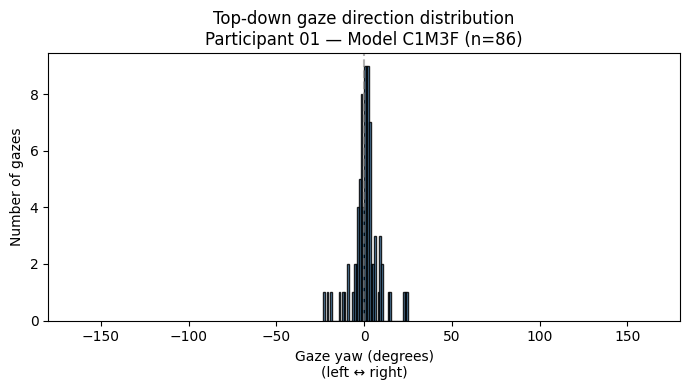

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# SETTINGS (change only PID if needed)
# -------------------------------
MODEL = "C1M3F"

# pick the first participant that appears in this model
PID = (
    object_gazes_final.loc[
        object_gazes_final["model_name"] == MODEL,
        "participant_id"
    ]
    .iloc[0]
)

# -------------------------------
# FILTER DATA
# -------------------------------
df_sub = object_gazes_final[
    (object_gazes_final["participant_id"] == PID) &
    (object_gazes_final["model_name"] == MODEL)
].copy()

# -------------------------------
# EXTRACT YAW VALUES
# -------------------------------
yaw = pd.to_numeric(df_sub["gaze_yaw_deg"], errors="coerce")
yaw = yaw[np.isfinite(yaw)]

# -------------------------------
# PLOT
# -------------------------------
plt.figure(figsize=(7, 4))

plt.hist(
    yaw,
    bins=50,
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

plt.axvline(0, color="gray", linestyle="--", alpha=0.6)

plt.xlabel("Gaze yaw (degrees)\n(left ↔ right)")
plt.ylabel("Number of gazes")
plt.title(
    f"Top-down gaze direction distribution\n"
    f"Participant {PID} — Model {MODEL} (n={len(yaw)})"
)

plt.xlim(-180, 180)
plt.tight_layout()
plt.show()


-  really small range in the gaze behaviour - seems unfitting with our experimental set up

# Compute gaze angles and store them in df DATAFRAME 2
This adds two new columns to your dataframe
✅ One row = one gaze = one direction

In [154]:
df= object_gazes_final

In [155]:
import numpy as np

# extract gaze forward vectors
gx = df['gaze_forward_x'].to_numpy(dtype=float)
gy = df['gaze_forward_y'].to_numpy(dtype=float)
gz = df['gaze_forward_z'].to_numpy(dtype=float)

# compute vector norm
norm = np.sqrt(gx**2 + gy**2 + gz**2)

# avoid division by zero
valid = norm > 0

gx_n = np.full_like(gx, np.nan)
gy_n = np.full_like(gy, np.nan)
gz_n = np.full_like(gz, np.nan)

gx_n[valid] = gx[valid] / norm[valid]
gy_n[valid] = gy[valid] / norm[valid]
gz_n[valid] = gz[valid] / norm[valid]

# compute gaze angles (Unity coordinate system)
df['gaze_yaw_deg'] = np.degrees(np.arctan2(gx_n, gz_n))
df['gaze_pitch_deg'] = np.degrees(np.arctan2(gy_n, gz_n))

df[['gaze_yaw_deg', 'gaze_pitch_deg']].head(10)
df[['gaze_yaw_deg', 'gaze_pitch_deg']].describe()

df = df.drop(columns=['gaze_angle_h', 'gaze_angle_v'], errors='ignore')

print(object_gazes_final.shape)
print(object_gazes_final.columns.tolist())



(38406, 30)
['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg', 'gaze_yaw_mean_deg']


In [156]:
df.head()


,participant_id,object_name,object_gaze_count,start_ms,end_ms,object_gaze_duration_ms,object_gaze_duration_s,hmd_position_x,hmd_position_y,hmd_position_z,...,is_valid_model,model_name,model_order,condition,gx,gy,gz,gaze_yaw_deg,gaze_pitch_deg,gaze_yaw_mean_deg
0,01,Wall_Front,1,1.754659e+12,1.754659e+12,3686.0,3.686,0.477676,1.740824,0.077520,...,False,None,NaN,NaN,0.000436,0.030192,1.000000,0.025000,1.730139,0.025000
1,01,Wall_Front,1,1.754659e+12,1.754659e+12,223.0,0.223,0.492838,1.710857,0.083775,...,False,None,NaN,NaN,0.026370,-0.087172,0.999652,1.511054,-5.002655,1.511054
2,01,work_desk_base.001,1,1.754659e+12,1.754659e+12,8257.0,8.257,0.517958,1.616920,0.068650,...,False,None,NaN,NaN,0.059081,-0.106786,0.998253,3.387082,-6.140720,3.387082
3,01,Floor,1,1.754659e+12,1.754659e+12,745.0,0.745,0.521836,1.486044,0.069793,...,False,None,NaN,NaN,0.004132,-0.256554,0.999991,0.236745,-14.865793,0.236745
4,01,PlaneRight,1,1.754659e+12,1.754659e+12,1011.0,1.011,0.383226,1.478859,-0.053755,...,False,None,NaN,NaN,0.072965,-0.241060,0.997335,4.184291,-13.984943,4.184291


In [157]:
df.columns


Index(['participant_id', 'object_name', 'object_gaze_count', 'start_ms',
       'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s',
       'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x',
       'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x',
       'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y',
       'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order',
       'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg',
       'gaze_yaw_mean_deg'],
      dtype='object')

# Show existing columns in object gaze dataframe

In [158]:
df.columns


Index(['participant_id', 'object_name', 'object_gaze_count', 'start_ms',
       'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s',
       'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x',
       'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x',
       'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y',
       'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order',
       'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg',
       'gaze_yaw_mean_deg'],
      dtype='object')

# Normalize vectors and compute gazes per angles gespeichert in df - unnötig!!!!

In [159]:
import numpy as np

df['gaze_yaw_deg']   = np.degrees(np.arctan2(df['gaze_forward_x'], df['gaze_forward_z']))
df['gaze_pitch_deg'] = np.degrees(np.arctan2(df['gaze_forward_y'], df['gaze_forward_z']))



In [160]:
import numpy as np

# Extract vectors
gx = df['gaze_forward_x'].to_numpy(dtype=float)
gy = df['gaze_forward_y'].to_numpy(dtype=float)
gz = df['gaze_forward_z'].to_numpy(dtype=float)

# Normalize (optional but recommended)
norm = np.sqrt(gx*gx + gy*gy + gz*gz)

# Avoid division by zero
valid = norm > 0
gx_n = np.full_like(gx, np.nan)
gy_n = np.full_like(gy, np.nan)
gz_n = np.full_like(gz, np.nan)

gx_n[valid] = gx[valid] / norm[valid]
gy_n[valid] = gy[valid] / norm[valid]
gz_n[valid] = gz[valid] / norm[valid]

# Angles (Unity: yaw = atan2(x, z), pitch = atan2(y, z))
df['gaze_yaw_deg']   = np.degrees(np.arctan2(gx_n, gz_n))
df['gaze_pitch_deg'] = np.degrees(np.arctan2(gy_n, gz_n))


df[['gaze_forward_x','gaze_forward_y','gaze_forward_z','gaze_yaw_deg','gaze_pitch_deg']].head(10)
df[['gaze_yaw_deg','gaze_pitch_deg']].describe()



,gaze_yaw_deg,gaze_pitch_deg
count,38406.000000,38406.000000
mean,1.470205,-5.400174
std,10.169791,8.833535
min,-84.683881,-45.965299
25%,-3.923341,-11.818432
50%,1.588771,-6.057817
75%,7.444518,0.392138
max,48.246704,87.112953


In [161]:
print("object_gazes_final has gaze_yaw_deg?", "gaze_yaw_deg" in object_gazes_final.columns)
print("df has gaze_yaw_deg?", "gaze_yaw_deg" in df.columns if 'df' in globals() else "df not defined")


object_gazes_final has gaze_yaw_deg? True
df has gaze_yaw_deg? True


# Plot it the Gaze direcitons ( realizing they are definitely local and no world vectors)

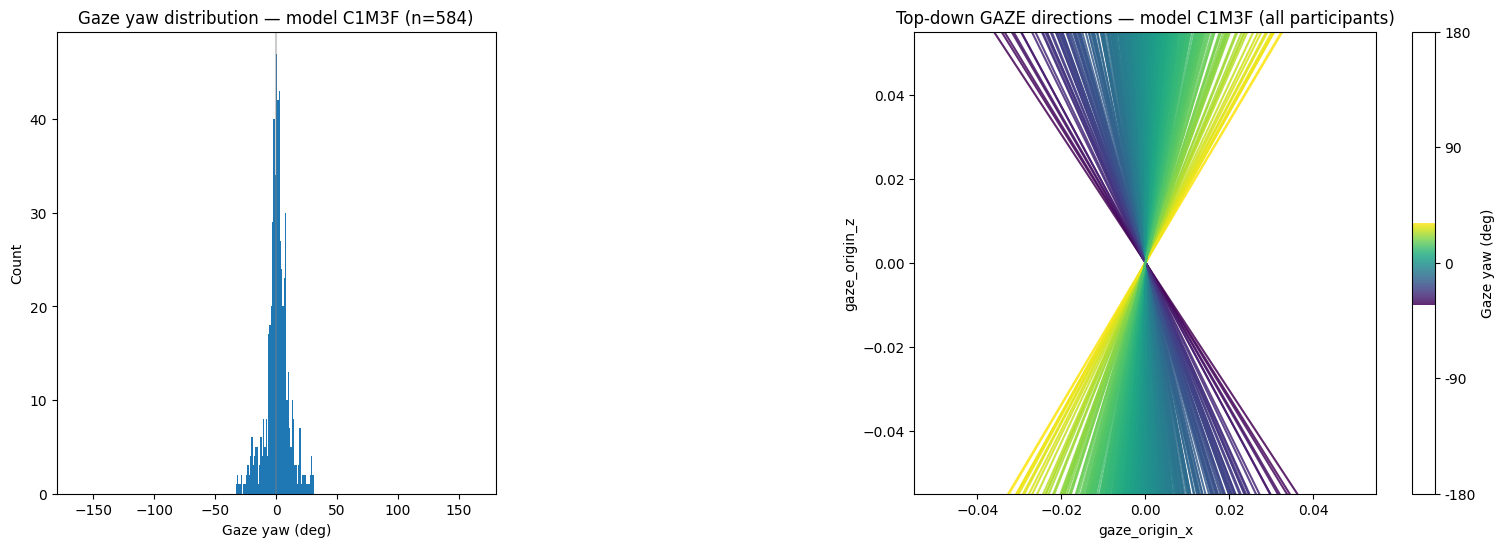

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

# -------------------------------
# Use the MASTER dataframe
# -------------------------------
df = object_gazes_final.copy()

# Filter to one model
df = df[df["model_name"].astype(str) == MODEL]

# Optional: keep only valid model segments
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

# -------------------------------
# Columns (GAZE, not HMD)
# -------------------------------
YAW_COL = "gaze_yaw_deg"

# Where the arrows start (top-down)
# Recommended: gaze origin
X_COL = "gaze_origin_x"
Z_COL = "gaze_origin_z"

# -------------------------------
# Clean numeric
# -------------------------------
yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# -------------------------------
# FIGURE (same layout as before)
# -------------------------------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)
fig.subplots_adjust(wspace=0.12)

# -------------------------------
# HISTOGRAM (gaze yaw)
# -------------------------------
ax_hist.hist(yaw, bins=60)
ax_hist.set_xlabel("Gaze yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Gaze yaw distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)
ax_hist.axvline(0, color="gray", alpha=0.4)

# -------------------------------
# TOP-DOWN ARROWS (gaze direction)
# -------------------------------
yaw_rad = np.deg2rad(yaw)

# Unity convention:
# yaw = 0 → +Z
# positive yaw → +X
u = np.sin(yaw_rad)   # x component
v = np.cos(yaw_rad)   # z component

# Thin arrows if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# Color by yaw angle
c = (yaw_ + 180.0) / 360.0

q = ax_top.quiver(
    x_, z_, u_, v_, c,
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.0045,
    alpha=0.85,
    pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down GAZE directions — model {MODEL} (all participants)")

# Colorbar
cb = fig.colorbar(q, ax=ax_top, fraction=0.046, pad=0.04)
cb.set_label("Gaze yaw (deg)")
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.set_ticklabels(["-180", "-90", "0", "90", "180"])

plt.show()


Number of gazes (rows): 584


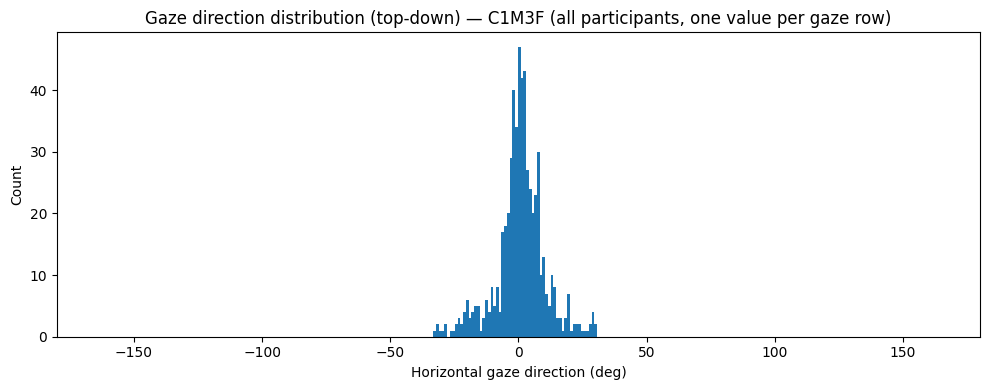

In [163]:
import numpy as np
import matplotlib.pyplot as plt

MODEL = "C1M3F"

df = object_gazes_final.copy()
df = df[df["model_name"].astype(str) == MODEL]

# keep rows that have gaze direction
df = df.dropna(subset=["gaze_forward_x", "gaze_forward_z"]).copy()

# horizontal projection + normalization (direction only)
eps = 1e-9
h = np.sqrt(df["gaze_forward_x"]**2 + df["gaze_forward_z"]**2)
gx = df["gaze_forward_x"] / (h + eps)
gz = df["gaze_forward_z"] / (h + eps)

# horizontal angle per gaze (NOT aggregation)
df["gaze_yaw_deg"] = np.degrees(np.arctan2(gx, gz))

print("Number of gazes (rows):", len(df))

plt.figure(figsize=(10,4))
plt.hist(df["gaze_yaw_deg"], bins=60)
plt.xlim(-180, 180)
plt.xlabel("Horizontal gaze direction (deg)")
plt.ylabel("Count")
plt.title(f"Gaze direction distribution (top-down) — {MODEL} (all participants, one value per gaze row)")
plt.tight_layout()
plt.show()


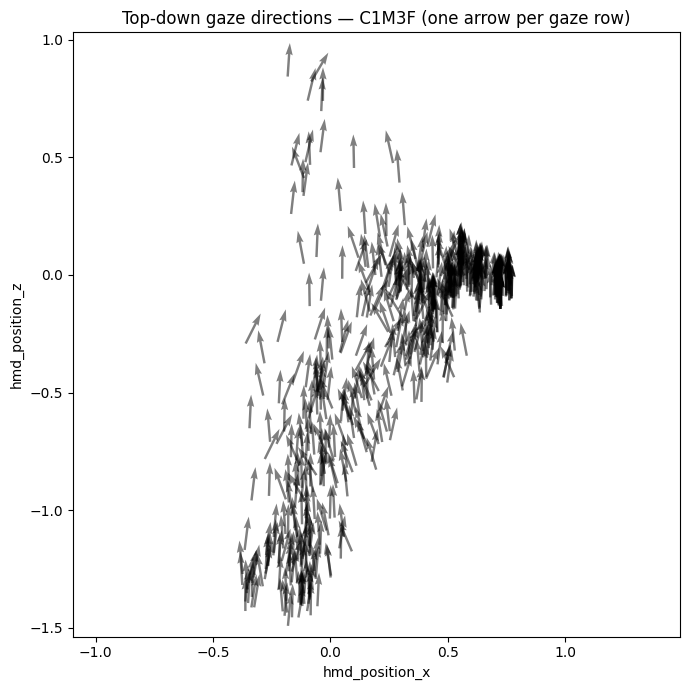

In [164]:
import numpy as np
import matplotlib.pyplot as plt

MODEL = "C1M3F"
MAX_ARROWS = 4000  # just for visibility; not aggregation, only downsampling for plotting

df = object_gazes_final.copy()
df = df[df["model_name"].astype(str) == MODEL]

# choose arrow origin: use gaze_origin_* if you want, otherwise hmd_position_*
ORIGIN_X, ORIGIN_Z = "hmd_position_x", "hmd_position_z"
# ORIGIN_X, ORIGIN_Z = "gaze_origin_x", "gaze_origin_z"  # alternative

df = df.dropna(subset=[ORIGIN_X, ORIGIN_Z, "gaze_forward_x", "gaze_forward_z"]).copy()

# normalize horizontal direction (so arrow length is consistent)
eps = 1e-9
h = np.sqrt(df["gaze_forward_x"]**2 + df["gaze_forward_z"]**2)
df["gx"] = df["gaze_forward_x"] / (h + eps)
df["gz"] = df["gaze_forward_z"] / (h + eps)

# downsample ONLY for drawing (otherwise it turns into a black blob)
if len(df) > MAX_ARROWS:
    df_plot = df.sample(MAX_ARROWS, random_state=0)
else:
    df_plot = df

plt.figure(figsize=(7,7))
plt.quiver(
    df_plot[ORIGIN_X], df_plot[ORIGIN_Z],
    df_plot["gx"], df_plot["gz"],
    angles="xy", scale_units="xy", scale=7,
    width=0.004, alpha=0.5, pivot="mid"
)
plt.axis("equal")
plt.xlabel(ORIGIN_X)
plt.ylabel(ORIGIN_Z)
plt.title(f"Top-down gaze directions — {MODEL} (one arrow per gaze row)")
plt.tight_layout()
plt.show()


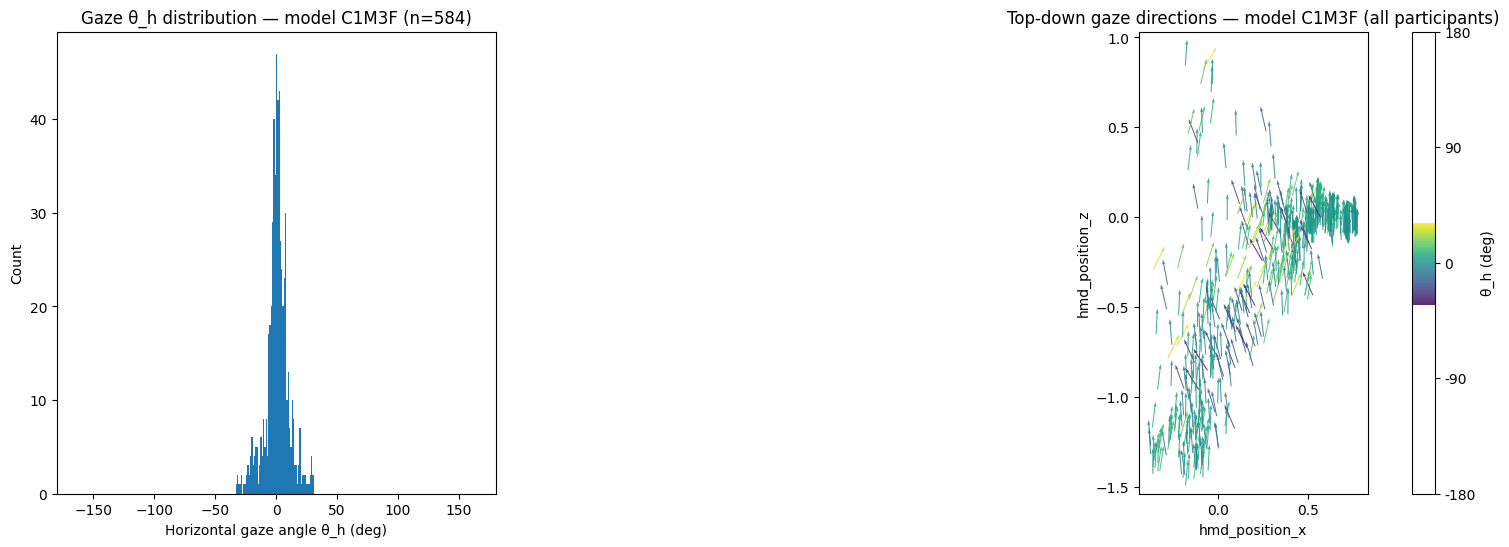

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

# Choose where arrows start (pick ONE):
# Option A (simple): head position
ORIGIN_X, ORIGIN_Z = "hmd_position_x", "hmd_position_z"
# Option B (often more precise): eye/gaze origin
# ORIGIN_X, ORIGIN_Z = "gaze_origin_x", "gaze_origin_z"

df = object_gazes_final.copy()

# --- Filter to the model ---
df = df[df["model_name"].astype(str) == MODEL]

# Optional: keep only gazes where the model was valid at least once in that gaze segment
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

# --- Keep rows with everything needed for angle + top-down arrows ---
needed = [ORIGIN_X, ORIGIN_Z, "gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
df = df.dropna(subset=needed).copy()

# --- Horizontal direction from gaze_forward (project to X–Z plane) ---
eps = 1e-9
h = np.sqrt(df["gaze_forward_x"]**2 + df["gaze_forward_z"]**2)

gx = df["gaze_forward_x"] / (h + eps)
gz = df["gaze_forward_z"] / (h + eps)

# --- Supervisor formula (robust): theta_h = degrees(atan2(x, z)) ---
df["theta_h_deg"] = np.degrees(np.arctan2(gx, gz))  # range [-180, 180]

# Arrays
yaw = df["theta_h_deg"].to_numpy()
x = df[ORIGIN_X].to_numpy()
z = df[ORIGIN_Z].to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]
gx, gz = gx.to_numpy()[mask], gz.to_numpy()[mask]

# ---------- FIGURE (same style as your head yaw plot) ----------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)
fig.subplots_adjust(wspace=0.12)

# ---------- HISTOGRAM ----------
ax_hist.hist(yaw, bins=60)
ax_hist.set_xlabel("Horizontal gaze angle θ_h (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Gaze θ_h distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)

# ---------- TOP-DOWN ARROWS ----------
# Downsample ONLY for drawing clarity (does not change your data)
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, gx_, gz_, yaw_ = x[idx], z[idx], gx[idx], gz[idx], yaw[idx]
else:
    x_, z_, gx_, gz_, yaw_ = x, z, gx, gz, yaw

# Color by angle (-180..180) mapped to 0..1
c = (yaw_ + 180.0) / 360.0

q = ax_top.quiver(
    x_, z_, gx_, gz_, c,
    angles="xy",
    scale_units="xy",
    scale=7,          # smaller -> longer arrows
    width=0.0045,
    alpha=0.85,
    pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(ORIGIN_X)
ax_top.set_ylabel(ORIGIN_Z)
ax_top.set_title(f"Top-down gaze directions — model {MODEL} (all participants)")

cb = fig.colorbar(q, ax=ax_top, fraction=0.046, pad=0.05)
cb.set_label("θ_h (deg)")
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.set_ticklabels(["-180", "-90", "0", "90", "180"])

plt.show()


## Cell 5 — Compute horizontal head rotation (yaw) per gaze as CHECK

This cell derives **horizontal head-rotation angles (yaw)** for each gaze using
the HMD quaternions from `raw_all` and the gaze intervals from
`object_gazes_final`.

Steps:

1. Convert `raw_timestamp` in `raw_all` to milliseconds (`ts_ms`) so it matches
   the gaze time scale.
2. For every raw sample, compute a **per-sample yaw angle** in degrees from the
   HMD quaternion by rotating the forward vector (0, 0, 1) and taking the angle
   in the XZ-plane.
3. Match raw samples to each gaze using `participant_id` and the gaze’s
   `[start_ms, end_ms]` interval.
4. For every gaze, compute:
   - `hmd_yaw_start_deg`: yaw of the **first sample** in the gaze,
   - `hmd_yaw_mean_deg`: the **mean yaw** over all samples within the gaze.
5. Add these as new columns to `object_gazes_final`. The old single yaw column
   (`hmd_yaw_deg`) can optionally be dropped.

The resulting `object_gazes_final` now contains both **start** and **mean**
horizontal head-rotation angles for each gaze, which can be used to estimate
AOIs or head-orientation patterns in your VR scene.



In [166]:
# ===================== HORIZONTAL HEAD-ROTATION (YAW): START & MEAN PER GAZE =====================
import numpy as np
import pandas as pd

def quaternion_to_yaw_deg(x, y, z, w):
    q_vec = np.array([x, y, z], dtype=float)
    v = np.array([0.0, 0.0, 1.0], dtype=float)
    t = 2.0 * np.cross(q_vec, v)
    v_prime = v + w * t + np.cross(q_vec, t)
    yaw_rad = np.arctan2(v_prime[0], v_prime[2])
    return float(np.degrees(yaw_rad))

if not object_gazes_final.empty:
    # 1) Ensure raw_all has timestamps in ms consistent with the gaze dataframe
    raw_all = raw_all.copy()
    raw_all["raw_timestamp"] = pd.to_numeric(raw_all["raw_timestamp"], errors="coerce")
    raw_all = raw_all.dropna(subset=["raw_timestamp"]).sort_values("raw_timestamp")
    raw_all["ts_ms"] = raw_all["raw_timestamp"] * to_ms_multiplier_forced()

    # 2) Compute per-sample yaw from raw quaternions (FAST, vectorized)
    x = raw_all["hmd_rotation_x"].to_numpy(dtype=float)
    y = raw_all["hmd_rotation_y"].to_numpy(dtype=float)
    z = raw_all["hmd_rotation_z"].to_numpy(dtype=float)
    w = raw_all["hmd_rotation_w"].to_numpy(dtype=float)

    # Based on rotating forward vector (0,0,1) by quaternion (x,y,z,w)
    tx = 2.0 * y
    ty = -2.0 * x

    cx = -z * ty
    cz = x * ty - y * tx

    vpx = w * tx + cx
    vpz = 1.0 + cz

    raw_all["hmd_yaw_deg_sample"] = np.degrees(np.arctan2(vpx, vpz))

    # 3) Align participant IDs between raw_all and object_gazes_final
    # ✅ UID gibt es nicht mehr → nutze participant_id (und normalisiere ggf.)
    if "participant_id" not in raw_all.columns:
        raise KeyError("raw_all hat keine Spalte 'participant_id'. (UID ist entfernt worden.)")
    raw_all["participant_id"] = raw_all["participant_id"].astype(str).str.strip().str.lstrip("0")
    raw_all["participant_id"] = raw_all["participant_id"].replace("", np.nan).dropna()
    raw_all["participant_id"] = raw_all["participant_id"].astype(int).astype(str).str.zfill(2)

    # Auch in object_gazes_final sicherstellen (falls noch nicht zfill)
    object_gazes_final["participant_id"] = (
        object_gazes_final["participant_id"].astype(str).str.strip().str.lstrip("0")
    )
    object_gazes_final["participant_id"] = object_gazes_final["participant_id"].replace("", np.nan)
    object_gazes_final["participant_id"] = object_gazes_final["participant_id"].astype(int).astype(str).str.zfill(2)

    # 4) For each participant + gaze, compute start & mean yaw from the samples
    def add_yaw_stats_for_participant(gaze_df_participant):
        pid = gaze_df_participant.name
        df_raw_p = raw_all[raw_all["participant_id"] == pid].sort_values("ts_ms")

        ts = df_raw_p["ts_ms"].to_numpy()
        yaw = df_raw_p["hmd_yaw_deg_sample"].to_numpy()

        start_yaws = []
        mean_yaws = []

        for gaze_row in gaze_df_participant.itertuples(index=False):
            start_ms = gaze_row.start_ms
            end_ms = gaze_row.end_ms

            l = np.searchsorted(ts, start_ms, side="left")
            r = np.searchsorted(ts, end_ms, side="right")

            if l >= r:
                start_yaws.append(np.nan)
                mean_yaws.append(np.nan)
            else:
                seg = yaw[l:r]  # signed, -180..180
                start_yaws.append(float(seg[0]))

                # circular mean (still -180..180)
                seg_rad = np.deg2rad(seg)
                mean_rad = np.arctan2(
                    np.mean(np.sin(seg_rad)),
                    np.mean(np.cos(seg_rad))
                )
                mean_yaws.append(float(np.degrees(mean_rad)))

        out = gaze_df_participant.copy()
        out["hmd_yaw_start_deg"] = start_yaws
        out["hmd_yaw_mean_deg"] = mean_yaws
        return out

    object_gazes_final = (
        object_gazes_final
        .groupby("participant_id", group_keys=False)
        .apply(add_yaw_stats_for_participant)
        .reset_index(drop=True)
    )

    if "hmd_yaw_deg" in object_gazes_final.columns:
        object_gazes_final = object_gazes_final.drop(columns=["hmd_yaw_deg"])

print("object_gazes_final with start & mean yaw shape:", object_gazes_final.shape)
object_gazes_final.head()


object_gazes_final with start & mean yaw shape: (38406, 32)


/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1415/238714858.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_yaw_stats_for_participant)


,participant_id,object_name,object_gaze_count,start_ms,end_ms,object_gaze_duration_ms,object_gaze_duration_s,hmd_position_x,hmd_position_y,hmd_position_z,...,model_order,condition,gx,gy,gz,gaze_yaw_deg,gaze_pitch_deg,gaze_yaw_mean_deg,hmd_yaw_start_deg,hmd_yaw_mean_deg
0,01,Wall_Front,1,1.754659e+12,1.754659e+12,3686.0,3.686,0.477676,1.740824,0.077520,...,NaN,NaN,0.000436,0.030192,1.000000,0.025000,1.730139,0.025000,94.146528,93.857525
1,01,Wall_Front,1,1.754659e+12,1.754659e+12,223.0,0.223,0.492838,1.710857,0.083775,...,NaN,NaN,0.026370,-0.087172,0.999652,1.511054,-5.002655,1.511054,92.781248,92.295405
2,01,work_desk_base.001,1,1.754659e+12,1.754659e+12,8257.0,8.257,0.517958,1.616920,0.068650,...,NaN,NaN,0.059081,-0.106786,0.998253,3.387082,-6.140720,3.387082,91.703247,98.026025
3,01,Floor,1,1.754659e+12,1.754659e+12,745.0,0.745,0.521836,1.486044,0.069793,...,NaN,NaN,0.004132,-0.256554,0.999991,0.236745,-14.865793,0.236745,99.544513,111.668939
4,01,PlaneRight,1,1.754659e+12,1.754659e+12,1011.0,1.011,0.383226,1.478859,-0.053755,...,NaN,NaN,0.072965,-0.241060,0.997335,4.184291,-13.984943,4.184291,110.823584,109.940992


# Add CANONICAL START AND MEAN YAW AS COLUMNS

In [167]:
import numpy as np

def canonical_deg_180(angle_deg):
    """
    Map degrees to canonical interval [-180, 180).
    180 becomes -180. Works with scalars or arrays/Series.
    """
    a = np.asarray(angle_deg, dtype=float)
    out = (a + 180.0) % 360.0 - 180.0
    # keep NaNs as NaN (mod on NaN stays NaN, but this is explicit)
    out = np.where(np.isnan(a), np.nan, out)
    return out

# Add canonical versions for your gaze-level stats
object_gazes_final["hmd_yaw_start_deg_canon"] = canonical_deg_180(object_gazes_final["hmd_yaw_start_deg"])
object_gazes_final["hmd_yaw_mean_deg_canon"]  = canonical_deg_180(object_gazes_final["hmd_yaw_mean_deg"])


# Dataframe columns

In [168]:
# 2) Print one column per line
for c in object_gazes_final.columns:
    print(c)


participant_id
object_name
object_gaze_count
start_ms
end_ms
object_gaze_duration_ms
object_gaze_duration_s
hmd_position_x
hmd_position_y
hmd_position_z
hmd_rotation_x
hmd_rotation_y
hmd_rotation_z
hmd_rotation_w
gaze_forward_x
gaze_forward_y
gaze_forward_z
gaze_origin_x
gaze_origin_y
gaze_origin_z
is_valid_model
model_name
model_order
condition
gx
gy
gz
gaze_yaw_deg
gaze_pitch_deg
gaze_yaw_mean_deg
hmd_yaw_start_deg
hmd_yaw_mean_deg
hmd_yaw_start_deg_canon
hmd_yaw_mean_deg_canon


# Is gaze origin in world space? ( it is non existing we need to take head (hmd) position)

In [169]:
cols = ['gaze_origin_x','gaze_origin_y','gaze_origin_z']
print(object_gazes_final[cols].nunique())


gaze_origin_x    1
gaze_origin_y    1
gaze_origin_z    1
dtype: int64


In [170]:
object_gazes_final[cols].agg(['min','max','std'])


,gaze_origin_x,gaze_origin_y,gaze_origin_z
min,0.0,0.0,0.0
max,0.0,0.0,0.0
std,0.0,0.0,0.0


# Is gaze_forward_* world space?

In [171]:
object_gazes_final[['gx','gy','gz']].agg(['mean','std','min','max'])


,gx,gy,gz
mean,0.025473,-0.092590,0.984088
std,0.173776,0.149671,0.026912
min,-0.995699,-0.716216,0.092651
max,0.746019,0.878316,1.000000


# Does gaze rotate with head?” (this is the definitive test)

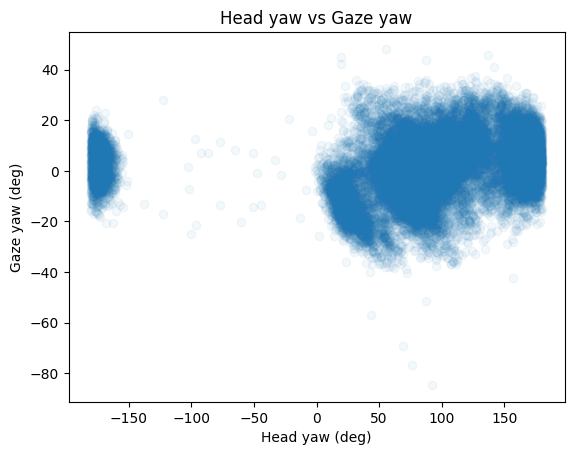

In [172]:
import matplotlib.pyplot as plt
plt.scatter(object_gazes_final['hmd_yaw_mean_deg'],
            object_gazes_final['gaze_yaw_deg'],
            alpha=0.05)
plt.xlabel("Head yaw (deg)")
plt.ylabel("Gaze yaw (deg)")
plt.title("Head yaw vs Gaze yaw")
plt.show()


# TURN LOCAL GAZE INTO WORLD GAZE
- they are called then gaze_world_x/y/z

## Create a validity mask (so we only rotate good rows)

In [173]:
import numpy as np
import pandas as pd

df = object_gazes_final

# numeric arrays
gx = pd.to_numeric(df["gx"], errors="coerce").to_numpy()
gy = pd.to_numeric(df["gy"], errors="coerce").to_numpy()
gz = pd.to_numeric(df["gz"], errors="coerce").to_numpy()

qx = pd.to_numeric(df["hmd_rotation_x"], errors="coerce").to_numpy()
qy = pd.to_numeric(df["hmd_rotation_y"], errors="coerce").to_numpy()
qz = pd.to_numeric(df["hmd_rotation_z"], errors="coerce").to_numpy()
qw = pd.to_numeric(df["hmd_rotation_w"], errors="coerce").to_numpy()

# vector + quaternion norms
vnorm = np.sqrt(gx*gx + gy*gy + gz*gz)
qnorm = np.sqrt(qx*qx + qy*qy + qz*qz + qw*qw)

valid = np.isfinite(vnorm) & (vnorm > 0) & np.isfinite(qnorm) & (qnorm > 0)
valid.sum(), len(valid)


(np.int64(38406), 38406)

# Normalize the quarternion

In [174]:
# Normalize quaternion for valid rows
qx_n = qx.copy().astype(float)
qy_n = qy.copy().astype(float)
qz_n = qz.copy().astype(float)
qw_n = qw.copy().astype(float)

qx_n[valid] = qx[valid] / qnorm[valid]
qy_n[valid] = qy[valid] / qnorm[valid]
qz_n[valid] = qz[valid] / qnorm[valid]
qw_n[valid] = qw[valid] / qnorm[valid]


# Rotate gaze_local → gaze_world (the main step)

In [175]:
def quat_rotate_vec(qx, qy, qz, qw, vx, vy, vz):
    """
    Rotate vector v by quaternion q (x,y,z,w) using:
    v' = v + qw*t + cross(q.xyz, t), where t = 2*cross(q.xyz, v)
    """
    tx = 2 * (qy * vz - qz * vy)
    ty = 2 * (qz * vx - qx * vz)
    tz = 2 * (qx * vy - qy * vx)

    vpx = vx + qw * tx + (qy * tz - qz * ty)
    vpy = vy + qw * ty + (qz * tx - qx * tz)
    vpz = vz + qw * tz + (qx * ty - qy * tx)
    return vpx, vpy, vpz

# Allocate output
gaze_world_x = np.full(len(df), np.nan, dtype=float)
gaze_world_y = np.full(len(df), np.nan, dtype=float)
gaze_world_z = np.full(len(df), np.nan, dtype=float)

gwx, gwy, gwz = quat_rotate_vec(qx_n[valid], qy_n[valid], qz_n[valid], qw_n[valid],
                                gx[valid], gy[valid], gz[valid])

gaze_world_x[valid] = gwx
gaze_world_y[valid] = gwy
gaze_world_z[valid] = gwz

df["gaze_world_x"] = gaze_world_x
df["gaze_world_y"] = gaze_world_y
df["gaze_world_z"] = gaze_world_z


# Recompute world yaw/pitch from gaze_world - final gaze directions are called gaze_world(xyz)
-  local gaze gx gy gzy

In [176]:
df["gaze_world_yaw_deg"] = np.degrees(np.arctan2(df["gaze_world_x"], df["gaze_world_z"]))

# better pitch definition (stable)
df["gaze_world_pitch_deg"] = np.degrees(
    np.arctan2(df["gaze_world_y"], np.sqrt(df["gaze_world_x"]**2 + df["gaze_world_z"]**2))
)


# Gaze world YAW in object gazesf final gespeichert

In [177]:
# ===================== COMPUTE WORLD-SPACE GAZE YAW =====================

object_gazes_final["gaze_world_yaw_deg"] = np.degrees(
    np.arctan2(
        object_gazes_final["gaze_world_x"],
        object_gazes_final["gaze_world_z"]
    )
)

display(
    object_gazes_final[
        ["gaze_world_x", "gaze_world_z", "gaze_world_yaw_deg"]
    ].head()
)

display(object_gazes_final["gaze_world_yaw_deg"].describe())

,gaze_world_x,gaze_world_z,gaze_world_yaw_deg
0,0.998066,-0.068914,93.949862
1,0.934370,-0.063003,93.857516
2,0.552866,-0.140443,104.253205
3,-0.070766,-0.047723,-123.994774
4,-0.051783,-0.133061,-158.735649


count    38406.000000
mean        67.590959
std         88.027508
min       -179.990333
25%         59.817539
50%         87.864739
75%        110.410016
max        179.999624
Name: gaze_world_yaw_deg, dtype: float64

# Quick sanity checks (to confirm it worked)

In [178]:
# 1) world gaze should NOT be "mostly gz~0.97" anymore across head turns
df[["gaze_world_x", "gaze_world_y", "gaze_world_z"]].describe()


,gaze_world_x,gaze_world_y,gaze_world_z
count,38406.000000,38406.000000,38406.000000
mean,0.496970,-0.596024,-0.099843
std,0.336743,0.254472,0.490552
min,-0.987494,-1.181698,-1.129792
25%,0.272909,-0.807693,-0.494811
50%,0.547894,-0.619473,-0.040176
75%,0.763543,-0.427839,0.183225
max,1.118725,0.852977,1.059083


# Define our world origin for plotting (use HMD position)

In [179]:
df[["hmd_position_x","hmd_position_z","gx","gz","gaze_world_x","gaze_world_z"]].head()


,hmd_position_x,hmd_position_z,gx,gz,gaze_world_x,gaze_world_z
0,0.477676,0.077520,0.000436,1.000000,0.998066,-0.068914
1,0.492838,0.083775,0.026370,0.999652,0.934370,-0.063003
2,0.517958,0.068650,0.059081,0.998253,0.552866,-0.140443
3,0.521836,0.069793,0.004132,0.999991,-0.070766,-0.047723
4,0.383226,-0.053755,0.072965,0.997335,-0.051783,-0.133061


In [180]:
print("gaze_world_x in object_gazes_final?", "gaze_world_x" in object_gazes_final.columns)
print("gaze_world_x in df?", "gaze_world_x" in df.columns)


gaze_world_x in object_gazes_final? True
gaze_world_x in df? True


# Create all angles we need in object gaze final - direkt in objgazes final gespeichert und heißt: df["gaze_world_x"] = gwx
df["gaze_world_y"] = gwy
df["gaze_world_z"] = gwz

In [181]:
import numpy as np
import pandas as pd

df = object_gazes_final  # IMPORTANT: no .copy() here

# Local gaze direction (normalized)
vx = pd.to_numeric(df["gx"], errors="coerce").to_numpy()
vy = pd.to_numeric(df["gy"], errors="coerce").to_numpy()
vz = pd.to_numeric(df["gz"], errors="coerce").to_numpy()

# HMD quaternion (x,y,z,w)
qx = pd.to_numeric(df["hmd_rotation_x"], errors="coerce").to_numpy()
qy = pd.to_numeric(df["hmd_rotation_y"], errors="coerce").to_numpy()
qz = pd.to_numeric(df["hmd_rotation_z"], errors="coerce").to_numpy()
qw = pd.to_numeric(df["hmd_rotation_w"], errors="coerce").to_numpy()

# Validity mask
vnorm = np.sqrt(vx*vx + vy*vy + vz*vz)
qnorm = np.sqrt(qx*qx + qy*qy + qz*qz + qw*qw)
valid = np.isfinite(vnorm) & (vnorm > 0) & np.isfinite(qnorm) & (qnorm > 0)

# Normalize quaternion
qx_n = np.full(len(df), np.nan, dtype=float)
qy_n = np.full(len(df), np.nan, dtype=float)
qz_n = np.full(len(df), np.nan, dtype=float)
qw_n = np.full(len(df), np.nan, dtype=float)

qx_n[valid] = qx[valid] / qnorm[valid]
qy_n[valid] = qy[valid] / qnorm[valid]
qz_n[valid] = qz[valid] / qnorm[valid]
qw_n[valid] = qw[valid] / qnorm[valid]

def quat_rotate_vec(qx, qy, qz, qw, vx, vy, vz):
    # t = 2 * cross(q.xyz, v)
    tx = 2 * (qy * vz - qz * vy)
    ty = 2 * (qz * vx - qx * vz)
    tz = 2 * (qx * vy - qy * vx)
    # v' = v + qw*t + cross(q.xyz, t)
    vpx = vx + qw * tx + (qy * tz - qz * ty)
    vpy = vy + qw * ty + (qz * tx - qx * tz)
    vpz = vz + qw * tz + (qx * ty - qy * tx)
    return vpx, vpy, vpz

# Rotate valid rows
gwx = np.full(len(df), np.nan, dtype=float)
gwy = np.full(len(df), np.nan, dtype=float)
gwz = np.full(len(df), np.nan, dtype=float)

rwx, rwy, rwz = quat_rotate_vec(
    qx_n[valid], qy_n[valid], qz_n[valid], qw_n[valid],
    vx[valid], vy[valid], vz[valid]
)

gwx[valid] = rwx
gwy[valid] = rwy
gwz[valid] = rwz

# Write into the SAME dataframe
df["gaze_world_x"] = gwx
df["gaze_world_y"] = gwy
df["gaze_world_z"] = gwz

print("Created gaze_world_* columns. Non-NaN rows:", np.isfinite(df["gaze_world_x"]).sum())


Created gaze_world_* columns. Non-NaN rows: 38406


In [182]:
print("gaze_world_x in object_gazes_final?", "gaze_world_x" in object_gazes_final.columns)
object_gazes_final[["gaze_world_x","gaze_world_y","gaze_world_z"]].head()
object_gazes_final.head


gaze_world_x in object_gazes_final? True


<bound method NDFrame.head of       participant_id         object_name  object_gaze_count      start_ms  \
0                 01          Wall_Front                  1  1.754659e+12   
1                 01          Wall_Front                  1  1.754659e+12   
2                 01  work_desk_base.001                  1  1.754659e+12   
3                 01               Floor                  1  1.754659e+12   
4                 01          PlaneRight                  1  1.754659e+12   
...              ...                 ...                ...           ...   
38401             10     QuestionButton3                  1  1.756802e+12   
38402             10  work_desk_base.001                  1  1.756802e+12   
38403             10     QuestionButton2                  1  1.756802e+12   
38404             10     QuestionButton3                  1  1.756802e+12   
38405             10  work_desk_base.001                  1  1.756802e+12   

             end_ms  object_gaze_duration_ms 

# Distribution of world vector GAZE

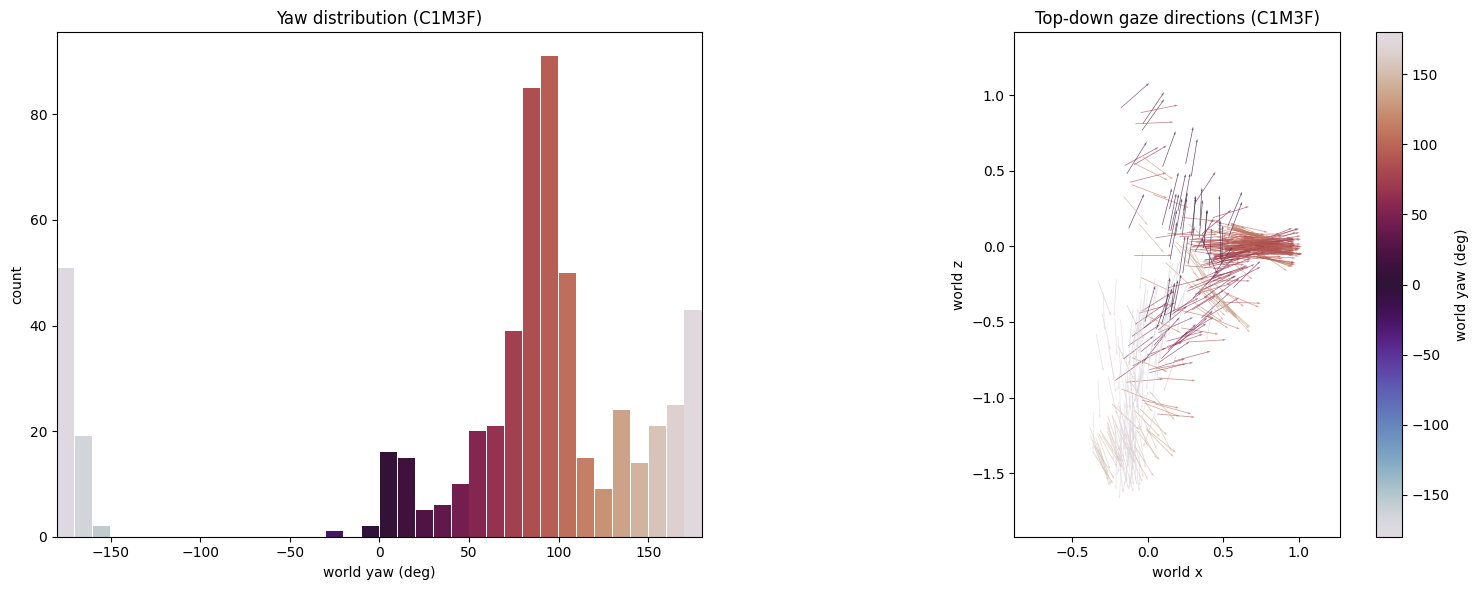

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

df = object_gazes_final.copy()

# --- Filter to model C1M3F ---
dfm = df[df["model_name"].astype(str).eq("C1M3F")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# --- Start points (top-down plane) ---
x0 = dfm["hmd_position_x"].to_numpy()
z0 = dfm["hmd_position_z"].to_numpy()

# --- Directions (world gaze) ---
dx = dfm["gaze_world_x"].to_numpy()
dz = dfm["gaze_world_z"].to_numpy()

# --- World yaw for coloring ---
yaw = np.degrees(np.arctan2(dx, dz))
yaw = (yaw + 180) % 360 - 180

# --- Valid rows ---
mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, yaw = x0[mask], z0[mask], dx[mask], dz[mask], yaw[mask]

# --- Normalize directions in XZ plane ---
d2 = np.sqrt(dx*dx + dz*dz)
good = d2 > 0
x0, z0, dx, dz, yaw, d2 = x0[good], z0[good], dx[good], dz[good], yaw[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# --- Downsample arrows for readability ---
target_arrows = 3000
step = max(1, len(yaw) // target_arrows)
idx = np.arange(0, len(yaw), step)

# --- Color mapping ---
cmap = plt.get_cmap("twilight")
norm = Normalize(vmin=-180, vmax=180)

# --- Create figure: histogram LEFT, arrows RIGHT ---
fig, (ax_hist, ax_map) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [1, 1.4]}
)

# =========================
# Histogram (LEFT)
# =========================
bins = np.linspace(-180, 180, 37)  # 10-degree bins
counts, edges = np.histogram(yaw, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
bar_colors = cmap(norm(centers))

ax_hist.bar(
    centers, counts,
    width=(edges[1] - edges[0]) * 0.95,
    color=bar_colors,
    edgecolor="none"
)
ax_hist.set_xlabel("world yaw (deg)")
ax_hist.set_ylabel("count")
ax_hist.set_title("Yaw distribution (C1M3F)")
ax_hist.set_xlim(-180, 180)

# =========================
# Top-down arrow plot (RIGHT)
# =========================
ax_map.quiver(
    x0[idx], z0[idx], u[idx], v[idx],
    color=cmap(norm(yaw[idx])),
    angles="xy", scale_units="xy", scale=1,
    width=0.0022, alpha=0.7
)

ax_map.set_aspect("equal", adjustable="box")
ax_map.set_xlabel("world x")
ax_map.set_ylabel("world z")
ax_map.set_title("Top-down gaze directions (C1M3F)")

# --- Add padding so plot is not squeezed ---
pad = 0.5  # meters (adjust if needed)
ax_map.set_xlim(x0.min() - pad, x0.max() + pad)
ax_map.set_ylim(z0.min() - pad, z0.max() + pad)

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_map, fraction=0.046, pad=0.04)
cbar.set_label("world yaw (deg)")

plt.tight_layout()
plt.show()


- diese verteilung nutzt schon world gaze aus object gazes final

# Cluster this distirbution by eye

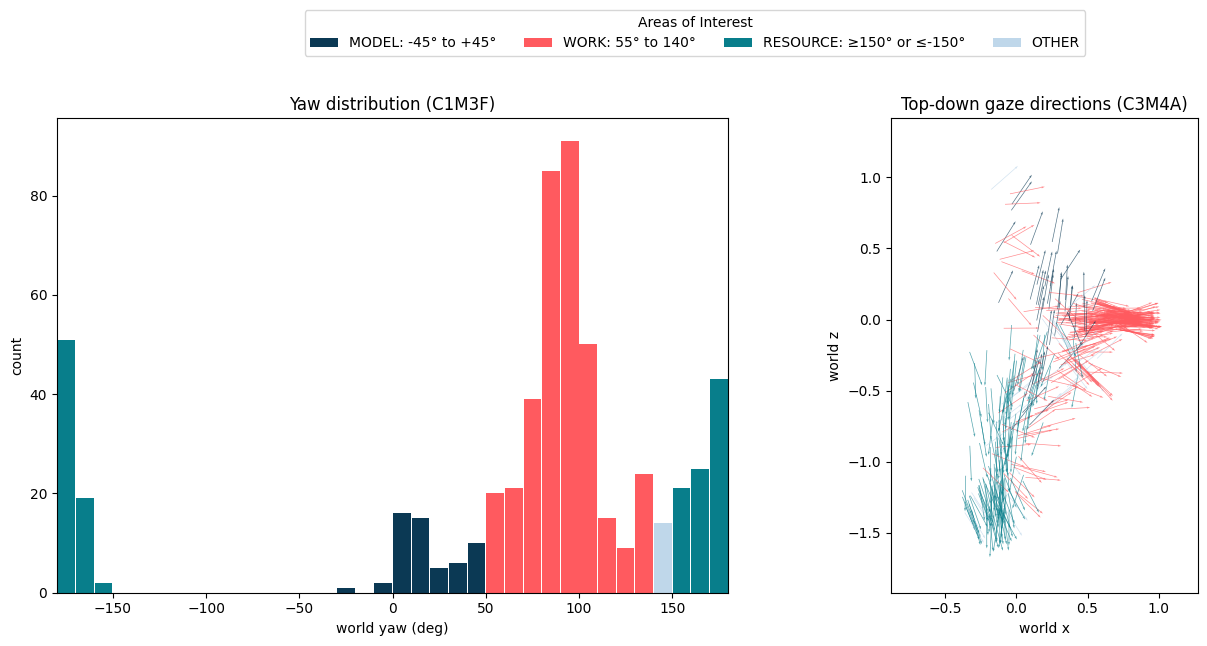

In [184]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================================================
# PALETTE + AOI COLORS
# =========================================================
PALETTE = {
    "deep_space_blue": "#0B3954",  # MODEL
    "teal":            "#087E8B",  # RESOURCE
    "pale_sky":        "#BFD7EA",  # OTHER
    "vibrant_coral":   "#FF5A5F",  # WORK
}

AOI_COLORS = {
    "MODEL":    PALETTE["deep_space_blue"],
    "WORK":     PALETTE["vibrant_coral"],
    "RESOURCE": PALETTE["teal"],
    "OTHER":    PALETTE["pale_sky"],
}

# =========================================================
# AOI CLASSIFICATION FROM YAW
# =========================================================
def yaw_to_aoi(yaw_deg: np.ndarray) -> np.ndarray:
    """
    AOI rules (deg):
      MODEL:    [-45, +45]
      WORK:     [55, 140]
      RESOURCE: >=150 or <=-150
      OTHER:    everything else
    """
    yaw = np.asarray(yaw_deg)
    aoi = np.full(yaw.shape, "OTHER", dtype=object)

    aoi[(yaw >= -45) & (yaw <= 45)] = "MODEL"
    aoi[(yaw >= 55) & (yaw <= 140)] = "WORK"
    aoi[(yaw >= 150) | (yaw <= -150)] = "RESOURCE"
    return aoi

# =========================================================
# DATA PREP
# =========================================================
df = object_gazes_final.copy()

# --- Filter to model C1M3F ---
dfm = df[df["model_name"].astype(str).eq("C1M3F")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# --- Start points (top-down plane) ---
x0 = dfm["hmd_position_x"].to_numpy()
z0 = dfm["hmd_position_z"].to_numpy()

# --- Directions (world gaze) ---
dx = dfm["gaze_world_x"].to_numpy()
dz = dfm["gaze_world_z"].to_numpy()

# --- World yaw (deg) ---
yaw = np.degrees(np.arctan2(dx, dz))
yaw = (yaw + 180) % 360 - 180

# --- Valid rows ---
mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz) & np.isfinite(yaw)
x0, z0, dx, dz, yaw = x0[mask], z0[mask], dx[mask], dz[mask], yaw[mask]

# --- Normalize directions in XZ plane ---
d2 = np.sqrt(dx*dx + dz*dz)
good = d2 > 0
x0, z0, dx, dz, yaw, d2 = x0[good], z0[good], dx[good], dz[good], yaw[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# --- Downsample arrows for readability ---
target_arrows = 3000
step = max(1, len(yaw) // target_arrows)
idx = np.arange(0, len(yaw), step)

# --- AOI labels & colors ---
aoi = yaw_to_aoi(yaw)
arrow_colors = np.array([AOI_COLORS[k] for k in aoi], dtype=object)

# =========================================================
# CREATE FIGURE (EQUAL SIZE SUBPLOTS)
# =========================================================
fig, (ax_hist, ax_map) = plt.subplots(
    1, 2,
    figsize=(14, 6),   # equal overall canvas
    gridspec_kw={"width_ratios": [1, 1]}  # <-- EXACT SAME SIZE
)

# =========================================================
# HISTOGRAM (LEFT)
# =========================================================
bins = np.linspace(-180, 180, 37)  # 10-degree bins
counts, edges = np.histogram(yaw, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

# Color bins by AOI
bin_aoi = yaw_to_aoi(centers)
bar_colors = [AOI_COLORS[k] for k in bin_aoi]

ax_hist.bar(
    centers,
    counts,
    width=(edges[1] - edges[0]) * 0.95,
    color=bar_colors,
    edgecolor="none"
)

ax_hist.set_xlabel("world yaw (deg)")
ax_hist.set_ylabel("count")
ax_hist.set_title("Yaw distribution (C1M3F)")
ax_hist.set_xlim(-180, 180)

# =========================================================
# TOP-DOWN ARROW PLOT (RIGHT)
# =========================================================
ax_map.quiver(
    x0[idx], z0[idx],
    u[idx], v[idx],
    color=arrow_colors[idx],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.0022,
    alpha=0.7
)

ax_map.set_aspect("equal", adjustable="box")
ax_map.set_xlabel("world x")
ax_map.set_ylabel("world z")
ax_map.set_title("Top-down gaze directions (C3M4A)")

# --- Add padding so plot is not squeezed ---
pad = 0.5
ax_map.set_xlim(x0.min() - pad, x0.max() + pad)
ax_map.set_ylim(z0.min() - pad, z0.max() + pad)

# =========================================================
# LEGEND ON TOP (GLOBAL LEGEND)
# =========================================================
legend_handles = [
    Patch(facecolor=AOI_COLORS["MODEL"],    edgecolor="none", label="MODEL: -45° to +45°"),
    Patch(facecolor=AOI_COLORS["WORK"],     edgecolor="none", label="WORK: 55° to 140°"),
    Patch(facecolor=AOI_COLORS["RESOURCE"], edgecolor="none", label="RESOURCE: ≥150° or ≤-150°"),
    Patch(facecolor=AOI_COLORS["OTHER"],    edgecolor="none", label="OTHER"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=True,
    title="Areas of Interest",
    bbox_to_anchor=(0.5, 1.08)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for top legend
plt.show()


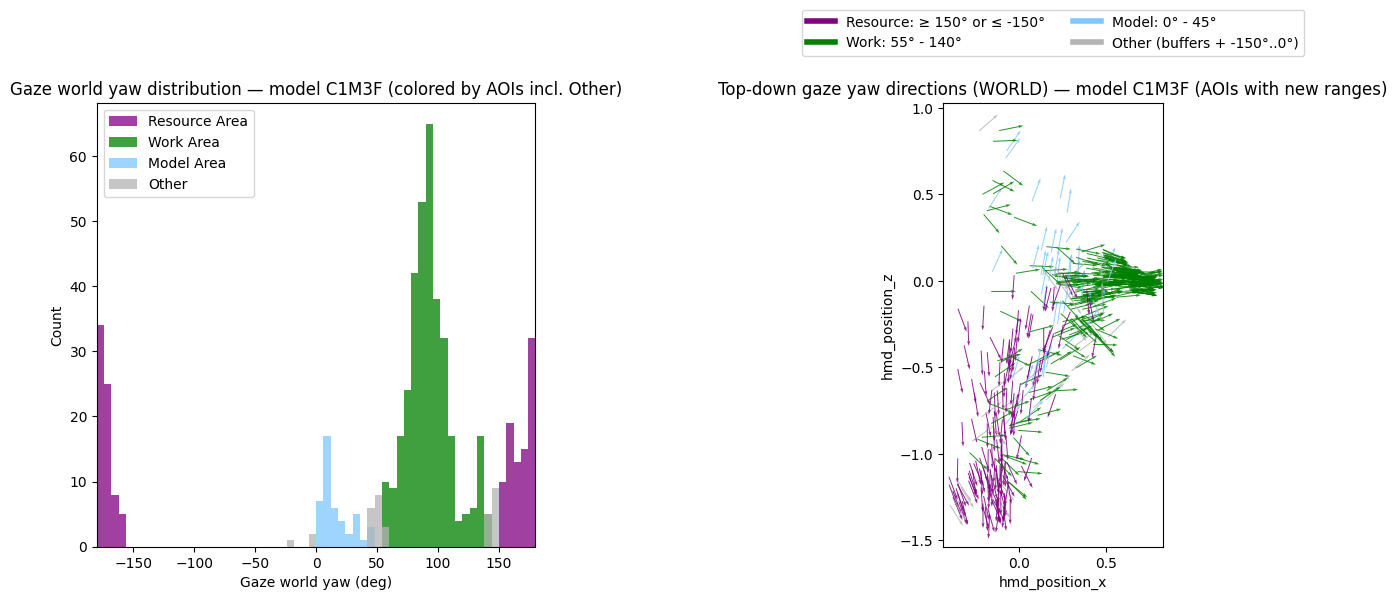

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

def classify_gaze_by_yaw(yaw):
    """
    Asymmetric AOIs with buffer zones (supervisor suggestion):
    - Model Area: 0° to 45°
    - Work Area: 55° to 140°
    - Resource Area: >= 150° OR <= -150°
    - Other: everything else (buffer zones + negative range -150..0)
    """
    if 0 < yaw <= 45:
        return "Model Area"
    elif 55 < yaw <= 140:
        return "Work Area"
    elif yaw >= 150 or yaw <= -150:
        return "Resource Area"
    else:
        return "Other"

AOI_COLORS = {
    "Resource Area": "purple",
    "Work Area": "green",
    "Model Area": "#7EC8FF",  # light blue
    "Other": "0.7"            # grey
}

df = object_gazes_final.copy()
df = df[df["model_name"].astype(str) == MODEL]
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

# --- IMPORTANT CHANGE: use gaze world yaw ---
# If you don't already have gaze_world_yaw_deg, compute it from gaze_world_x/z:
if "gaze_world_yaw_deg" not in df.columns:
    df["gaze_world_yaw_deg"] = np.degrees(np.arctan2(df["gaze_world_x"], df["gaze_world_z"]))

YAW_COL = "gaze_world_yaw_deg"       # <-- changed
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# ---------- FIGURE ----------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2, figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)
fig.subplots_adjust(wspace=0.12)

# ---------- ARROWS FROM YAW (top-down) ----------
yaw_rad = np.deg2rad(yaw)
u = np.sin(yaw_rad)
v = np.cos(yaw_rad)

# Thin if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# ---------- AOI LABELS (apply to yaw_) ----------
labels = np.array([classify_gaze_by_yaw(val) for val in yaw_], dtype=object)
colors = np.array([AOI_COLORS[l] for l in labels], dtype=object)

# ---------- TOP-DOWN PLOT ----------
ax_top.quiver(
    x_, z_, u_, v_,
    color=colors,
    angles="xy", scale_units="xy", scale=7,
    width=0.0045, alpha=0.85, pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down gaze yaw directions (WORLD) — model {MODEL} (AOIs with new ranges)")

legend_handles = [
    Line2D([0],[0], color=AOI_COLORS["Resource Area"], lw=4, label="Resource: ≥ 150° or ≤ -150°"),
    Line2D([0],[0], color=AOI_COLORS["Work Area"],     lw=4, label="Work: 55° - 140°"),
    Line2D([0],[0], color=AOI_COLORS["Model Area"],    lw=4, label="Model: 0° - 45°"),
    Line2D([0],[0], color=AOI_COLORS["Other"],         lw=4, label="Other (buffers + -150°..0°)"),
]
ax_top.legend(handles=legend_handles, loc="lower center",
              bbox_to_anchor=(0.5, 1.09), ncol=2, frameon=True)

# ---------- HISTOGRAM (STACKED, SAME LABELS/COLORS) ----------
bins = np.linspace(-180, 180, 61)  # 60 bins
order = ["Resource Area", "Work Area", "Model Area", "Other"]

for name in order:
    sel = labels == name
    if np.any(sel):
        ax_hist.hist(
            yaw_[sel],
            bins=bins,
            color=AOI_COLORS[name],
            alpha=0.75,
            stacked=True,
            label=name
        )

ax_hist.set_xlabel("Gaze world yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Gaze world yaw distribution — model {MODEL} (colored by AOIs incl. Other)")
ax_hist.set_xlim(-180, 180)
ax_hist.legend(frameon=True)

fig.subplots_adjust(top=0.85)
plt.show()


# First distribution of mean HEAD YAWS , all participants one model 8 EXPLORATORY)

# mean head yaw with better colors

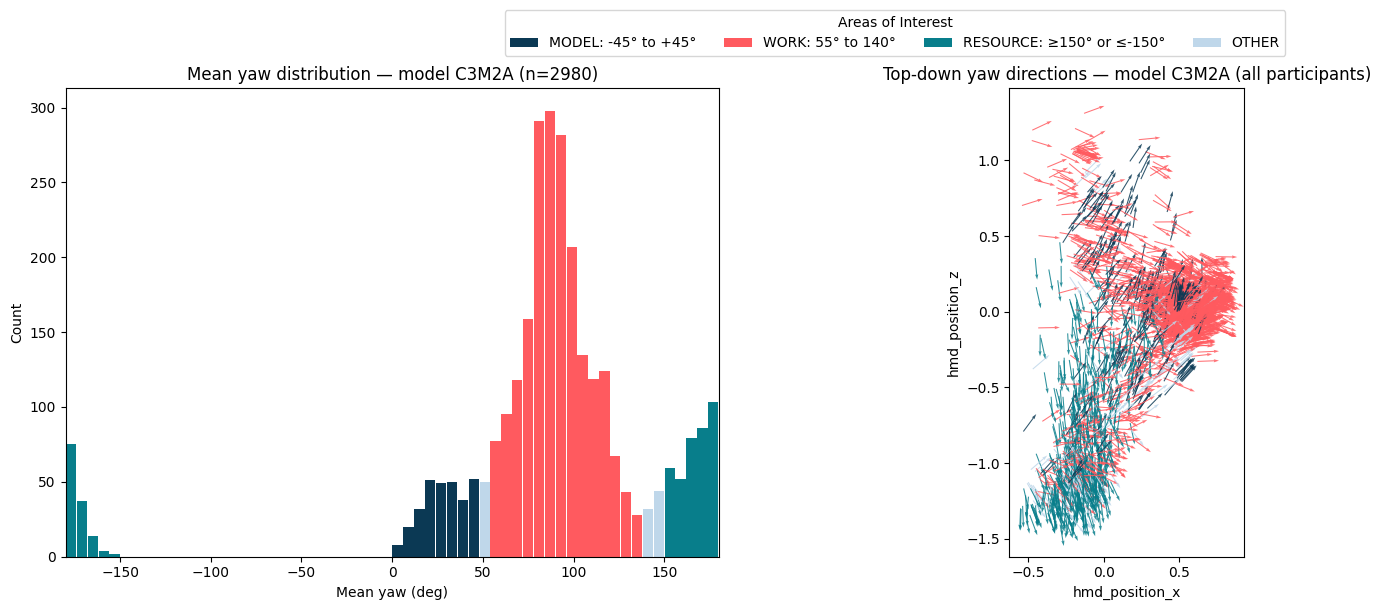

In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================================================
# CONFIG
# =========================================================
MODEL = "C3M2A"
ONLY_VALID = True
MAX_ARROWS = 4000

PALETTE = {
    "deep_space_blue": "#0B3954",  # MODEL
    "teal":            "#087E8B",  # RESOURCE
    "pale_sky":        "#BFD7EA",  # OTHER
    "vibrant_coral":   "#FF5A5F",  # WORK
}

AOI_COLORS = {
    "MODEL":    PALETTE["deep_space_blue"],
    "WORK":     PALETTE["vibrant_coral"],
    "RESOURCE": PALETTE["teal"],
    "OTHER":    PALETTE["pale_sky"],
}

# =========================================================
# AOI CLASSIFICATION
# =========================================================
def yaw_to_aoi(yaw_deg: np.ndarray) -> np.ndarray:
    """
    AOI rules (deg):
      MODEL:    [-45, +45]
      WORK:     [55, 140]
      RESOURCE: >=150 or <=-150
      OTHER:    everything else
    """
    yaw = np.asarray(yaw_deg)
    aoi = np.full(yaw.shape, "OTHER", dtype=object)

    aoi[(yaw >= -45) & (yaw <= 45)] = "MODEL"
    aoi[(yaw >= 55) & (yaw <= 140)] = "WORK"
    aoi[(yaw >= 150) | (yaw <= -150)] = "RESOURCE"
    return aoi

# =========================================================
# DATA PREP
# =========================================================
df = object_gazes_final.copy()

df = df[df["model_name"].astype(str) == MODEL]

if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

YAW_COL = "hmd_yaw_mean_deg"
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# AOI labels
aoi = yaw_to_aoi(yaw)
colors = np.array([AOI_COLORS[k] for k in aoi], dtype=object)

# =========================================================
# FIGURE
# =========================================================
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)

fig.subplots_adjust(wspace=0.12)

# =========================================================
# HISTOGRAM (AOI-COLORED)
# =========================================================
bins = np.linspace(-180, 180, 61)
counts, edges = np.histogram(yaw, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

bin_aoi = yaw_to_aoi(centers)
bar_colors = [AOI_COLORS[k] for k in bin_aoi]

ax_hist.bar(
    centers,
    counts,
    width=(edges[1] - edges[0]) * 0.95,
    color=bar_colors,
    edgecolor="none"
)

ax_hist.set_xlabel("Mean yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Mean yaw distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)

# =========================================================
# TOP-DOWN ARROWS (AOI-COLORED)
# =========================================================
yaw_rad = np.deg2rad(yaw)

u = np.sin(yaw_rad)   # x component
v = np.cos(yaw_rad)   # z component

n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, colors_ = x[idx], z[idx], u[idx], v[idx], colors[idx]
else:
    x_, z_, u_, v_, colors_ = x, z, u, v, colors

ax_top.quiver(
    x_, z_,
    u_, v_,
    color=colors_,
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.0045,
    alpha=0.85,
    pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down yaw directions — model {MODEL} (all participants)")

# =========================================================
# LEGEND (TOP, MATCHING OTHER PLOT)
# =========================================================
legend_handles = [
    Patch(facecolor=AOI_COLORS["MODEL"],    edgecolor="none", label="MODEL: -45° to +45°"),
    Patch(facecolor=AOI_COLORS["WORK"],     edgecolor="none", label="WORK: 55° to 140°"),
    Patch(facecolor=AOI_COLORS["RESOURCE"], edgecolor="none", label="RESOURCE: ≥150° or ≤-150°"),
    Patch(facecolor=AOI_COLORS["OTHER"],    edgecolor="none", label="OTHER"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=True,
    title="Areas of Interest",
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


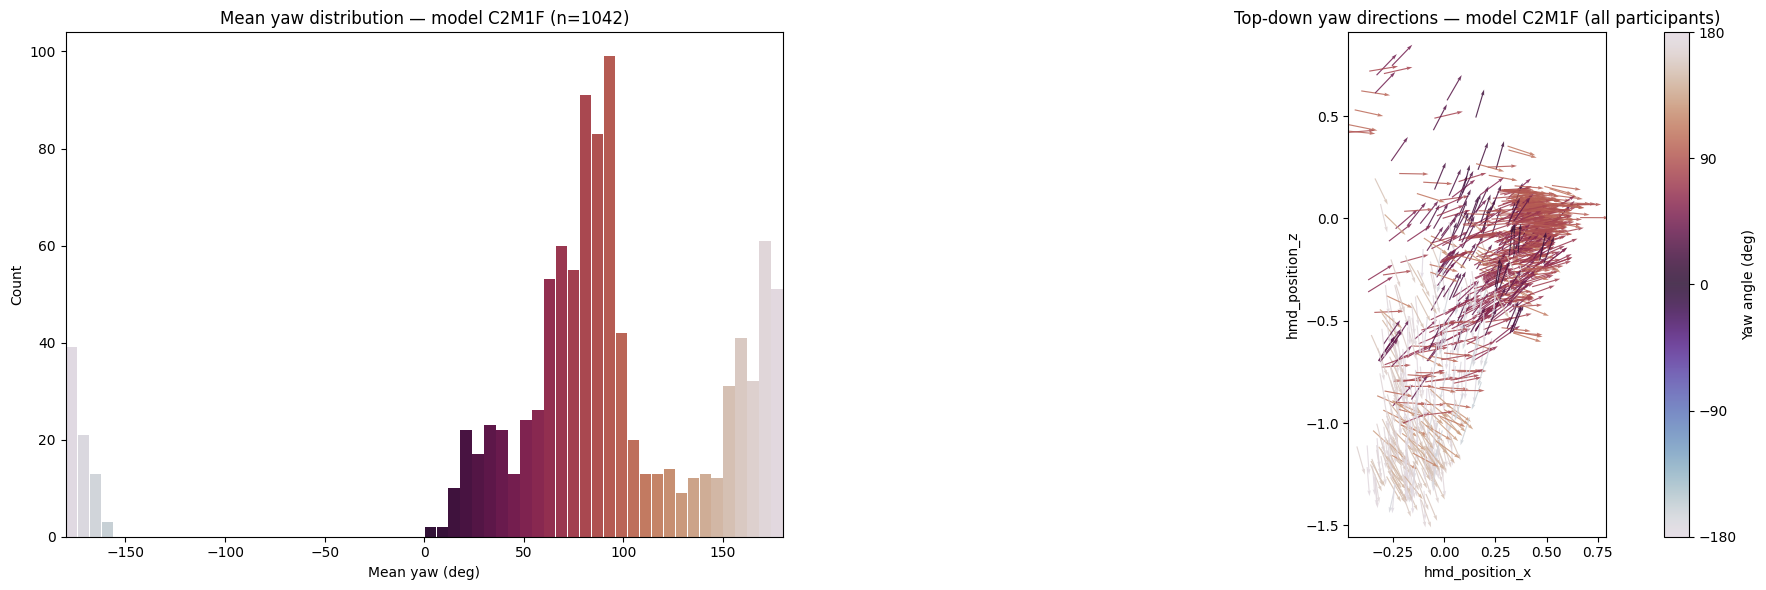

In [187]:
# farbverlauf head distirbution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# =========================================================
# CONFIG
# =========================================================
MODEL = "C2M1F"
ONLY_VALID = True
MAX_ARROWS = 4000

df = object_gazes_final.copy()

# ---------------------------------------------------------
# Filter data
# ---------------------------------------------------------
df = df[df["model_name"].astype(str) == MODEL]

if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

YAW_COL = "hmd_yaw_mean_deg"
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# Wrap yaw to [-180, 180]
yaw = (yaw + 180) % 360 - 180

# =========================================================
# FIGURE
# =========================================================
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)

fig.subplots_adjust(wspace=0.12)

# =========================================================
# COLORMAP (FULL COLOR BAR)
# =========================================================
cmap = plt.get_cmap("twilight")   # same perceptual yaw map
norm = Normalize(vmin=-180, vmax=180)

# =========================================================
# HISTOGRAM (COLORED BY YAW)
# =========================================================
bins = np.linspace(-180, 180, 61)
counts, edges = np.histogram(yaw, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

bar_colors = cmap(norm(centers))

ax_hist.bar(
    centers,
    counts,
    width=(edges[1] - edges[0]) * 0.95,
    color=bar_colors,
    edgecolor="none"
)

ax_hist.set_xlabel("Mean yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Mean yaw distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)

# =========================================================
# TOP-DOWN ARROWS
# =========================================================
yaw_rad = np.deg2rad(yaw)

# yaw=0 -> +Z, +yaw -> +X
u = np.sin(yaw_rad)
v = np.cos(yaw_rad)

# Thin arrows if too many
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

q = ax_top.quiver(
    x_, z_,
    u_, v_,
    yaw_,
    cmap=cmap,
    norm=norm,
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.0045,
    alpha=0.85,
    pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down yaw directions — model {MODEL} (all participants)")

# =========================================================
# FULL COLORBAR
# =========================================================
cb = fig.colorbar(q, ax=ax_top, fraction=0.046, pad=0.04)
cb.set_label("Yaw angle (deg)")
cb.set_ticks([-180, -90, 0, 90, 180])

plt.tight_layout()
plt.show()


# Estimating AOIs in space
- Load Unity project coordinates

In [188]:
import pandas as pd

df = pd.read_csv(
    "/Users/luise/Library/CloudStorage/OneDrive-Persönlich/"
    "Bachelorarbeit/Data/Raw/lufInal_ET_Data_2026-01-30.csv"
)
print(df["hit_obj_name"].dropna().value_counts().head(30))


hit_obj_name
resource_desk_base       2122
work_desk_base           1109
model_desk_base          1075
Lego_4x2_Green (1)       1022
Lego_2x2_Orange           970
Lego_2x2_Blue_Dis         740
Lego_4x2_Orange           549
Wall_Cut                  522
Lego_1x3_Green            518
ImageFixationCross        387
Wall_Front                267
Lego_1x3_Pink (1)         256
Floor                     119
PlaneLeft                  78
ValidationButtonRight       9
Wall_Left                   6
Name: count, dtype: int64


In [189]:
cal = df.iloc[:2500].copy()
cal["hit_obj_name"].value_counts().head(30)


hit_obj_name
Lego_2x2_Orange          970
ImageFixationCross       387
model_desk_base          368
Wall_Front               267
resource_desk_base       220
Floor                     99
work_desk_base            88
PlaneLeft                 78
ValidationButtonRight      9
Wall_Cut                   8
Wall_Left                  6
Name: count, dtype: int64

In [190]:
pink = cal[cal["hit_obj_name"] == "Lego_1x3_Pink (1)"][["object_position_x","object_position_y","object_position_z"]].dropna()
pink_pos = pink.median()
print("Pink marker position:\n", pink_pos)


Pink marker position:
 object_position_x   NaN
object_position_y   NaN
object_position_z   NaN
dtype: float64


# Extract object coordinates of corners of tables out of new CSV

In [191]:
import pandas as pd

# --- 1) Load your CSV ---
df = pd.read_csv("/Users/luise/Library/CloudStorage/OneDrive-Persönlich/"
    "Bachelorarbeit/Data/Raw/lufInal_ET_Data_2026-01-30.csv")

# --- 2) Put the EXACT 6 brick names here (as they appear in hit_obj_name) ---
# Example list (edit if your names differ):
targets = [
    "Lego_2x2_Orange",       # model table marker 1
    "Lego_2x2_Blue_Dis",     # model table marker 2
    "Lego_4x2_Orange",       # work table marker 1 (or whatever you used)
    "Lego_4x2_Green (1)",    # work table marker 2
    "Lego_1x3_Pink (1)",     # resource table marker 1
    "Lego_1x3_Green",        # resource table marker 2
]

# --- 3) Create "run_id": increments whenever hit_obj_name changes ---
h = df["hit_obj_name"].fillna("")
df = df.copy()
df["run_id"] = (h != h.shift(1)).cumsum()

# --- 4) Keep only rows where hit_obj_name is one of the target bricks ---
df_t = df[df["hit_obj_name"].isin(targets)].copy()

# --- 5) Summarize each run: length + robust location (median) ---
coords = ["object_position_x", "object_position_y", "object_position_z"]

runs = (
    df_t.groupby(["hit_obj_name", "run_id"], as_index=False)
        .agg(
            n_rows=("hit_obj_name", "size"),
            start_idx=("run_id", "first"),  # placeholder; we'll add true row indices below
            med_x=("object_position_x", "median"),
            med_y=("object_position_y", "median"),
            med_z=("object_position_z", "median"),
        )
)

# Add true start/end row indices of each run in the original dataframe (useful for debugging)
# We do this by finding min/max index per (hit_obj_name, run_id)
idx_ranges = (
    df_t.reset_index()
        .groupby(["hit_obj_name", "run_id"], as_index=False)
        .agg(start_row=("index", "min"), end_row=("index", "max"))
)

runs = runs.merge(idx_ranges, on=["hit_obj_name", "run_id"], how="left")

# --- 6) Pick ONLY the longest run per brick ---
best = (
    runs.sort_values(["hit_obj_name", "n_rows"], ascending=[True, False])
        .groupby("hit_obj_name", as_index=False)
        .head(1)
        .reset_index(drop=True)
)

# Keep them in the order of your target list
best["order"] = best["hit_obj_name"].apply(lambda x: targets.index(x))
best = best.sort_values("order").reset_index(drop=True)

# --- 7) Print results ---
print(best[["hit_obj_name", "n_rows", "med_x", "med_y", "med_z", "start_row", "end_row"]])

# If you want them as a dict for later AOI code:
brick_positions = {
    row["hit_obj_name"]: (row["med_x"], row["med_y"], row["med_z"])
    for _, row in best.iterrows()
}
print("\nbrick_positions =", brick_positions)


         hit_obj_name  n_rows     med_x     med_y     med_z  start_row  \
0     Lego_2x2_Orange     970 -0.140712  0.971703  1.480410       1166   
1   Lego_2x2_Blue_Dis     740  0.438433  0.971678  0.928014       3207   
2     Lego_4x2_Orange     306  0.655395  0.971703  0.769699       3978   
3  Lego_4x2_Green (1)    1022  0.620013  0.971704 -0.771244       5530   
4   Lego_1x3_Pink (1)     130  0.415351  0.971703 -1.049970       6609   
5      Lego_1x3_Green     380 -0.990232  0.971714 -1.700650       8692   

   end_row  
0     2135  
1     3946  
2     4283  
3     6551  
4     6738  
5     9071  

brick_positions = {'Lego_2x2_Orange': (-0.1407123, 0.9717025, 1.48041), 'Lego_2x2_Blue_Dis': (0.4384328, 0.9716778, 0.9280137), 'Lego_4x2_Orange': (0.6553946, 0.9717028, 0.7696995), 'Lego_4x2_Green (1)': (0.6200135, 0.9717035, -0.7712436), 'Lego_1x3_Pink (1)': (0.415351, 0.9717026, -1.04997), 'Lego_1x3_Green': (-0.9902325, 0.9717139, -1.70065)}


# Quick sanity check if we choose the right coordinates?

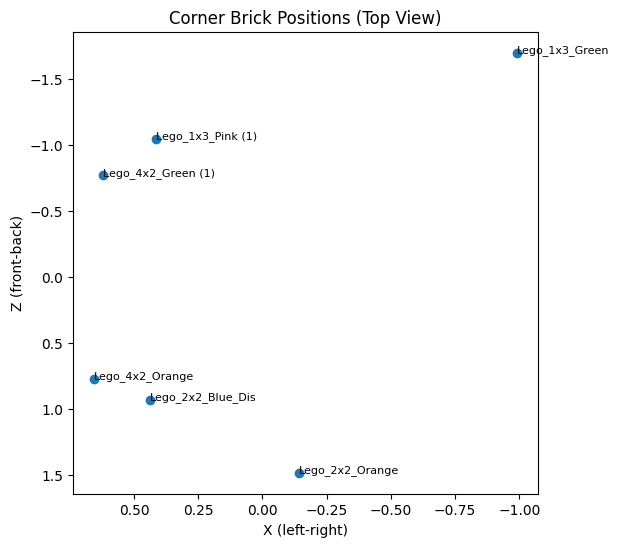

In [192]:
import matplotlib.pyplot as plt

# your extracted positions
data = [
    ("Lego_2x2_Orange", -0.140712, 1.480410),
    ("Lego_2x2_Blue_Dis", 0.438433, 0.928014),
    ("Lego_4x2_Orange", 0.655395, 0.769699),
    ("Lego_4x2_Green (1)", 0.620013, -0.771244),
    ("Lego_1x3_Pink (1)", 0.415351, -1.049970),
    ("Lego_1x3_Green", -0.990232, -1.700650),
]

xs = [d[1] for d in data]
zs = [d[2] for d in data]

plt.figure(figsize=(6,6))
plt.scatter(xs, zs)

for name,x,z in data:
    plt.text(x, z, name, fontsize=8)

plt.xlabel("X (left-right)")
plt.ylabel("Z (front-back)")
plt.title("Corner Brick Positions (Top View)")
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()


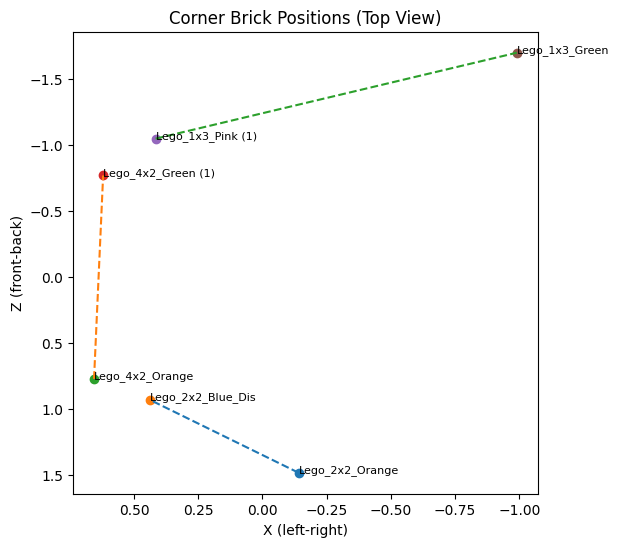

In [193]:
import matplotlib.pyplot as plt

# your extracted positions
data = [
    ("Lego_2x2_Orange", -0.140712, 1.480410),
    ("Lego_2x2_Blue_Dis", 0.438433, 0.928014),
    ("Lego_4x2_Orange", 0.655395, 0.769699),
    ("Lego_4x2_Green (1)", 0.620013, -0.771244),
    ("Lego_1x3_Pink (1)", 0.415351, -1.049970),
    ("Lego_1x3_Green", -0.990232, -1.700650),
]

plt.figure(figsize=(6,6))

# Scatter
for name, x, z in data:
    plt.scatter(x, z)
    plt.text(x, z, name, fontsize=8)

# ---- Linien hinzufügen ----

# 2x2 bricks
x_2x2 = [-0.140712, 0.438433]
z_2x2 = [1.480410, 0.928014]
plt.plot(x_2x2, z_2x2, linestyle="--")

# 4x2 bricks
x_4x2 = [0.655395, 0.620013]
z_4x2 = [0.769699, -0.771244]
plt.plot(x_4x2, z_4x2, linestyle="--")

# 1x3 bricks
x_1x3 = [0.415351, -0.990232]
z_1x3 = [-1.049970, -1.700650]
plt.plot(x_1x3, z_1x3, linestyle="--")

# ---- Achsen & Layout ----
plt.xlabel("X (left-right)")
plt.ylabel("Z (front-back)")
plt.title("Corner Brick Positions (Top View)")
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()


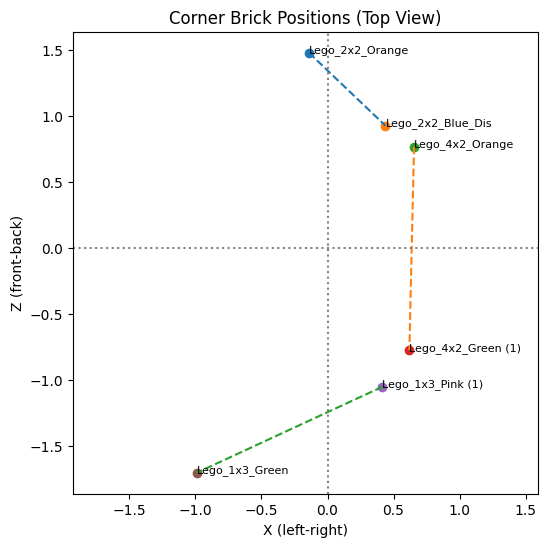

In [194]:
import matplotlib.pyplot as plt

data = [
    ("Lego_2x2_Orange", -0.140712, 1.480410),
    ("Lego_2x2_Blue_Dis", 0.438433, 0.928014),
    ("Lego_4x2_Orange", 0.655395, 0.769699),
    ("Lego_4x2_Green (1)", 0.620013, -0.771244),
    ("Lego_1x3_Pink (1)", 0.415351, -1.049970),
    ("Lego_1x3_Green", -0.990232, -1.700650),
]

plt.figure(figsize=(6,6))

# Scatter
for name, x, z in data:
    plt.scatter(x, z)
    plt.text(x, z, name, fontsize=8)

# Linien
plt.plot([-0.140712, 0.438433], [1.480410, 0.928014], linestyle="--")
plt.plot([0.655395, 0.620013], [0.769699, -0.771244], linestyle="--")
plt.plot([0.415351, -0.990232], [-1.049970, -1.700650], linestyle="--")

# Achsen
plt.xlabel("X (left-right)")
plt.ylabel("Z (front-back)")
plt.title("Corner Brick Positions (Top View)")

# Orientierung sichtbar machen
plt.axhline(0, color='gray', linestyle=':')
plt.axvline(0, color='gray', linestyle=':')

plt.axis("equal")  # wichtig für echte Geometrie

plt.show()

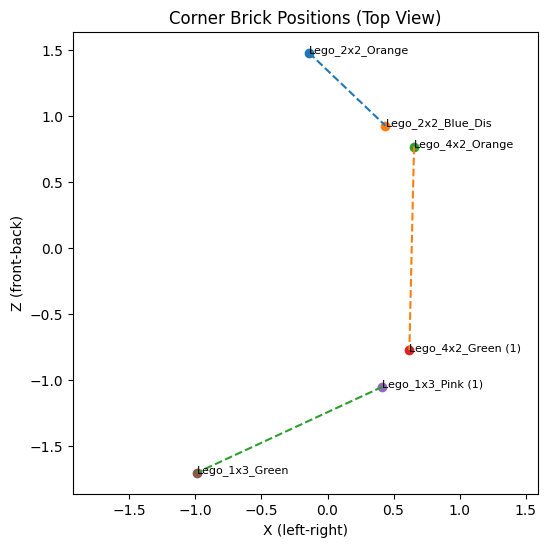

In [195]:
import matplotlib.pyplot as plt

data = [
    ("Lego_2x2_Orange", -0.140712, 1.480410),
    ("Lego_2x2_Blue_Dis", 0.438433, 0.928014),
    ("Lego_4x2_Orange", 0.655395, 0.769699),
    ("Lego_4x2_Green (1)", 0.620013, -0.771244),
    ("Lego_1x3_Pink (1)", 0.415351, -1.049970),
    ("Lego_1x3_Green", -0.990232, -1.700650),
]

plt.figure(figsize=(6,6))

# Scatter
for name, x, z in data:
    plt.scatter(x, z)
    plt.text(x, z, name, fontsize=8)

# Linien
plt.plot([-0.140712, 0.438433], [1.480410, 0.928014], linestyle="--")
plt.plot([0.655395, 0.620013], [0.769699, -0.771244], linestyle="--")
plt.plot([0.415351, -0.990232], [-1.049970, -1.700650], linestyle="--")

# Achsen & Layout
plt.xlabel("X (left-right)")
plt.ylabel("Z (front-back)")
plt.title("Corner Brick Positions (Top View)")

plt.axis("equal")  # wichtig für korrekte Geometrie

plt.show()

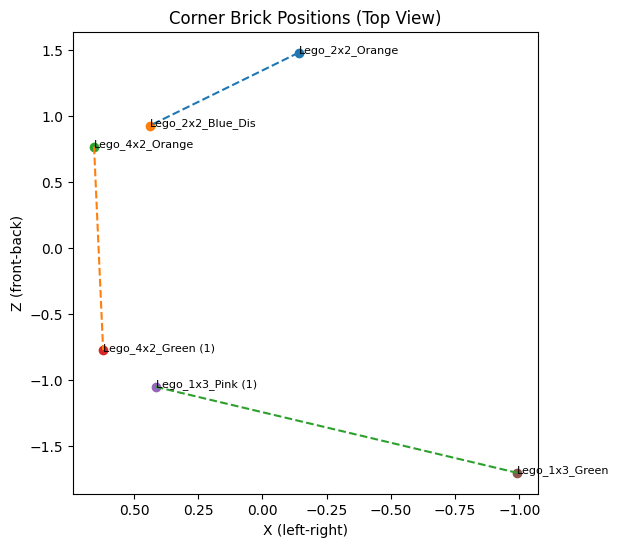

In [196]:
import matplotlib.pyplot as plt

data = [
    ("Lego_2x2_Orange", -0.140712, 1.480410),
    ("Lego_2x2_Blue_Dis", 0.438433, 0.928014),
    ("Lego_4x2_Orange", 0.655395, 0.769699),
    ("Lego_4x2_Green (1)", 0.620013, -0.771244),
    ("Lego_1x3_Pink (1)", 0.415351, -1.049970),
    ("Lego_1x3_Green", -0.990232, -1.700650),
]

plt.figure(figsize=(6, 6))

# Scatter
for name, x, z in data:
    plt.scatter(x, z)
    plt.text(x, z, name, fontsize=8)

# 2x2 bricks
x_2x2 = [-0.140712, 0.438433]
z_2x2 = [1.480410, 0.928014]
plt.plot(x_2x2, z_2x2, linestyle="--")

# 4x2 bricks
x_4x2 = [0.655395, 0.620013]
z_4x2 = [0.769699, -0.771244]
plt.plot(x_4x2, z_4x2, linestyle="--")

# 1x3 bricks
x_1x3 = [0.415351, -0.990232]
z_1x3 = [-1.049970, -1.700650]
plt.plot(x_1x3, z_1x3, linestyle="--")

plt.xlabel("X (left-right)")
plt.ylabel("Z (front-back)")
plt.title("Corner Brick Positions (Top View)")

# Keep this only if you really want left/right mirrored
plt.gca().invert_xaxis()

# Remove this so negative Z goes downward
# plt.gca().invert_yaxis()

plt.show()

# Hier stehen die Koordinaten der Bricks und wie sie AOIs bilden

In [197]:
# ===================== AOI DEFINITIONS FOR WEDGE TEST =====================

brick_positions = {
    'Lego_2x2_Orange': (-0.1407123, 0.9717025, 1.48041),
    'Lego_2x2_Blue_Dis': (0.4384328, 0.9716778, 0.9280137),
    'Lego_4x2_Orange': (0.6553946, 0.9717028, 0.7696995),
    'Lego_4x2_Green (1)': (0.6200135, 0.9717035, -0.7712436),
    'Lego_1x3_Pink (1)': (0.415351, 0.9717026, -1.04997),
    'Lego_1x3_Green': (-0.9902325, 0.9717139, -1.70065),
}

aoi_bricks = {
    "MODEL": ("Lego_2x2_Orange", "Lego_2x2_Blue_Dis"),
    "WORK": ("Lego_4x2_Orange", "Lego_4x2_Green (1)"),
    "RESOURCE": ("Lego_1x3_Pink (1)", "Lego_1x3_Green"),
}


# checking how long the gaze vectors are

In [198]:
g = object_gazes_final[["gaze_world_x","gaze_world_y","gaze_world_z"]].to_numpy(float)
norms = np.linalg.norm(g, axis=1)
print("median/min/max gaze norm:", np.nanmedian(norms), np.nanmin(norms), np.nanmax(norms))


median/min/max gaze norm: 1.008735948166943 1.0000000000005278 1.330954163512027


# Step 3: Wedge test - do gazes fall on xz plane between the 2 table borders?

In [199]:
import numpy as np
import pandas as pd

def _cross2(ax, az, bx, bz):
    # 2D cross product in XZ plane
    return ax * bz - az * bx

def step3_wedge_test_assign_aoi_xz(
    df: pd.DataFrame,
    brick_positions: dict,
    aoi_bricks: dict,
    other_label: str = "OTHER",
    add_debug_cols: bool = True,
) -> pd.DataFrame:
    """
    STEP 3 — Assign AOI if the gaze direction (XZ) lies between the two boundary
    directions from head to the left/right brick endpoints.

    This implements "between those limits" robustly without using plane hit points.

    Output:
      - AOI (final label)
      - optional debug: inside_<AOI>, score_<AOI>
    """
    out = df.copy()

    Ox = out["hmd_position_x"].to_numpy(float)
    Oz = out["hmd_position_z"].to_numpy(float)

    dx = out["gaze_world_x"].to_numpy(float)
    dz = out["gaze_world_z"].to_numpy(float)

    # Normalize gaze dir in XZ
    dn = np.sqrt(dx*dx + dz*dz)
    good = dn > 1e-12
    dx = np.where(good, dx/dn, np.nan)
    dz = np.where(good, dz/dn, np.nan)

    chosen = np.array([other_label] * len(out), dtype=object)
    best_score = np.full(len(out), np.inf, dtype=float)  # smaller = better

    for aoi_name, (Lk, Rk) in aoi_bricks.items():
        L = np.array(brick_positions[Lk], dtype=float)
        R = np.array(brick_positions[Rk], dtype=float)

        # Boundary directions from head to endpoints (XZ)
        ax = L[0] - Ox; az = L[2] - Oz
        bx = R[0] - Ox; bz = R[2] - Oz

        an = np.sqrt(ax*ax + az*az)
        bn = np.sqrt(bx*bx + bz*bz)
        a_ok = an > 1e-12
        b_ok = bn > 1e-12

        ax = np.where(a_ok, ax/an, np.nan)
        az = np.where(a_ok, az/an, np.nan)
        bx = np.where(b_ok, bx/bn, np.nan)
        bz = np.where(b_ok, bz/bn, np.nan)

        # Determine wedge orientation per-sample using sign of cross(a,b)
        ab = _cross2(ax, az, bx, bz)
        ad = _cross2(ax, az, dx, dz)
        db = _cross2(dx, dz, bx, bz)

        inside_pos = (ab >= 0) & (ad >= 0) & (db >= 0)
        inside_neg = (ab < 0) & (ad <= 0) & (db <= 0)
        inside = good & a_ok & b_ok & (inside_pos | inside_neg)

        # Tie-break: choose AOI where gaze is closest to wedge center
        cx = ax + bx
        cz = az + bz
        cn = np.sqrt(cx*cx + cz*cz)
        c_ok = cn > 1e-12
        cx = np.where(c_ok, cx/cn, np.nan)
        cz = np.where(c_ok, cz/cn, np.nan)

        dot = dx*cx + dz*cz
        score = 1.0 - dot  # smaller = closer to center

        if add_debug_cols:
            out[f"inside_{aoi_name}"] = inside
            out[f"score_{aoi_name}"] = score

        update = inside & (score < best_score)
        chosen[update] = aoi_name
        best_score[update] = score[update]

    out["AOI"] = chosen
    return out


# move brick/ table line a bit back “Wenn ich dich später aufrufe, weißt du wie man Bricks verschiebt.”

In [200]:
# Brick shift
import numpy as np

def make_brick_positions_shifted_deeper(
    brick_positions: dict,
    aoi_bricks: dict,
    df_for_direction,
    offset_m: float = 0.20,  
    x_col: str = "hmd_position_x",
    z_col: str = "hmd_position_z",
):
    """
    Shift each AOI brick-pair segment (L,R) by offset_m along the segment-normal in XZ.
    The sign is chosen so the segment moves AWAY from the mean participant position
    (i.e., typically deeper into the table, not into the standing area).
    """
    new_positions = dict(brick_positions)

    Omean = np.array([
        float(df_for_direction[x_col].mean()),
        0.0,
        float(df_for_direction[z_col].mean())
    ], dtype=float)

    for aoi_name, (Lk, Rk) in aoi_bricks.items():
        L = np.array(brick_positions[Lk], dtype=float)
        R = np.array(brick_positions[Rk], dtype=float)

        # segment direction in XZ
        v = R - L
        v[1] = 0.0
        vn = np.linalg.norm([v[0], v[2]])
        if vn < 1e-9:
            continue
        x_hat = v / vn

        # one normal (the other is -normal)
        n = np.array([-x_hat[2], 0.0, x_hat[0]], dtype=float)

        M = 0.5 * (L + R)

        # choose sign that increases distance from participant mean
        dist_plus  = np.linalg.norm((M + offset_m * n)[[0, 2]] - Omean[[0, 2]])
        dist_minus = np.linalg.norm((M - offset_m * n)[[0, 2]] - Omean[[0, 2]])

        n_use = n if dist_plus > dist_minus else -n

        new_positions[Lk] = tuple(L + offset_m * n_use)
        new_positions[Rk] = tuple(R + offset_m * n_use)

    return new_positions


# Bricks weiter nach hinten verschieben actual verschieben


In [201]:
#cell 5
# =====================================================
# Shift bricks deeper + re-run Step 3 wedge assignment
# =====================================================

# Use building-phase subset here if you have it; otherwise this is okay:
df_dir = object_gazes_final[object_gazes_final["model_name"].astype(str).eq("C1M3F")].copy()

brick_positions_shifted = make_brick_positions_shifted_deeper(
    brick_positions=brick_positions,
    aoi_bricks=aoi_bricks,
    df_for_direction=df_dir,
    offset_m=0.25  # try 0.05, 0.10, 0.15
)

# Re-assign AOI using SHIFTED brick endpoints
object_gazes_final = step3_wedge_test_assign_aoi_xz(
    object_gazes_final,
    brick_positions=brick_positions_shifted,
    aoi_bricks=aoi_bricks,
    other_label="OTHER",
    add_debug_cols=False
)

print(object_gazes_final["AOI"].value_counts(dropna=False))


AOI
WORK        25061
RESOURCE     8644
OTHER        2359
MODEL        2342
Name: count, dtype: int64


# ädern sich die positionen wirklich?

In [202]:
off = 0.10
brick_positions_shifted_10 = make_brick_positions_shifted_deeper(
    brick_positions=brick_positions,
    aoi_bricks=aoi_bricks,
    df_for_direction=df_dir,
    offset_m=off
)

off = 0.50
brick_positions_shifted_50 = make_brick_positions_shifted_deeper(
    brick_positions=brick_positions,
    aoi_bricks=aoi_bricks,
    df_for_direction=df_dir,
    offset_m=off
)

# Vergleiche ein konkretes Brick-Key Paar (bitte ggf. Key anpassen)
some_key = list(brick_positions.keys())[0]
print("orig:", brick_positions[some_key])
print("10cm:", brick_positions_shifted_10[some_key])
print("50cm:", brick_positions_shifted_50[some_key])


orig: (-0.1407123, 0.9717025, 1.48041)
10cm: (np.float64(-0.07169245185601061), np.float64(0.9717025), np.float64(1.552772010490178))
50cm: (np.float64(0.20438694071994695), np.float64(0.9717025), np.float64(1.8422200524508905))


In [203]:
print("rows total:", len(object_gazes_final))
print("rows df_dir:", len(df_dir))
print("unique model_name:", object_gazes_final["model_name"].astype(str).nunique())


rows total: 38406
rows df_dir: 584
unique model_name: 20


# Hier endet die primäre AOI zuordnung ohne filter

In [204]:
print("DataFrame after AOI mapping:")
print(type(object_gazes_final))
print(object_gazes_final.shape)
print(object_gazes_final.columns.tolist())
print(object_gazes_final["AOI"].value_counts(dropna=False))

DataFrame after AOI mapping:
<class 'pandas.core.frame.DataFrame'>
(38406, 40)
['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg', 'gaze_yaw_mean_deg', 'hmd_yaw_start_deg', 'hmd_yaw_mean_deg', 'hmd_yaw_start_deg_canon', 'hmd_yaw_mean_deg_canon', 'gaze_world_x', 'gaze_world_y', 'gaze_world_z', 'gaze_world_yaw_deg', 'gaze_world_pitch_deg', 'AOI']
AOI
WORK        25061
RESOURCE     8644
OTHER        2359
MODEL        2342
Name: count, dtype: int64


## Rename Table object into 3 Tables

# workdeskbase_001 in 3 Tables aufteillen und umbenennen!

In [205]:
df = object_gazes_final.copy()

# neue Spalte erstellen (Original bleibt erhalten)
df["object_name_new"] = df["object_name"].astype(str)

# nur Desk Base auswählen
is_desk = df["object_name_new"] == "work_desk_base.001"

# AOI-basiertes Umbenennen
df.loc[is_desk & (df["AOI"] == "MODEL"), "object_name_new"] = "model_desk_base"
df.loc[is_desk & (df["AOI"] == "WORK"), "object_name_new"] = "work_desk_base"
df.loc[is_desk & (df["AOI"] == "RESOURCE"), "object_name_new"] = "resource_desk_base"


In [206]:
df.loc[df["object_name"]=="work_desk_base.001","object_name_new"].value_counts()


object_name_new
work_desk_base        5424
resource_desk_base    2834
work_desk_base.001     553
model_desk_base         79
Name: count, dtype: int64

# herausfinden von other. workdesk gazes geometrisch

In [207]:
import numpy as np
import pandas as pd

df = object_gazes_final.copy()

# nur valid building (falls du das willst)
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].eq(True)].copy()

# wir arbeiten nur mit desk-base gazes
desk = df[df["object_name"].astype(str).eq("work_desk_base.001")].copy()

# XZ position für Zuordnung (nutze gaze-hit position falls du die hast; sonst HMD)
# Hier nehme ich HMD, weil in deinem Datensatz sicher vorhanden:
x = desk["hmd_position_x"].to_numpy(float)
z = desk["hmd_position_z"].to_numpy(float)
aoi = desk["AOI"].astype(str).to_numpy()

# saubere AOI labels
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

mask = np.isfinite(x) & np.isfinite(z)
desk = desk.loc[mask].copy()

# 1) Zentren aus den NICHT-OTHER desk gazes schätzen
centroids = (
    desk[desk["AOI"].isin(["MODEL","WORK","RESOURCE"])]
    .groupby("AOI")[["hmd_position_x","hmd_position_z"]]
    .median()
)

print("Estimated desk centroids (median XZ):")
print(centroids)

# 2) OTHER desk gazes nehmen und zum nächsten Zentrum zuordnen
other = desk[desk["AOI"].astype(str).eq("OTHER")].copy()

if len(other) == 0:
    print("No OTHER desk gazes found.")
else:
    C = centroids.to_dict("index")  # {"MODEL": {"hmd_position_x":..., "hmd_position_z":...}, ...}

    def nearest_label(row):
        px, pz = float(row["hmd_position_x"]), float(row["hmd_position_z"])
        best_lbl, best_d = None, np.inf
        for lbl, c in C.items():
            dx = px - float(c["hmd_position_x"])
            dz = pz - float(c["hmd_position_z"])
            d2 = dx*dx + dz*dz
            if d2 < best_d:
                best_d = d2
                best_lbl = lbl
        return best_lbl

    other["OTHER_assigned_to"] = other.apply(nearest_label, axis=1)

    print("\nWhere OTHER desk gazes would belong (nearest centroid):")
    print(other["OTHER_assigned_to"].value_counts())

    # Optional: Prozent
    print("\nPercent:")
    print((other["OTHER_assigned_to"].value_counts(normalize=True) * 100).round(1))



Estimated desk centroids (median XZ):
          hmd_position_x  hmd_position_z
AOI                                     
MODEL           0.038244       -0.034042
RESOURCE       -0.113646       -1.021085
WORK            0.303343       -0.146791

Where OTHER desk gazes would belong (nearest centroid):
OTHER_assigned_to
WORK        173
RESOURCE     76
MODEL        43
Name: count, dtype: int64

Percent:
OTHER_assigned_to
WORK        59.2
RESOURCE    26.0
MODEL       14.7
Name: proportion, dtype: float64


In [208]:
import pandas as pd

# Deine Werte
data = {
    "Assigned_Desk": ["WORK", "RESOURCE", "MODEL"],
    "Count": [174, 75, 41],
}

df_other_summary = pd.DataFrame(data)
df_other_summary["Percent"] = (
    df_other_summary["Count"] / df_other_summary["Count"].sum() * 100
)

df_other_summary["Percent"] = df_other_summary["Percent"].round(1)

df_other_summary


,Assigned_Desk,Count,Percent
0,WORK,174,60.0
1,RESOURCE,75,25.9
2,MODEL,41,14.1


# renaming now ALL WORKDESKBASE001 GAZES TO THEIR TABLE TENDENCIES

In [209]:
# real
import numpy as np

df = object_gazes_final.copy()

# 0) neue Spalte: default = original object_name
df["object_name_corr"] = df["object_name"].astype(str)

# 1) Desk erkennen
is_desk = df["object_name_corr"].eq("work_desk_base.001")

# 2) eindeutige Zuordnung für MODEL/WORK/RESOURCE (direkt über AOI)
df.loc[is_desk & df["AOI"].astype(str).eq("MODEL"),    "object_name_corr"] = "model_desk_base"
df.loc[is_desk & df["AOI"].astype(str).eq("WORK"),     "object_name_corr"] = "work_desk_base"
df.loc[is_desk & df["AOI"].astype(str).eq("RESOURCE"), "object_name_corr"] = "resource_desk_base"

# 3) OTHER desk-gazes anhand eurer berechneten Zentren zuordnen (XZ)
centroids = {
    "MODEL":    {"x": 0.044562,  "z": -0.086019},
    "RESOURCE": {"x": -0.113321, "z": -1.020674},
    "WORK":     {"x": 0.303420,  "z": -0.147055},
}

mask_other_desk = (
    is_desk &
    df["AOI"].astype(str).eq("OTHER") &
    df["hmd_position_x"].notna() &
    df["hmd_position_z"].notna()
)

def nearest_label(px, pz):
    best_lbl, best_d = None, np.inf
    for lbl, c in centroids.items():
        dx = px - c["x"]
        dz = pz - c["z"]
        d2 = dx*dx + dz*dz
        if d2 < best_d:
            best_d = d2
            best_lbl = lbl
    return best_lbl

idx = df.index[mask_other_desk]
assigned = [
    nearest_label(float(df.at[i, "hmd_position_x"]), float(df.at[i, "hmd_position_z"]))
    for i in idx
]

df.loc[idx, "OTHER_assigned_to"] = assigned

# apply rename for OTHER desk gazes
df.loc[df["OTHER_assigned_to"].eq("MODEL"),    "object_name_corr"] = "model_desk_base"
df.loc[df["OTHER_assigned_to"].eq("WORK"),     "object_name_corr"] = "work_desk_base"
df.loc[df["OTHER_assigned_to"].eq("RESOURCE"), "object_name_corr"] = "resource_desk_base"


In [210]:
# realLLLLLL
import numpy as np

df = object_gazes_final.copy()

# 0) neue Spalte: default = original object_name
df["object_name_corr"] = df["object_name"].astype(str)

# 1) Desk erkennen
is_desk = df["object_name_corr"].eq("work_desk_base.001")

# 2) eindeutige Zuordnung für MODEL/WORK/RESOURCE (direkt über AOI)
df.loc[is_desk & df["AOI"].astype(str).eq("MODEL"),    "object_name_corr"] = "model_desk_base"
df.loc[is_desk & df["AOI"].astype(str).eq("WORK"),     "object_name_corr"] = "work_desk_base"
df.loc[is_desk & df["AOI"].astype(str).eq("RESOURCE"), "object_name_corr"] = "resource_desk_base"

# 3) OTHER desk-gazes anhand eurer berechneten Zentren zuordnen (XZ)
centroids = {
    "MODEL":    {"x": 0.044562,  "z": -0.086019},
    "RESOURCE": {"x": -0.113321, "z": -1.020674},
    "WORK":     {"x": 0.303420,  "z": -0.147055},
}

mask_other_desk = (
    is_desk &
    df["AOI"].astype(str).eq("OTHER") &
    df["hmd_position_x"].notna() &
    df["hmd_position_z"].notna()
)

def nearest_label(px, pz):
    best_lbl, best_d = None, np.inf
    for lbl, c in centroids.items():
        dx = px - c["x"]
        dz = pz - c["z"]
        d2 = dx*dx + dz*dz
        if d2 < best_d:
            best_d = d2
            best_lbl = lbl
    return best_lbl

idx = df.index[mask_other_desk]
assigned = [
    nearest_label(float(df.at[i, "hmd_position_x"]), float(df.at[i, "hmd_position_z"]))
    for i in idx
]

df.loc[idx, "OTHER_assigned_to"] = assigned

# apply rename for OTHER desk gazes
df.loc[df["OTHER_assigned_to"].eq("MODEL"),    "object_name_corr"] = "model_desk_base"
df.loc[df["OTHER_assigned_to"].eq("WORK"),     "object_name_corr"] = "work_desk_base"
df.loc[df["OTHER_assigned_to"].eq("RESOURCE"), "object_name_corr"] = "resource_desk_base"


# =====================================================
# ⭐ WICHTIG: zurück ins Hauptdataset schreiben
# =====================================================
object_gazes_final["object_name_corr"] = df["object_name_corr"]

if "OTHER_assigned_to" in df.columns:
    object_gazes_final["OTHER_assigned_to"] = df["OTHER_assigned_to"]


# checks

In [211]:
df[df["object_name"]=="work_desk_base.001"]["object_name_corr"].value_counts()


object_name_corr
work_desk_base        5821
resource_desk_base    2930
model_desk_base        139
Name: count, dtype: int64

In [212]:
# Was sind die neuen Desk-Labels?
df["object_name_corr"].value_counts().head(20)

# Sind noch alte Desk-Namen übrig?
(df["object_name_corr"] == "work_desk_base.001").sum()

# Wie wurden OTHER desk gazes verteilt?
df["OTHER_assigned_to"].value_counts(dropna=False)


OTHER_assigned_to
nan         37853
WORK          397
RESOURCE       96
MODEL          60
Name: count, dtype: int64

In [213]:
for name in object_gazes_final["object_name"].dropna().unique():
    print(name)


Wall_Front
work_desk_base.001
Floor
PlaneRight
PlaneLeft
ValidationButtonRight
ValidationButtonLeft
ImageFixationCross
Lego_Board_10x10
NextItemButton
Lego_4x2_Orange
Model_plate
Lego_4x2_Green (1)
Lego_1x3_Pink (1)
Lego_4x2_Blue
Lego_3x2_Orange_Dis
Lego_2x2_Orange
Lego_4x2_Pink_Dis
Lego_1x3_Green
QuestionButton1
ContinueButton
QuestionButton2
Wall_Cut
Wall_Left
Lego_2x2_Green_Dis
Lego_3x2_Blue_Dis
Lego_1x3_Orange_Dis
Lego_2x2_Pink
Lego_4x2_Orange (1)
Lego_4x2_Green
Lego_1x3_Blue
Lego_1x3_Pink
Lego_2x2_Blue
QuestionButton3
QuestionButton4
Lego_3x2_Pink_Dis
Lego_4x2_Blue_Dis
Lego_4x2_Pink
Lego_2x2_Blue_Dis
Lego_4x2_Pink (1)
Lego_2x2_Orange (1)
Lego_2x2_Green (1)
Lego_2x2_Pink (3)
Lego_2x2_Green (2)
Lego_2x2_Pink (2)
Lego_2x2_Green
Lego_3x2_Green_Dis
Lego_2x2_Pink (1)
Lego_1x3_Orange
Lego_1x3_Pink_Dis
Lego_2x2_Pink_Dis
Lego_1x3_Orange (1)
Lego_4x2_Orange_Dis
Lego_1x3_Green_Dis
Lego_2x2_Blue (1)
Lego_4x2_Green_Dis
Lego_2x2_Orange_Dis
Wall_Back
Lamp_Back_Left
Ceiling
QuestionButton7
Questi

# welche objekte landen in other nach dem wedge test?

In [214]:
# =====================================================
# Analyse: Welche object_names sind in OTHER?
# abhängig vom Brick-Shift
# =====================================================

offsets = [0.10, 0.15, 0.20]  # 10cm, 15cm, 20cm
results = []

# wichtig: NICHT object_gazes_final überschreiben
base_df = object_gazes_final.copy()

for off in offsets:

    # --- Shift berechnen ---
    brick_positions_shifted = make_brick_positions_shifted_deeper(
        brick_positions=brick_positions,
        aoi_bricks=aoi_bricks,
        df_for_direction=df_dir,
        offset_m=off
    )

    # --- AOI neu zuweisen (temporär) ---
    df_tmp = step3_wedge_test_assign_aoi_xz(
        base_df.copy(),
        brick_positions=brick_positions_shifted,
        aoi_bricks=aoi_bricks,
        other_label="OTHER",
        add_debug_cols=False
    )

    # --- nur OTHER ---
    other_counts = (
        df_tmp[df_tmp["AOI"] == "OTHER"]["object_name"]
        .value_counts(dropna=False)
        .reset_index()
    )

    other_counts.columns = ["object_name", "count"]
    other_counts["offset_m"] = off

    results.append(other_counts)

# alles zusammenführen
other_summary = (
    pd.concat(results, ignore_index=True)
    .sort_values(["offset_m", "count"], ascending=[True, False])
)

other_summary


,object_name,count,offset_m
0,Floor,362,0.1
1,work_desk_base.001,331,0.1
2,Wall_Left,160,0.1
3,Model_plate,135,0.1
4,Wall_Cut,112,0.1
...,...,...,...
110,Lego_2x2_Pink (2),1,0.2
111,Lego_Board_10x10,1,0.2
112,Lego_2x2_Green,1,0.2
113,Lego_4x2_Pink (1),1,0.2


# Alle columns insgesamt anzeigen

In [215]:
print(object_gazes_final.columns.tolist())


['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg', 'gaze_yaw_mean_deg', 'hmd_yaw_start_deg', 'hmd_yaw_mean_deg', 'hmd_yaw_start_deg_canon', 'hmd_yaw_mean_deg_canon', 'gaze_world_x', 'gaze_world_y', 'gaze_world_z', 'gaze_world_yaw_deg', 'gaze_world_pitch_deg', 'AOI', 'object_name_corr', 'OTHER_assigned_to']


# Was ist in object_name?

In [216]:
object_gazes_final["object_name"].value_counts()


object_name
work_desk_base.001    8890
Lego_Board_10x10      2543
Wall_Front            2504
Model_plate           2118
Lego_4x2_Orange       1759
                      ... 
Wall_Back                7
Lego_2x2_Green_Dis       7
Ceiling                  3
separatorDoor_body       2
Lamp_Back_Left           1
Name: count, Length: 65, dtype: int64

In [217]:
for name in object_gazes_final["object_name"].dropna().unique():
    print(name)


Wall_Front
work_desk_base.001
Floor
PlaneRight
PlaneLeft
ValidationButtonRight
ValidationButtonLeft
ImageFixationCross
Lego_Board_10x10
NextItemButton
Lego_4x2_Orange
Model_plate
Lego_4x2_Green (1)
Lego_1x3_Pink (1)
Lego_4x2_Blue
Lego_3x2_Orange_Dis
Lego_2x2_Orange
Lego_4x2_Pink_Dis
Lego_1x3_Green
QuestionButton1
ContinueButton
QuestionButton2
Wall_Cut
Wall_Left
Lego_2x2_Green_Dis
Lego_3x2_Blue_Dis
Lego_1x3_Orange_Dis
Lego_2x2_Pink
Lego_4x2_Orange (1)
Lego_4x2_Green
Lego_1x3_Blue
Lego_1x3_Pink
Lego_2x2_Blue
QuestionButton3
QuestionButton4
Lego_3x2_Pink_Dis
Lego_4x2_Blue_Dis
Lego_4x2_Pink
Lego_2x2_Blue_Dis
Lego_4x2_Pink (1)
Lego_2x2_Orange (1)
Lego_2x2_Green (1)
Lego_2x2_Pink (3)
Lego_2x2_Green (2)
Lego_2x2_Pink (2)
Lego_2x2_Green
Lego_3x2_Green_Dis
Lego_2x2_Pink (1)
Lego_1x3_Orange
Lego_1x3_Pink_Dis
Lego_2x2_Pink_Dis
Lego_1x3_Orange (1)
Lego_4x2_Orange_Dis
Lego_1x3_Green_Dis
Lego_2x2_Blue (1)
Lego_4x2_Green_Dis
Lego_2x2_Orange_Dis
Wall_Back
Lamp_Back_Left
Ceiling
QuestionButton7
Questi

# Alle Object names in einer validen building Siatuation

In [218]:
for name in object_gazes_final.loc[
    object_gazes_final["is_valid_model"] == True, "object_name"
].dropna().unique():
    print(name)


Wall_Front
Lego_Board_10x10
work_desk_base.001
Lego_4x2_Pink_Dis
Model_plate
Lego_2x2_Green_Dis
Lego_3x2_Blue_Dis
Lego_4x2_Blue
Lego_1x3_Orange_Dis
Lego_2x2_Pink
Lego_4x2_Orange (1)
Lego_4x2_Green
Lego_3x2_Orange_Dis
Lego_1x3_Blue
Lego_1x3_Pink
Wall_Left
Lego_4x2_Green (1)
Wall_Cut
Lego_4x2_Orange
Lego_2x2_Blue
Lego_1x3_Pink (1)
NextItemButton
Floor
Lego_3x2_Pink_Dis
Lego_4x2_Blue_Dis
Lego_4x2_Pink
Lego_2x2_Orange
Lego_2x2_Blue_Dis
Lego_4x2_Pink (1)
Lego_2x2_Orange (1)
Lego_2x2_Green (1)
Lego_2x2_Pink (3)
Lego_2x2_Green (2)
Lego_2x2_Pink (2)
Lego_2x2_Green
Lego_3x2_Green_Dis
Lego_2x2_Pink (1)
Lego_1x3_Orange
Lego_1x3_Green
Lego_1x3_Pink_Dis
Lego_2x2_Pink_Dis
Lego_1x3_Orange (1)
Lego_4x2_Orange_Dis
Lego_1x3_Green_Dis
Lego_2x2_Blue (1)
Lego_4x2_Green_Dis
Lego_2x2_Orange_Dis
Wall_Back
Lamp_Back_Left
Ceiling
Lego_1x3_Blue_Dis


In [219]:
ui_prefixes = (
    "ValidationButton",
    "NextItemButton",
    "ContinueButton",
    "QuestionButton",
    "ImageFixationCross",
)

ui_hits = (
    object_gazes_final["object_name"]
    .dropna()
    .astype(str)
    .loc[lambda s: s.str.startswith(ui_prefixes)]
    .value_counts()
)

ui_hits


object_name
ContinueButton           614
ImageFixationCross       479
NextItemButton           461
QuestionButton1          449
QuestionButton2          438
QuestionButton3          409
ValidationButtonRight    254
QuestionButton4          246
ValidationButtonLeft     189
QuestionButton5          119
QuestionButton6           38
QuestionButton7           31
Name: count, dtype: int64

In [220]:
ui_other_hits = (
    object_gazes_final.loc[object_gazes_final["AOI"]=="OTHER", "object_name"]
    .dropna()
    .astype(str)
    .loc[lambda s: s.str.startswith(ui_prefixes)]
    .value_counts()
)

ui_other_hits


object_name
ContinueButton    456
NextItemButton    209
Name: count, dtype: int64

# FILTER OUT NON TASK RELEVANT GAZES and work on with OBJECT GAZES CLEAN

In [221]:
ENVIRONMENT_OBJECTS = [
    "Wall_Front",
    "Wall_Left",
    "Wall_Back",
    "Wall_Cut",
    "Floor",
    "Ceiling",
    "Lamp_Back_Left"
]

mask = (
    object_gazes_final["is_valid_model"].eq(True) &
    ~object_gazes_final["object_name"].isin(ENVIRONMENT_OBJECTS)
)

object_gazes_clean = object_gazes_final.loc[mask].copy()


In [222]:
# Was wurde entfernt
removed = object_gazes_final.loc[
    ~object_gazes_final.index.isin(object_gazes_clean.index)
]

removed["object_name"].value_counts().head(50)

object_name
work_desk_base.001       4809
Wall_Front               2504
Lego_4x2_Blue             825
Floor                     767
Lego_4x2_Green (1)        658
ContinueButton            614
Lego_4x2_Orange           578
Lego_Board_10x10          517
ImageFixationCross        479
Lego_2x2_Orange           471
Wall_Cut                  465
Lego_1x3_Pink (1)         463
QuestionButton1           449
QuestionButton2           438
Model_plate               417
QuestionButton3           409
Lego_1x3_Green            376
Wall_Left                 279
ValidationButtonRight     254
QuestionButton4           246
PlaneRight                208
PlaneLeft                 203
ValidationButtonLeft      189
Lego_4x2_Pink_Dis         147
NextItemButton            135
QuestionButton5           119
Lego_3x2_Orange_Dis       111
Lego_2x2_Blue_Dis          63
QuestionButton6            38
QuestionButton7            31
Wall_Back                   7
Ceiling                     3
separatorDoor_body          

# Filter out OHTER und non Task relevant gazes und adde AOI_CLEAN als finala analysespalte

In [223]:
import numpy as np

# ===================== CREATE CLEAN AOI COLUMN =====================

# Objects that are not task-relevant
ENVIRONMENT_OBJECTS = [
    "Wall_Front",
    "Wall_Left",
    "Wall_Back",
    "Wall_Cut",
    "Floor",
    "Ceiling",
    "Lamp_Back_Left"
]

# AOIs that are relevant for the final analysis
TASK_AOIS = ["MODEL", "WORK", "RESOURCE"]

# Start with empty clean AOI column
object_gazes_final["AOI_CLEAN"] = np.nan

# Keep only valid model gazes
valid_model_mask = object_gazes_final["is_valid_model"].eq(True)

# Remove environment / non-task-relevant objects
environment_mask = object_gazes_final["object_name"].isin(ENVIRONMENT_OBJECTS)

# Keep only task-relevant AOIs, so OTHER is automatically excluded
task_aoi_mask = object_gazes_final["AOI"].isin(TASK_AOIS)

# Final clean mask
clean_mask = (
    valid_model_mask &
    ~environment_mask &
    task_aoi_mask
)

# Copy AOI into AOI_CLEAN only for clean, task-relevant gazes
object_gazes_final.loc[clean_mask, "AOI_CLEAN"] = object_gazes_final.loc[clean_mask, "AOI"]

# Optional: create clean analysis dataframe
object_gazes_clean = object_gazes_final[
    object_gazes_final["AOI_CLEAN"].notna()
].copy()

# Checks
print("Original AOI counts:")
display(object_gazes_final["AOI"].value_counts(dropna=False))

print("Clean AOI counts:")
display(object_gazes_final["AOI_CLEAN"].value_counts(dropna=False))

print("object_gazes_clean shape:", object_gazes_clean.shape)

Original AOI counts:


/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1415/2300296970.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['WORK' 'RESOURCE' 'MODEL' ... 'WORK' 'WORK' 'WORK']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  object_gazes_final.loc[clean_mask, "AOI_CLEAN"] = object_gazes_final.loc[clean_mask, "AOI"]


AOI
WORK        25061
RESOURCE     8644
OTHER        2359
MODEL        2342
Name: count, dtype: int64

Clean AOI counts:


AOI_CLEAN
NaN         17771
WORK        12335
RESOURCE     6568
MODEL        1732
Name: count, dtype: int64

object_gazes_clean shape: (20635, 43)


## Wie sieht jz object gazes final aus?

In [224]:
# ===================== CHECK object_gazes_final =====================

print("Shape of object_gazes_final:")
print(object_gazes_final.shape)

print("\nColumns:")
print(object_gazes_final.columns.tolist())

print("\nFirst rows:")
display(object_gazes_final.head())

print("\nAOI counts:")
display(object_gazes_final["AOI"].value_counts(dropna=False))

print("\nAOI_CLEAN counts:")
display(object_gazes_final["AOI_CLEAN"].value_counts(dropna=False))

print("\nis_valid_model counts:")
display(object_gazes_final["is_valid_model"].value_counts(dropna=False))

print("\nObject gaze duration:")
display(object_gazes_final["object_gaze_duration_ms"].describe())

print("\nCheck required columns:")
required_cols = [
    "participant_id",
    "object_name",
    "model_name",
    "is_valid_model",
    "object_gaze_duration_ms",
    "AOI",
    "AOI_CLEAN"
]

missing_cols = [c for c in required_cols if c not in object_gazes_final.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are present.")

Shape of object_gazes_final:
(38406, 43)

Columns:
['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg', 'gaze_yaw_mean_deg', 'hmd_yaw_start_deg', 'hmd_yaw_mean_deg', 'hmd_yaw_start_deg_canon', 'hmd_yaw_mean_deg_canon', 'gaze_world_x', 'gaze_world_y', 'gaze_world_z', 'gaze_world_yaw_deg', 'gaze_world_pitch_deg', 'AOI', 'object_name_corr', 'OTHER_assigned_to', 'AOI_CLEAN']

First rows:


,participant_id,object_name,object_gaze_count,start_ms,end_ms,object_gaze_duration_ms,object_gaze_duration_s,hmd_position_x,hmd_position_y,hmd_position_z,...,hmd_yaw_mean_deg_canon,gaze_world_x,gaze_world_y,gaze_world_z,gaze_world_yaw_deg,gaze_world_pitch_deg,AOI,object_name_corr,OTHER_assigned_to,AOI_CLEAN
0,01,Wall_Front,1,1.754659e+12,1.754659e+12,3686.0,3.686,0.477676,1.740824,0.077520,...,93.857525,0.998066,0.005201,-0.068914,93.949862,0.297877,WORK,Wall_Front,nan,NaN
1,01,Wall_Front,1,1.754659e+12,1.754659e+12,223.0,0.223,0.492838,1.710857,0.083775,...,92.295405,0.934370,-0.361361,-0.063003,93.857516,-21.099933,WORK,Wall_Front,nan,NaN
2,01,work_desk_base.001,1,1.754659e+12,1.754659e+12,8257.0,8.257,0.517958,1.616920,0.068650,...,98.026025,0.552866,-0.828262,-0.140443,104.253205,-55.444750,WORK,work_desk_base,nan,NaN
3,01,Floor,1,1.754659e+12,1.754659e+12,745.0,0.745,0.521836,1.486044,0.069793,...,111.668939,-0.070766,-1.028851,-0.047723,-123.994774,-85.257580,OTHER,Floor,nan,NaN
4,01,PlaneRight,1,1.754659e+12,1.754659e+12,1011.0,1.011,0.383226,1.478859,-0.053755,...,109.940992,-0.051783,-1.018687,-0.133061,-158.735649,-82.021253,RESOURCE,PlaneRight,nan,NaN



AOI counts:


AOI
WORK        25061
RESOURCE     8644
OTHER        2359
MODEL        2342
Name: count, dtype: int64


AOI_CLEAN counts:


...


is_valid_model counts:


is_valid_model
True     22841
False    15565
Name: count, dtype: int64


Object gaze duration:


count     38406.000000
mean        615.887908
std        3998.531035
min         100.000000
25%         167.000000
50%         278.000000
75%         602.000000
max      398668.000000
Name: object_gaze_duration_ms, dtype: float64


Check required columns:
All required columns are present.


# Save object_gazes_final as final CSV

In [225]:
from pathlib import Path

# ===================== EXPORT object_gazes_final =====================

# Set project root
PROJECT_ROOT = Path("/Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit")

# Processed data folder
DATA_PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

# Create folder if it does not exist
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Output file
OUTPUT_FILE = DATA_PROCESSED_DIR / "object_gazes_final_100ms.csv"

# Save object_gazes_final
object_gazes_final.to_csv(OUTPUT_FILE, index=False)

print("Saved object_gazes_final to:")
print(OUTPUT_FILE)
print("Shape:", object_gazes_final.shape)

Saved object_gazes_final to:
/Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Data/Processed/object_gazes_final_100ms.csv
Shape: (38406, 43)


# END OF AOI CLASSIFICATION!

In [226]:
print("Shape vor dem Speichern:", object_gazes_final.shape)
print("Columns:", object_gazes_final.columns.tolist())

print(
    "Minimum gaze duration:",
    object_gazes_final["object_gaze_duration_ms"].min()
)

print(
    "Condition vorhanden:",
    "condition" in object_gazes_final.columns
)

Shape vor dem Speichern: (38406, 43)
Columns: ['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg', 'gaze_yaw_mean_deg', 'hmd_yaw_start_deg', 'hmd_yaw_mean_deg', 'hmd_yaw_start_deg_canon', 'hmd_yaw_mean_deg_canon', 'gaze_world_x', 'gaze_world_y', 'gaze_world_z', 'gaze_world_yaw_deg', 'gaze_world_pitch_deg', 'AOI', 'object_name_corr', 'OTHER_assigned_to', 'AOI_CLEAN']
Minimum gaze duration: 100.0
Condition vorhanden: True


## Preparation of analysis data last step
- ## What objects appear when there is delay?
### We need to know that in order to be able to know whether gazes on the Model AOI should be delay corrected

### what columns are in objgazesfinal?

In [227]:
print(object_gazes_final.columns.tolist())

['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg', 'gaze_yaw_mean_deg', 'hmd_yaw_start_deg', 'hmd_yaw_mean_deg', 'hmd_yaw_start_deg_canon', 'hmd_yaw_mean_deg_canon', 'gaze_world_x', 'gaze_world_y', 'gaze_world_z', 'gaze_world_yaw_deg', 'gaze_world_pitch_deg', 'AOI', 'object_name_corr', 'OTHER_assigned_to', 'AOI_CLEAN']


## What does object_name_corr contain?

In [228]:
print(object_gazes_final["object_name_corr"].unique())

['Wall_Front' 'work_desk_base' 'Floor' 'PlaneRight' 'PlaneLeft'
 'ValidationButtonRight' 'ValidationButtonLeft' 'ImageFixationCross'
 'Lego_Board_10x10' 'NextItemButton' 'resource_desk_base'
 'Lego_4x2_Orange' 'Model_plate' 'Lego_4x2_Green (1)' 'Lego_1x3_Pink (1)'
 'Lego_4x2_Blue' 'Lego_3x2_Orange_Dis' 'model_desk_base' 'Lego_2x2_Orange'
 'Lego_4x2_Pink_Dis' 'Lego_1x3_Green' 'QuestionButton1' 'ContinueButton'
 'QuestionButton2' 'Wall_Cut' 'Wall_Left' 'Lego_2x2_Green_Dis'
 'Lego_3x2_Blue_Dis' 'Lego_1x3_Orange_Dis' 'Lego_2x2_Pink'
 'Lego_4x2_Orange (1)' 'Lego_4x2_Green' 'Lego_1x3_Blue' 'Lego_1x3_Pink'
 'Lego_2x2_Blue' 'QuestionButton3' 'QuestionButton4' 'Lego_3x2_Pink_Dis'
 'Lego_4x2_Blue_Dis' 'Lego_4x2_Pink' 'Lego_2x2_Blue_Dis'
 'Lego_4x2_Pink (1)' 'Lego_2x2_Orange (1)' 'Lego_2x2_Green (1)'
 'Lego_2x2_Pink (3)' 'Lego_2x2_Green (2)' 'Lego_2x2_Pink (2)'
 'Lego_2x2_Green' 'Lego_3x2_Green_Dis' 'Lego_2x2_Pink (1)'
 'Lego_1x3_Orange' 'Lego_1x3_Pink_Dis' 'Lego_2x2_Pink_Dis'
 'Lego_1x3_Orange (

### The first check for simply one participnat

In [229]:
cols = [
    "participant_id",
    "model_name",
    "condition",
    "start_ms",
    "end_ms",
    "object_gaze_duration_s",
    "object_name_corr",
    "AOI_CLEAN"
]

diag_df = object_gazes_final[cols].copy()

diag_df = diag_df.sort_values(
    ["participant_id", "start_ms"]
).reset_index(drop=True)

diag_df.head()

,participant_id,model_name,condition,start_ms,end_ms,object_gaze_duration_s,object_name_corr,AOI_CLEAN
0,01,None,NaN,1.754659e+12,1.754659e+12,3.686,Wall_Front,NaN
1,01,None,NaN,1.754659e+12,1.754659e+12,0.223,Wall_Front,NaN
2,01,None,NaN,1.754659e+12,1.754659e+12,8.257,work_desk_base,NaN
3,01,None,NaN,1.754659e+12,1.754659e+12,0.745,Floor,NaN
4,01,None,NaN,1.754659e+12,1.754659e+12,1.011,PlaneRight,NaN


In [230]:
print(object_gazes_final.columns.tolist())

['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg', 'gaze_yaw_mean_deg', 'hmd_yaw_start_deg', 'hmd_yaw_mean_deg', 'hmd_yaw_start_deg_canon', 'hmd_yaw_mean_deg_canon', 'gaze_world_x', 'gaze_world_y', 'gaze_world_z', 'gaze_world_yaw_deg', 'gaze_world_pitch_deg', 'AOI', 'object_name_corr', 'OTHER_assigned_to', 'AOI_CLEAN']


In [231]:
print(diag_df["condition"].value_counts(dropna=False))

condition
NaN           15565
2.0s delay     7777
constant       7749
0.7s delay     7315
Name: count, dtype: int64


## choose the hgh visual access cost conditions

In [232]:
diag_delay = diag_df[
    diag_df["condition"].isin(["0.7s delay", "2.0s delay"])
].copy()

print(diag_delay["condition"].value_counts())

condition
2.0s delay    7777
0.7s delay    7315
constant         0
Name: count, dtype: int64


## choose one participant of 2,0 s delay conidition

In [233]:
pid = diag_delay["participant_id"].iloc[0]

df_p = diag_delay[
    (diag_delay["participant_id"] == pid) &
    (diag_delay["condition"] == "2.0s delay")
].copy()

print("Participant:", pid)
print(df_p["model_name"].unique())

Participant: 01
['C3M3F' 'C2M1F' 'C2M2A' 'C1M6A' 'C1M5F' 'C3M6A']


## choose a trial

In [234]:
trial = df_p["model_name"].iloc[0]

trial_df = (
    df_p[df_p["model_name"] == trial]
    .sort_values("start_ms")
    .copy()
)

trial_df[
    [
        "start_ms",
        "end_ms",
        "object_gaze_duration_s",
        "object_name_corr",
        "AOI_CLEAN"
    ]
]

,start_ms,end_ms,object_gaze_duration_s,object_name_corr,AOI_CLEAN
2839,1.754661e+12,1.754661e+12,0.509,Wall_Front,NaN
2840,1.754661e+12,1.754661e+12,0.299,Lego_Board_10x10,WORK
2841,1.754661e+12,1.754661e+12,3.730,Model_plate,MODEL
2842,1.754661e+12,1.754661e+12,0.245,work_desk_base,WORK
2843,1.754661e+12,1.754661e+12,0.257,resource_desk_base,RESOURCE
...,...,...,...,...,...
2977,1.754661e+12,1.754661e+12,0.178,Lego_1x3_Green,WORK
2978,1.754661e+12,1.754661e+12,0.133,Lego_2x2_Blue,WORK
2979,1.754661e+12,1.754661e+12,0.509,NextItemButton,NaN
2980,1.754661e+12,1.754661e+12,0.128,work_desk_base,NaN


## Last sanity checks before analysis - Is model_plate logged even during the delay?
#### - This is important for knowing how to delay correctg

### Relevant columns

In [235]:
[
    "participant_id",
    "model_name",
    "condition",
    "object_name_corr",
    "object_gaze_duration_s",
    "AOI_CLEAN"
]

['participant_id',
 'model_name',
 'condition',
 'object_name_corr',
 'object_gaze_duration_s',
 'AOI_CLEAN']

## choose 2.0 delay condition

In [236]:
df_2s = object_gazes_final[
    object_gazes_final["condition"] == "2.0s delay"
].copy()

In [237]:
print(df_2s.shape)
print(df_2s["condition"].value_counts())

(7777, 43)
condition
2.0s delay    7777
constant         0
0.7s delay       0
Name: count, dtype: int64


## choose just model_plate episodes

In [238]:
model_plate_2s = df_2s[
    df_2s["object_name_corr"] == "Model_plate"
].copy()

In [239]:
print("Anzahl aller Model_plate-Episoden in 2.0s delay:")
print(len(model_plate_2s))

Anzahl aller Model_plate-Episoden in 2.0s delay:
436


## Find episodes under 2s

In [240]:
short_model_plate = model_plate_2s[
    model_plate_2s["object_gaze_duration_s"] < 2.0
].copy()

In [241]:
print("Anzahl Model_plate-Episoden unter 2 Sekunden:")
print(len(short_model_plate))

Anzahl Model_plate-Episoden unter 2 Sekunden:
141


In [242]:
share_short = (
    len(short_model_plate) / len(model_plate_2s)
    if len(model_plate_2s) > 0
    else float("nan")
)

print("Anteil unter 2 Sekunden:")
print(share_short)

Anteil unter 2 Sekunden:
0.32339449541284404


### Kurzen fälle anschauen

In [243]:
short_model_plate[
    [
        "participant_id",
        "model_name",
        "condition",
        "object_name_corr",
        "object_gaze_duration_s",
        "AOI_CLEAN"
    ]
].sort_values("object_gaze_duration_s").head(30)

,participant_id,model_name,condition,object_name_corr,object_gaze_duration_s,AOI_CLEAN
37793,10,C3M6A,2.0s delay,Model_plate,0.100,NaN
31662,08,C2M4A,2.0s delay,Model_plate,0.100,MODEL
37619,10,C1M6A,2.0s delay,Model_plate,0.100,MODEL
12351,03,C3M6A,2.0s delay,Model_plate,0.100,NaN
32171,08,C3M4A,2.0s delay,Model_plate,0.100,MODEL
24968,06,C2M4A,2.0s delay,Model_plate,0.111,MODEL
27961,07,C3M3F,2.0s delay,Model_plate,0.111,MODEL
31665,08,C2M4A,2.0s delay,Model_plate,0.111,NaN
18702,05,C3M1F,2.0s delay,Model_plate,0.112,NaN
32069,08,C3M4A,2.0s delay,Model_plate,0.123,MODEL


# sum up distirbution

In [244]:
print(
    model_plate_2s["object_gaze_duration_s"]
    .describe()
)

count    436.000000
mean       3.563755
std        3.170653
min        0.100000
25%        0.977000
50%        2.989500
75%        4.859500
max       22.901000
Name: object_gaze_duration_s, dtype: float64


### for the short gazes

In [245]:
print(
    short_model_plate["object_gaze_duration_s"]
    .describe()
)

count    141.000000
mean       0.671170
std        0.477112
min        0.100000
25%        0.322000
50%        0.567000
75%        0.933000
max        1.957000
Name: object_gaze_duration_s, dtype: float64


In [246]:
df_2s = object_gazes_final[
    object_gazes_final["condition"] == "2.0s delay"
].copy()

model_plate_2s = df_2s[
    df_2s["object_name_corr"] == "Model_plate"
].copy()

short_model_plate = model_plate_2s[
    model_plate_2s["object_gaze_duration_s"] < 2.0
].copy()

print("All Model_plate episodes:", len(model_plate_2s))
print("Shorter than 2 s:", len(short_model_plate))

print(
    short_model_plate[
        [
            "participant_id",
            "model_name",
            "object_gaze_duration_s",
            "AOI_CLEAN"
        ]
    ]
    .sort_values("object_gaze_duration_s")
    .head(30)
)

All Model_plate episodes: 436
Shorter than 2 s: 141
      participant_id model_name  object_gaze_duration_s AOI_CLEAN
37793             10      C3M6A                   0.100       NaN
31662             08      C2M4A                   0.100     MODEL
37619             10      C1M6A                   0.100     MODEL
12351             03      C3M6A                   0.100       NaN
32171             08      C3M4A                   0.100     MODEL
24968             06      C2M4A                   0.111     MODEL
27961             07      C3M3F                   0.111     MODEL
31665             08      C2M4A                   0.111       NaN
18702             05      C3M1F                   0.112       NaN
32069             08      C3M4A                   0.123     MODEL
12353             03      C3M6A                   0.134       NaN
32060             08      C3M4A                   0.144     MODEL
11961             03      C3M1F                   0.144     MODEL
19333             05    

In [247]:
mid_short = model_plate_2s_model_aoi[
    (model_plate_2s_model_aoi["object_gaze_duration_s"] >= 0.5) &
    (model_plate_2s_model_aoi["object_gaze_duration_s"] < 2.0)
]

print("Model_plate episodes between 0.5 and 2.0 s:")
print(len(mid_short))

print(mid_short["object_gaze_duration_s"].describe())

NameError: name 'model_plate_2s_model_aoi' is not defined

## Plot to show sanity check results

In [ ]:
import matplotlib.pyplot as plt

durations = model_plate_2s_model_aoi["object_gaze_duration_s"]

plt.figure(figsize=(8, 5))
plt.hist(durations, bins=35)

plt.axvline(
    2.0,
    linestyle="--",
    linewidth=2,
    label="2.0 s delay"
)

plt.xlabel("Model_plate episode duration (s)")
plt.ylabel("Number of episodes")
plt.title(
    "Model_plate gaze-hit episode durations\n"
    "in the 2.0 s delay condition"
)

plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'model_plate_2s_model_aoi' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

durations = model_plate_2s_model_aoi["object_gaze_duration_s"].dropna()

n_total = len(durations)
n_short = (durations < 2.0).sum()
pct_short = 100 * n_short / n_total

# Fixed bin width of 0.25 s
bins = np.arange(0, 8.25, 0.25)

plt.figure(figsize=(8, 5))

plt.hist(
    durations[durations <= 8],
    bins=bins,
    edgecolor="black",
    linewidth=0.6
)

# Shade delay interval
plt.axvspan(
    0,
    2.0,
    alpha=0.12,
    label="Delay interval"
)

# Delay threshold
plt.axvline(
    2.0,
    linestyle="--",
    linewidth=2,
    label="2.0 s delay threshold"
)

# Annotation
plt.text(
    2.15,
    plt.ylim()[1] * 0.82,
    f"{n_short} of {n_total} episodes\n"
    f"({pct_short:.1f}%) shorter than 2.0 s",
    fontsize=11
)

plt.xlabel("Model_plate episode duration (s)")
plt.ylabel("Number of episodes")
plt.title(
    "Distribution of Model_plate episode durations\n"
    "in the 2.0 s delay condition"
)

plt.xlim(0, 8)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

NameError: name 'model_plate_2s_model_aoi' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

durations = model_plate_2s_model_aoi["object_gaze_duration_s"].dropna()

# Kennzahlen
n_total = 426
n_short = 131
pct_short = 30.8

# Bins mit fester Breite
bins = np.arange(0, 8.25, 0.25)

plt.figure(figsize=(9, 5.5))

# Histogramm
plt.hist(
    durations[durations <= 8],
    bins=bins,
    edgecolor="black",
    linewidth=0.6
)

# Delay-Intervall markieren
plt.axvspan(
    0, 2.0,
    alpha=0.18,
    label="Delay interval (0–2.0 s)"
)

# Delay-Grenze markieren
plt.axvline(
    2.0,
    linestyle="--",
    linewidth=2,
    label="2.0 s delay threshold"
)

# Annotation mit euren Zahlen
plt.text(
    2.2, plt.ylim()[1] * 0.82,
    "131 / 426 episodes < 2.0 s\n30.8%",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
)

plt.xlabel("Model_plate episode duration (s)")
plt.ylabel("Number of episodes")
plt.title(
    "Distribution of Model_plate episode durations\n"
    "in the 2.0 s delay condition"
)

plt.xlim(0, 8)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

NameError: name 'model_plate_2s_model_aoi' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

durations = model_plate_2s_model_aoi["object_gaze_duration_s"].dropna()

n_total = 426
n_short = 131
pct_short = 30.8

bins = np.arange(0, 8.25, 0.25)

plt.figure(figsize=(9, 5.5))

plt.hist(
    durations[durations <= 8],
    bins=bins,
    edgecolor="black",
    linewidth=0.6
)

# Delay-Bereich
plt.axvspan(
    0, 2.0,
    alpha=0.18,
    label="Delay interval (0–2.0 s)"
)

# Delay-Grenze
plt.axvline(
    2.0,
    linestyle="--",
    linewidth=2,
    label="2.0 s delay threshold"
)

# y-Limit erst holen, damit der Text gut platziert wird
ymax = plt.ylim()[1]

# Text INS Delay-Intervall setzen
plt.text(
    0.35, ymax * 0.96,
    "131 / 426 episodes < 2.0 s\n30.8%",
    fontsize=12,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.75)
)

plt.xlabel("Model_plate episode duration (s)")
plt.ylabel("Number of episodes")
plt.title(
    "Distribution of Model_plate episode durations\n"
    "in the 2.0 s delay condition"
)

plt.xlim(0, 8)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

durations = model_plate_2s_model_aoi["object_gaze_duration_s"].dropna()

n_total = 426
n_short = 131
pct_short = 30.8

bins = np.arange(0, 8.25, 0.25)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(
    durations[durations <= 8],
    bins=bins,
    edgecolor="black",
    linewidth=0.6
)

# Delay-Bereich
ax.axvspan(
    0, 2.0,
    alpha=0.18,
    label="Delay interval (0–2.0 s)"
)

# Delay-Grenze
ax.axvline(
    2.0,
    linestyle="--",
    linewidth=2,
    label="2.0 s delay threshold"
)

# Erst y-Grenzen holen
ymax = ax.get_ylim()[1]

# Text sauber OBEN LINKS in den Delay-Bereich
ax.text(
    0.18, ymax * 0.98,
    "131 / 426 episodes\n< 2.0 s\n30.8%",
    fontsize=10,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        alpha=0.75
    )
)

ax.set_xlabel("Model_plate episode duration (s)")
ax.set_ylabel("Number of episodes")
ax.set_title(
    "Distribution of Model_plate episode durations\n"
    "in the 2.0 s delay condition"
)

ax.set_xlim(0, 8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

NameError: name 'model_plate_2s_model_aoi' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

durations = model_plate_2s_model_aoi["object_gaze_duration_s"].dropna()

bins = np.arange(0, 8.25, 0.25)

fig, ax = plt.subplots(figsize=(10, 5.8))

# Histogramm
ax.hist(
    durations[durations <= 8],
    bins=bins,
    edgecolor="black",
    linewidth=0.6
)

# Delay-Bereich
ax.axvspan(
    0, 2.0,
    alpha=0.18,
    label="Delay interval (0–2.0 s)"
)

# Delay-Grenze
ax.axvline(
    2.0,
    linestyle="--",
    linewidth=2,
    label="2.0 s delay threshold"
)

# Achsenbereich holen
ymax = ax.get_ylim()[1]

# Eigene Box im Delay-Bereich
# x, y, width, height
msg_box = Rectangle(
    (0.12, ymax * 0.86),   # links unten
    1.76,                  # fast so breit wie der 0–2 s Bereich
    ymax * 0.13,           # Höhe
    facecolor="white",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.75
)
ax.add_patch(msg_box)

# Text mittig in die Box
ax.text(
    1.0,                   # Mitte des Delay-Bereichs
    ymax * 0.925,          # vertikal mittig in der Box
    "131 / 426 episodes < 2.0 s\n30.8%",
    ha="center",
    va="center",
    fontsize=10
)

ax.set_xlabel("Model_plate episode duration (s)")
ax.set_ylabel("Number of episodes")
ax.set_title(
    "Distribution of Model_plate episode durations\n"
    "in the 2.0 s delay condition"
)

ax.set_xlim(0, 8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# For JUST REAL MODEL AOI GAZE EVENTS

In [ ]:
model_plate_2s_model_aoi = object_gazes_final[
    (object_gazes_final["condition"] == "2.0s delay") &
    (object_gazes_final["object_name_corr"] == "Model_plate") &
    (object_gazes_final["AOI_CLEAN"] == "MODEL")
].copy()

short_model_plate_model_aoi = model_plate_2s_model_aoi[
    model_plate_2s_model_aoi["object_gaze_duration_s"] < 2.0
].copy()

print("All Model_plate episodes in MODEL AOI:",
      len(model_plate_2s_model_aoi))

print("Shorter than 2 s:",
      len(short_model_plate_model_aoi))

print(
    short_model_plate_model_aoi[
        [
            "participant_id",
            "model_name",
            "object_gaze_duration_s"
        ]
    ]
    .sort_values("object_gaze_duration_s")
    .head(30)
)

In [ ]:
display(
    object_gazes_final[
        ["model_name", "model_name_norm"]
    ].drop_duplicates().head(50)
)

display(object_gazes_final["model_name_norm"].value_counts(dropna=False).head(30))

In [ ]:
cols = ["OTHER_assigned_to", "model_name_norm"]

for col in cols:
    print("\nCOLUMN:", col)
    print("Exists:", col in object_gazes_final.columns)
    if col in object_gazes_final.columns:
        print("Missing values:", object_gazes_final[col].isna().sum())
        print("Unique values:", object_gazes_final[col].nunique(dropna=True))
        display(object_gazes_final[col].value_counts(dropna=False).head(20))

In [ ]:
import pandas as pd
import numpy as np

# ===================== AOI CLEANING SUMMARY =====================

TASK_AOIS = ["MODEL", "WORK", "RESOURCE"]

ENVIRONMENT_OBJECTS = [
    "Wall_Front",
    "Wall_Left",
    "Wall_Back",
    "Wall_Cut",
    "Floor",
    "Ceiling",
    "Lamp_Back_Left"
]

df = object_gazes_final.copy()

total_gazes = len(df)

# Basic masks
df["kept_in_AOI_CLEAN"] = df["AOI_CLEAN"].notna()
df["is_valid_model_clean"] = df["is_valid_model"].eq(True)
df["is_environment_object"] = df["object_name"].isin(ENVIRONMENT_OBJECTS)
df["is_other_aoi"] = df["AOI"].eq("OTHER")
df["is_task_aoi"] = df["AOI"].isin(TASK_AOIS)

# =====================
# 1) Original AOI counts
# =====================

aoi_counts = (
    df["AOI"]
    .value_counts(dropna=False)
    .rename_axis("AOI")
    .reset_index(name="n_gazes")
)

aoi_counts["percent_of_all"] = (
    aoi_counts["n_gazes"] / total_gazes * 100
).round(2)

print("Original AOI counts:")
display(aoi_counts)

# =====================
# 2) AOI_CLEAN counts
# =====================

aoi_clean_counts = (
    df["AOI_CLEAN"]
    .fillna("EXCLUDED")
    .value_counts(dropna=False)
    .rename_axis("AOI_CLEAN")
    .reset_index(name="n_gazes")
)

aoi_clean_counts["percent_of_all"] = (
    aoi_clean_counts["n_gazes"] / total_gazes * 100
).round(2)

print("AOI_CLEAN counts:")
display(aoi_clean_counts)

# =====================
# 3) Kept vs excluded
# =====================

n_kept = df["kept_in_AOI_CLEAN"].sum()
n_excluded = total_gazes - n_kept

cleaning_summary = pd.DataFrame({
    "category": ["total_gazes", "kept_in_AOI_CLEAN", "excluded_from_AOI_CLEAN"],
    "n_gazes": [total_gazes, n_kept, n_excluded],
})

cleaning_summary["percent_of_all"] = (
    cleaning_summary["n_gazes"] / total_gazes * 100
).round(2)

print("Overall cleaning summary:")
display(cleaning_summary)

# =====================
# 4) Exclusion reasons
# =====================
# Note: reasons can overlap, so percentages do not necessarily sum to 100%.

exclusion_reasons = pd.DataFrame({
    "reason": [
        "outside_valid_model_phase",
        "environment_object",
        "AOI_OTHER",
        "AOI_not_MODEL_WORK_RESOURCE",
    ],
    "n_gazes": [
        (~df["is_valid_model_clean"]).sum(),
        df["is_environment_object"].sum(),
        df["is_other_aoi"].sum(),
        (~df["is_task_aoi"]).sum(),
    ],
})

exclusion_reasons["percent_of_all"] = (
    exclusion_reasons["n_gazes"] / total_gazes * 100
).round(2)

print("Exclusion reasons, overlapping:")
display(exclusion_reasons)

# =====================
# 5) Exclusion by original AOI
# =====================

by_aoi = (
    df
    .groupby("AOI", dropna=False)
    .agg(
        total=("AOI", "size"),
        kept_in_AOI_CLEAN=("kept_in_AOI_CLEAN", "sum"),
        excluded_from_AOI_CLEAN=("kept_in_AOI_CLEAN", lambda x: (~x).sum()),
        outside_valid_model_phase=("is_valid_model_clean", lambda x: (~x).sum()),
        environment_object=("is_environment_object", "sum"),
        AOI_OTHER=("is_other_aoi", "sum"),
    )
    .reset_index()
)

by_aoi["percent_kept_within_AOI"] = (
    by_aoi["kept_in_AOI_CLEAN"] / by_aoi["total"] * 100
).round(2)

by_aoi["percent_excluded_within_AOI"] = (
    by_aoi["excluded_from_AOI_CLEAN"] / by_aoi["total"] * 100
).round(2)

print("Cleaning summary by original AOI:")
display(by_aoi)

# =====================
# 6) Thesis-ready sentence helper
# =====================

print("\nThesis sentence helper:")
print(
    f"Out of {total_gazes:,} object-gaze events, "
    f"{n_kept:,} ({n_kept / total_gazes * 100:.2f}%) were retained in AOI_CLEAN. "
    f"{n_excluded:,} ({n_excluded / total_gazes * 100:.2f}%) were excluded."
)

In [ ]:
import pandas as pd
import numpy as np

TASK_AOIS = ["MODEL", "WORK", "RESOURCE"]

ENVIRONMENT_OBJECTS = [
    "Wall_Front",
    "Wall_Left",
    "Wall_Back",
    "Wall_Cut",
    "Floor",
    "Ceiling",
    "Lamp_Back_Left"
]

check = object_gazes_final.copy()

check["is_task_aoi"] = check["AOI"].isin(TASK_AOIS)
check["is_valid_model_clean"] = check["is_valid_model"].eq(True)
check["is_environment_object"] = check["object_name"].isin(ENVIRONMENT_OBJECTS)
check["is_other"] = check["AOI"].eq("OTHER")
check["kept_in_AOI_CLEAN"] = check["AOI_CLEAN"].notna()

summary = (
    check
    .groupby("AOI", dropna=False)
    .agg(
        total=("AOI", "size"),
        kept_in_AOI_CLEAN=("kept_in_AOI_CLEAN", "sum"),
        removed_from_AOI_CLEAN=("kept_in_AOI_CLEAN", lambda x: (~x).sum()),
        invalid_model=("is_valid_model_clean", lambda x: (~x).sum()),
        environment_object=("is_environment_object", "sum"),
        other_label=("is_other", "sum"),
    )
)

display(summary)

In [ ]:
kept_work = object_gazes_final[
    (object_gazes_final["AOI_CLEAN"] == "WORK")
].copy()

print("Kept WORK rows:", len(kept_work))

print("\nKept WORK: object_name")
display(kept_work["object_name"].value_counts(dropna=False).head(40))

print("\nKept WORK: model_name")
display(kept_work["model_name"].value_counts(dropna=False).head(40))

# check was fliegt raus?

In [ ]:
# Check why AOI rows are excluded from AOI_CLEAN

TASK_AOIS = ["MODEL", "WORK", "RESOURCE"]

ENVIRONMENT_OBJECTS = [
    "Wall_Front",
    "Wall_Left",
    "Wall_Back",
    "Wall_Cut",
    "Floor",
    "Ceiling",
    "Lamp_Back_Left"
]

check = object_gazes_final.copy()

check["is_task_aoi"] = check["AOI"].isin(TASK_AOIS)
check["is_valid_model_clean"] = check["is_valid_model"].eq(True)
check["is_environment_object"] = check["object_name"].isin(ENVIRONMENT_OBJECTS)
check["has_AOI_CLEAN"] = check["AOI_CLEAN"].notna()

display(
    check.groupby("AOI", dropna=False)
    .agg(
        total=("AOI", "size"),
        kept_in_AOI_CLEAN=("has_AOI_CLEAN", "sum"),
        invalid_model=("is_valid_model_clean", lambda x: (~x).sum()),
        environment_object=("is_environment_object", "sum"),
    )
)

,total,kept_in_AOI_CLEAN,invalid_model,environment_object
AOI,,,,
MODEL,2342,1732,579,92
OTHER,2359,0,1383,893
RESOURCE,8644,6568,1795,403
WORK,25061,12335,11808,2638


# irgendwas mit object gazes clean klappt wieder

In [ ]:
object_gazes_clean = object_gazes_final.loc[mask].copy()
object_gazes_clean["participant_id"] = normalize_pid(object_gazes_clean["participant_id"])


# wie viele Zeichen wurden entfernt?

In [ ]:
print("Vorher:", len(object_gazes_final))
print("Nachher:", len(object_gazes_clean))


# AOI counts vorher/ nachher

In [ ]:
print("Before:")
print(object_gazes_final["AOI"].value_counts())

print("\nAfter:")
print(object_gazes_clean["AOI"].value_counts())


In [ ]:
object_gazes_final["object_name"].isin(ENVIRONMENT_OBJECTS).sum()


In [ ]:
# Counts BEFORE
before_counts = (
    object_gazes_final["AOI"]
    .value_counts(dropna=False)
    .rename("before")
)

# Counts AFTER
after_counts = (
    object_gazes_clean["AOI"]
    .value_counts(dropna=False)
    .rename("after")
)

# Combine into one table
aoi_cut_table = (
    pd.concat([before_counts, after_counts], axis=1)
    .fillna(0)
    .astype(int)
)

# Calculate removed gazes
aoi_cut_table["removed"] = aoi_cut_table["before"] - aoi_cut_table["after"]

# Percentage removed
aoi_cut_table["removed_%"] = (
    aoi_cut_table["removed"] / aoi_cut_table["before"] * 100
).round(2)

aoi_cut_table


# Umbenennen der tischnamen

# Objectnames in OTHER which object has the most frequencies??

In [ ]:
other_counts = (
    object_gazes_final
    .loc[object_gazes_final["AOI"] == "OTHER", "object_name"]
    .value_counts(dropna=False)
)

print(other_counts.to_string())


object_name
work_desk_base.001     553
ContinueButton         456
Floor                  440
Wall_Left              211
NextItemButton         209
Wall_Cut               145
PlaneLeft              128
Wall_Front              87
PlaneRight              39
Model_plate             18
Lego_4x2_Orange (1)      9
Lego_2x2_Pink            8
Wall_Back                7
Lego_2x2_Orange          6
Lego_1x3_Pink (1)        6
Lego_2x2_Blue            6
Lego_2x2_Pink (1)        4
Lego_4x2_Blue            4
Lego_1x3_Green           3
Lego_2x2_Green (1)       3
Lego_2x2_Green (2)       3
Ceiling                  2
separatorDoor_body       2
Lego_4x2_Green (1)       2
Lego_3x2_Orange_Dis      1
Lego_4x2_Orange          1
Lamp_Back_Left           1
Lego_2x2_Pink (2)        1
Lego_2x2_Green           1
Lego_4x2_Green           1
Lego_4x2_Pink (1)        1
Lego_1x3_Orange (1)      1


In [ ]:
print(object_gazes_clean.columns.tolist())

['participant_id', 'object_name', 'object_gaze_count', 'start_ms', 'end_ms', 'object_gaze_duration_ms', 'object_gaze_duration_s', 'hmd_position_x', 'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w', 'gaze_forward_x', 'gaze_forward_y', 'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z', 'is_valid_model', 'model_name', 'model_order', 'condition', 'gx', 'gy', 'gz', 'gaze_yaw_deg', 'gaze_pitch_deg', 'gaze_yaw_mean_deg', 'hmd_yaw_start_deg', 'hmd_yaw_mean_deg', 'hmd_yaw_start_deg_canon', 'hmd_yaw_mean_deg_canon', 'gaze_world_x', 'gaze_world_y', 'gaze_world_z', 'gaze_world_yaw_deg', 'gaze_world_pitch_deg', 'AOI', 'object_name_corr', 'OTHER_assigned_to', 'AOI_CLEAN']


# PLOTS der gaze AOI distirbution nach wedge test

# mit vorher nacher linie

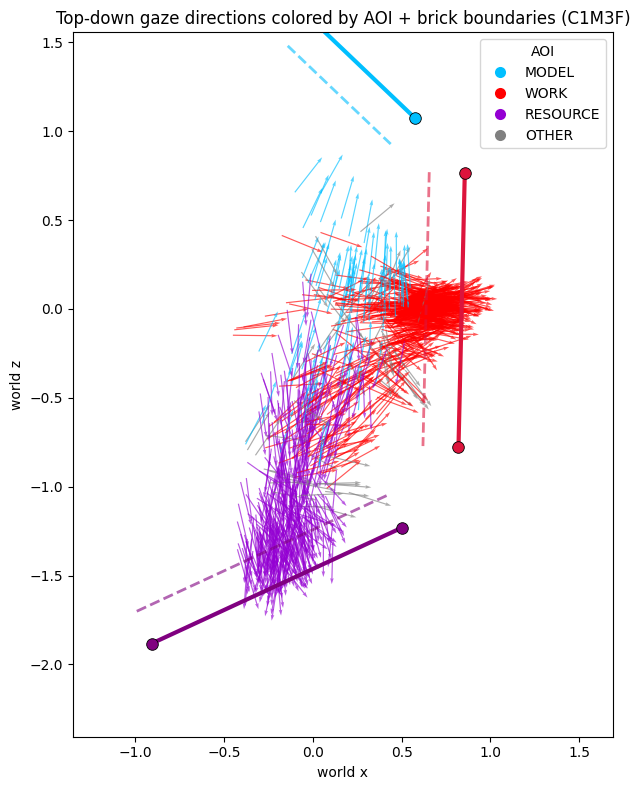

In [ ]:
# neww visuuualllss
import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# Filter to model C1M3F (all participants)
dfm = df[df["model_name"].astype(str).eq("C2M3F")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# Origins and directions (XZ)
x0 = dfm["hmd_position_x"].to_numpy(float)
z0 = dfm["hmd_position_z"].to_numpy(float)
dx = dfm["gaze_world_x"].to_numpy(float)
dz = dfm["gaze_world_z"].to_numpy(float)

aoi = dfm["AOI"].astype(str).to_numpy()
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

# normalize XZ dir for fixed arrow length
d2 = np.sqrt(dx*dx + dz*dz)
good = d2 > 1e-12
x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# downsample
target_arrows = 5000
step = max(1, len(x0) // target_arrows)
idx = np.arange(0, len(x0), step)

# AOI colors
aoi_to_color = {"WORK": "red", "MODEL": "deepskyblue", "RESOURCE": "darkviolet", "OTHER": "grey"}
colors = np.array([aoi_to_color.get(lbl, "grey") for lbl in aoi], dtype=object)

# plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.quiver(
    x0[idx], z0[idx], u[idx], v[idx],
    color=colors[idx],
    angles="xy", scale_units="xy", scale=1,
    width=0.0022, alpha=0.65
)

# overlay brick segments (walls)
# overlay brick segments (shifted + original dashed)
wall_color = {"MODEL": "deepskyblue", "WORK": "crimson", "RESOURCE": "purple"}

for aoi_name, (left_key, right_key) in aoi_bricks.items():

    # --- SHIFTED boundary (MAIN AOI line) ---
    Ls = np.array(brick_positions_shifted[left_key], dtype=float)
    Rs = np.array(brick_positions_shifted[right_key], dtype=float)

    ax.plot(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        linewidth=3,
        color=wall_color.get(aoi_name, "black"),
        label=f"{aoi_name} shifted"
    )

    ax.scatter(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        s=70,
        color=wall_color.get(aoi_name, "black"),
        edgecolor="black",
        linewidth=0.6,
        zorder=5
    )

    # --- ORIGINAL brick boundary (DASHED reference) ---
    L0 = np.array(brick_positions[left_key], dtype=float)
    R0 = np.array(brick_positions[right_key], dtype=float)

    ax.plot(
        [L0[0], R0[0]], [L0[2], R0[2]],
        linestyle="--",
        linewidth=2,
        alpha=0.6,
        color=wall_color.get(aoi_name, "black")
    )


ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x")
ax.set_ylabel("world z")
ax.set_title("Top-down gaze directions colored by AOI + brick boundaries (C1M3F)")

pad = 0.9
ax.set_xlim(x0.min() - pad, x0.max() + pad)
ax.set_ylim(z0.min() - pad, z0.max() + pad)

# legend
order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=aoi_to_color[k], markeredgecolor='none', label=k)
    for k in order
]
ax.legend(handles=handles, title="AOI", loc="best", frameon=True)

plt.tight_layout()
plt.show()


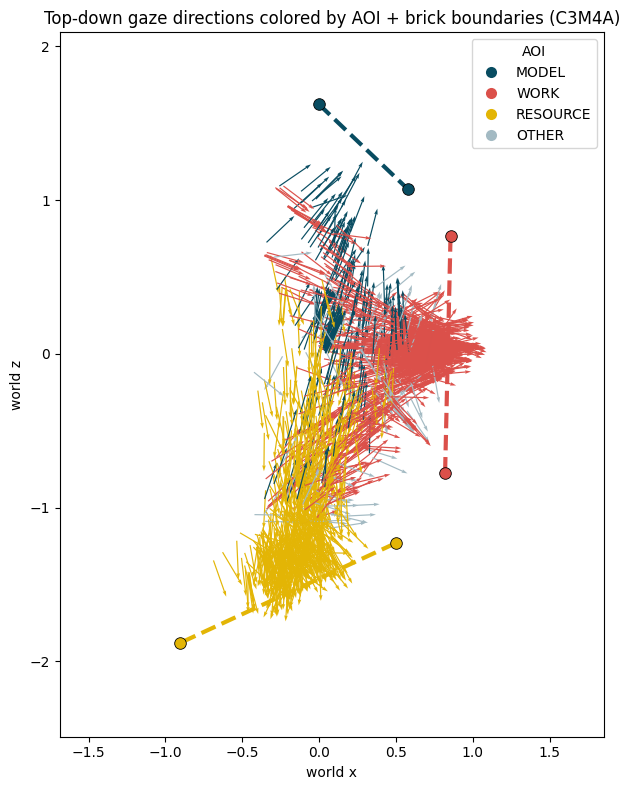

In [ ]:
# neww visuuualllss (improved palette + only "real" wall line dashed)

import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# Filter to model C1M3F (all participants)
dfm = df[df["model_name"].astype(str).eq("C3M4A")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# Origins and directions (XZ)
x0 = dfm["hmd_position_x"].to_numpy(float)
z0 = dfm["hmd_position_z"].to_numpy(float)
dx = dfm["gaze_world_x"].to_numpy(float)
dz = dfm["gaze_world_z"].to_numpy(float)

aoi = dfm["AOI"].astype(str).to_numpy()
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

# normalize XZ dir for fixed arrow length
d2 = np.sqrt(dx * dx + dz * dz)
good = d2 > 1e-12
x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# downsample
target_arrows = 5000
step = max(1, len(x0) // target_arrows)
idx = np.arange(0, len(x0), step)

# --- NEW PALETTE (from your image) ---
PALETTE = {
    "cool_steel": "#A3BAC3",
    "dark_teal":  "#084C61",
    "rosy_copper":"#DB504A",
    "saffron":    "#E3B505",
}

# AOI colors (updated)
aoi_to_color = {
    "WORK":     PALETTE["rosy_copper"],
    "MODEL":    PALETTE["dark_teal"],
    "RESOURCE": PALETTE["saffron"],
    "OTHER":    PALETTE["cool_steel"],
}
colors = np.array([aoi_to_color.get(lbl, PALETTE["cool_steel"]) for lbl in aoi], dtype=object)

# plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.quiver(
    x0[idx], z0[idx], u[idx], v[idx],
    color=colors[idx],
    angles="xy", scale_units="xy", scale=1,
    width=0.0022, alpha=0.99
)

# overlay brick segments (ONLY shifted "real" line, now dashed)
wall_color = {
    "MODEL":    PALETTE["dark_teal"],
    "WORK":     PALETTE["rosy_copper"],
    "RESOURCE": PALETTE["saffron"],
}

for aoi_name, (left_key, right_key) in aoi_bricks.items():
    # --- SHIFTED boundary ONLY (REAL) ---
    Ls = np.array(brick_positions_shifted[left_key], dtype=float)
    Rs = np.array(brick_positions_shifted[right_key], dtype=float)

    ax.plot(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        linestyle="--",          # real line is dashed
        linewidth=3,
        color=wall_color.get(aoi_name, "black"),
        label=f"{aoi_name} real"
    )

    ax.scatter(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        s=70,
        color=wall_color.get(aoi_name, "black"),
        edgecolor="black",
        linewidth=0.6,
        zorder=5
    )

# axes + title
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x")
ax.set_ylabel("world z")
ax.set_title("Top-down gaze directions colored by AOI + brick boundaries (C3M4A)")

pad = 1.0
ax.set_xlim(x0.min() - pad, x0.max() + pad)
ax.set_ylim(z0.min() - pad, z0.max() + pad)

# legend (AOI only, updated colors)
order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=aoi_to_color[k], markeredgecolor="none", label=k)
    for k in order
]
ax.legend(handles=handles, title="AOI", loc="best", frameon=True)

plt.tight_layout()
plt.show()


# plot sehr knallig

In [ ]:
# neww visuuualllss (improved palette + only "real" wall line dashed)

import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# Filter to model C1M3F (all participants)
dfm = df[df["model_name"].astype(str).eq("C3M4A")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# Origins and directions (XZ)
x0 = dfm["hmd_position_x"].to_numpy(float)
z0 = dfm["hmd_position_z"].to_numpy(float)
dx = dfm["gaze_world_x"].to_numpy(float)
dz = dfm["gaze_world_z"].to_numpy(float)

aoi = dfm["AOI"].astype(str).to_numpy()
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

# normalize XZ dir for fixed arrow length
d2 = np.sqrt(dx * dx + dz * dz)
good = d2 > 1e-12
x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# downsample
target_arrows = 5000
step = max(1, len(x0) // target_arrows)
idx = np.arange(0, len(x0), step)

# --- NEW COLORS (your request) ---
PALETTE = {
    "other":      "#A3BAC3",   # neutral for OTHER
    "model":      "deepskyblue",
    "work":       "red",
    "resource":   "#7E1EC2",   # deep purple (indigo)
}

# AOI colors
aoi_to_color = {
    "WORK":     PALETTE["work"],
    "MODEL":    PALETTE["model"],
    "RESOURCE": PALETTE["resource"],
    "OTHER":    PALETTE["other"],
}
colors = np.array([aoi_to_color.get(lbl, PALETTE["other"]) for lbl in aoi], dtype=object)

# plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.quiver(
    x0[idx], z0[idx], u[idx], v[idx],
    color=colors[idx],
    angles="xy", scale_units="xy", scale=1,
    width=0.0022, alpha=0.99
)

# overlay brick segments (ONLY shifted "real" line, now dashed)
wall_color = {
    "MODEL":    PALETTE["model"],
    "WORK":     PALETTE["work"],
    "RESOURCE": PALETTE["resource"],
}

for aoi_name, (left_key, right_key) in aoi_bricks.items():
    # --- SHIFTED boundary ONLY (REAL) ---
    Ls = np.array(brick_positions_shifted[left_key], dtype=float)
    Rs = np.array(brick_positions_shifted[right_key], dtype=float)

    ax.plot(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        linestyle="--",
        linewidth=3,
        color=wall_color.get(aoi_name, "black"),
        label=f"{aoi_name} real"
    )

    ax.scatter(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        s=70,
        color=wall_color.get(aoi_name, "black"),
        edgecolor="black",
        linewidth=0.6,
        zorder=5
    )

# axes + title
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x")
ax.set_ylabel("world z")
ax.set_title("Top-down gaze directions colored by AOI + brick boundaries (C3M4A)")

pad = 0.8
ax.set_xlim(x0.min() - pad, x0.max() + pad)
ax.set_ylim(z0.min() - pad, z0.max() + pad)

# legend
order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=aoi_to_color[k], markeredgecolor="none", label=k)
    for k in order
]
ax.legend(handles=handles, title="AOI", loc="best", frameon=True)

plt.tight_layout()
plt.show()


# AOI plot sarfran für alle models ( vlt noch farbe ändern)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- INPUTS expected to exist in your workspace ----
# object_gazes_final: DataFrame with columns used below
# aoi_bricks: dict like { "MODEL": ("left_key","right_key"), ... }
# brick_positions_shifted: dict mapping keys -> [x, y, z]
# ----------------------------------------------------

df = object_gazes_final.copy()

# --- Model names (as in your image) ---
MODEL_NAMES = [
    # Easy
    "C1M1F", "C1M2A",
    "C1M3F", "C1M4A",
    "C1M5F", "C1M6A",
    # Moderate
    "C2M1F", "C2M2A",
    "C2M3F", "C2M4A",
    "C2M5F", "C2M6A",
    # Hard
    "C3M1F", "C3M2A",
    "C3M3F", "C3M4A",
    "C3M5F", "C3M6A",
]

# --- Palette (yours) ---
PALETTE = {
    "cool_steel": "#A3BAC3",
    "dark_teal":  "#084C61",
    "rosy_copper":"#DB504A",
    "saffron":    "#E3B505",
}

aoi_to_color = {
    "WORK":     PALETTE["rosy_copper"],
    "MODEL":    PALETTE["dark_teal"],
    "RESOURCE": PALETTE["saffron"],
    "OTHER":    PALETTE["cool_steel"],
}

wall_color = {
    "MODEL":    PALETTE["dark_teal"],
    "WORK":     PALETTE["rosy_copper"],
    "RESOURCE": PALETTE["saffron"],
}

def _prep_model_df(df_all, model_name: str):
    dfm = df_all[df_all["model_name"].astype(str).eq(model_name)].copy()
    if "is_valid_model" in dfm.columns:
        dfm = dfm[dfm["is_valid_model"] == True].copy()

    # Origins and directions (XZ)
    x0 = dfm["hmd_position_x"].to_numpy(float)
    z0 = dfm["hmd_position_z"].to_numpy(float)
    dx = dfm["gaze_world_x"].to_numpy(float)
    dz = dfm["gaze_world_z"].to_numpy(float)

    aoi = dfm["AOI"].astype(str).to_numpy()
    aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

    mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
    x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

    # normalize XZ dir for fixed arrow length
    d2 = np.sqrt(dx * dx + dz * dz)
    good = d2 > 1e-12
    x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

    return x0, z0, dx, dz, d2, aoi

def plot_one_model(ax, df_all, model_name: str, *,
                   arrow_len=0.25,
                   target_arrows=2500,
                   pad=1.0,
                   force_limits=None):
    """
    force_limits: (xmin, xmax, zmin, zmax) or None
    """
    x0, z0, dx, dz, d2, aoi = _prep_model_df(df_all, model_name)

    if len(x0) == 0:
        ax.set_title(f"{model_name}\n(no data)")
        ax.axis("off")
        return None

    u = (dx / d2) * arrow_len
    v = (dz / d2) * arrow_len

    # downsample per model
    step = max(1, len(x0) // target_arrows)
    idx = np.arange(0, len(x0), step)

    colors = np.array([aoi_to_color.get(lbl, PALETTE["cool_steel"]) for lbl in aoi], dtype=object)

    ax.set_facecolor("white")

    ax.quiver(
        x0[idx], z0[idx], u[idx], v[idx],
        color=colors[idx],
        angles="xy", scale_units="xy", scale=1,
        width=0.0022, alpha=0.99
    )

    # overlay brick segments (ONLY shifted "real" line, dashed)
    for aoi_name, (left_key, right_key) in aoi_bricks.items():
        Ls = np.array(brick_positions_shifted[left_key], dtype=float)
        Rs = np.array(brick_positions_shifted[right_key], dtype=float)

        ax.plot(
            [Ls[0], Rs[0]], [Ls[2], Rs[2]],
            linestyle="--",
            linewidth=3,
            color=wall_color.get(aoi_name, "black"),
        )
        ax.scatter(
            [Ls[0], Rs[0]], [Ls[2], Rs[2]],
            s=50,
            color=wall_color.get(aoi_name, "black"),
            edgecolor="black",
            linewidth=0.6,
            zorder=5
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(model_name, fontsize=11)

    if force_limits is None:
        ax.set_xlim(x0.min() - pad, x0.max() + pad)
        ax.set_ylim(z0.min() - pad, z0.max() + pad)
        return (x0.min() - pad, x0.max() + pad, z0.min() - pad, z0.max() + pad)
    else:
        xmin, xmax, zmin, zmax = force_limits
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(zmin, zmax)
        return force_limits

# --- Compute global limits (so all subplots comparable) ---
all_xmins, all_xmaxs, all_zmins, all_zmaxs = [], [], [], []
for mn in MODEL_NAMES:
    x0, z0, dx, dz, d2, aoi = _prep_model_df(df, mn)
    if len(x0) == 0:
        continue
    pad = 1.0
    all_xmins.append(x0.min() - pad)
    all_xmaxs.append(x0.max() + pad)
    all_zmins.append(z0.min() - pad)
    all_zmaxs.append(z0.max() + pad)

GLOBAL_LIMITS = None
if len(all_xmins) > 0:
    GLOBAL_LIMITS = (min(all_xmins), max(all_xmaxs), min(all_zmins), max(all_zmaxs))

# --- Plot grid: 3 rows (Easy/Moderate/Hard) x 6 cols (F/A alternating, 3 models each) ---
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(22, 11), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

for i, mn in enumerate(MODEL_NAMES):
    r = i // 6
    c = i % 6
    ax = axes[r, c]
    plot_one_model(ax, df, mn, target_arrows=2500, force_limits=GLOBAL_LIMITS)

# labels only on left/bottom for cleanliness
for r in range(3):
    for c in range(6):
        ax = axes[r, c]
        if r == 2:
            ax.set_xlabel("world x")
        else:
            ax.set_xlabel("")
        if c == 0:
            ax.set_ylabel("world z")
        else:
            ax.set_ylabel("")

# --- One legend for AOI (global) ---
order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=aoi_to_color[k], markeredgecolor="none", label=k)
    for k in order
]
fig.legend(handles=handles, title="AOI", loc="upper right", frameon=True)

fig.suptitle("Top-down gaze directions colored by AOI + brick boundaries (ALL MODELS)", fontsize=16, y=0.98)

plt.tight_layout(rect=[0, 0, 0.98, 0.95])
plt.show()


NameError: name 'object_gazes_final' is not defined

# All 18 plots individual after 25 centimeter movement

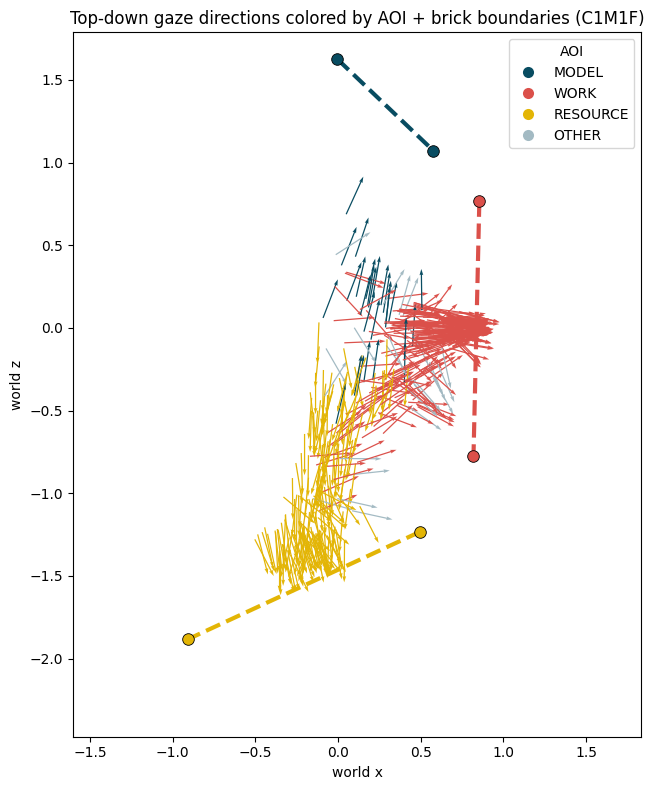

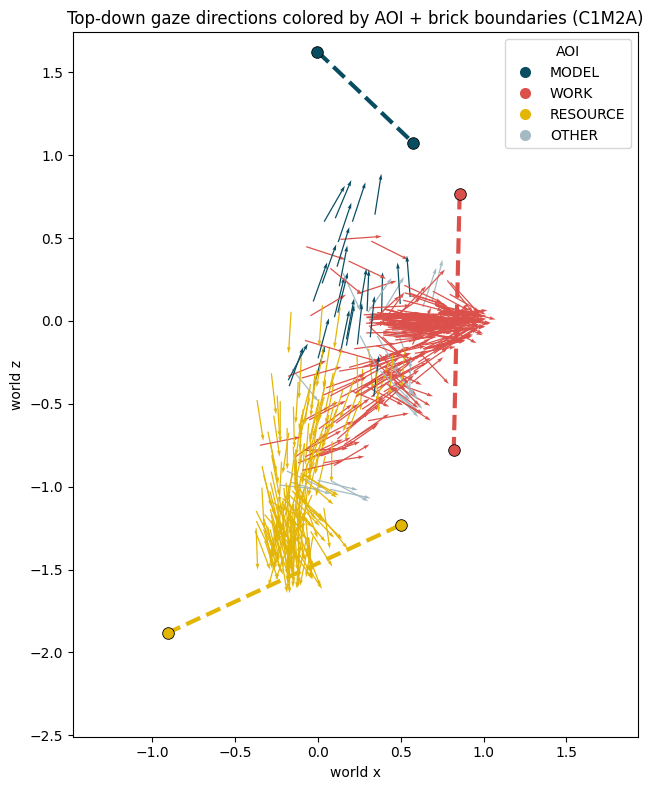

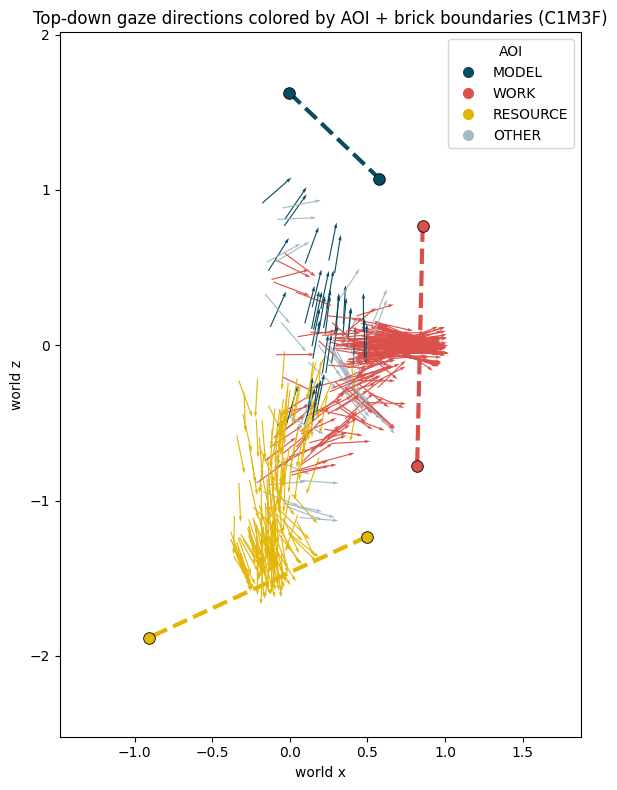

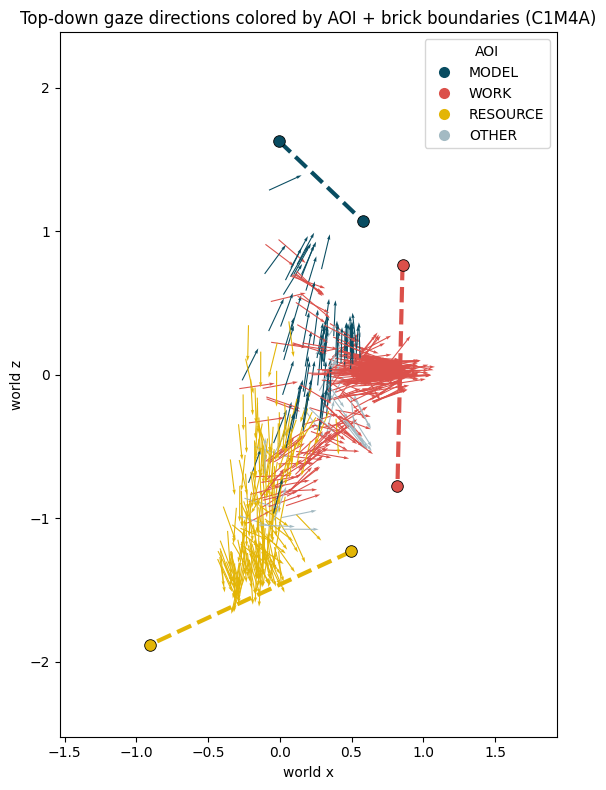

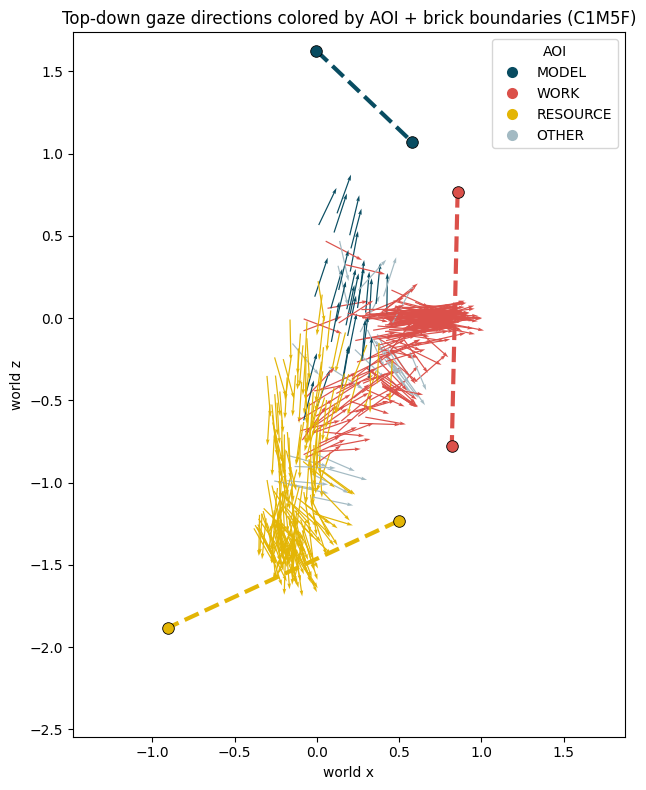

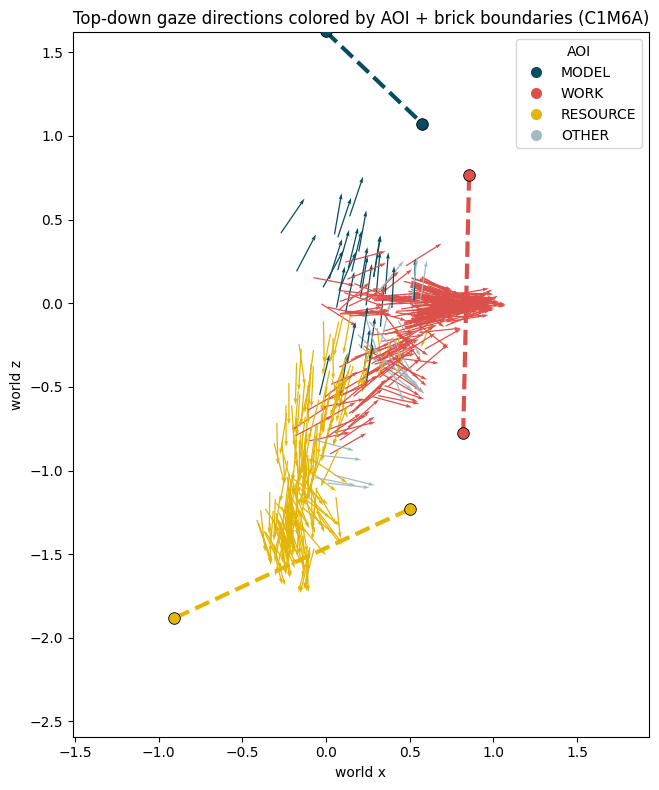

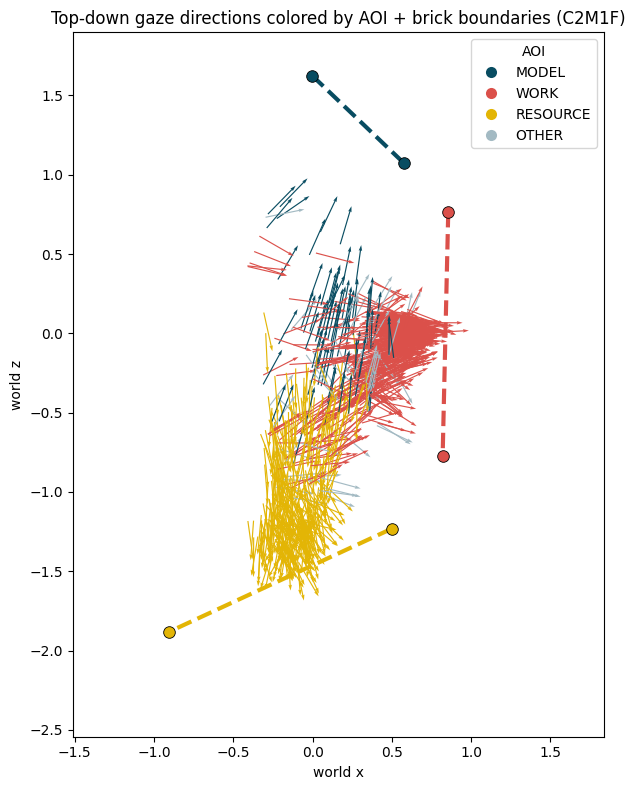

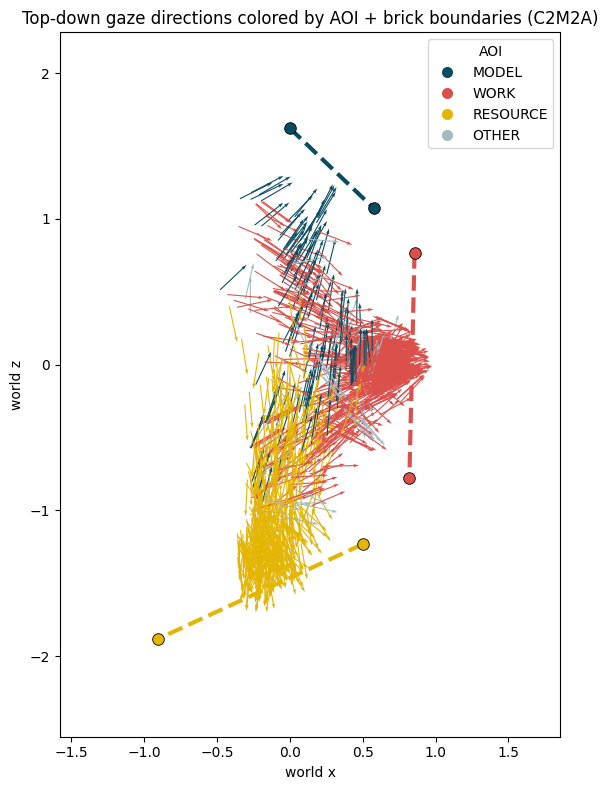

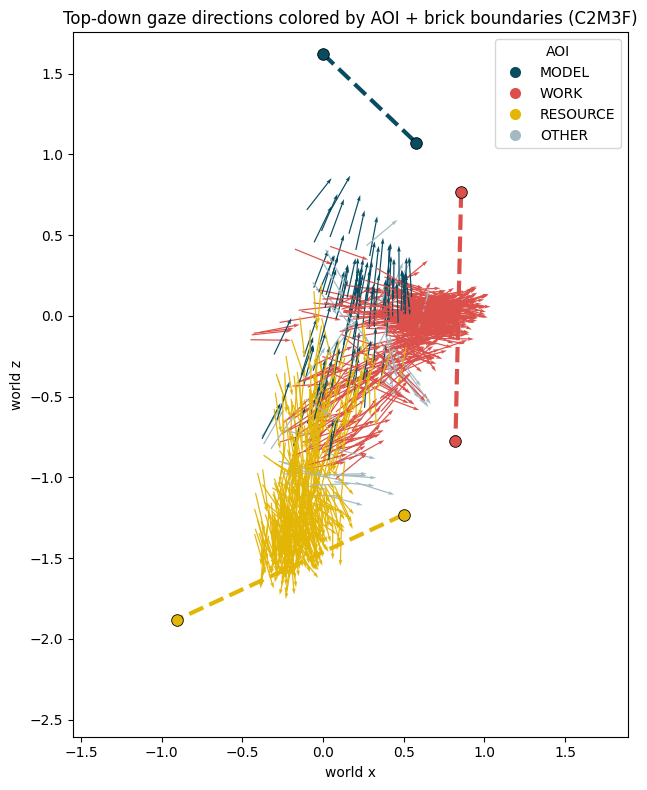

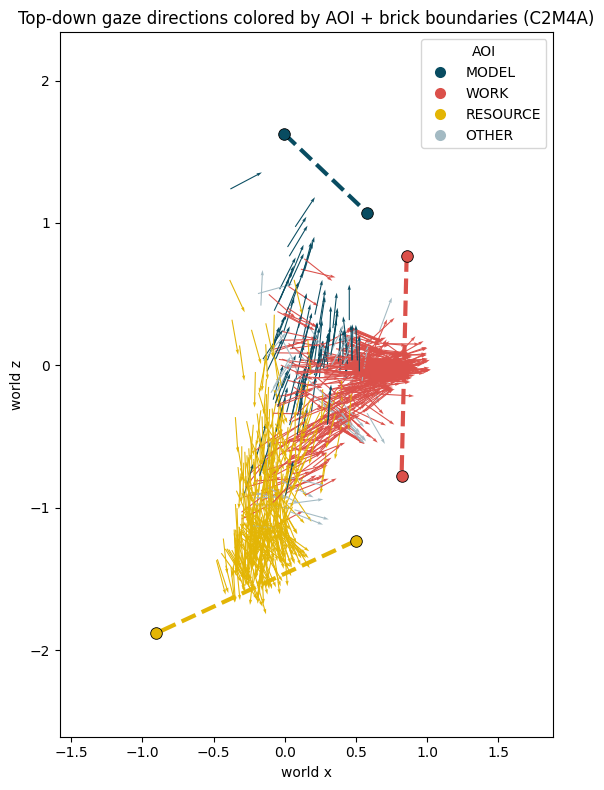

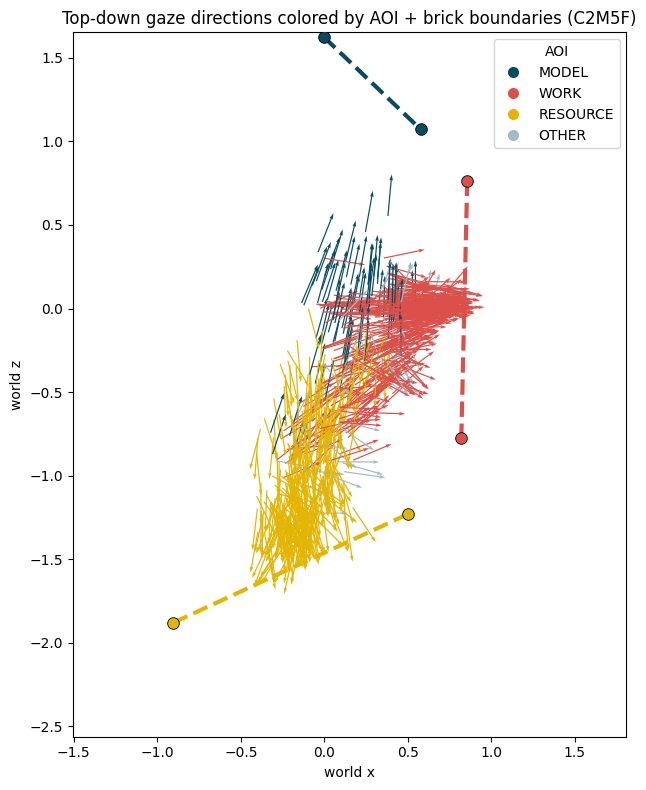

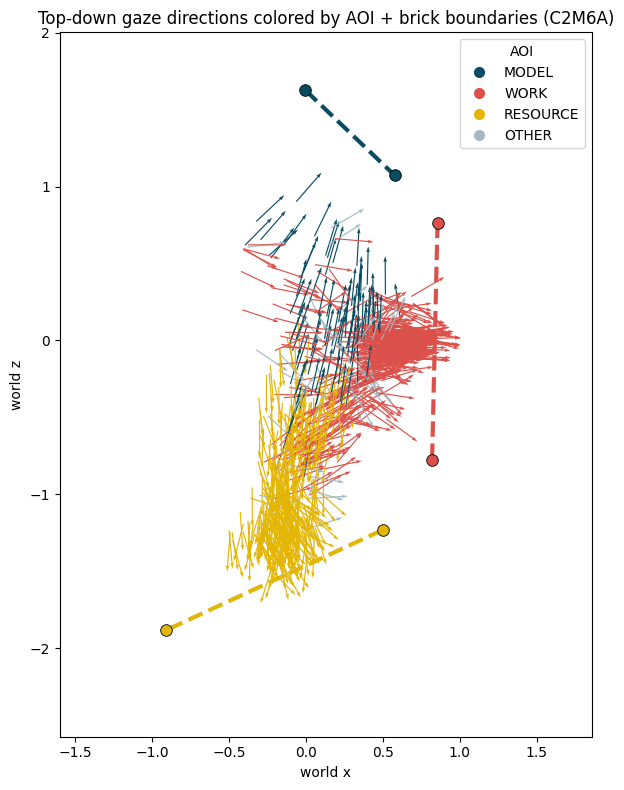

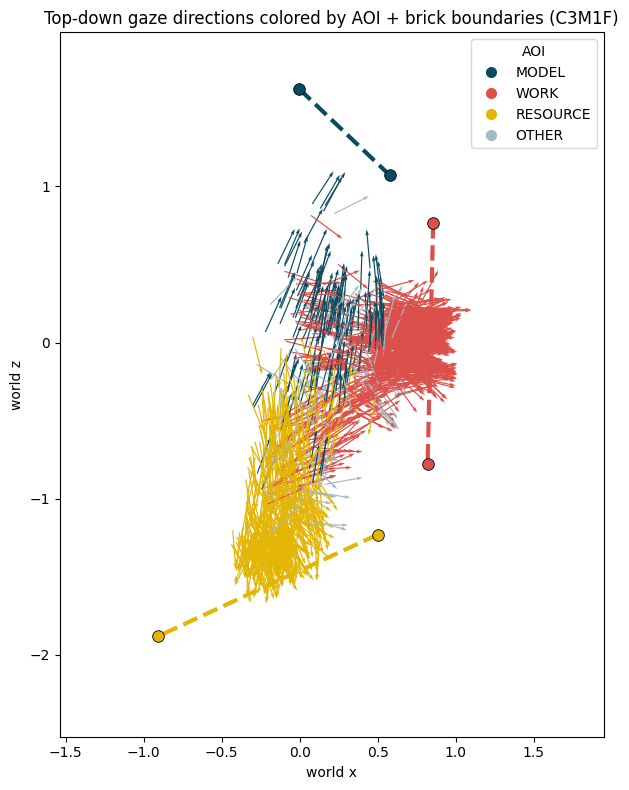

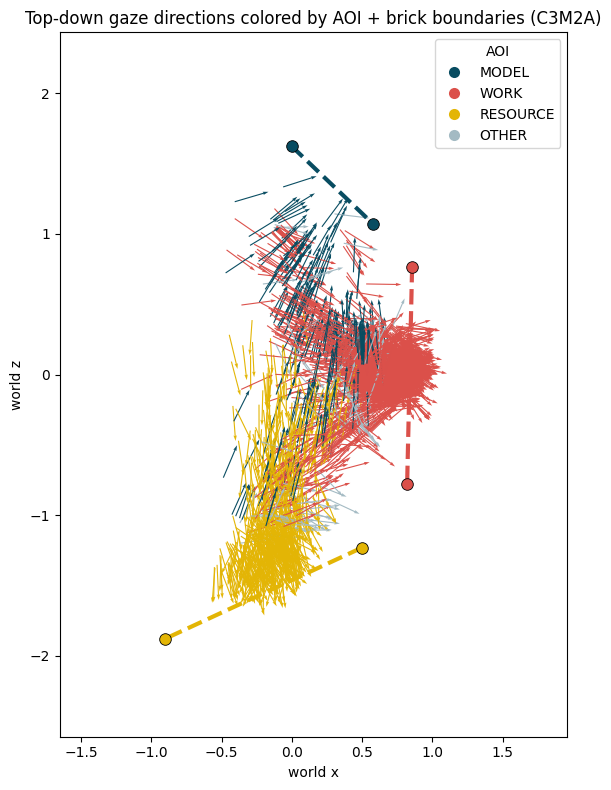

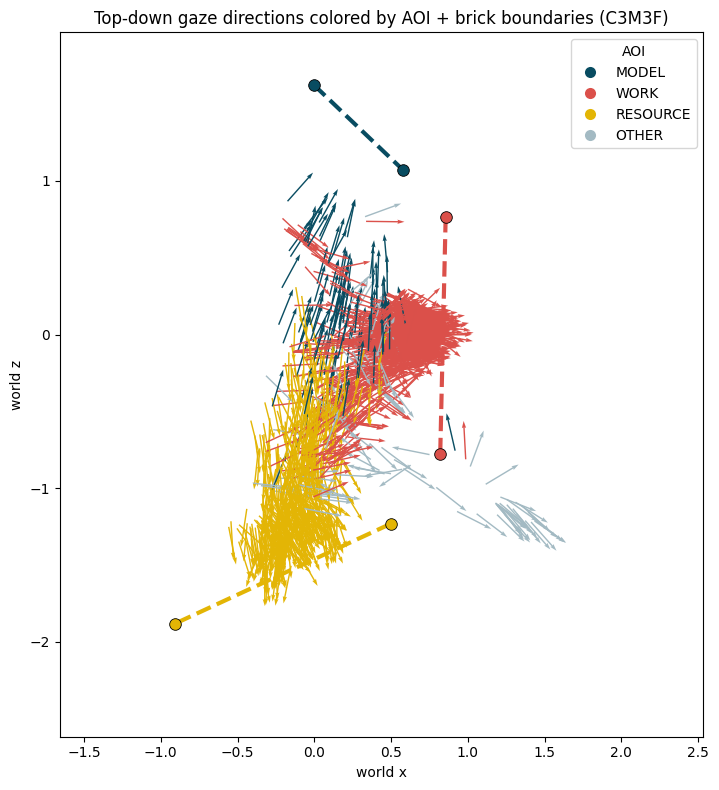

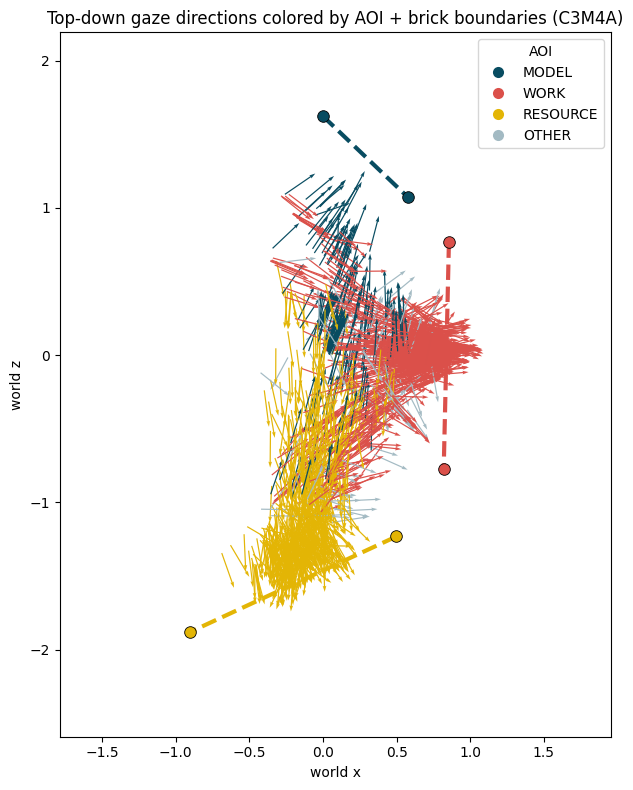

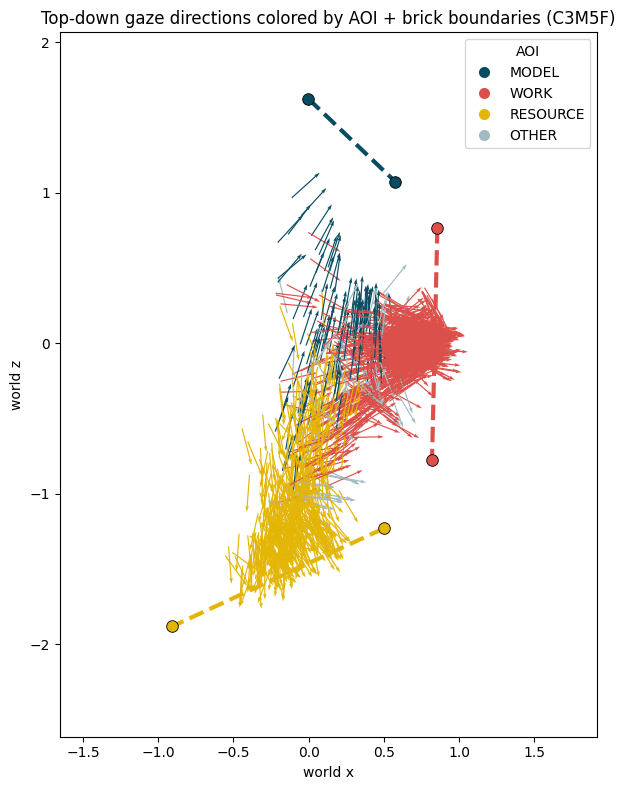

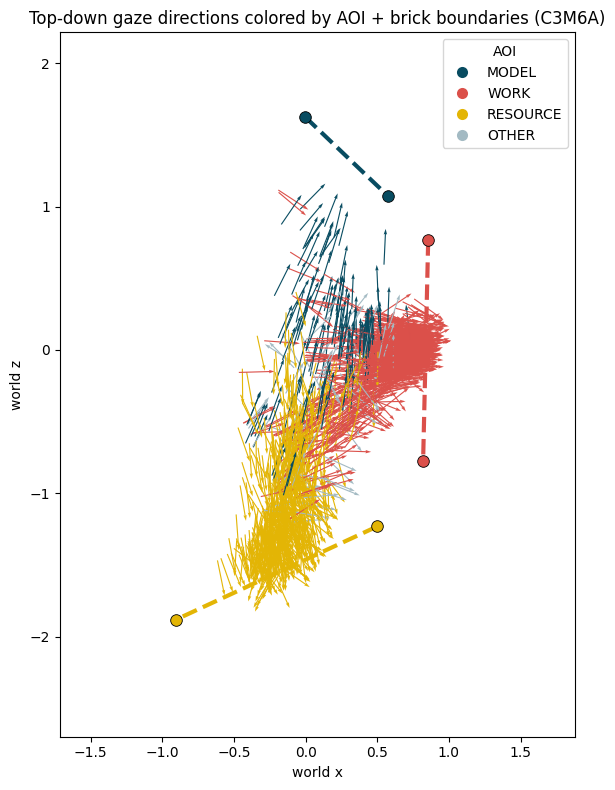

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# --- ALLE 18 MODELLE ---
MODEL_NAMES = [
    "C1M1F","C1M2A","C1M3F","C1M4A","C1M5F","C1M6A",
    "C2M1F","C2M2A","C2M3F","C2M4A","C2M5F","C2M6A",
    "C3M1F","C3M2A","C3M3F","C3M4A","C3M5F","C3M6A",
]

# --- NEW PALETTE ---
PALETTE = {
    "cool_steel": "#A3BAC3",
    "dark_teal":  "#084C61",
    "rosy_copper":"#DB504A",
    "saffron":    "#E3B505",
}

aoi_to_color = {
    "WORK":     PALETTE["rosy_copper"],
    "MODEL":    PALETTE["dark_teal"],
    "RESOURCE": PALETTE["saffron"],
    "OTHER":    PALETTE["cool_steel"],
}

wall_color = {
    "MODEL":    PALETTE["dark_teal"],
    "WORK":     PALETTE["rosy_copper"],
    "RESOURCE": PALETTE["saffron"],
}

# ======================================================
# LOOP: ONE BIG FIGURE PER MODEL  (wie dein alter Plot)
# ======================================================

for model_name in MODEL_NAMES:

    dfm = df[df["model_name"].astype(str).eq(model_name)].copy()
    if "is_valid_model" in dfm.columns:
        dfm = dfm[dfm["is_valid_model"] == True].copy()

    if len(dfm) == 0:
        print(f"skip {model_name} (no data)")
        continue

    # Origins and directions (XZ)
    x0 = dfm["hmd_position_x"].to_numpy(float)
    z0 = dfm["hmd_position_z"].to_numpy(float)
    dx = dfm["gaze_world_x"].to_numpy(float)
    dz = dfm["gaze_world_z"].to_numpy(float)

    aoi = dfm["AOI"].astype(str).to_numpy()
    aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

    mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
    x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

    # normalize XZ dir
    d2 = np.sqrt(dx * dx + dz * dz)
    good = d2 > 1e-12
    x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

    arrow_len = 0.25
    u = (dx / d2) * arrow_len
    v = (dz / d2) * arrow_len

    # downsample
    target_arrows = 5000
    step = max(1, len(x0) // target_arrows)
    idx = np.arange(0, len(x0), step)

    colors = np.array([aoi_to_color.get(lbl, PALETTE["cool_steel"]) for lbl in aoi], dtype=object)

    # ===================
    # FIGURE (GROSS!)
    # ===================
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.quiver(
        x0[idx], z0[idx], u[idx], v[idx],
        color=colors[idx],
        angles="xy", scale_units="xy", scale=1,
        width=0.0022, alpha=0.99
    )

    # overlay brick segments
    for aoi_name, (left_key, right_key) in aoi_bricks.items():
        Ls = np.array(brick_positions_shifted[left_key], dtype=float)
        Rs = np.array(brick_positions_shifted[right_key], dtype=float)

        ax.plot(
            [Ls[0], Rs[0]], [Ls[2], Rs[2]],
            linestyle="--",
            linewidth=3,
            color=wall_color.get(aoi_name, "black"),
        )

        ax.scatter(
            [Ls[0], Rs[0]], [Ls[2], Rs[2]],
            s=70,
            color=wall_color.get(aoi_name, "black"),
            edgecolor="black",
            linewidth=0.6,
            zorder=5
        )

    # axes
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("world x")
    ax.set_ylabel("world z")
    ax.set_title(f"Top-down gaze directions colored by AOI + brick boundaries ({model_name})")

    pad = 1.1
    ax.set_xlim(x0.min() - pad, x0.max() + pad)
    ax.set_ylim(z0.min() - pad, z0.max() + pad)

    # legend
    order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
                   markerfacecolor=aoi_to_color[k], markeredgecolor="none", label=k)
        for k in order
    ]
    ax.legend(handles=handles, title="AOI", loc="best", frameon=True)

    plt.tight_layout()
    plt.show()


# What objects still exist now in OTHER?


Objects that still receive OTHER gazes:

object_name_corr
work_desk_base         176
Floor                  156
Wall_Left              147
NextItemButton         144
Wall_Cut                94
Wall_Front              78
resource_desk_base      76
model_desk_base         40
Model_plate             14
Lego_4x2_Orange (1)      9
Lego_2x2_Pink            8
Lego_2x2_Blue            6
Lego_2x2_Pink (1)        4
Lego_2x2_Green (1)       3
Lego_2x2_Green (2)       3
Lego_1x3_Green           2
Wall_Back                2
Ceiling                  2
Lego_2x2_Orange          2
Lego_4x2_Pink (1)        1
Lego_4x2_Green           1
Lego_2x2_Green           1
Lego_1x3_Orange (1)      1
Lego_1x3_Pink (1)        1
Lego_4x2_Orange          1
Lego_3x2_Orange_Dis      1
Lamp_Back_Left           1
Lego_2x2_Pink (2)        1
Lego_4x2_Green (1)       1
Name: count, dtype: int64


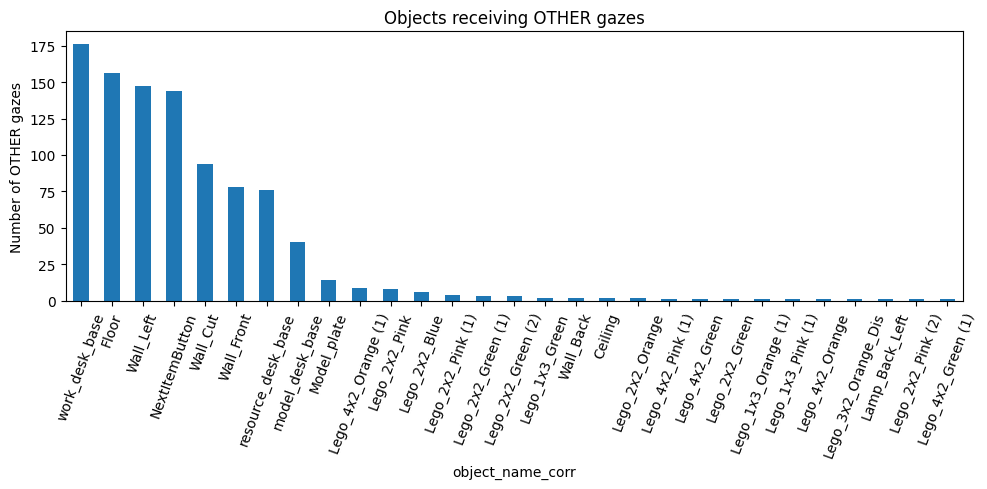

In [ ]:
import matplotlib.pyplot as plt

# WICHTIG: nicht neu aus object_gazes_final kopieren,
# sondern mit dem bereits bearbeiteten df weiterarbeiten
# Falls du unsicher bist:
df = df.copy()

# --- nur valide Bauphase ---
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True].copy()

# --- prüfen welche Spalte wir nehmen ---
name_col = "object_name_corr" if "object_name_corr" in df.columns else "object_name"

# --- OTHER gazes auswählen ---
df_other = df[df["AOI"].astype(str) == "OTHER"].copy()

print("\nObjects that still receive OTHER gazes:\n")

other_counts = (
    df_other[name_col]
    .astype(str)
    .value_counts()
    .sort_values(ascending=False)
)

print(other_counts)

# --- Plot ---
plt.figure(figsize=(10,5))
other_counts.plot(kind="bar")

plt.title("Objects receiving OTHER gazes")
plt.xlabel(name_col)
plt.ylabel("Number of OTHER gazes")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


# generelle OTHER IM GESAMTEN EXPERIMENT

Objects receiving OTHER gazes:
object_name_corr
ContinueButton         456
Floor                  440
work_desk_base         397
Wall_Left              211
NextItemButton         209
Wall_Cut               145
PlaneLeft              128
resource_desk_base      96
Wall_Front              87
model_desk_base         60
PlaneRight              39
Model_plate             18
Lego_4x2_Orange (1)      9
Lego_2x2_Pink            8
Wall_Back                7
Lego_2x2_Blue            6
Lego_1x3_Pink (1)        6
Lego_2x2_Orange          6
Lego_4x2_Blue            4
Lego_2x2_Pink (1)        4
Lego_2x2_Green (2)       3
Lego_1x3_Green           3
Lego_2x2_Green (1)       3
Ceiling                  2
separatorDoor_body       2
Lego_4x2_Green (1)       2
Lego_3x2_Orange_Dis      1
Lamp_Back_Left           1
Lego_4x2_Orange          1
Lego_2x2_Pink (2)        1
Lego_2x2_Green           1
Lego_4x2_Green           1
Lego_4x2_Pink (1)        1
Lego_1x3_Orange (1)      1
Name: count, dtype: int64


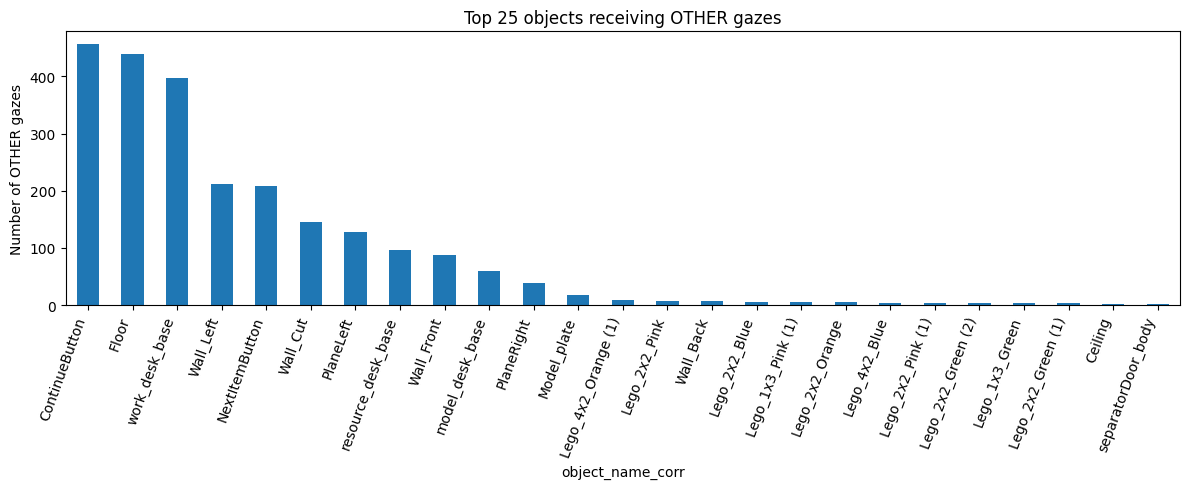

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# OPTIONAL: nur aktive Bauphase
# df = df[df["is_valid_model"].eq(True)].copy()

# OPTIONAL: falls du lieber die korrigierten Namen nutzen willst:
name_col = "object_name_corr"   # oder: "object_name_corr" wenn du damit arbeitest

# OTHER filtern (robust gegen NaN/None/leer)
aoi = df["AOI"].astype(str)
is_other = aoi.eq("OTHER") | aoi.isin(["nan", "None", ""])  # falls bei dir sowas vorkommt
df_other = df[is_other].copy()

# Zählen
other_counts = (
    df_other[name_col]
    .dropna()
    .astype(str)
    .value_counts()
)

print("Objects receiving OTHER gazes:")
print(other_counts)

# Plot: Top N (damit es lesbar bleibt)
TOP_N = 25
top = other_counts.head(TOP_N)

plt.figure(figsize=(12, 5))
top.plot(kind="bar")
plt.title(f"Top {TOP_N} objects receiving OTHER gazes")
plt.xlabel(name_col)
plt.ylabel("Number of OTHER gazes")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()


# in corret building phase the otherss

Objects receiving OTHER gazes during active build phase:
object_name_corr
work_desk_base         176
Floor                  156
Wall_Left              147
NextItemButton         144
Wall_Cut                94
Wall_Front              78
resource_desk_base      76
model_desk_base         40
Model_plate             14
Lego_4x2_Orange (1)      9
Lego_2x2_Pink            8
Lego_2x2_Blue            6
Lego_2x2_Pink (1)        4
Lego_2x2_Green (2)       3
Lego_2x2_Green (1)       3
Lego_1x3_Green           2
Wall_Back                2
Ceiling                  2
Lego_2x2_Orange          2
Lego_4x2_Pink (1)        1
Lego_4x2_Green           1
Lego_2x2_Green           1
Lego_1x3_Orange (1)      1
Lego_1x3_Pink (1)        1
Lego_4x2_Orange          1
Lego_3x2_Orange_Dis      1
Lamp_Back_Left           1
Lego_2x2_Pink (2)        1
Lego_4x2_Green (1)       1
Name: count, dtype: int64


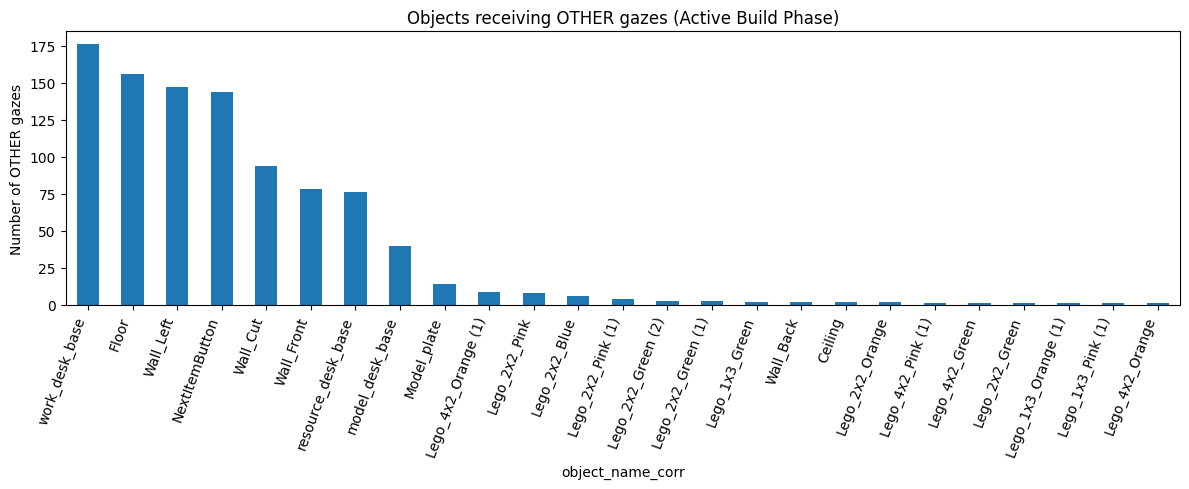

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# 1️⃣ Nur aktive Bauphase
df = df[df["is_valid_model"] == True].copy()

# 2️⃣ OTHER Gazes auswählen (nur echte OTHER)
df_other = df[df["AOI"] == "OTHER"].copy()

# 3️⃣ Nach korrigiertem Objektnamen zählen
other_counts = (
    df_other["object_name_corr"]
    .dropna()
    .astype(str)
    .value_counts()
)

print("Objects receiving OTHER gazes during active build phase:")
print(other_counts)

# Plot
plt.figure(figsize=(12, 5))
other_counts.head(25).plot(kind="bar")
plt.title("Objects receiving OTHER gazes (Active Build Phase)")
plt.xlabel("object_name_corr")
plt.ylabel("Number of OTHER gazes")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# --- nur valide Bauphase (optional aber empfohlen) ---
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True].copy()

# --- OTHER gazes auswählen ---
df_other = df[df["AOI"].astype(str) == "OTHER"].copy()

print("\nObjects that still receive OTHER gazes:\n")

other_counts = (
    df_other["object_name_corr"]
    .astype(str)
    .value_counts()
    .sort_values(ascending=False)
)

print(other_counts)

# =========================
# Plot (sehr hilfreich!)
# =========================
plt.figure(figsize=(10,5))

other_counts.plot(kind="bar")

plt.title("Objects receiving OTHER gazes")
plt.xlabel("object_name_corr")
plt.ylabel("Number of OTHER gazes")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


# NOW AOI PLOTS WITHOUT OTHER GAZES

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# --- ALLE 18 MODELLE ---
MODEL_NAMES = [
    "C1M1F","C1M2A","C1M3F","C1M4A","C1M5F","C1M6A",
    "C2M1F","C2M2A","C2M3F","C2M4A","C2M5F","C2M6A",
    "C3M1F","C3M2A","C3M3F","C3M4A","C3M5F","C3M6A",
]

# --- NEW PALETTE ---
PALETTE = {
    "cool_steel": "#A3BAC3",
    "dark_teal":  "#084C61",
    "rosy_copper":"#DB504A",
    "saffron":    "#E3B505",
}

aoi_to_color = {
    "WORK":     PALETTE["rosy_copper"],
    "MODEL":    PALETTE["dark_teal"],
    "RESOURCE": PALETTE["saffron"],
    "OTHER":    PALETTE["cool_steel"],
}

wall_color = {
    
    "MODEL":    PALETTE["dark_teal"],
    "WORK":     PALETTE["rosy_copper"],
    "RESOURCE": PALETTE["saffron"],
}

# ======================================================
# LOOP: ONE BIG FIGURE PER MODEL  (wie dein alter Plot)
# ======================================================

for model_name in MODEL_NAMES:

    dfm = df[df["model_name"].astype(str).eq(model_name)].copy()
    if "is_valid_model" in dfm.columns:
        dfm = dfm[dfm["is_valid_model"] == True].copy()

    if len(dfm) == 0:
        print(f"skip {model_name} (no data)")
        continue

    # Origins and directions (XZ)
    x0 = dfm["hmd_position_x"].to_numpy(float)
    z0 = dfm["hmd_position_z"].to_numpy(float)
    dx = dfm["gaze_world_x"].to_numpy(float)
    dz = dfm["gaze_world_z"].to_numpy(float)

    aoi = dfm["AOI"].astype(str).to_numpy()
    aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

    mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
    x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

    # normalize XZ dir
    d2 = np.sqrt(dx * dx + dz * dz)
    good = d2 > 1e-12
    x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

    # ==========================
    # NEW: remove OTHER gazes
    # ==========================
    keep = aoi != "OTHER"
    x0, z0, dx, dz, d2, aoi = x0[keep], z0[keep], dx[keep], dz[keep], d2[keep], aoi[keep]

    if len(x0) == 0:
        print(f"skip {model_name} (only OTHER after filtering)")
        continue

    arrow_len = 0.25
    u = (dx / d2) * arrow_len
    v = (dz / d2) * arrow_len

    # downsample
    target_arrows = 5000
    step = max(1, len(x0) // target_arrows)
    idx = np.arange(0, len(x0), step)

    colors = np.array([aoi_to_color.get(lbl, PALETTE["cool_steel"]) for lbl in aoi], dtype=object)

    # ===================
    # FIGURE (GROSS!)
    # ===================
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.quiver(
        x0[idx], z0[idx], u[idx], v[idx],
        color=colors[idx],
        angles="xy", scale_units="xy", scale=1,
        width=0.0022, alpha=0.99
    )

    # overlay brick segments
    for aoi_name, (left_key, right_key) in aoi_bricks.items():
        Ls = np.array(brick_positions_shifted[left_key], dtype=float)
        Rs = np.array(brick_positions_shifted[right_key], dtype=float)

        ax.plot(
            [Ls[0], Rs[0]], [Ls[2], Rs[2]],
            linestyle="--",
            linewidth=3,
            color=wall_color.get(aoi_name, "black"),
        )

        ax.scatter(
            [Ls[0], Rs[0]], [Ls[2], Rs[2]],
            s=70,
            color=wall_color.get(aoi_name, "black"),
            edgecolor="black",
            linewidth=0.6,
            zorder=5
        )

    # axes
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("world x")
    ax.set_ylabel("world z")
    ax.set_title(f"Top-down gaze directions colored by AOI + brick boundaries ({model_name})")

    pad = 1.1
    ax.set_xlim(x0.min() - pad, x0.max() + pad)
    ax.set_ylim(z0.min() - pad, z0.max() + pad)

    # legend (OHNE OTHER)
    order = ["MODEL", "WORK", "RESOURCE"]
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
                   markerfacecolor=aoi_to_color[k], markeredgecolor="none", label=k)
        for k in order
    ]
    ax.legend(handles=handles, title="AOI", loc="best", frameon=True)

    plt.tight_layout()
    plt.show()


# ENDE VON AOIS MACHEN!!!!!!!!!!!!

In [ ]:
# neww visuuualllss (professional aesthetic palette)

import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# Filter to model C1M3F (all participants)
dfm = df[df["model_name"].astype(str).eq("C1M3F")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# Origins and directions (XZ)
x0 = dfm["hmd_position_x"].to_numpy(float)
z0 = dfm["hmd_position_z"].to_numpy(float)
dx = dfm["gaze_world_x"].to_numpy(float)
dz = dfm["gaze_world_z"].to_numpy(float)

aoi = dfm["AOI"].astype(str).to_numpy()
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

# normalize XZ dir for fixed arrow length
d2 = np.sqrt(dx * dx + dz * dz)
good = d2 > 1e-12
x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# downsample
target_arrows = 5000
step = max(1, len(x0) // target_arrows)
idx = np.arange(0, len(x0), step)

# --- PROFESSIONAL AESTHETIC PALETTE ---
PALETTE = {
    "model_blue":    "#163A59",
    "work_coral":    "#E45756",
    "resource_teal": "#2A9D8F",
    "other_soft":    "#D5E3EA",
}

aoi_to_color = {
    "MODEL":    PALETTE["model_blue"],
    "WORK":     PALETTE["work_coral"],
    "RESOURCE": PALETTE["resource_teal"],
    "OTHER":    PALETTE["other_soft"],
}

colors = np.array([aoi_to_color.get(lbl, PALETTE["other_soft"]) for lbl in aoi], dtype=object)

# plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.quiver(
    x0[idx], z0[idx], u[idx], v[idx],
    color=colors[idx],
    angles="xy", scale_units="xy", scale=1,
    width=0.0026,
    alpha=0.9
)

# overlay brick segments (real dashed)
wall_color = {
    "MODEL":    PALETTE["model_blue"],
    "WORK":     PALETTE["work_coral"],
    "RESOURCE": PALETTE["resource_teal"],
}

for aoi_name, (left_key, right_key) in aoi_bricks.items():
    Ls = np.array(brick_positions_shifted[left_key], dtype=float)
    Rs = np.array(brick_positions_shifted[right_key], dtype=float)

    ax.plot(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        linestyle="--",
        linewidth=3,
        color=wall_color.get(aoi_name, "black")
    )

    ax.scatter(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        s=70,
        color=wall_color.get(aoi_name, "black"),
        edgecolor="black",
        linewidth=0.6,
        zorder=5
    )

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x")
ax.set_ylabel("world z")
ax.set_title("Top-down gaze directions colored by AOI + brick boundaries (C1M3F)")

pad = 0.8
ax.set_xlim(x0.min() - pad, x0.max() + pad)
ax.set_ylim(z0.min() - pad, z0.max() + pad)

order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=aoi_to_color[k], markeredgecolor="none", label=k)
    for k in order
]
ax.legend(handles=handles, title="AOI", loc="best", frameon=True)

plt.tight_layout()
plt.show()


NameError: name 'object_gazes_final' is not defined

In [ ]:
# neww visuuualllss (publication-style aesthetic + visible OTHER arrows)

import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# Filter to model C1M3F (all participants)
dfm = df[df["model_name"].astype(str).eq("C1M3F")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# Origins and directions (XZ)
x0 = dfm["hmd_position_x"].to_numpy(float)
z0 = dfm["hmd_position_z"].to_numpy(float)
dx = dfm["gaze_world_x"].to_numpy(float)
dz = dfm["gaze_world_z"].to_numpy(float)

aoi = dfm["AOI"].astype(str).to_numpy()
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

# normalize XZ dir for fixed arrow length
d2 = np.sqrt(dx * dx + dz * dz)
good = d2 > 1e-12
x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# downsample
target_arrows = 5000
step = max(1, len(x0) // target_arrows)
idx = np.arange(0, len(x0), step)

# --- PROFESSIONAL PALETTE ---
PALETTE = {
    "model_blue":    "#163A59",
    "work_coral":    "#E45756",
    "resource_teal": "#2A9D8F",
    "other_soft":    "#AEBFCC",   # <-- darker gray-blue so it's visible on warm bg
}

aoi_to_color = {
    "MODEL":    PALETTE["model_blue"],
    "WORK":     PALETTE["work_coral"],
    "RESOURCE": PALETTE["resource_teal"],
    "OTHER":    PALETTE["other_soft"],
}

# Per-AOI alpha so OTHER shows up but stays subtle
aoi_to_alpha = {
    "MODEL":    0.90,
    "WORK":     0.88,
    "RESOURCE": 0.88,
    "OTHER":    0.70,   # <-- increased so you can see it
}

# --- FIGURE STYLE (warm off-white background) ---
WARM_BG = "#F6F3EF"
AXIS_SOFT = "#6E6A66"
SPINE_SOFT = "#B8B2AA"
TEXT_DARK = "#2E2A27"

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(WARM_BG)
ax.set_facecolor(WARM_BG)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(SPINE_SOFT)

ax.tick_params(colors=AXIS_SOFT)
ax.xaxis.label.set_color(AXIS_SOFT)
ax.yaxis.label.set_color(AXIS_SOFT)
ax.title.set_color(TEXT_DARK)

# --- GAZE ARROWS (draw per AOI to control alpha) ---
for lbl in ["MODEL", "WORK", "RESOURCE", "OTHER"]:
    sel = (aoi[idx] == lbl)
    if not np.any(sel):
        continue

    ax.quiver(
        x0[idx][sel], z0[idx][sel], u[idx][sel], v[idx][sel],
        color=aoi_to_color[lbl],
        angles="xy", scale_units="xy", scale=1,
        width=0.0026,
        alpha=aoi_to_alpha[lbl],
        zorder=2 if lbl != "OTHER" else 1  # keep OTHER behind
    )

# --- WALL LINES (shifted real, dashed) ---
wall_color = {
    "MODEL":    PALETTE["model_blue"],
    "WORK":     PALETTE["work_coral"],
    "RESOURCE": PALETTE["resource_teal"],
}

for aoi_name, (left_key, right_key) in aoi_bricks.items():
    Ls = np.array(brick_positions_shifted[left_key], dtype=float)
    Rs = np.array(brick_positions_shifted[right_key], dtype=float)

    ax.plot(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        linestyle="--",
        linewidth=3,
        color=wall_color.get(aoi_name, "#444444"),
        zorder=5
    )

    ax.scatter(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        s=70,
        color=wall_color.get(aoi_name, "#444444"),
        edgecolor=TEXT_DARK,
        linewidth=0.6,
        zorder=6
    )

# --- AXES + TITLE ---
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x")
ax.set_ylabel("world z")
ax.set_title("Top-down gaze directions colored by AOI + brick boundaries (C1M3F)")

pad = 0.8
ax.set_xlim(x0.min() - pad, x0.max() + pad)
ax.set_ylim(z0.min() - pad, z0.max() + pad)

# --- LEGEND (warm off-white, not white) ---
order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=aoi_to_color[k], markeredgecolor="none",
               alpha=aoi_to_alpha[k], label=k)
    for k in order
]

leg = ax.legend(handles=handles, title="AOI", loc="best", frameon=True)
leg.get_frame().set_facecolor(WARM_BG)
leg.get_frame().set_edgecolor("#D8D2CA")
leg.get_frame().set_alpha(0.95)
for t in leg.get_texts():
    t.set_color(TEXT_DARK)
leg.get_title().set_color(TEXT_DARK)

plt.tight_layout()
plt.show()


NameError: name 'object_gazes_final' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# Filter to model C1M3F (all participants)
dfm = df[df["model_name"].astype(str).eq("C1M3F")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# Origins and directions (XZ)
x0 = dfm["hmd_position_x"].to_numpy(float)
z0 = dfm["hmd_position_z"].to_numpy(float)
dx = dfm["gaze_world_x"].to_numpy(float)
dz = dfm["gaze_world_z"].to_numpy(float)

aoi = dfm["AOI"].astype(str).to_numpy()
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

# normalize XZ dir for fixed arrow length
d2 = np.sqrt(dx * dx + dz * dz)
good = d2 > 1e-12
x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# downsample
target_arrows = 5000
step = max(1, len(x0) // target_arrows)
idx = np.arange(0, len(x0), step)

# --- PALETTE (your latest image) ---
PALETTE = {
    "deep_space_blue": "#0B3954",
    "teal":            "#087E8B",
    "pale_sky":        "#BFD7EA",
    "vibrant_coral":   "#FF5A5F",
}

aoi_to_color = {
    "MODEL":    PALETTE["deep_space_blue"],
    "WORK":     PALETTE["vibrant_coral"],
    "RESOURCE": PALETTE["teal"],
    "OTHER":    PALETTE["pale_sky"],
}

# Extra separation: different opacity per AOI (keeps colors but makes layers readable)
aoi_to_alpha = {
    "MODEL":    0.85,
    "WORK":     0.75,
    "RESOURCE": 0.75,
    "OTHER":    0.35,   # keep OTHER faint so it doesn't wash everything out
}

# Build per-point arrays
aoi_idx = aoi[idx]
colors = np.array([aoi_to_color.get(lbl, PALETTE["pale_sky"]) for lbl in aoi_idx], dtype=object)
alphas = np.array([aoi_to_alpha.get(lbl, 0.6) for lbl in aoi_idx], dtype=float)

# plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ---- 1) outline pass (dark, slightly thicker) ----
ax.quiver(
    x0[idx], z0[idx], u[idx], v[idx],
    color="#062735",                 # very dark blue-ish outline
    angles="xy", scale_units="xy", scale=1,
    width=0.0034, alpha=0.18,        # light outline
    zorder=1
)

# ---- 2) colored pass (your AOI colors on top) ----
# Matplotlib's quiver takes a single alpha, so we draw per-AOI groups to use different alphas.
for lbl in ["MODEL", "WORK", "RESOURCE", "OTHER"]:
    sel = (aoi_idx == lbl)
    if not np.any(sel):
        continue
    ax.quiver(
        x0[idx][sel], z0[idx][sel], u[idx][sel], v[idx][sel],
        color=aoi_to_color[lbl],
        angles="xy", scale_units="xy", scale=1,
        width=0.0024,
        alpha=aoi_to_alpha[lbl],
        zorder=2
    )

# overlay brick segments (ONLY shifted "real" line, dashed)
wall_color = {
    "MODEL":    PALETTE["deep_space_blue"],
    "WORK":     PALETTE["vibrant_coral"],
    "RESOURCE": PALETTE["teal"],
}

for aoi_name, (left_key, right_key) in aoi_bricks.items():
    Ls = np.array(brick_positions_shifted[left_key], dtype=float)
    Rs = np.array(brick_positions_shifted[right_key], dtype=float)

    ax.plot(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        linestyle="--",
        linewidth=3,
        color=wall_color.get(aoi_name, "black"),
        zorder=5
    )

    ax.scatter(
        [Ls[0], Rs[0]], [Ls[2], Rs[2]],
        s=70,
        color=wall_color.get(aoi_name, "black"),
        edgecolor="black",
        linewidth=0.6,
        zorder=6
    )

# axes + title
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x")
ax.set_ylabel("world z")
ax.set_title("Top-down gaze directions colored by AOI + brick boundaries (C1M3F)")

pad = 0.6
ax.set_xlim(x0.min() - pad, x0.max() + pad)
ax.set_ylim(z0.min() - pad, z0.max() + pad)

# legend (AOI only)
order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=aoi_to_color[k], markeredgecolor="none", label=k,
               alpha=aoi_to_alpha[k])
    for k in order
]
ax.legend(handles=handles, title="AOI", loc="best", frameon=True)

plt.tight_layout()
plt.show()


NameError: name 'object_gazes_final' is not defined

# Check if everything went right AOI COUHNTS WHAT GOT CUT OUT

In [ ]:
object_gazes_final.head(20)


In [ ]:
import numpy as np
import pandas as pd

# ---------------------------------------
# Sensitivity check: 0cm → 20cm inward
# ---------------------------------------

offsets = np.arange(0.00, 0.21, 0.05)  # 0, 5cm, 10cm, 15cm, 20cm

rows = []

# Use C1M3F subset to decide inward direction (as before)
df_dir = object_gazes_final[
    object_gazes_final["model_name"].astype(str).eq("C1M3F")
].copy()

for off in offsets:

    # shift geometry
    bricks_shift = make_brick_positions_shifted_deeper(
        brick_positions=brick_positions,
        aoi_bricks=aoi_bricks,
        df_for_direction=df_dir,
        offset_m=float(off)
    )

    # assign AOI using shifted bricks
    tmp = step3_wedge_test_assign_aoi_xz(
        object_gazes_final.copy(),
        brick_positions=bricks_shift,
        aoi_bricks=aoi_bricks,
        other_label="OTHER",
        add_debug_cols=False
    )

    counts = tmp["AOI"].value_counts(normalize=True)

    rows.append({
        "offset_m": round(off, 2),
        "MODEL_%": counts.get("MODEL", 0.0),
        "WORK_%": counts.get("WORK", 0.0),
        "RESOURCE_%": counts.get("RESOURCE", 0.0),
        "OTHER_%": counts.get("OTHER", 0.0),
    })

sens_table = pd.DataFrame(rows).sort_values("offset_m")

sens_table


In [ ]:
import numpy as np
import pandas as pd

# ---------------------------------------
# Sensitivity check: OTHER gaze COUNTS
# ---------------------------------------

offsets = np.arange(0.00, 0.21, 0.01)  # every 1 cm from 0 to 20 cm

rows = []

df_dir = object_gazes_final[
    object_gazes_final["model_name"].astype(str).eq("C1M3F")
].copy()

for off in offsets:

    # shift brick boundaries
    bricks_shift = make_brick_positions_shifted_deeper(
        brick_positions=brick_positions,
        aoi_bricks=aoi_bricks,
        df_for_direction=df_dir,
        offset_m=float(off)
    )

    # reassign AOI
    tmp = step3_wedge_test_assign_aoi_xz(
        object_gazes_final.copy(),
        brick_positions=bricks_shift,
        aoi_bricks=aoi_bricks,
        other_label="OTHER",
        add_debug_cols=False
    )

    vc = tmp["AOI"].value_counts()

    rows.append({
        "offset_cm": int(off * 100),
        "MODEL_count": vc.get("MODEL", 0),
        "WORK_count": vc.get("WORK", 0),
        "RESOURCE_count": vc.get("RESOURCE", 0),
        "OTHER_count": vc.get("OTHER", 0),
    })

sens_count_table = pd.DataFrame(rows).sort_values("offset_cm")

sens_count_table


In [ ]:
import numpy as np
import pandas as pd

# ---------------------------------------
# Sensitivity check — COUNT table
# Offsets: 0cm / 10cm / 15cm / 20cm
# ---------------------------------------

offsets = [0.00, 0.10, 0.15, 0.20]

rows = []

# subset used to determine inward direction
df_dir = object_gazes_final[
    object_gazes_final["model_name"].astype(str).eq("C1M3F")
].copy()

for off in offsets:

    # Shift brick boundaries
    bricks_shift = make_brick_positions_shifted_deeper(
        brick_positions=brick_positions,
        aoi_bricks=aoi_bricks,
        df_for_direction=df_dir,
        offset_m=float(off)
    )

    # Reassign AOI with shifted geometry
    tmp = step3_wedge_test_assign_aoi_xz(
        object_gazes_final.copy(),
        brick_positions=bricks_shift,
        aoi_bricks=aoi_bricks,
        other_label="OTHER",
        add_debug_cols=False
    )

    vc = tmp["AOI"].value_counts()

    rows.append({
        "offset_cm": int(off * 100),
        "MODEL_count": int(vc.get("MODEL", 0)),
        "WORK_count": int(vc.get("WORK", 0)),
        "RESOURCE_count": int(vc.get("RESOURCE", 0)),
        "OTHER_count": int(vc.get("OTHER", 0)),
    })

sens_count_table = pd.DataFrame(rows).sort_values("offset_cm")

sens_count_table


# MELNIKS LINK GRAPH TRANSITIONS

# AOI tranisitons

# gibts condtition schon im df?

In [ ]:
[c for c in df.columns if "cond" in c.lower()]


In [ ]:
print(object_gazes_clean.columns)


# condition ist in der preprocessed data!

In [ ]:
[c for c in raw_all.columns if "cond" in c.lower()]


In [ ]:
print("CLEAN DF:")
for col in object_gazes_clean.columns:
    print(col)

print("\nFINAL DF:")
for col in object_gazes_final.columns:
    print(col)


# Step 1 Melnik merge

In [ ]:
# Check what raw_all really has
print("raw_all has:", {
    "participant_id": "participant_id" in raw_all.columns,
    "model_name": "model_name" in raw_all.columns,
    "condition": "condition" in raw_all.columns,
    "raw_timestamp": "raw_timestamp" in raw_all.columns,
    "start_ms": "start_ms" in raw_all.columns,
})

# show likely time columns
print([c for c in raw_all.columns if "time" in c.lower() or "stamp" in c.lower() or c.endswith("_ms")])


In [ ]:
# 1) Check: condition vorhanden?
print("condition in raw_all?", "condition" in raw_all.columns)

# 2) Welche Spalten überschneiden sich zwischen raw_all und object_gazes_clean?
common_cols = sorted(set(raw_all.columns).intersection(object_gazes_clean.columns))
print("Common columns (possible merge keys):")
print(common_cols)

# 3) Quick glance: häufige Kandidaten
candidates = [c for c in common_cols if any(k in c.lower() for k in ["participant", "sub", "trial", "block", "scene", "model", "template", "session", "run"])]
print("\nCandidate key columns:")
print(candidates)


In [ ]:
merge_keys = ["participant_id", "model_name"]  # <- anpassen, falls anders benannt

# Lookup: pro Key genau eine condition
cond_lookup = (
    raw_all[merge_keys + ["condition"]]
    .dropna(subset=merge_keys)
    .drop_duplicates()
)

# Diagnose: Gibt es Keys mit mehreren conditions? (sollte 0 sein)
dup = cond_lookup.duplicated(subset=merge_keys, keep=False)
if dup.any():
    print("⚠️ Achtung: manche Keys haben mehrere 'condition'-Werte. Beispiele:")
    display(cond_lookup[dup].sort_values(merge_keys).head(20))

# Falls sauber, auf 1 Zeile pro Key reduzieren:
cond_lookup = cond_lookup.drop_duplicates(subset=merge_keys, keep="first")
print("cond_lookup shape:", cond_lookup.shape)
cond_lookup.head()


In [ ]:
keys = ["participant_id", "model_name"]

# Wie viele verschiedene conditions gibt es pro (participant, model)?
tmp = (
    raw_all[keys + ["condition"]]
    .dropna(subset=keys + ["condition"])
    .drop_duplicates()
)

check = tmp.groupby(keys)["condition"].nunique().reset_index(name="n_conditions")
print("Pairs with n_conditions > 1:", (check["n_conditions"] > 1).sum())
display(check[check["n_conditions"] > 1].head(20))


# Merge → beide DF bekommen condition ( object gazes final and clean)

In [ ]:
# Sicherstellen dass keine doppelten Spalten existieren
raw_all = raw_all.loc[:, ~raw_all.columns.duplicated()]

# participant_id normalisieren
def normalize_pid(s):
    return s.astype(str).str.strip().astype(int).astype(str)

raw_all["participant_id"] = normalize_pid(raw_all["participant_id"])
object_gazes_clean["participant_id"] = normalize_pid(object_gazes_clean["participant_id"])
object_gazes_final["participant_id"] = normalize_pid(object_gazes_final["participant_id"])

# model_name normalisieren
raw_all["model_name_norm"] = raw_all["model_name"].astype(str).str.strip().str.lower()

keys = ["participant_id", "model_name_norm"]

cond_lookup = (
    raw_all[keys + ["condition"]]
    .dropna(subset=keys + ["condition"])
    .drop_duplicates(subset=keys, keep="first")
)


# condition in object gazes clean schreiben

In [ ]:
object_gazes_clean["model_name_norm"] = object_gazes_clean["model_name"].astype(str).str.strip().str.lower()

object_gazes_clean = object_gazes_clean.merge(
    cond_lookup,
    on=["participant_id", "model_name_norm"],
    how="left",
    validate="many_to_one"
)

print("Missing condition rows (clean):", object_gazes_clean["condition"].isna().sum())


# condition auch in object_gazes_final schreiben

In [ ]:
object_gazes_final["model_name_norm"] = object_gazes_final["model_name"].astype(str).str.strip().str.lower()

object_gazes_final = object_gazes_final.merge(
    cond_lookup,
    on=["participant_id", "model_name_norm"],
    how="left",
    validate="many_to_one"
)

print("Missing condition rows (final):", object_gazes_final["condition"].isna().sum())


# checks

In [ ]:
len(object_gazes_final)


In [ ]:
print("Unique models per participant in final:")
print(
    object_gazes_final
    .groupby("participant_id")["model_name_norm"]
    .nunique()
    .describe()
)


In [ ]:
expected_models = set(cond_lookup["model_name_norm"].unique())

extra_models = (
    set(object_gazes_final["model_name_norm"].unique())
    - expected_models
)

print(extra_models)


In [ ]:
object_gazes_final["condition"].isna().sum()


In [ ]:
mask_valid = object_gazes_final["is_valid_model"] == True

print("Rows total:", len(object_gazes_final))
print("Rows valid:", mask_valid.sum())

missing_valid = object_gazes_final.loc[mask_valid, "condition"].isna().sum()
print("Missing condition rows (final, valid only):", missing_valid)

# Falls >0: zeig problematische (participant_id, model_name)
if missing_valid > 0:
    print(object_gazes_final.loc[mask_valid & object_gazes_final["condition"].isna(),
                                 ["participant_id", "model_name"]].drop_duplicates().head(30))


In [ ]:
# welche participant_ids fehlen im lookup?
missing = object_gazes_final[object_gazes_final["condition"].isna()].copy()

print("Beispiel missing participant_id:", missing["participant_id"].head(10).tolist())
print("Beispiel lookup participant_id:", cond_lookup["participant_id"].head(10).tolist())

print("IDs in missing aber nicht im lookup:",
      sorted(set(missing["participant_id"]) - set(cond_lookup["participant_id"]))[:20])


In [ ]:
missing = object_gazes_final[object_gazes_final["condition"].isna()]
print(missing["model_name_norm"].value_counts().head(20))


In [ ]:
mask_valid = object_gazes_clean["is_valid_model"] == True
print("Missing condition rows (clean, valid only):", object_gazes_clean.loc[mask_valid, "condition"].isna().sum())


# starting with condtitions

# valid subset

In [ ]:
df = object_gazes_clean.copy()

# nur valide Modelle
df = df[df["is_valid_model"] == True]

# nur Zeilen mit condition (Sicherheit)
df = df[df["condition"].notna()]

# chronologisch sortieren
df = df.sort_values(["participant_id", "model_name", "start_ms"])


# erlaubte AOIs definieren

In [ ]:
print(sorted(object_gazes_clean["AOI"].dropna().unique()))


# wir cutten OTHER raus

In [ ]:
VALID_AOIS = ["MODEL", "RESOURCE", "WORK"]

df = object_gazes_clean.copy()

df = df[
    (df["is_valid_model"] == True) &
    (df["condition"].notna()) &
    (df["AOI"].isin(VALID_AOIS))
].copy()

print("Remaining AOIs:", sorted(df["AOI"].unique()))


# build transitions from area > area

In [ ]:
VALID_AOIS = ["MODEL", "WORK", "RESOURCE"]

df = object_gazes_clean.copy()

# keep only valid trials + only the 3 AOIs (drops OTHER)
df = df[
    (df["is_valid_model"] == True) &
    (df["condition"].notna()) &
    (df["AOI"].isin(VALID_AOIS))
].copy()

# chronological order within participant + trial
df = df.sort_values(["participant_id", "model_name", "start_ms"])

# build transitions between consecutive valid AOIs
df["from_AOI"] = df.groupby(["participant_id", "model_name"])["AOI"].shift(1)
df["to_AOI"]   = df["AOI"]

transitions = df.dropna(subset=["from_AOI", "to_AOI"]).copy()

# optional label: MW, MM, etc.
transitions["transition"] = transitions["from_AOI"].str[0] + transitions["to_AOI"].str[0]

print(transitions[["participant_id","model_name","condition","start_ms","from_AOI","to_AOI","transition"]].head())
print("Unique transitions:", sorted(transitions["transition"].unique()))


# ANALYSE START

# show object gazes clean columns

In [ ]:
print(object_gazes_clean.columns.tolist())


# count transitions per model

In [ ]:
per_model = (
    transitions
    .groupby(["participant_id","model_name","condition","from_AOI","to_AOI"])
    .size()
    .reset_index(name="n_transitions_model")
)


# total transitions

In [ ]:
total_transitions_per_trial = (
    per_model
    .groupby(["participant_id","model_name","condition"])["n_transitions_model"]
    .sum()
    .reset_index(name="total_transitions")
)

total_transitions_per_trial.head()

# participant means

In [ ]:
avg_total_transitions = (
    total_transitions_per_trial
    .groupby(["participant_id","condition"], as_index=False)
    .agg(avg_total_transitions=("total_transitions","mean"))
)

avg_total_transitions.head()

# group atatistic

In [ ]:
summary_total_transitions = (
    avg_total_transitions
    .groupby("condition", as_index=False)
    .agg(
        mean_transitions=("avg_total_transitions","mean"),
        sd=("avg_total_transitions","std"),
        n=("avg_total_transitions","count")
    )
)

summary_total_transitions["se"] = (
    summary_total_transitions["sd"] / np.sqrt(summary_total_transitions["n"])
)

summary_total_transitions

# Distribution of TOTAL TRANSITIONS 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#d9d9d9",    # hellgrau
    "0.7s delay": "#969696",  # mittelgrau
    "2.0s delay": "#525252"   # dunkelgrau
}
plt.figure(figsize=(8,5))

sns.boxplot(
    data=total_transitions_per_trial,
    x="condition",
    y="total_transitions",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 8
    }
)

sns.stripplot(
    data=total_transitions_per_trial,
    x="condition",
    y="total_transitions",
    order=COND_ORDER,
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Total AOI transitions per trial", fontweight="bold")
plt.title(
    "Distribution of AOI transitions across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#d9d9d9",    # hellgrau
    "0.7s delay": "#969696",  # mittelgrau
    "2.0s delay": "#525252"   # dunkelgrau
}

plt.figure(figsize=(8,5))

sns.boxplot(
    data=total_transitions_per_trial,
    x="condition",
    y="total_transitions",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=total_transitions_per_trial,
    x="condition",
    y="total_transitions",
    order=COND_ORDER,
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Total AOI transitions per trial", fontweight="bold")
plt.title(
    "Distribution of AOI transitions across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

# plot : NUmber of total transitions per trial

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

COND_ORDER = ["constant","0.7s delay","2.0s delay"]
COND_LABELS = ["constant","0.7s","2.0s"]
COLORS = ["#c7c7c7", "#969696", "#525252"]
fig, ax = plt.subplots(figsize=(7,5))

x = np.arange(len(COND_ORDER))

for i, cond in enumerate(COND_ORDER):

    sub = avg_total_transitions[avg_total_transitions["condition"]==cond]

    jitter = np.random.uniform(-0.08,0.08,len(sub))

    ax.scatter(
        np.full(len(sub),x[i])+jitter,
        sub["avg_total_transitions"],
        color="gray",
        alpha=0.25,
        s=35
    )

ax.plot(
    x,
    summary_total_transitions["mean_transitions"],
    color="0.5",
    linewidth=1.2
)

for i in range(len(summary_total_transitions)):

    ax.errorbar(
        x[i],
        summary_total_transitions["mean_transitions"].iloc[i],
        yerr=summary_total_transitions["se"].iloc[i],
        fmt="o",
        markersize=9,
        color=COLORS[i],
        capsize=5
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_ylabel("Mean AOI transitions per trial")
ax.set_xlabel("Condition")
ax.set_title("Mean AOI transitions per trial across delay conditions")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]
COLORS = ["#c7c7c7", "#969696", "#525252"]

avg_plot = avg_total_transitions.copy()
summary_plot = summary_total_transitions.copy()

avg_plot["condition"] = pd.Categorical(
    avg_plot["condition"],
    categories=COND_ORDER,
    ordered=True
)

summary_plot["condition"] = pd.Categorical(
    summary_plot["condition"],
    categories=COND_ORDER,
    ordered=True
)

summary_plot = (
    summary_plot
    .sort_values("condition")
    .reset_index(drop=True)
)

x = np.arange(len(COND_ORDER))

fig, ax = plt.subplots(figsize=(7,5))

for i, cond in enumerate(COND_ORDER):

    sub = avg_plot[avg_plot["condition"] == cond]
    jitter = np.random.uniform(-0.08, 0.08, len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_total_transitions"],
        color="gray",
        alpha=0.25,
        s=35
    )

means = summary_plot["mean_transitions"].values
ses = summary_plot["se"].values

ax.plot(
    x,
    means,
    color="0.5",
    linewidth=1.2
)

for i, cond in enumerate(COND_ORDER):

    ax.errorbar(
        x[i],
        means[i],
        yerr=ses[i],
        fmt="o",
        markersize=9,
        color=COLORS[i],
        capsize=5
    )

    # Mean value label
    ax.text(
        x[i],
        means[i] + ses[i] + 4,
        f"{means[i]:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_ylabel("Mean AOI-state transitions per trial")
ax.set_xlabel("Condition")
ax.set_title("Mean AOI-state transitions per trial across delay conditions")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(summary_plot[["condition", "mean_transitions", "se"]])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]
COLORS = ["#c7c7c7", "#969696", "#525252"]

avg_plot = avg_total_transitions.copy()
summary_plot = summary_total_transitions.copy()

avg_plot["condition"] = pd.Categorical(
    avg_plot["condition"],
    categories=COND_ORDER,
    ordered=True
)

summary_plot["condition"] = pd.Categorical(
    summary_plot["condition"],
    categories=COND_ORDER,
    ordered=True
)

summary_plot = (
    summary_plot
    .sort_values("condition")
    .reset_index(drop=True)
)

x = np.arange(len(COND_ORDER))

fig, ax = plt.subplots(figsize=(7,5))

for i, cond in enumerate(COND_ORDER):

    sub = avg_plot[avg_plot["condition"] == cond]
    jitter = np.random.uniform(-0.08, 0.08, len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_total_transitions"],
        color="gray",
        alpha=0.25,
        s=35
    )

means = summary_plot["mean_transitions"].values
ses = summary_plot["se"].values

ax.plot(
    x,
    means,
    color="0.5",
    linewidth=1.2
)

for i, cond in enumerate(COND_ORDER):

    ax.errorbar(
        x[i],
        means[i],
        yerr=ses[i],
        fmt="o",
        markersize=9,
        color=COLORS[i],
        capsize=5
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_ylabel("Mean AOI-state transitions per trial")
ax.set_xlabel("Condition")
ax.set_title("Mean AOI-state transitions per trial across delay conditions")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(summary_plot[["condition", "mean_transitions", "se"]])

In [ ]:
print(avg_total_transitions.head())
print(avg_total_transitions.shape)
print(avg_total_transitions.groupby("condition").size())

In [ ]:
print(summary_total_transitions["condition"].tolist())
print(summary_total_transitions["mean_transitions"].tolist())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"   # dark blue
COL_DECREASE = "#b2182b"   # dark red
COL_MEAN = "black"

# =====================
# Prepare data
# =====================

plot_data = avg_total_transitions.copy()

plot_data["participant_id"] = plot_data["participant_id"].astype(str)

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    if len(sub) != 3:
        continue

    y = sub["avg_total_transitions"].values

    # points
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # segment constant -> 0.7s
    diff1 = y[1] - y[0]
    color1 = COL_INCREASE if diff1 > 0 else COL_DECREASE

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # segment 0.7s -> 2.0s
    diff2 = y[2] - y[1]
    color2 = COL_INCREASE if diff2 > 0 else COL_DECREASE

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_total_transitions"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# =====================
# Legend
# =====================

legend_elements = [
    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean AOI-state transitions per trial",
    fontweight="bold"
)

ax.set_title(
    "Participant-level trajectories of total AOI-state transitions (N=10)",
    fontweight="bold",
    fontsize=16
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# mean plot checkk

In [ ]:
print(summary_total_transitions["condition"].tolist())
print(summary_total_transitions["mean_transitions"].tolist())

# Kennzahlen für TOTAL AOI TRANSITIONS

In [ ]:
import numpy as np
import pandas as pd

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

# 1. First average per participant and condition
avg_total_transitions = (
    total_transitions_per_trial
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(avg_total_transitions=("total_transitions", "mean"))
)

avg_total_transitions["condition"] = pd.Categorical(
    avg_total_transitions["condition"],
    categories=COND_ORDER,
    ordered=True
)

# 2. Then summarize across participants
summary_total_transitions = (
    avg_total_transitions
    .groupby("condition", as_index=False, observed=False)
    .agg(
        mean_transitions=("avg_total_transitions", "mean"),
        sd=("avg_total_transitions", "std"),
        n=("avg_total_transitions", "count")
    )
)

summary_total_transitions["se"] = (
    summary_total_transitions["sd"] / np.sqrt(summary_total_transitions["n"])
)

summary_total_transitions["mean_transitions"] = summary_total_transitions["mean_transitions"].round(2)
summary_total_transitions["sd"] = summary_total_transitions["sd"].round(2)
summary_total_transitions["se"] = summary_total_transitions["se"].round(2)

summary_total_transitions

In [ ]:
means = (
    summary_total_transitions
    .set_index("condition")
    ["mean_transitions"]
)

change_constant_to_07 = means["0.7s delay"] - means["constant"]
change_07_to_20 = means["2.0s delay"] - means["0.7s delay"]
change_constant_to_20 = means["2.0s delay"] - means["constant"]

percent_constant_to_20 = (
    change_constant_to_20 / means["constant"] * 100
)

print("Change constant → 0.7s:", round(change_constant_to_07, 2))
print("Change 0.7s → 2.0s:", round(change_07_to_20, 2))
print("Change constant → 2.0s:", round(change_constant_to_20, 2))
print("Percent change constant → 2.0s:", round(percent_constant_to_20, 1), "%")

In [ ]:
outlier_table = (
    avg_total_transitions
    .pivot(
        index="participant_id",
        columns="condition",
        values="avg_total_transitions"
    )
    .reindex(columns=COND_ORDER)
)

outlier_table["max_transition_value"] = outlier_table.max(axis=1)
outlier_table["mean_across_conditions"] = outlier_table[COND_ORDER].mean(axis=1)

outlier_table.sort_values("max_transition_value", ascending=False)

In [ ]:
# Check whether within-AOI transitions are included
within_check = (
    transitions
    .assign(
        transition_type=lambda df: np.where(
            df["from_AOI"] == df["to_AOI"],
            "within_AOI",
            "between_AOI"
        )
    )
    .groupby(["condition", "transition_type"])
    .size()
    .reset_index(name="n_transitions")
)

within_check

#  tabelle

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]
COLORS = ["#1f77b4", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(7,5))

x = np.arange(len(COND_ORDER))

# participant dots
for i, cond in enumerate(COND_ORDER):

    sub = avg_total_transitions[
        avg_total_transitions["condition"] == cond
    ]

    jitter = np.random.uniform(-0.08, 0.08, len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_total_transitions"],
        color="gray",
        alpha=0.25,
        s=35
    )

# line connecting means
ax.plot(
    x,
    summary_total_transitions["mean_transitions"],
    color="0.5",
    linewidth=1.2
)

# mean + SE + value label
for i in range(len(summary_total_transitions)):

    mean_val = summary_total_transitions["mean_transitions"].iloc[i]
    se_val = summary_total_transitions["se"].iloc[i]

    ax.errorbar(
        x[i],
        mean_val,
        yerr=se_val,
        fmt="o",
        markersize=9,
        color=COLORS[i],
        capsize=5
    )

    # show exact mean value
    ax.text(
        x[i],
        mean_val + 2,
        f"{mean_val:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Total AOI transitions per trial", fontweight="bold")
ax.set_title("Total AOI transitions across delay conditions", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
summary_total_transitions[["condition", "mean_transitions"]].round(2)

In [ ]:
table = summary_total_transitions[["condition","mean_transitions"]].round(2)

table.columns = [
    "Condition",
    "Mean AOI transitions per trial"
]

table

# check

In [ ]:
print(object_gazes_clean.index.is_monotonic_increasing)


# Add missing transition types with 0

In [ ]:
import pandas as pd
import itertools

AOIS = ["MODEL", "WORK", "RESOURCE"]

all_pairs = pd.DataFrame(
    list(itertools.product(AOIS, AOIS)),
    columns=["from_AOI", "to_AOI"]
)

trials = per_model[["participant_id", "model_name", "condition"]].drop_duplicates().copy()

trials["__key"] = 1
all_pairs["__key"] = 1
full = trials.merge(all_pairs, on="__key").drop(columns="__key")

per_model_full = full.merge(
    per_model,
    on=["participant_id", "model_name", "condition", "from_AOI", "to_AOI"],
    how="left"
)

per_model_full["n_transitions_model"] = per_model_full["n_transitions_model"].fillna(0)

# check: every trial should now have 9 transitions
print(
    per_model_full.groupby(["participant_id","model_name","condition"])
    .size()
    .value_counts()
)


# Mean + SEM cell adapted cell1

In [ ]:
import numpy as np

# Mean + SEM of transitions per trial (zeros included!)
edges_mean = (
    per_model_full
    .groupby(["condition", "from_AOI", "to_AOI"])["n_transitions_model"]
    .agg(
        mean="mean",
        sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
    )
    .reset_index()
)

# Label like MM, MW, WR, ...
edges_mean["transition"] = edges_mean["from_AOI"].str[0] + edges_mean["to_AOI"].str[0]

# Nice sorting
edges_mean = edges_mean.sort_values(["condition", "transition"]).reset_index(drop=True)

# Quick sanity checks
print("Unique transitions:", sorted(edges_mean["transition"].unique()))
edges_mean.head(20)


In [ ]:
sorted(edges_mean["transition"].unique())


 # FIGURE 3 form MELNIK PAPERLETS GO

# order transitions like in melnik for the plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

order = ["MM","MW","MR","WM","WW","WR","RM","RW","RR"]

# make sure transition column exists
edges_mean["transition"] = edges_mean["from_AOI"].str[0] + edges_mean["to_AOI"].str[0]


# data per condition

In [ ]:
unconstrained = "constant"
delay_07      = "0.7s delay"
delay_20      = "2.0s delay"


# extract means and SEMs

In [ ]:
def get_vals(cond):
    sub = edges_mean[edges_mean["condition"] == cond]
    sub = sub.set_index("transition").reindex(order)
    return sub["mean"].values, sub["sem"].values

mean_u, sem_u = get_vals(unconstrained)
mean_07, sem_07 = get_vals(delay_07)
mean_20, sem_20 = get_vals(delay_20)


# plot it graystyle

In [ ]:
x = np.arange(len(order))
bar_w = 0.25

fig, ax = plt.subplots(figsize=(8.5,4.8), dpi=150)

# grayscale colors
col_light = "0.75"
col_mid   = "0.55"
col_dark  = "0.35"

# bars
ax.bar(x - bar_w, mean_u, width=bar_w, color=col_light,
       edgecolor="black", linewidth=0.6,
       label="unconstrained condition")

ax.bar(x, mean_07, width=bar_w, color=col_mid,
       edgecolor="black", linewidth=0.6,
       label="constrained condition (0.7 s delay)")

ax.bar(x + bar_w, mean_20, width=bar_w, color=col_dark,
       edgecolor="black", linewidth=0.6,
       label="constrained condition (2.0 s delay)")

# error bars
ax.errorbar(x - bar_w, mean_u, yerr=sem_u,
            fmt="none", ecolor="black", capsize=2, linewidth=0.8)

ax.errorbar(x, mean_07, yerr=sem_07,
            fmt="none", ecolor="black", capsize=2, linewidth=0.8)

ax.errorbar(x + bar_w, mean_20, yerr=sem_20,
            fmt="none", ecolor="black", capsize=2, linewidth=0.8)

# styling
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("mean number of AOI transitions")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
print(edges_mean.groupby("condition")["mean"].sum())


# TRANSITION PROB MATRIX

In [ ]:
print(per_model.head())
print(per_model.columns)
print(per_model["condition"].value_counts())

In [ ]:
print(per_model[["from_AOI", "to_AOI", "n_transitions_model"]].head(20))

# warsch innerhalb jedes trials

In [ ]:
prob_trial = per_model.copy()

# Summe aller Übergänge, die von derselben AOI ausgehen
row_totals = (
    prob_trial
    .groupby(
        ["participant_id", "model_name", "condition", "from_AOI"]
    )["n_transitions_model"]
    .transform("sum")
)

prob_trial["transition_prob"] = (
    prob_trial["n_transitions_model"] / row_totals
)

prob_trial.head()

# über models innerhalb einer condition mitteln

In [ ]:
prob_participant = (
    prob_trial
    .groupby(
        ["participant_id",
         "condition",
         "from_AOI",
         "to_AOI"]
    )["transition_prob"]
    .mean()
    .reset_index()
)

prob_participant.head()

# condition mittelwerte berechnen

In [ ]:
prob_condition = (
    prob_participant
    .groupby(
        ["condition",
         "from_AOI",
         "to_AOI"]
    )["transition_prob"]
    .agg(
        mean="mean",
        sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
    )
    .reset_index()
)

prob_condition.head()

# matrix für jede condition

In [ ]:
constant_matrix = (
    prob_condition[
        prob_condition["condition"] == "constant"
    ]
    .pivot(
        index="from_AOI",
        columns="to_AOI",
        values="mean"
    )
)

print(constant_matrix.round(3))

In [ ]:
# ===================== CONSTANT =====================

constant_matrix = (
    prob_condition[
        prob_condition["condition"] == "constant"
    ]
    .pivot(
        index="from_AOI",
        columns="to_AOI",
        values="mean"
    )
)

print("\nCONSTANT")
print(constant_matrix.round(3))


# ===================== 0.7s DELAY =====================

delay07_matrix = (
    prob_condition[
        prob_condition["condition"] == "0.7s delay"
    ]
    .pivot(
        index="from_AOI",
        columns="to_AOI",
        values="mean"
    )
)

print("\n0.7s DELAY")
print(delay07_matrix.round(3))


# ===================== 2.0s DELAY =====================

delay20_matrix = (
    prob_condition[
        prob_condition["condition"] == "2.0s delay"
    ]
    .pivot(
        index="from_AOI",
        columns="to_AOI",
        values="mean"
    )
)

print("\n2.0s DELAY")
print(delay20_matrix.round(3))

# heatmaps

In [ ]:
import matplotlib.pyplot as plt

conditions = [
    "constant",
    "0.7s delay",
    "2.0s delay"
]

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, cond in zip(axes, conditions):

    mat = (
        prob_condition[
            prob_condition["condition"] == cond
        ]
        .pivot(
            index="from_AOI",
            columns="to_AOI",
            values="mean"
        )
    )

    im = ax.imshow(mat, aspect="auto")

    ax.set_title(cond)

    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns)

    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(
                j,
                i,
                f"{mat.iloc[i,j]:.2f}",
                ha="center",
                va="center"
            )

fig.colorbar(im, ax=axes.ravel().tolist())

plt.tight_layout()
plt.show()

# heatmap bessere farben nur alpha

# jetzt heatmap mit achsenbeschriftung und geordneten AOIs

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

terracotta = LinearSegmentedColormap.from_list(
    "terracotta",
    ["#f8f2ee", "#e8c4b0", "#d99a73", "#c76f42", "#a84f2a"]
)

conditions = ["constant", "0.7s delay", "2.0s delay"]

# gewünschte AOI-Reihenfolge
AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]

global_max = prob_condition["mean"].max()

fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 4),
    constrained_layout=False
)

for ax, cond in zip(axes, conditions):

    mat = (
        prob_condition[
            prob_condition["condition"] == cond
        ]
        .pivot(
            index="from_AOI",
            columns="to_AOI",
            values="mean"
        )
        .reindex(index=AOI_ORDER, columns=AOI_ORDER)
    )

    im = ax.imshow(
        mat,
        cmap=terracotta,
        aspect="equal",
        vmin=0,
        vmax=global_max
    )

    ax.set_title(
        cond,
        fontweight="bold",
        fontsize=14
    )

    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(
        mat.columns,
        fontsize=11
    )

    ax.set_yticks(range(len(mat.index)))

    if ax == axes[0]:
        ax.set_yticklabels(
            mat.index,
            fontsize=11
        )
    else:
        ax.set_yticklabels([])

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(
                j,
                i,
                f"{mat.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )

# Platz für Colorbar schaffen
fig.subplots_adjust(
    right=0.88,
    wspace=0.35
)

# Gemeinsame Achsenbeschriftungen
fig.supxlabel(
    "To AOI",
    fontsize=14,
    fontweight="bold",
    y=0.04
)

fig.supylabel(
    "From AOI",
    fontsize=14,
    fontweight="bold",
    x=0.05
)

# Eigene Achse für Colorbar
cbar_ax = fig.add_axes(
    [0.91, 0.18, 0.015, 0.65]
)

cbar = fig.colorbar(
    im,
    cax=cbar_ax
)

cbar.set_label(
    "Mean Transition Probability",
    fontsize=11,
    fontweight="bold"
)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

order = ["MM","MW","MR","WM","WW","WR","RM","RW","RR"]

unconstrained = "constant"
constrained   = "0.7s delay"   # <-- your constrained condition for Melnik-style comparison

def get_vals(cond):
    sub = edges_mean[edges_mean["condition"] == cond].set_index("transition").reindex(order)
    return sub["mean"].values, sub["sem"].values

mean_u, sem_u = get_vals(unconstrained)
mean_c, sem_c = get_vals(constrained)

x = np.arange(len(order))
bar_w = 0.28

fig, ax = plt.subplots(figsize=(8.2, 4.6), dpi=160)

# Melnik-like grayscale
light_gray = "0.75"
dark_gray  = "0.55"

# bars
ax.bar(x - bar_w/2, mean_u, width=bar_w,
       color=light_gray, edgecolor="black", linewidth=0.6,
       label="unconstrained condition")

ax.bar(x + bar_w/2, mean_c, width=bar_w,
       color=dark_gray, edgecolor="black", linewidth=0.6,
       label="constrained condition (0.7 s delay)")

# error bars
ax.errorbar(x - bar_w/2, mean_u, yerr=sem_u, fmt="none",
            ecolor="black", elinewidth=0.8, capsize=2)
ax.errorbar(x + bar_w/2, mean_c, yerr=sem_c, fmt="none",
            ecolor="black", elinewidth=0.8, capsize=2)

# styling (paper-like)
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=10)
ax.set_ylabel("mean number of AOI transitions", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


# tried to do it as close as melnik with just one constraint

# melnik style with all of our conditions

# Melnik Table

pivot ausrechnen

In [ ]:
tab = edges_mean.pivot(index="condition", columns="transition", values=["mean","sem"])

# hübsches "mean ± sem"
out = (
    tab["mean"].round(1).astype(str) + " ± " + tab["sem"].round(2).astype(str)
)

# Spaltenreihenfolge wie Melnik
order = ["MM","MW","MR","WM","WW","WR","RM","RW","RR"]
out = out[order]

out


# tabelle

In [ ]:
import pandas as pd
import numpy as np
import itertools

VALID_AOIS = ["MODEL", "WORK", "RESOURCE"]
ORDER = ["MM","MW","MR","WM","WW","WR","RM","RW","RR"]

# 1) Filter + sort
df = object_gazes_clean.copy()
df = df[
    (df["is_valid_model"] == True) &
    (df["condition"].notna()) &
    (df["AOI"].isin(VALID_AOIS))
].copy()

df = df.sort_values(["participant_id", "model_name", "condition", "start_ms"])

# 2) transitions within each trial (= participant × model_name × condition)
gcols = ["participant_id", "model_name", "condition"]

df["from_AOI"] = df.groupby(gcols)["AOI"].shift(1)
df["to_AOI"]   = df["AOI"]

transitions = df.dropna(subset=["from_AOI","to_AOI"]).copy()
transitions["transition"] = transitions["from_AOI"].str[0] + transitions["to_AOI"].str[0]

# 3) counts per trial (include 0s for missing pairs)
per_trial = (
    transitions
    .groupby(gcols + ["from_AOI","to_AOI"])
    .size()
    .reset_index(name="n_transitions_trial")
)

AOIS = ["MODEL","WORK","RESOURCE"]
all_pairs = pd.DataFrame(list(itertools.product(AOIS, AOIS)), columns=["from_AOI","to_AOI"])

trials = per_trial[gcols].drop_duplicates()
trials["__k"] = 1
all_pairs["__k"] = 1

full = trials.merge(all_pairs, on="__k").drop(columns="__k")

per_trial_full = full.merge(
    per_trial,
    on=gcols + ["from_AOI","to_AOI"],
    how="left"
)
per_trial_full["n_transitions_trial"] = per_trial_full["n_transitions_trial"].fillna(0)

per_trial_full["transition"] = per_trial_full["from_AOI"].str[0] + per_trial_full["to_AOI"].str[0]

# 4) mean + SEM over trials, per condition and transition-type
edges_mean = (
    per_trial_full
    .groupby(["condition","transition"])["n_transitions_trial"]
    .agg(
        mean="mean",
        sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
    )
    .reset_index()
)

# 5) Melnik-style table: rows=condition, cols=MM..RR, values="mean ± sem"
tab_mean = edges_mean.pivot(index="condition", columns="transition", values="mean")
tab_sem  = edges_mean.pivot(index="condition", columns="transition", values="sem")

tab = (tab_mean.round(1).astype(str) + " ± " + tab_sem.round(2).astype(str))
tab = tab.reindex(columns=ORDER)

tab


# als bild

In [ ]:
import matplotlib.pyplot as plt

# Falls noch nicht passiert: tab ist dein fertiges DataFrame
# rows = condition
# columns = ["MM","MW","MR","WM","WW","WR","RM","RW","RR"]

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")

# Tabelle erzeugen
table = ax.table(
    cellText=tab.values,
    colLabels=tab.columns,
    rowLabels=tab.index,
    cellLoc="center",
    loc="center"
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Titel wie im Paper
plt.title("Mean number of AOI transitions per trial (mean ± SEM)", pad=15)

plt.tight_layout()

# Optional speichern
plt.savefig("melnik_style_table.png", dpi=300, bbox_inches="tight")

plt.show()


# check numbers

In [ ]:
# Anzahl AOI-Ereignisse pro Trial
events_per_trial = (
    df.groupby(["participant_id","model_name","condition"])
      .size()
)

# Anzahl Transitions pro Trial
trans_per_trial = (
    transitions.groupby(["participant_id","model_name","condition"])
               .size()
)

check = pd.concat([events_per_trial, trans_per_trial], axis=1)
check.columns = ["n_events","n_transitions"]

check["expected_transitions"] = check["n_events"] - 1
check["difference"] = check["n_transitions"] - check["expected_transitions"]

check["difference"].value_counts()


In [ ]:
per_trial_full.groupby(
    ["participant_id","model_name","condition"]
)["transition"].nunique().value_counts()


In [ ]:
sum_9 = (
    per_trial_full
    .groupby(["participant_id","model_name","condition"])
    ["n_transitions_trial"]
    .sum()
)

total_trans = (
    transitions
    .groupby(["participant_id","model_name","condition"])
    .size()
)

(sum_9 - total_trans).value_counts()


# TABLE TRANSITIONS

In [ ]:
import pandas as pd

order = ["MM","MW","MR","WM","WW","WR","RM","RW","RR"]

# make sure transition is string + ordered
tab = edges_mean.copy()
tab["transition"] = tab["transition"].astype(str)

# format like "11.0 ± 0.15"
tab["mean_sem"] = tab.apply(lambda r: f"{r['mean']:.1f} ± {r['sem']:.2f}", axis=1)

# pivot to wide table (conditions as rows, transitions as columns)
table1 = (
    tab.pivot(index="condition", columns="transition", values="mean_sem")
       .reindex(columns=order)
)

table1


In [ ]:
import pandas as pd

order = ["MM","MW","MR","WM","WW","WR","RM","RW","RR"]

tab = edges_mean.copy()
tab["transition"] = tab["transition"].astype(str)

# format like paper: "11.0 ± 0.15"
tab["value"] = tab.apply(lambda r: f"{r['mean']:.1f} ± {r['sem']:.2f}", axis=1)

# pivot to wide table
table1 = (
    tab.pivot(index="condition", columns="transition", values="value")
       .reindex(columns=order)
)

# rename your conditions to paper-like row labels
table1 = table1.rename(index={
    "constant":   "Unconstrained Condition",
    "0.7s delay": "Constrained Condition (0.7 s delay)",
    "2.0s delay": "Constrained Condition (2.0 s delay)",
})

# add first column like the paper
table1 = table1.reset_index().rename(columns={"condition": "Transition Type"})  # or "Transition Type"

table1


In [ ]:
import matplotlib.pyplot as plt
import textwrap

# reset index and create table for plotting
table1_fig = table1.reset_index()

# remove accidental spaces in column names
table1_fig.columns = table1_fig.columns.str.strip()

# function to wrap long labels
def wrap_label(s, width=28):
    return "\n".join(textwrap.wrap(str(s), width=width))

# wrap the first column (Transition Type)
first_col = table1_fig.columns[0]
table1_fig[first_col] = table1_fig[first_col].apply(lambda s: wrap_label(s, width=28))

# create figure
fig, ax = plt.subplots(figsize=(16, 3.2), dpi=200)
ax.axis("off")

# draw table
tbl = ax.table(
    cellText=table1_fig.values,
    colLabels=table1_fig.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)

# adjust column widths
ncols = len(table1_fig.columns)
first_col_width = 0.30
other_width = (1 - first_col_width) / (ncols - 1)

for (r, c), cell in tbl.get_celld().items():

    # header formatting
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_linewidth(1.2)
    else:
        cell.set_linewidth(0.6)

    # column width
    if c == 0:
        cell.set_width(first_col_width)
    else:
        cell.set_width(other_width)

# title
plt.title(
    "TABLE 1 | Mean number of AOI transitions per trial (mean ± SEM)",
    fontweight="bold",
    pad=11
)

plt.tight_layout()
plt.show()


In [ ]:
df.groupby(["participant_id","model_name"]).size().describe()


# RELATIVE AOI DWELL TIME

In [ ]:
print(object_gazes_final["AOI"].value_counts())

In [ ]:
print(object_gazes_final.columns)

In [ ]:
print(object_gazes_final["condition_x"].value_counts(dropna=False))
print(object_gazes_final["condition_y"].value_counts(dropna=False))

In [ ]:
for col in object_gazes_final.columns:
    print(col)

In [ ]:
print(object_gazes_final.shape)
object_gazes_final.head()

# wir prpfen was in object gazes final drinne is

In [ ]:
print(object_gazes_final.columns.tolist())

In [ ]:
print(object_gazes_final[[
    "participant_id",
    "model_name",
    "condition",
    "AOI",
    "start_ms"
]].head())

# MELNIK LINK GRAPH ABOUT TRANISTIONS

# Pivot Table bauen (sehr wichtig für Difference Graph)

# Difference-Kanten wie bei Melnik (Lower Panel) 

# aufpassen dass es nur die 3 aois sind

# Melnik-like Edge-Lists vorbereiten

# upper panel

# lower panel difference

# zahlentabelle als verglecih mit Melnik

# MELNIK FINAL LINK GRAPH?

# Merge condition into df

In [ ]:
# 0) raw_all: sicherstellen, dass doppelte Spalten weg sind (falls noch nicht)
raw_all = raw_all.loc[:, ~raw_all.columns.duplicated()]

# 1) participant_id normalisieren (01 -> 1) wie zuvor
def normalize_pid(s):
    return s.astype(str).str.strip().astype(int).astype(str)

raw_all["participant_id"] = normalize_pid(raw_all["participant_id"])
object_gazes_clean["participant_id"] = normalize_pid(object_gazes_clean["participant_id"])

# 2) Nur valide Models behalten
og_valid = object_gazes_clean[object_gazes_clean["is_valid_model"] == True].copy()

# 3) model_name normalisieren (gegen Whitespace/Case Bugs)
raw_all["model_name_norm"] = raw_all["model_name"].astype(str).str.strip().str.lower()
og_valid["model_name_norm"] = og_valid["model_name"].astype(str).str.strip().str.lower()

keys = ["participant_id", "model_name_norm"]

cond_lookup = (
    raw_all[keys + ["condition"]]
    .dropna(subset=keys + ["condition"])
    .drop_duplicates(subset=keys, keep="first")
)

og_valid = og_valid.merge(
    cond_lookup,
    on=keys,
    how="left",
    validate="many_to_one"
)

print("og_valid rows:", len(og_valid))
print("Missing condition rows (valid only):", og_valid["condition"].isna().sum())

# Falls trotzdem missing: zeig die problematischen Paare
if og_valid["condition"].isna().any():
    print("Missing examples:")
    print(og_valid.loc[og_valid["condition"].isna(), ["participant_id", "model_name"]].drop_duplicates().head(30))


# prepare AOI tranistions 

# Visualize geometric wall approach on estimating AOIs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Top-down AOI-colored plot
# -----------------------
df = object_gazes_final.copy()

# 1) Filter: model C1M3F (all participants)
dfm = df[df["model_name"].astype(str).eq("C1M3F")].copy()

# 2) Filter: "building situation" IF you have such a column (won't break if you don't)
# Common column names in VR logs: phase, situation, task, condition, trial_phase, segment, state
for col in ["situation", "phase", "task", "trial_phase", "segment", "state"]:
    if col in dfm.columns:
        # Keep only rows whose value contains "build" (case-insensitive)
        dfm = dfm[dfm[col].astype(str).str.contains("build", case=False, na=False)].copy()
        print(f'Filtered building rows using column "{col}". Remaining rows: {len(dfm)}')
        break

# Optional validity filter if present
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# 3) Pull XZ origin and XZ direction
x0 = dfm["hmd_position_x"].to_numpy(dtype=float)
z0 = dfm["hmd_position_z"].to_numpy(dtype=float)
dx = dfm["gaze_world_x"].to_numpy(dtype=float)
dz = dfm["gaze_world_z"].to_numpy(dtype=float)

# AOI labels (if missing/NaN -> OTHER)
aoi = dfm["AOI"].astype(str).to_numpy() if "AOI" in dfm.columns else np.array(["OTHER"] * len(dfm), dtype=object)
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

# 4) Valid rows
mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

# 5) Normalize directions in XZ plane for consistent arrow length
d2 = np.sqrt(dx*dx + dz*dz)
good = d2 > 0
x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

arrow_len = 0.25  # meters
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# 6) Downsample for readability
target_arrows = 5000
step = max(1, len(x0) // target_arrows)
idx = np.arange(0, len(x0), step)

# 7) AOI color mapping (OTHER = gray)
aoi_to_color = {
    "WORK": "red",
    "MODEL": "lightblue",
    "RESOURCE": "darkviolet",
    "OTHER": "grey",
}
colors = np.array([aoi_to_color.get(lbl, "grey") for lbl in aoi], dtype=object)

# 8) Plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.quiver(
    x0[idx], z0[idx], u[idx], v[idx],
    color=colors[idx],
    angles="xy", scale_units="xy", scale=1,
    width=0.0022, alpha=0.7
)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x")
ax.set_ylabel("world z")
ax.set_title("Top-down gaze directions colored by AOI (C1M3F, all participants)")

# Padding
pad = 0.5
ax.set_xlim(x0.min() - pad, x0.max() + pad)
ax.set_ylim(z0.min() - pad, z0.max() + pad)

# Legend
order = ["MODEL", "WORK", "RESOURCE", "OTHER"]
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', markersize=8,
               markerfacecolor=aoi_to_color[k], markeredgecolor='none', label=k)
    for k in order
]
ax.legend(handles=handles, title="AOI", loc="best", frameon=True)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = object_gazes_final.copy()

# --- Filter to model C1M3F (all participants) ---
dfm = df[df["model_name"].astype(str).eq("C1M3F")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# OPTIONAL: if you have a building-phase column, apply it here (edit as needed)
# Example:
# dfm = dfm[dfm["phase"].astype(str).str.contains("build", case=False, na=False)].copy()

# --- Arrow origins (top-down) ---
x0 = dfm["hmd_position_x"].to_numpy(dtype=float)
z0 = dfm["hmd_position_z"].to_numpy(dtype=float)

# --- Arrow directions (top-down from world gaze) ---
dx = dfm["gaze_world_x"].to_numpy(dtype=float)
dz = dfm["gaze_world_z"].to_numpy(dtype=float)

# --- AOI labels ---
aoi = dfm["AOI"].astype(str).to_numpy() if "AOI" in dfm.columns else np.array(["OTHER"] * len(dfm), dtype=object)
aoi = np.where((aoi == "nan") | (aoi == "None") | (aoi == ""), "OTHER", aoi)

# --- Valid rows ---
mask = np.isfinite(x0) & np.isfinite(z0) & np.isfinite(dx) & np.isfinite(dz)
x0, z0, dx, dz, aoi = x0[mask], z0[mask], dx[mask], dz[mask], aoi[mask]

# --- Normalize directions in XZ plane ---
d2 = np.sqrt(dx*dx + dz*dz)
good = d2 > 0
x0, z0, dx, dz, aoi, d2 = x0[good], z0[good], dx[good], dz[good], aoi[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# --- Downsample for readability ---
target_arrows = 5000
step = max(1, len(x0) // target_arrows)
idx = np.arange(0, len(x0), step)

# --- AOI colors ---
aoi_to_color = {
    "WORK": "red",
    "MODEL": "lightblue",
    "RESOURCE": "darkviolet",
    "OTHER": "grey",
}
colors = np.array([aoi_to_color.get(lbl, "grey") for lbl in aoi], dtype=object)

# --- Wall colors (separate, so wall lines stand out) ---
wall_color = {
    "MODEL": "deepskyblue",
    "WORK": "crimson",
    "RESOURCE": "purple",
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# gaze arrows
ax.quiver(
    x0[idx], z0[idx], u[idx], v[idx],
    color=colors[idx],
    angles="xy", scale_units="xy", scale=1,
    width=0.0022, alpha=0.65
)

# --- Overlay bricks + wall segments (top-down XZ) ---
for aoi_name, (left_key, right_key) in aoi_bricks.items():
    L = np.array(brick_positions[left_key], dtype=float)
    R = np.array(brick_positions[right_key], dtype=float)

    # dots
    ax.scatter([L[0], R[0]], [L[2], R[2]], s=80,
               color=wall_color.get(aoi_name, "black"),
               edgecolor="black", linewidth=0.6, zorder=5)

    # line segment between bricks (wall width)
    ax.plot([L[0], R[0]], [L[2], R[2]],
            color=wall_color.get(aoi_name, "black"),
            linewidth=3, zorder=4, label=f"{aoi_name} wall")

    # labels (optional)
    ax.text(L[0], L[2], f" {aoi_name} L", fontsize=9, va="center", zorder=6)
    ax.text(R[0], R[2], f" {aoi_name} R", fontsize=9, va="center", zorder=6)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x")
ax.set_ylabel("world z")
ax.set_title("Top-down gaze directions colored by AOI + AOI wall segments (C1M3F)")

# padding
pad = 0.6
ax.set_xlim(min(x0.min(), -1.5) - pad, max(x0.max(), 1.5) + pad)
ax.set_ylim(min(z0.min(), -2.5) - pad, max(z0.max(), 2.0) + pad)

# legend (walls only)
ax.legend(loc="best", frameon=True)

plt.tight_layout()
plt.show()


In [ ]:
object_gazes_final["AOI"].value_counts(dropna=False)


# Check problem

In [ ]:
print(object_gazes_final["AOI"].value_counts(dropna=False))

for aoi in ["MODEL","WORK","RESOURCE"]:
    v = df_with_hits[f"valid_{aoi}"].mean()
    inside = df_with_hits.get(f"inside_{aoi}", pd.Series(False, index=df_with_hits.index)).mean()
    print(aoi, "valid:", round(v,3), "inside:", round(float(inside),3))


In [ ]:
import numpy as np
import pandas as pd

def assign_aoi_step3_between_bricks(
    df: pd.DataFrame,
    aoi_defs: dict,
    other_label: str = "OTHER",
) -> pd.DataFrame:
    """
    STEP 3 — Geometric AOI assignment using the "wall-in-front-of-table" rule.

    For each AOI wall (MODEL/WORK/RESOURCE):
      1) Requires Step 2 outputs:
         - valid_<AOI>
         - t_<AOI>
         - hit_<AOI>_x, hit_<AOI>_y, hit_<AOI>_z
      2) Checks if the hit point lies inside the wall rectangle:
         - horizontal: between L and R using x_hat + width (+/- margin)
         - vertical:   y_min <= hit_y <= y_max
      3) If multiple AOIs match, chooses the one with the smallest positive t_<AOI>.
      4) If none match, assigns OTHER.

    Adds:
      - AOI (final label)
      - t_chosen (t of chosen AOI; NaN if OTHER)
    Optionally adds debug columns:
      - inside_<AOI> (bool)
      - u_<AOI> (projection along wall axis)
    """

    out = df.copy()
    n_rows = len(out)

    # Initialize final outputs
    chosen_label = np.array([other_label] * n_rows, dtype=object)
    chosen_t = np.full(n_rows, np.nan, dtype=float)
    has_choice = np.zeros(n_rows, dtype=bool)

    for aoi_name, spec in aoi_defs.items():
        # --- Pull AOI geometry ---
        L = np.asarray(spec["L"], dtype=float)          # left boundary point
        x_hat = np.asarray(spec["x_hat"], dtype=float)  # unit axis along wall
        width = float(spec["width"])
        margin = float(spec["margin"])
        y_min = float(spec["y_min"])
        y_max = float(spec["y_max"])

        # --- Pull Step 2 outputs ---
        valid = out[f"valid_{aoi_name}"].to_numpy(dtype=bool)
        t = out[f"t_{aoi_name}"].to_numpy(dtype=float)

        Ix = out[f"hit_{aoi_name}_x"].to_numpy(dtype=float)
        Iy = out[f"hit_{aoi_name}_y"].to_numpy(dtype=float)
        Iz = out[f"hit_{aoi_name}_z"].to_numpy(dtype=float)

        # --- Compute horizontal coordinate u = (I - L) · x_hat ---
        u = (Ix - L[0]) * x_hat[0] + (Iy - L[1]) * x_hat[1] + (Iz - L[2]) * x_hat[2]

        # Horizontal + vertical bounds
        inside_h = (u >= (-margin)) & (u <= (width + margin))
        inside_v = (Iy >= y_min) & (Iy <= y_max)

        inside = valid & inside_h & inside_v & np.isfinite(t)

        # Debug/QC columns (useful for checking geometry)
        out[f"u_{aoi_name}"] = u
        out[f"inside_{aoi_name}"] = inside

        # --- Choose AOI: take smallest positive t among those inside ---
        take_first = inside & (~has_choice)
        chosen_label[take_first] = aoi_name
        chosen_t[take_first] = t[take_first]
        has_choice[take_first] = True

        replace = inside & has_choice & (t < chosen_t)
        chosen_label[replace] = aoi_name
        chosen_t[replace] = t[replace]

    out["AOI"] = chosen_label
    out["t_chosen"] = chosen_t
    return out


# --- Usage ---
# df_with_hits = compute_wall_intersections_step2(dfm, aoi_defs)   # Step 2
# df_labeled   = assign_aoi_step3_between_bricks(df_with_hits, aoi_defs, other_label="OTHER")
# df_labeled["AOI"].value_counts(dropna=False)


# Extrastuff maybe not useable paste bricks into code step 1

In [ ]:
import numpy as np

BRICKS = {
    "model": {
        "A": np.array([-0.140712, 0.971703,  1.480410]),  # Lego_2x2_Orange
        "B": np.array([ 0.438433, 0.971678,  0.928014]),  # Lego_2x2_Blue_Dis
    },
    "work": {
        "A": np.array([ 0.655395, 0.971703,  0.769699]),  # Lego_4x2_Orange
        "B": np.array([ 0.620013, 0.971704, -0.771244]),  # Lego_4x2_Green (1)
    },
    "resource": {
        "A": np.array([ 0.415351, 0.971703, -1.049970]),  # Lego_1x3_Pink (1)
        "B": np.array([-0.990232, 0.971714, -1.700650]),  # Lego_1x3_Green
    }
}


In [ ]:
TABLE_Y = 0.9717   # table height (Unity world Y)

def compute_gaze_hit(row):

    if (
        pd.isna(row["hmd_position_y"]) or
        pd.isna(row["gaze_world_y"]) or
        abs(row["gaze_world_y"]) < 1e-6
    ):
        return pd.Series([np.nan, np.nan, np.nan])

    # ray origin
    ox = row["hmd_position_x"]
    oy = row["hmd_position_y"]
    oz = row["hmd_position_z"]

    # ray direction
    dx = row["gaze_world_x"]
    dy = row["gaze_world_y"]
    dz = row["gaze_world_z"]

    # solve oy + t*dy = TABLE_Y
    t = (TABLE_Y - oy) / dy

    # only forward intersections
    if t <= 0:
        return pd.Series([np.nan, np.nan, np.nan])

    hit_x = ox + dx * t
    hit_y = TABLE_Y
    hit_z = oz + dz * t

    return pd.Series([hit_x, hit_y, hit_z])


# creating aoi ranges and comparing them to object gazes gaze world vector

In [ ]:
# -------------------------------------------------
# APPLY AOI TO REAL DATASET (object_gazes_final)
# -------------------------------------------------

def label_row_world(row):

    # if no gaze position available
    if pd.isna(row["gaze_world_x"]) or pd.isna(row["gaze_world_y"]) or pd.isna(row["gaze_world_z"]):
        return "none"

    # THIS is the only difference vs old code
    P = np.array([row["gaze_world_x"], row["gaze_world_y"], row["gaze_world_z"]])

    hits = []
    for name, t in tables.items():
        if point_in_table(P, t["L"], t["xAxis"], t["zAxis"], t["width"]):
            hits.append(name)

    if len(hits) == 0:
        return "none"
    if len(hits) == 1:
        return hits[0]

    # overlap resolution (same as before)
    best = hits[0]
    best_d = float("inf")
    for name in hits:
        C = tables[name]["center"]
        if C is None:
            continue
        d = np.linalg.norm(P - C)
        if d < best_d:
            best, best_d = name, d
    return best


# APPLY TO YOUR REAL DATAFRAME
object_gazes_final["AOI"] = object_gazes_final.apply(label_row_world, axis=1)

print(object_gazes_final["AOI"].value_counts())


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

df = object_gazes_final.copy()

# --- Filter to model C1M3F ---
dfm = df[df["model_name"].astype(str).eq("C1M3F")].copy()
if "is_valid_model" in dfm.columns:
    dfm = dfm[dfm["is_valid_model"] == True].copy()

# --- Start points (top-down plane) ---
x0 = dfm["hmd_position_x"].to_numpy()
z0 = dfm["hmd_position_z"].to_numpy()

# --- Directions (world gaze) ---
dx = dfm["gaze_world_x"].to_numpy()
dz = dfm["gaze_world_z"].to_numpy()

# --- AOI labels (must exist) ---
aoi = dfm["AOI"].astype(str).to_numpy()  # expects values like: "Model", "Work", "Resource"

# --- World yaw (for distribution) ---
yaw = np.degrees(np.arctan2(dx, dz))
yaw = (yaw + 180) % 360 - 180

# --- Valid rows (include AOI too) ---
mask = (
    np.isfinite(x0) & np.isfinite(z0) &
    np.isfinite(dx) & np.isfinite(dz) &
    np.isfinite(yaw)
)
x0, z0, dx, dz, yaw, aoi = x0[mask], z0[mask], dx[mask], dz[mask], yaw[mask], aoi[mask]

# --- Normalize directions in XZ plane ---
d2 = np.sqrt(dx*dx + dz*dz)
good = d2 > 0
x0, z0, dx, dz, yaw, aoi, d2 = x0[good], z0[good], dx[good], dz[good], yaw[good], aoi[good], d2[good]

arrow_len = 0.25
u = (dx / d2) * arrow_len
v = (dz / d2) * arrow_len

# --- Downsample arrows for readability ---
target_arrows = 3000
step = max(1, len(yaw) // target_arrows)
idx = np.arange(0, len(yaw), step)

# -------------------------
# AOI -> color mapping
# -------------------------
aoi_colors = {
    "Model":    "#1f77b4",  # blue
    "Work":     "#ff7f0e",  # orange
    "Resource": "#2ca02c",  # green
}
unknown_color = "#9e9e9e"   # gray for unexpected AOI labels

# (Optional) normalize AOI strings a bit
aoi_norm = np.array([s.strip().title() for s in aoi])
# If your AOIs are e.g. "model/work/resource" in lowercase, title() will convert to "Model/Work/Resource"

# =========================
# Create figure: histogram LEFT, arrows RIGHT
# =========================
fig, (ax_hist, ax_map) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [1, 1.4]}
)

# =========================
# Histogram (LEFT): stacked by AOI
# =========================
bins = np.linspace(-180, 180, 37)  # 10-degree bins

order = ["Model", "Work", "Resource"]
yaw_by_aoi = [yaw[aoi_norm == name] for name in order]
colors = [aoi_colors[name] for name in order]

ax_hist.hist(
    yaw_by_aoi,
    bins=bins,
    stacked=True,
    color=colors,
    edgecolor="none",
    label=order
)
ax_hist.set_xlabel("world yaw (deg)")
ax_hist.set_ylabel("count")
ax_hist.set_title("Yaw distribution by AOI (C1M3F)")
ax_hist.set_xlim(-180, 180)
ax_hist.legend(frameon=False)

# =========================
# Top-down arrow plot (RIGHT): color by AOI
# =========================
# Plot each AOI separately so colors are clean + legend is easy
for name in order:
    sel = (aoi_norm[idx] == name)
    if np.any(sel):
        ax_map.quiver(
            x0[idx][sel], z0[idx][sel], u[idx][sel], v[idx][sel],
            color=aoi_colors[name],
            angles="xy", scale_units="xy", scale=1,
            width=0.0022, alpha=0.7,
            label=name
        )

# Plot unknown AOIs (if any)
unknown_sel = ~np.isin(aoi_norm[idx], order)
if np.any(unknown_sel):
    ax_map.quiver(
        x0[idx][unknown_sel], z0[idx][unknown_sel], u[idx][unknown_sel], v[idx][unknown_sel],
        color=unknown_color,
        angles="xy", scale_units="xy", scale=1,
        width=0.0022, alpha=0.5,
        label="Unknown AOI"
    )

ax_map.set_aspect("equal", adjustable="box")
ax_map.set_xlabel("world x")
ax_map.set_ylabel("world z")
ax_map.set_title("Top-down gaze directions colored by AOI (C1M3F)")

pad = 0.5
ax_map.set_xlim(x0.min() - pad, x0.max() + pad)
ax_map.set_ylim(z0.min() - pad, z0.max() + pad)

ax_map.legend(frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
print(dfm["AOI"].value_counts(dropna=False).head(20))


# rest

In [ ]:
import pandas as pd
import numpy as np

# ---------- parameters you can tweak ----------
DEPTH  = 0.90   # meters, how far onto the table counts
MARGIN = 0.07   # meters, tolerance around brick-to-brick width
UP     = np.array([0.0, 1.0, 0.0])

# ---------- your brick coordinates ----------
BRICKS = {
    "model": {
        "A": np.array([-0.140712, 0.971703,  1.480410]),
        "B": np.array([ 0.438433, 0.971678,  0.928014]),
    },
    "work": {
        "A": np.array([ 0.655395, 0.971703,  0.769699]),
        "B": np.array([ 0.620013, 0.971704, -0.771244]),
    },
    "resource": {
        "A": np.array([ 0.415351, 0.971703, -1.049970]),
        "B": np.array([-0.990232, 0.971714, -1.700650]),
    }
}

def normalize(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else v

def table_center_from_hits(df, desk_name):
    """Median hit position for a desk base = stable 'center-ish' point."""
    sub = df[df["hit_obj_name"] == desk_name][["object_position_x","object_position_y","object_position_z"]].dropna()
    if len(sub) == 0:
        return None
    m = sub.median()
    return np.array([m["object_position_x"], m["object_position_y"], m["object_position_z"]])

def build_table_axes(A, B, center_point):
    """
    Returns:
      L (origin on front edge), xAxis along brick edge, zAxis into table, width
    """
    # Use A as left-origin for math (doesn't need to be truly left)
    L = A
    edge = B - A
    width = np.linalg.norm(edge)
    xAxis = normalize(edge)

    # Perpendicular direction (either into table or out of table)
    zAxis = normalize(np.cross(UP, xAxis))

    # Choose sign so zAxis points toward the table center
    if center_point is not None:
        if np.dot(center_point - L, zAxis) < 0:
            zAxis = -zAxis
    # If center_point is None, we keep as-is (you can flip manually later if needed)

    return L, xAxis, zAxis, width

def point_in_table(P, L, xAxis, zAxis, width, depth=DEPTH, margin=MARGIN):
    """
    Checks if P is inside rectangle defined by:
      x in [ -margin, width + margin ]
      z in [ 0, depth ]
    where x is along xAxis from L, and z is along zAxis from L.
    """
    v = P - L
    x = np.dot(v, xAxis)
    z = np.dot(v, zAxis)
    return (-margin <= x <= width + margin) and (0.0 <= z <= depth)

# ---------- load data ----------
df = pd.read_csv("/Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Data/lufInal_ET_Data_2026-01-30.csv")

# ---------- estimate centers from desk bases (auto depth direction) ----------
centers = {
    "model":    table_center_from_hits(df, "model_desk_base"),
    "work":     table_center_from_hits(df, "work_desk_base"),
    "resource": table_center_from_hits(df, "resource_desk_base"),
}

# ---------- build axes per table ----------
tables = {}
for name in ["model", "work", "resource"]:
    A = BRICKS[name]["A"]
    B = BRICKS[name]["B"]
    C = centers[name]
    L, xAxis, zAxis, width = build_table_axes(A, B, C)
    tables[name] = {"L": L, "xAxis": xAxis, "zAxis": zAxis, "width": width, "center": C}

# ---------- label each row ----------
def label_row(row):
    # Need a gaze landing point P (hit point)
    if pd.isna(row["object_position_x"]) or pd.isna(row["object_position_y"]) or pd.isna(row["object_position_z"]):
        return "none"

    P = np.array([row["object_position_x"], row["object_position_y"], row["object_position_z"]])

    hits = []
    for name, t in tables.items():
        if point_in_table(P, t["L"], t["xAxis"], t["zAxis"], t["width"]):
            hits.append(name)

    if len(hits) == 0:
        return "none"
    if len(hits) == 1:
        return hits[0]

    # Rare case: overlaps. Pick the closest table center (if available), otherwise first hit.
    best = hits[0]
    best_d = float("inf")
    for name in hits:
        C = tables[name]["center"]
        if C is None:
            continue
        d = np.linalg.norm(P - C)
        if d < best_d:
            best, best_d = name, d
    return best

df["AOI"] = df.apply(label_row, axis=1)

# ---------- save ----------
out_path = "lufInal_ET_Data_2026-01-30_with_AOI.csv"
df.to_csv(out_path, index=False)
print("Saved:", out_path)
print(df["AOI"].value_counts())


In [ ]:
# -------------------------------------------------
# APPLY AOI TO REAL DATASET (object_gazes_final)
# -------------------------------------------------

def label_row_world(row):

    # if no gaze position available
    if pd.isna(row["gaze_world_x"]) or pd.isna(row["gaze_world_y"]) or pd.isna(row["gaze_world_z"]):
        return "none"

    # THIS is the only difference vs old code
    P = np.array([row["gaze_world_x"], row["gaze_world_y"], row["gaze_world_z"]])

    hits = []
    for name, t in tables.items():
        if point_in_table(P, t["L"], t["xAxis"], t["zAxis"], t["width"]):
            hits.append(name)

    if len(hits) == 0:
        return "none"
    if len(hits) == 1:
        return hits[0]

    # overlap resolution (same as before)
    best = hits[0]
    best_d = float("inf")
    for name in hits:
        C = tables[name]["center"]
        if C is None:
            continue
        d = np.linalg.norm(P - C)
        if d < best_d:
            best, best_d = name, d
    return best


# APPLY TO YOUR REAL DATAFRAME
object_gazes_final["AOI"] = object_gazes_final.apply(label_row_world, axis=1)

print(object_gazes_final["AOI"].value_counts())


In [ ]:
object_gazes_final.columns


# new AOI clustering top down plot!

# 1) Top-down scatter of hit points, colored by AOI

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Data/lufInal_ET_Data_2026-01-30.csv")

# Keep only rows with a valid hit point
dfp = df.dropna(subset=["object_position_x", "object_position_z", "AOI"]).copy()

# (Optional) sample to make it faster/cleaner if you have many points
dfp = dfp.sample(n=min(20000, len(dfp)), random_state=0)

plt.figure(figsize=(7,7))
for aoi in ["model", "work", "resource", "none"]:
    sub = dfp[dfp["AOI"] == aoi]
    plt.scatter(sub["object_position_x"], sub["object_position_z"], s=6, alpha=0.35, label=aoi)

plt.xlabel("world X (left-right)")
plt.ylabel("world Z (front-back)")
plt.title("Top-down gaze hit points colored by AOI")
plt.legend()
plt.gca().invert_yaxis()  # optional (matches the plot you showed before)
plt.show()


# distribution of yaws in 4 colors

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

df = object_gazes_final.copy()

# Filter to one model
df = df[df["model_name"].astype(str) == MODEL]

# Optional: keep only gazes where the model was valid at least once in that gaze segment
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

# Columns
YAW_COL = "hmd_yaw_mean_deg"
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

# Clean numeric
yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# ---------- FIGURE (wider top-down + reduced whitespace) ----------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)
fig.subplots_adjust(wspace=0.12)

# ---------- HISTOGRAM ----------
ax_hist.hist(yaw, bins=60)
ax_hist.set_xlabel("Mean yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Mean yaw distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)

# ---------- TOP-DOWN ARROWS ----------
yaw_rad = np.deg2rad(yaw)

# Assumption: yaw=0 points +Z, +yaw turns toward +X
u = np.sin(yaw_rad)   # x component
v = np.cos(yaw_rad)   # z component

# Thin if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# ---------- 3 AOI COLORS (DISCRETE) ----------
# AOIs defined symmetrically by absolute yaw:
# Model Area: |yaw| < 50  (light blue)
# Work Area:  50 <= |yaw| < 150 (green)   <-- fills the gap so there are truly only 3 colors
# Resource:   |yaw| >= 150 (purple)       <-- 150..180 and -180..-150

yaw_abs = np.abs(yaw_)

is_model = yaw_abs < 40
is_work = (yaw_abs >= 40) & (yaw_abs < 140)
is_resource = yaw_abs >= 140


COL_MODEL = "#7EC8FF"   # light blue
COL_WORK = "green"
COL_RESOURCE = "purple"

colors = np.empty(len(yaw_), dtype=object)
colors[is_model] = COL_MODEL
colors[is_work] = COL_WORK
colors[is_resource] = COL_RESOURCE

ax_top.quiver(
    x_, z_, u_, v_,
    color=colors,
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.0045,
    alpha=0.85,
    pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down yaw directions — model {MODEL} (3 AOI colors)")

# Legend (instead of colorbar)
ax_top.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.09),  # centered above axes
    ncol=1,                      # set to 3 if you want it in one row
    frameon=True
)


plt.show()


In [ ]:
#new trial: import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

# ---- USER PARAMETERS ----
LOOK_DISTANCE = 2.0  # meters forward along gaze ray (tune: 1.5–3.0 often works)

# Define AOIs in WORLD X-Z coordinates as rectangles:
# (xmin, xmax, zmin, zmax)
AOI_RECTS = {
    "Resource": (-0.35,  0.15, -1.55, -0.55),
    "Work":     ( 0.10,  0.85, -0.45,  0.20),
    "Model":    (-0.10,  0.35,  0.10,  1.05),
}

AOI_COLORS = {
    "Resource": "purple",
    "Work": "green",
    "Model": "#7EC8FF",  # light blue
    "Other": "0.7"       # grey for unclassified (optional)
}

df = object_gazes_final.copy()

# Filter to one model
df = df[df["model_name"].astype(str) == MODEL]

# Optional: keep only valid model segments
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

YAW_COL = "hmd_yaw_mean_deg"
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# --- FIGURE ---
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2, figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)
fig.subplots_adjust(wspace=0.12)

# --- HISTOGRAM ---
ax_hist.hist(yaw, bins=60)
ax_hist.set_xlabel("Mean yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Mean yaw distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)

# --- TOP DOWN VECTORS ---
yaw_rad = np.deg2rad(yaw)
u = np.sin(yaw_rad)   # x component
v = np.cos(yaw_rad)   # z component

# Thin if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# --- LOOK POINT (where the ray hits in the ground plane at distance L) ---
x_look = x_ + LOOK_DISTANCE * u_
z_look = z_ + LOOK_DISTANCE * v_

def in_rect(xp, zp, rect):
    xmin, xmax, zmin, zmax = rect
    return (xp >= xmin) & (xp <= xmax) & (zp >= zmin) & (zp <= zmax)

labels = np.array(["Other"] * len(x_look), dtype=object)

# Assign in priority order (adjust if AOIs overlap)
for name in ["Model", "Work", "Resource"]:
    rect = AOI_RECTS[name]
    hit = in_rect(x_look, z_look, rect) & (labels == "Other")
    labels[hit] = name

colors = np.array([AOI_COLORS[l] for l in labels], dtype=object)

ax_top.quiver(
    x_, z_, u_, v_,
    color=colors,
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.0045,
    alpha=0.85,
    pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down yaw directions — model {MODEL} (spatial AOIs)")

# Optional: draw AOI rectangles for sanity checking
for name, (xmin, xmax, zmin, zmax) in AOI_RECTS.items():
    ax_top.plot([xmin, xmax, xmax, xmin, xmin],
                [zmin, zmin, zmax, zmax, zmin],
                linewidth=2)

# Legend above plot
legend_handles = [
    Line2D([0],[0], color=AOI_COLORS["Resource"], lw=4, label="Resource AOI (spatial)"),
    Line2D([0],[0], color=AOI_COLORS["Work"],     lw=4, label="Work AOI (spatial)"),
    Line2D([0],[0], color=AOI_COLORS["Model"],    lw=4, label="Model AOI (spatial)"),
    Line2D([0],[0], color=AOI_COLORS["Other"],    lw=4, label="Other / outside AOIs"),
]
ax_top.legend(handles=legend_handles, loc="lower center",
              bbox_to_anchor=(0.5, 1.09), ncol=2, frameon=True)

fig.subplots_adjust(top=0.85)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.mixture import GaussianMixture

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000
LOOK_DISTANCE = 2.0   # meters (tune 1.5–3.0)

df = object_gazes_final.copy()
df = df[df["model_name"].astype(str) == MODEL]
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

YAW_COL = "hmd_yaw_mean_deg"
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# ---------- FIGURE ----------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2, figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)
fig.subplots_adjust(wspace=0.12)

# ---------- HIST ----------
ax_hist.hist(yaw, bins=60)
ax_hist.set_xlabel("Mean yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Mean yaw distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)

# ---------- ARROWS ----------
yaw_rad = np.deg2rad(yaw)
u = np.sin(yaw_rad)
v = np.cos(yaw_rad)

# Thin if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# ---------- LOOK POINTS ----------
x_look = x_ + LOOK_DISTANCE * u_
z_look = z_ + LOOK_DISTANCE * v_

# ---------- CLUSTER IN LOOK-SPACE ----------
X = np.column_stack([x_look, z_look])

gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=0)
cluster = gmm.fit_predict(X)  # 0,1,2

# Map clusters to your AOI names consistently (by mean z_look or x_look)
# Here: example mapping by mean z_look (lowest z = "Resource", middle = "Work", highest = "Model")
means = pd.DataFrame({"c": cluster, "x": x_look, "z": z_look}).groupby("c")[["x","z"]].mean()
order = means["z"].sort_values().index.to_list()  # low z -> high z

cluster_to_name = {
    order[0]: "Resource",
    order[1]: "Work",
    order[2]: "Model",
}

AOI_COLORS = {"Resource":"purple", "Work":"green", "Model":"#7EC8FF"}
labels = np.array([cluster_to_name[c] for c in cluster], dtype=object)
colors = np.array([AOI_COLORS[l] for l in labels], dtype=object)

ax_top.quiver(
    x_, z_, u_, v_,
    color=colors,
    angles="xy", scale_units="xy", scale=7,
    width=0.0045, alpha=0.85, pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down yaw directions — model {MODEL} (AOIs from look-point clustering)")

legend_handles = [
    Line2D([0],[0], color=AOI_COLORS["Resource"], lw=4, label="Resource (cluster)"),
    Line2D([0],[0], color=AOI_COLORS["Work"],     lw=4, label="Work (cluster)"),
    Line2D([0],[0], color=AOI_COLORS["Model"],    lw=4, label="Model (cluster)"),
]
ax_top.legend(handles=legend_handles, loc="lower center",
              bbox_to_anchor=(0.5, 1.09), ncol=3, frameon=True)

fig.subplots_adjust(top=0.85)
plt.show()


# First range tried


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

# ====== YAW AOI RANGES (BEST FIT) ======
# Model:    |yaw| < 40
# Work:     40 <= |yaw| < 140
# Resource: |yaw| >= 140
AOI_COLORS = {"Resource": "purple", "Work": "green", "Model": "#7EC8FF"}

df = object_gazes_final.copy()
df = df[df["model_name"].astype(str) == MODEL]
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

YAW_COL = "hmd_yaw_mean_deg"
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# ---------- FIGURE ----------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2, figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)
fig.subplots_adjust(wspace=0.12)

# ---------- ARROWS ----------
yaw_rad = np.deg2rad(yaw)
u = np.sin(yaw_rad)
v = np.cos(yaw_rad)

# Thin if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# ---------- AOI LABELS FROM YAW RANGES ----------
yaw_abs = np.abs(yaw_)
labels = np.empty(len(yaw_), dtype=object)
labels[yaw_abs < 40] = "Model"
labels[(yaw_abs >= 40) & (yaw_abs < 140)] = "Work"
labels[yaw_abs >= 140] = "Resource"

colors = np.array([AOI_COLORS[l] for l in labels], dtype=object)

# ---------- TOP-DOWN PLOT ----------
ax_top.quiver(
    x_, z_, u_, v_,
    color=colors,
    angles="xy", scale_units="xy", scale=7,
    width=0.0045, alpha=0.85, pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down yaw directions — model {MODEL} (AOIs from yaw ranges)")

legend_handles = [
    Line2D([0],[0], color=AOI_COLORS["Resource"], lw=4, label="Resource: |yaw| ≥ 140°"),
    Line2D([0],[0], color=AOI_COLORS["Work"],     lw=4, label="Work: 40° ≤ |yaw| < 140°"),
    Line2D([0],[0], color=AOI_COLORS["Model"],    lw=4, label="Model: |yaw| < 40°"),
]
ax_top.legend(handles=legend_handles, loc="lower center",
              bbox_to_anchor=(0.5, 1.09), ncol=3, frameon=True)

# ---------- HISTOGRAM (STACKED BY SAME 3 AOIs / SAME COLORS) ----------
bins = np.linspace(-180, 180, 61)  # 60 bins

# plot order so the legend/order matches nicely
for name in ["Resource", "Work", "Model"]:
    sel = labels == name
    ax_hist.hist(
        yaw_[sel],
        bins=bins,
        color=AOI_COLORS[name],
        alpha=0.75,
        stacked=True,
        label=name
    )

ax_hist.set_xlabel("Mean yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Mean yaw distribution — model {MODEL} (colored by same 3 AOIs)")
ax_hist.set_xlim(-180, 180)
ax_hist.legend(frameon=True)

fig.subplots_adjust(top=0.85)
plt.show()


 # Neue Range mit supervisors plot rangesss
 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

def classify_gaze_by_yaw(yaw):
    """
    Asymmetric AOIs with buffer zones (supervisor suggestion):
    - Model Area: 0° to 45°
    - Work Area: 55° to 140°
    - Resource Area: >= 150° OR <= -150°
    - Other: everything else (buffer zones + negative range -150..0)
    """
    if 0 < yaw <= 45:
        return "Model Area"
    elif 55 < yaw <= 140:
        return "Work Area"
    elif yaw >= 150 or yaw <= -150:
        return "Resource Area"
    else:
        return "Other"

AOI_COLORS = {
    "Resource Area": "purple",
    "Work Area": "green",
    "Model Area": "#7EC8FF",  # light blue
    "Other": "0.7"            # grey
}

df = object_gazes_final.copy()
df = df[df["model_name"].astype(str) == MODEL]
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

YAW_COL = "hmd_yaw_mean_deg"
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# ---------- FIGURE ----------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2, figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)
fig.subplots_adjust(wspace=0.12)

# ---------- ARROWS ----------
yaw_rad = np.deg2rad(yaw)
u = np.sin(yaw_rad)
v = np.cos(yaw_rad)

# Thin if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# ---------- AOI LABELS (apply to yaw_) ----------
labels = np.array([classify_gaze_by_yaw(val) for val in yaw_], dtype=object)
colors = np.array([AOI_COLORS[l] for l in labels], dtype=object)

# ---------- TOP-DOWN PLOT ----------
ax_top.quiver(
    x_, z_, u_, v_,
    color=colors,
    angles="xy", scale_units="xy", scale=7,
    width=0.0045, alpha=0.85, pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down yaw directions — model {MODEL} (AOIs with new ranges)")

legend_handles = [
    Line2D([0],[0], color=AOI_COLORS["Resource Area"], lw=4, label="Resource: ≥ 150° or ≤ -150°"),
    Line2D([0],[0], color=AOI_COLORS["Work Area"],     lw=4, label="Work: 55° - 140°"),
    Line2D([0],[0], color=AOI_COLORS["Model Area"],    lw=4, label="Model: 0° - 45°"),
    Line2D([0],[0], color=AOI_COLORS["Other"],         lw=4, label="Other (buffers + -150°..0°)"),
]
ax_top.legend(handles=legend_handles, loc="lower center",
              bbox_to_anchor=(0.5, 1.09), ncol=2, frameon=True)

# ---------- HISTOGRAM (STACKED, SAME LABELS/COLORS) ----------
bins = np.linspace(-180, 180, 61)  # 60 bins
order = ["Resource Area", "Work Area", "Model Area", "Other"]

for name in order:
    sel = labels == name
    if np.any(sel):
        ax_hist.hist(
            yaw_[sel],
            bins=bins,
            color=AOI_COLORS[name],
            alpha=0.75,
            stacked=True,
            label=name
        )

ax_hist.set_xlabel("Mean yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Mean yaw distribution — model {MODEL} (colored by AOIs incl. Other)")
ax_hist.set_xlim(-180, 180)
ax_hist.legend(frameon=True)

fig.subplots_adjust(top=0.85)
plt.show()

# RAW START YAW  PLOT

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

df = object_gazes_final.copy()

# -----------------------
# FILTER DATA
# -----------------------
df = df[df["model_name"].astype(str) == MODEL]

if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

# -----------------------
# COLUMNS
# -----------------------
YAW_COL = "hmd_yaw_start_deg"   # <<< CHANGE THIS if needed
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

# -----------------------
# CLEAN NUMERIC
# -----------------------
yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# -----------------------
# FIGURE
# -----------------------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)

fig.subplots_adjust(wspace=0.12)

# -----------------------
# HISTOGRAM (START YAW)
# -----------------------
ax_hist.hist(yaw, bins=60)
ax_hist.set_xlabel("Start yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Start yaw distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)

# -----------------------
# TOP-DOWN ARROWS (START YAW)
# -----------------------
yaw_rad = np.deg2rad(yaw)

# yaw=0 → +Z, +yaw → +X
u = np.sin(yaw_rad)
v = np.cos(yaw_rad)

# Thin arrows if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# Color by yaw
c = (yaw_ + 180.0) / 360.0

q = ax_top.quiver(
    x_, z_, u_, v_, c,
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.0045,
    alpha=0.85,
    pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down START yaw directions — model {MODEL}")

# -----------------------
# COLORBAR
# -----------------------
cb = fig.colorbar(q, ax=ax_top, fraction=0.046, pad=0.04)
cb.set_label("Yaw angle (deg)")
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.set_ticklabels(["-180", "-90", "0", "90", "180"])

plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

MODEL = "C1M3F"
ONLY_VALID = True
MAX_ARROWS = 4000

df = object_gazes_final.copy()

# Filter to one model
df = df[df["model_name"].astype(str) == MODEL]

# Optional: keep only valid gazes
if ONLY_VALID and "is_valid_model" in df.columns:
    df = df[df["is_valid_model"].astype(bool)]

# Columns
YAW_COL = "hmd_yaw_mean_deg"
X_COL = "hmd_position_x"
Z_COL = "hmd_position_z"

# Clean numeric
yaw = pd.to_numeric(df[YAW_COL], errors="coerce").to_numpy()
x = pd.to_numeric(df[X_COL], errors="coerce").to_numpy()
z = pd.to_numeric(df[Z_COL], errors="coerce").to_numpy()

mask = np.isfinite(yaw) & np.isfinite(x) & np.isfinite(z)
yaw, x, z = yaw[mask], x[mask], z[mask]

# ---------- FIGURE (extra-wide top-down) ----------
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2,
    figsize=(22, 6),
    gridspec_kw={"width_ratios": [1, 3]}
)

fig.subplots_adjust(wspace=0.02)

# ---------- HISTOGRAM ----------
ax_hist.hist(yaw, bins=60)
ax_hist.set_xlabel("Mean yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Mean yaw distribution — model {MODEL} (n={len(yaw)})")
ax_hist.set_xlim(-180, 180)

# ---------- TOP-DOWN ARROWS ----------
yaw_rad = np.deg2rad(yaw)

# yaw=0 → +Z, +yaw → +X
u = np.sin(yaw_rad)
v = np.cos(yaw_rad)

# Thin if needed
n = len(yaw)
if n > MAX_ARROWS:
    idx = np.linspace(0, n - 1, MAX_ARROWS).astype(int)
    x_, z_, u_, v_, yaw_ = x[idx], z[idx], u[idx], v[idx], yaw[idx]
else:
    x_, z_, u_, v_, yaw_ = x, z, u, v, yaw

# Color by yaw
c = (yaw_ + 180.0) / 360.0

q = ax_top.quiver(
    x_, z_, u_, v_, c,
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.0045,
    alpha=0.85,
    pivot="mid"
)

ax_top.set_aspect("equal", adjustable="box")
ax_top.set_xlabel(X_COL)
ax_top.set_ylabel(Z_COL)
ax_top.set_title(f"Top-down yaw directions — model {MODEL} (all participants)")

# ---------- MORE X-AXIS NUMBERS ----------
ax_top.xaxis.set_major_locator(MaxNLocator(nbins=8))  # more ticks on x
ax_top.yaxis.set_major_locator(MaxNLocator(nbins=6))

# ---------- SLIGHTLY WIDER X-LIMITS ----------
x_pad = 0.05 * (x_.max() - x_.min())
ax_top.set_xlim(x_.min() - x_pad, x_.max() + x_pad)

# ---------- COLORBAR ----------
cb = fig.colorbar(q, ax=ax_top, fraction=0.035, pad=0.02)
cb.set_label("Yaw angle (deg)")
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.set_ticklabels(["-180", "-90", "0", "90", "180"])

plt.show()


# Add canonical yaw degree, condition column

In [ ]:
import numpy as np

def wrap180(deg):
    return ((deg + 180) % 360) - 180   # [-180, 180)

# --- 1) Add canonical yaw ONCE (derived from mean yaw) ---
if "yaw_deg_canonical" not in object_gazes_final.columns:
    if "hmd_yaw_mean_deg" not in object_gazes_final.columns:
        raise KeyError("Missing column 'hmd_yaw_mean_deg' needed to compute yaw_deg_canonical")
    object_gazes_final = object_gazes_final.copy()
    object_gazes_final["yaw_deg_canonical"] = wrap180(
        object_gazes_final["hmd_yaw_mean_deg"].to_numpy()
    )
    
# --- 3) Add condition ONCE (merge from raw_all) ---
if "condition" not in object_gazes_final.columns:
    if "UID" in object_gazes_final.columns and "UID" in raw_all.columns:
        meta = raw_all[["UID", "condition"]].drop_duplicates()
        object_gazes_final = object_gazes_final.merge(meta, on="UID", how="left")
    else:
        meta = raw_all[["participant_id", "model_name", "condition"]].drop_duplicates()

        object_gazes_final["participant_id"] = object_gazes_final["participant_id"].astype(str).str.zfill(2)
        meta["participant_id"] = meta["participant_id"].astype(str).str.zfill(2)

        object_gazes_final = object_gazes_final.merge(
            meta, on=["participant_id", "model_name"], how="left"
        )

print("Now has yaw_deg_canonical?", "yaw_deg_canonical" in object_gazes_final.columns)
print("Now has yaw_LFR?", "yaw_LFR" in object_gazes_final.columns)
print("Now has condition?", "condition" in object_gazes_final.columns)
print("Missing condition rows:", object_gazes_final["condition"].isna().sum())
object_gazes_final.head(200)


# GMM and clusterlabel added to df

In [ ]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture

# --- Work on a copy, then write back ---
df = object_gazes_final.copy()

# --- 1) Get yaw and keep only finite values ---
yaw = pd.to_numeric(df["yaw_deg_canonical"], errors="coerce").to_numpy()
valid_mask = np.isfinite(yaw)

yaw_valid = yaw[valid_mask]
yaw_valid = (yaw_valid + 180) % 360 - 180  # ensure wrap [-180, 180)

# --- 2) Circular features for clustering ---
yaw_rad = np.deg2rad(yaw_valid)
X = np.column_stack([np.cos(yaw_rad), np.sin(yaw_rad)])

# --- 3) Fit GMM (3 components) ---
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=10
)
cluster_valid = gmm.fit_predict(X)
proba_valid = gmm.predict_proba(X)
conf_valid = proba_valid.max(axis=1)

# --- 4) Map clusters -> LEFT/CENTER/RIGHT using circular mean yaw ---
def circular_mean_deg(deg_array):
    rad = np.deg2rad(deg_array)
    return np.rad2deg(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean()))

cluster_means = {}
for k in np.unique(cluster_valid):
    yk = yaw_valid[cluster_valid == k]
    cluster_means[k] = circular_mean_deg(yk)

# most negative = LEFT, middle = CENTER, most positive = RIGHT
sorted_clusters = sorted(cluster_means.items(), key=lambda kv: kv[1])
left_k, center_k, right_k = [k for k, _ in sorted_clusters]
label_map = {left_k: "LEFT", center_k: "CENTER", right_k: "RIGHT"}

# --- 5) Create ONLY the 2 requested columns (string + confidence) ---
df["yaw_cluster_label"] = pd.Series(pd.NA, index=df.index, dtype="string")
df["yaw_cluster_conf"] = np.nan

df.loc[valid_mask, "yaw_cluster_label"] = (
    pd.Series(cluster_valid, index=df.index[valid_mask]).map(label_map).astype("string").to_numpy()
)
df.loc[valid_mask, "yaw_cluster_conf"] = conf_valid

# Optional: mark low-confidence as OTHER (comment out if you don't want it)
CONF_THRESH = 0.60
df.loc[valid_mask & (df["yaw_cluster_conf"] < CONF_THRESH), "yaw_cluster_label"] = "OTHER"

# --- Write back to the real dataframe ---
object_gazes_final = df

print("Cluster mean yaw (deg) per component:", cluster_means)
print("Label mapping:", label_map)
print(object_gazes_final["yaw_cluster_label"].value_counts(dropna=False))


# Adding new AREA OF INTEREST COLUMN with : MODEL WORK AND CENTER labels

In [ ]:
import pandas as pd
import numpy as np

df = object_gazes_final.copy()

# Map yaw cluster directions to final AOIs
aoi_map = {
    "LEFT": "MODEL",
    "CENTER": "WORK",
    "RIGHT": "RESOURCE",
}

# Create AOI column (only for non-OTHER gazes)
df["AOI"] = pd.Series(pd.NA, index=df.index, dtype="string")

keep = df["yaw_cluster_label"].isin(aoi_map.keys())  # keeps LEFT/CENTER/RIGHT only
df.loc[keep, "AOI"] = df.loc[keep, "yaw_cluster_label"].map(aoi_map).astype("string")

# Write back
object_gazes_final = df

print("AOI distribution (NA = excluded/OTHER):")
print(object_gazes_final["AOI"].value_counts(dropna=False))
object_gazes_final

# Sensitivity analysis for Confidence Threshold (just possible if we comment the upper threshold out of GMM code!!)
-  genau so: #df.loc[valid_mask & (df["yaw_cluster_conf"] < CONF_THRESH), "yaw_cluster_label"] = "OTHER"
- just works if we comment out that one line!! other outputs are wrong!!

In [ ]:
import numpy as np
import pandas as pd

thresholds = [0.50, 0.60, 0.70, 0.80]
dur_col = "object_gaze_duration_s"   # change if needed

df = object_gazes_final.copy()
base_keep = df["yaw_cluster_label"].isin(["LEFT", "CENTER", "RIGHT"])

rows = []
for t in thresholds:
    keep = base_keep & (df["yaw_cluster_conf"] >= t)
    d = df[keep].copy()

    counts = d["yaw_cluster_label"].value_counts()
    times = d.groupby("yaw_cluster_label")[dur_col].sum() if dur_col in d.columns else pd.Series(dtype=float)

    rows.append({
        "Conf cutoff": t,
        "Kept gazes": int(keep.sum()),
        "Excluded gazes": int((~keep).sum()),
        "Excluded (%)": float((~keep).mean() * 100),

        "Count LEFT": int(counts.get("LEFT", 0)),
        "Count CENTER": int(counts.get("CENTER", 0)),
        "Count RIGHT": int(counts.get("RIGHT", 0)),

        "Dwell LEFT (s)": float(times.get("LEFT", np.nan)),
        "Dwell CENTER (s)": float(times.get("CENTER", np.nan)),
        "Dwell RIGHT (s)": float(times.get("RIGHT", np.nan)),
    })

pretty = pd.DataFrame(rows)

# rounding for readability
pretty["Excluded (%)"] = pretty["Excluded (%)"].round(2)
for c in ["Dwell LEFT (s)", "Dwell CENTER (s)", "Dwell RIGHT (s)"]:
    pretty[c] = pretty[c].round(2)

pretty


# Sensitivity in PRETTY

In [ ]:
# --- Make a thesis-ready copy (safe formatting) ---
thesis_tbl = pretty.copy()

# format columns nicely
thesis_tbl["Conf cutoff"]   = thesis_tbl["Conf cutoff"].map(lambda x: f"{x:.2f}")
thesis_tbl["Excluded (%)"]  = thesis_tbl["Excluded (%)"].map(lambda x: f"{x:.2f}")

for c in ["Kept gazes", "Excluded gazes", "Count LEFT", "Count CENTER", "Count RIGHT"]:
    thesis_tbl[c] = thesis_tbl[c].map(lambda x: f"{int(x):,}")

for c in ["Dwell LEFT (s)", "Dwell CENTER (s)", "Dwell RIGHT (s)"]:
    thesis_tbl[c] = thesis_tbl[c].map(lambda x: f"{x:,.2f}")

# print as a clean text table (copyable)
print("\nSensitivity analysis of confidence cutoffs (counts + dwell time per AOI)\n")
print(thesis_tbl.to_string(index=False))

# OPTIONAL: export files you can paste into thesis tools
thesis_tbl.to_csv("SensitivityAnalysis_pretty.csv", index=False)
print("\nSaved: SensitivityAnalysis_pretty.csv")


# Show only differences?

In [ ]:
# show only differences vs the 0.60 row (handy for reporting)
base = pretty[pretty["Conf cutoff"] == 0.60].iloc[0]
diff = pretty.copy()
for col in ["Kept gazes","Excluded gazes","Count LEFT","Count CENTER","Count RIGHT","Dwell LEFT (s)","Dwell CENTER (s)","Dwell RIGHT (s)"]:
    diff[col] = diff[col] - base[col]
diff


# Participant Sensitivity check

In [ ]:
import pandas as pd
import numpy as np

# --- settings ---
CONF_CUTOFF = 0.60          # use your main cutoff (or set None to ignore confidence)
MODEL = None               # e.g. "C1M3F" or None for all models

df = object_gazes_final.copy()

# optional: restrict to one model
if MODEL is not None:
    df = df[df["model_name"] == MODEL].copy()

# keep only AOI labels
df = df[df["yaw_cluster_label"].isin(["LEFT","CENTER","RIGHT"])].copy()

# optional: apply confidence cutoff
if CONF_CUTOFF is not None:
    df = df[df["yaw_cluster_conf"] >= CONF_CUTOFF].copy()

# --- counts per participant x AOI ---
counts = (
    df.groupby(["participant_id", "yaw_cluster_label"])
      .size()
      .unstack(fill_value=0)
)

# make sure all three columns exist
for col in ["LEFT","CENTER","RIGHT"]:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[["LEFT","CENTER","RIGHT"]]

# --- proportions per participant ---
props = counts.div(counts.sum(axis=1), axis=0)

print("Participants:", counts.shape[0])
print("\nCounts (first 10 participants):")
display(counts.head(10))

print("\nProportions (first 10 participants):")
display(props.head(10))

# --- sanity checks ---
missing_any = counts[(counts[["LEFT","CENTER","RIGHT"]] == 0).any(axis=1)]
print("\nParticipants missing at least one AOI (count==0):", missing_any.shape[0])
display(missing_any)

# domination check: share of total gazes by participant
share = counts.sum(axis=1) / counts.values.sum()
print("\nTop 10 participants by share of all gazes:")
display(share.sort_values(ascending=False).head(10).to_frame("share_of_all_gazes"))

print("\nMax share by one participant:", float(share.max()))


## Cell 6 — Save final per-gaze object gaze dataframe

This cell saves the per-gaze object dataframe `object_gazes_final` to the
Results/Tables folder so it can be reused in other notebooks (e.g., for
aggregation, plotting, or AOI analyses).


In [ ]:
# ===================== SAVE FINAL OBJECT GAZE DATAFRAME =====================

OBJECT_GAZES_CSV = RESULT_TABLES_DIR / "Object_Gazes_all.csv"

if object_gazes_final.empty:
    print("⚠️ object_gazes_final is empty. Nothing will be saved.")
else:
    object_gazes_final.to_csv(OBJECT_GAZES_CSV, index=False)
    print(f"💾 Saved per-gaze object dataframe to: {OBJECT_GAZES_CSV}")


# Relevant Objectgaze freuquency and total duration tables

## Cell 7 — Summary Table of non-plate objects (frequency and total gaze duration)

This cell creates a summary dataframe for **all objects except the model plate**.
Starting from `object_gazes_final` (one row per gaze, ≥ 100 ms), it:

1. excludes all gazes on the model plate (based on the object name),
2. groups by `object_name`,
3. computes, for each object:
   - the number of gazes (`n_gazes`),
   - the total gaze duration in ms and seconds (`total_duration_ms`, `total_duration_s`),
   - the mean gaze duration in ms and seconds (`mean_duration_ms`, `mean_duration_s`).

The result is stored in `object_summary_non_plate` and can be used as a basis
for later AOI definitions (e.g., assigning objects to 3 AOIs and aggregating
their total gaze time).


In [ ]:
import re

# ===================== IDENTIFY MODEL PLATE OBJECTS =====================

# Regex wie im Model-Gaze-Notebook: erkennt 'model_plate', 'model-plate', 'model_plate.1', etc.
PLATE_REGEX = re.compile(r"^model[\W_]?plate(\.\d+)?$", flags=re.IGNORECASE)

def is_model_plate_object(name: str) -> bool:
    """Return True if the object_name corresponds to the model plate."""
    return bool(PLATE_REGEX.match(clean_str(name)))


# ===================== FILTER OUT model_plate FROM object_gazes_final =====================

if object_gazes_final.empty:
    print("⚠️ object_gazes_final is empty. No object summary can be computed.")
    object_summary_non_plate = pd.DataFrame()
else:
    # Nur Nicht-Model-Plate-Objekte
    df_non_plate = object_gazes_final[
        ~object_gazes_final["object_name"].apply(is_model_plate_object)
    ].copy()

    print("df_non_plate shape:", df_non_plate.shape)
    display(df_non_plate.head())

    if df_non_plate.empty:
        print("⚠️ No non-plate object gazes found.")
        object_summary_non_plate = pd.DataFrame()
    else:
        # ===================== AGGREGATION PRO OBJEKT (OHNE PLATTE) =====================

        object_summary_non_plate = (
            df_non_plate
            .groupby("object_name", as_index=False)
            .agg(
                n_gazes=("object_gaze_count", "sum"),              # sollte = Anzahl Zeilen sein
                total_duration_ms=("object_gaze_duration_ms", "sum"),
                mean_duration_ms=("object_gaze_duration_ms", "mean"),
            )
        )

        object_summary_non_plate["total_duration_s"] = (
            object_summary_non_plate["total_duration_ms"] / 1000.0
        )
        object_summary_non_plate["mean_duration_s"] = (
            object_summary_non_plate["mean_duration_ms"] / 1000.0
        )

        # Sinnvolle Sortierung: z.B. nach total_duration_ms absteigend
        object_summary_non_plate = object_summary_non_plate.sort_values(
            "total_duration_ms", ascending=False
        ).reset_index(drop=True)

        print("object_summary_non_plate shape:", object_summary_non_plate.shape)
        display(object_summary_non_plate)
        

        print("object_gazes_final columns:")
        print(list(object_gazes_final.columns))

        print("\nhead:")
        display(object_gazes_final.head(3))

        



# VISUALIZATIONS

# Top down plot after GMM mit LCR labelling - nothing cut out!
- change modelname for different building situation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- SETTINGS ----------------
model = "C3M1F"
arrow_len = 0.15
# -----------------------------------------

df = object_gazes_final.copy()

# (optional) only valid models if the column exists
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True]

# Filter to one model (ALL participants)
df = df[df["model_name"] == model].copy()

# must exist after GMM
if "yaw_cluster_label" not in df.columns:
    raise KeyError("yaw_cluster_label not found. Run the GMM cell first.")

# --- yaw in [-180, 180) ---
yaw = df["yaw_deg_canonical"].to_numpy()
yaw = np.where(yaw >= 180.0, yaw - 360.0, yaw)
yaw = np.where(yaw < -180.0, yaw + 360.0, yaw)

x = df["hmd_position_x"].to_numpy()
z = df["hmd_position_z"].to_numpy()

rad = np.deg2rad(yaw)
dx = np.sin(rad)
dz = np.cos(rad)

# --- colors by GMM label ---
lab = df["yaw_cluster_label"].astype(str).to_numpy()
color_map = {
    "LEFT": "tab:green",
    "CENTER": "tab:red",
    "RIGHT": "tab:purple",
    "OTHER": "tab:gray",
    "<NA>": "tab:gray",
    "nan": "tab:gray",
}
colors = np.array([color_map.get(v, "tab:gray") for v in lab])

# Compute arrow endpoints so we can set limits that include arrow heads
x_end = x + dx * arrow_len
z_end = z + dz * arrow_len

xmin = min(x.min(), x_end.min())
xmax = max(x.max(), x_end.max())
zmin = min(z.min(), z_end.min())
zmax = max(z.max(), z_end.max())

pad = 0.10 * max(xmax - xmin, zmax - zmin)
xmin, xmax = xmin - pad, xmax + pad
zmin, zmax = zmin - pad, zmax + pad

plt.figure(figsize=(14, 10))

plt.quiver(
    x, z, dx, dz,
    angles="xy", scale_units="xy", scale=1/arrow_len,
    width=0.0035, headwidth=3.5, headlength=5.0, headaxislength=4.5,
    color=colors, alpha=0.55
)

plt.scatter(x, z, s=10, alpha=0.25)

plt.xlim(xmin, xmax)
plt.ylim(zmin, zmax)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("X (top-down)")
plt.ylabel("Z (top-down)")
plt.title(
    f"Pooled top-down head yaw arrows (canonical) | model {model} | all participants\n"
    "Colored by GMM yaw_cluster_label (LEFT/CENTER/RIGHT)"
)
plt.grid(True, alpha=0.2)

legend_order = ["LEFT", "CENTER", "RIGHT"]
legend_elems = [Line2D([0], [0], color=color_map[k], lw=4, label=k) for k in legend_order]

# include OTHER only if present
if np.any(lab == "OTHER"):
    legend_elems.append(Line2D([0], [0], color=color_map["OTHER"], lw=4, label="OTHER"))

plt.legend(handles=legend_elems, title="Yaw cluster", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()


In [ ]:
print(np.unique(lab, return_counts=True))


# Better visualizationfor final AOI distirbution

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- SETTINGS ----------------
model = "C1M3F"          # change (e.g., "C3M3F")
BINS = 45                # adjust for smoother/rougher look
DENSITY = False          # True = normalized density, False = raw counts
# -----------------------------------------

df = object_gazes_final.copy()

# optional: only valid models if the column exists
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True]

# filter to one model
df = df[df["model_name"] == model].copy()

# keep only final AOI gazes (cuts out OTHER / <NA>)
df = df.dropna(subset=["AOI"]).copy()

# yaw in [-180, 180)
yaw = df["yaw_deg_canonical"].to_numpy()
yaw = np.where(yaw >= 180.0, yaw - 360.0, yaw)
yaw = np.where(yaw < -180.0, yaw + 360.0, yaw)

# AOI order + colors
order = ["MODEL", "WORK", "RESOURCE"]
color_map = {"MODEL": "tab:green", "WORK": "tab:red", "RESOURCE": "tab:purple"}

plt.figure(figsize=(9, 5))

# plot each AOI distribution on the same axis
for aoi in order:
    y = yaw[df["AOI"].to_numpy() == aoi]
    if len(y) == 0:
        continue
    plt.hist(
        y,
        bins=BINS,
        range=(-180, 180),
        density=DENSITY,
        alpha=0.45,
        label=aoi,
        color=color_map[aoi],
        histtype="stepfilled",
        edgecolor="black",
        linewidth=0.5,
    )

plt.xlabel("Canonical head yaw (deg)")
plt.ylabel("Density" if DENSITY else "Count")
plt.title(f"Yaw distribution by final AOI (MODEL / WORK / RESOURCE) | model {model}")
plt.xlim(-180, 180)
plt.grid(True, alpha=0.2)
plt.legend(title="AOI")
plt.tight_layout()
plt.show()


This figure shows the distribution of canonical head yaw angles for the final AOIs (MODEL, WORK, RESOURCE). The three distributions occupy distinct yaw ranges, indicating that the AOIs correspond to different viewing directions in the environment. The WORK AOI exhibits a narrow, high peak, suggesting a stable forward-facing viewing direction during active construction. In contrast, the MODEL and RESOURCE AOIs show broader distributions, consistent with more variable head orientation while checking the reference model and searching/collecting resources. Some overlap between distributions is expected due to continuous head movement and transitions between tables. Overall, the plot supports the validity of the yaw-based AOI definition derived from GMM clustering.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- SETTINGS ----------------
model = "C1M3F"   # change (e.g., "C3M3F")
# -----------------------------------------

df = object_gazes_final.copy()

# (optional) only valid models if the column exists
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True]

# Filter to one model (ALL participants)
df = df[df["model_name"] == model].copy()

# Keep only final AOI gazes (cuts out OTHER / <NA>)
df = df.dropna(subset=["AOI"]).copy()

# yaw in [-180, 180)
yaw = df["yaw_deg_canonical"].to_numpy()
yaw = np.where(yaw >= 180.0, yaw - 360.0, yaw)
yaw = np.where(yaw < -180.0, yaw + 360.0, yaw)
df["yaw_plot"] = yaw

order = ["MODEL", "WORK", "RESOURCE"]
data = [df.loc[df["AOI"] == a, "yaw_plot"].dropna().to_numpy() for a in order]

plt.figure(figsize=(8, 5))
plt.violinplot(data, showmeans=True, showextrema=True, showmedians=True)
plt.xticks(range(1, len(order) + 1), order)
plt.ylabel("Canonical head yaw (deg)")
plt.title(f"Yaw distribution by AOI (violin plot) | model {model}")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# Top Down plot after GMM and sensitivity check fixed AOI def

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- SETTINGS ----------------
model = "C3M1F"
arrow_len = 0.15
PLOT_ONLY_FINAL_AOI = True   # True = excludes OTHER (<NA>), False = shows excluded as gray
# -----------------------------------------

df = object_gazes_final.copy()

# (optional) only valid models if the column exists
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True]

# Filter to one model (ALL participants)
df = df[df["model_name"] == model].copy()

# must exist after AOI creation cell
if "AOI" not in df.columns:
    raise KeyError("AOI not found. Run the AOI column creation cell first.")

# optionally exclude OTHER (= AOI is NA)
if PLOT_ONLY_FINAL_AOI:
    df = df.dropna(subset=["AOI"]).copy()

# --- yaw in [-180, 180) ---
yaw = df["yaw_deg_canonical"].to_numpy()
yaw = np.where(yaw >= 180.0, yaw - 360.0, yaw)
yaw = np.where(yaw < -180.0, yaw + 360.0, yaw)

x = df["hmd_position_x"].to_numpy()
z = df["hmd_position_z"].to_numpy()

rad = np.deg2rad(yaw)
dx = np.sin(rad)
dz = np.cos(rad)

# --- colors by AOI ---
lab = df["AOI"].astype(str).to_numpy()
color_map = {
    "MODEL": "tab:green",
    "WORK": "tab:red",
    "RESOURCE": "tab:purple",
    "<NA>": "tab:gray",
    "nan": "tab:gray",
}
colors = np.array([color_map.get(v, "tab:gray") for v in lab])

# Compute arrow endpoints so we can set limits that include arrow heads
x_end = x + dx * arrow_len
z_end = z + dz * arrow_len

xmin = min(x.min(), x_end.min())
xmax = max(x.max(), x_end.max())
zmin = min(z.min(), z_end.min())
zmax = max(z.max(), z_end.max())

pad = 0.10 * max(xmax - xmin, zmax - zmin)
xmin, xmax = xmin - pad, xmax + pad
zmin, zmax = zmin - pad, zmax + pad

plt.figure(figsize=(14, 10))

plt.quiver(
    x, z, dx, dz,
    angles="xy", scale_units="xy", scale=1/arrow_len,
    width=0.0035, headwidth=3.5, headlength=5.0, headaxislength=4.5,
    color=colors, alpha=0.70
)

plt.scatter(x, z, s=4, alpha=0.03)


plt.xlim(xmin, xmax)
plt.ylim(zmin, zmax)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("X (top-down)")
plt.ylabel("Z (top-down)")
plt.title(
    f"Pooled top-down head yaw arrows (canonical) | model {model} | all participants\n"
    "Colored by final AOI (MODEL / WORK / RESOURCE)"
)
plt.grid(True, alpha=0.2)

legend_order = ["MODEL", "WORK", "RESOURCE"]
legend_elems = [Line2D([0], [0], color=color_map[k], lw=4, label=k) for k in legend_order]

# include EXCLUDED only if you are plotting them
if not PLOT_ONLY_FINAL_AOI and np.any((lab == "<NA>") | (lab == "nan")):
    legend_elems.append(Line2D([0], [0], color=color_map["<NA>"], lw=4, label="EXCLUDED"))

plt.legend(handles=legend_elems, title="AOI", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()


#  check for Gaussian MM

In [ ]:
m = object_gazes_final["model_name"] == "C1M3F"   # change model if needed
dfm = object_gazes_final[m].copy()

# how many OTHER?
print(dfm["yaw_cluster_label"].value_counts(dropna=False))

# how many below threshold?
print("Below 0.60:", (dfm["yaw_cluster_conf"] < 0.60).sum())
print("Percent below 0.60:", 100 * (dfm["yaw_cluster_conf"] < 0.60).mean())

# distribution of confidence
print(dfm["yaw_cluster_conf"].describe())


In [ ]:
import matplotlib.pyplot as plt

d = object_gazes_final[object_gazes_final["model_name"]=="C1M3F"].copy()
for lab in ["LEFT","CENTER","RIGHT","OTHER"]:
    plt.hist(d.loc[d["yaw_cluster_label"]==lab, "yaw_deg_canonical"], bins=60, alpha=0.5, label=lab)
plt.legend(); plt.xlabel("yaw_deg_canonical"); plt.ylabel("count"); plt.show()


# Distributions of all head rotations from the Start

# Top down distribuition for Participant one Model C1M3F
- canoical (unambiguos)
- wichtig
- based on final object_gazes_final.copy()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ✅ CHANGE: use the dataframe already in memory
df = object_gazes_final.copy()

# ✅ CHANGE: participant_id is usually a string like "01" in your final df
pid = "01"          # change to "02", "03", ...
model = "C1M3F"

# (optional) only valid models if the column exists
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True]

df = df[(df["participant_id"].astype(str) == str(pid)) & (df["model_name"] == model)].copy()

# --- yaw in [-180, 180) ---
yaw = df["yaw_deg_canonical"].to_numpy()
yaw = np.where(yaw >= 180.0, yaw - 360.0, yaw)
yaw = np.where(yaw < -180.0, yaw + 360.0, yaw)

x = df["hmd_position_x"].to_numpy()
z = df["hmd_position_z"].to_numpy()

rad = np.deg2rad(yaw)
dx = np.sin(rad)
dz = np.cos(rad)

# --- 5 bins over [-180, 180) ---
edges = np.linspace(-180, 180, 6)
bin_idx = np.digitize(yaw, edges, right=False) - 1
bin_idx = np.clip(bin_idx, 0, 4)

cmap = plt.cm.tab10
colors = cmap(bin_idx)

# --- arrow length in world units ---
arrow_len = 0.15

# Compute arrow endpoints so we can set limits that include arrow heads
x_end = x + dx * arrow_len
z_end = z + dz * arrow_len

# Limits based on BOTH starts and ends + padding
xmin = min(x.min(), x_end.min())
xmax = max(x.max(), x_end.max())
zmin = min(z.min(), z_end.min())
zmax = max(z.max(), z_end.max())

pad = 0.10 * max(xmax - xmin, zmax - zmin)  # 10% padding
xmin, xmax = xmin - pad, xmax + pad
zmin, zmax = zmin - pad, zmax + pad

plt.figure(figsize=(10, 10))

plt.quiver(
    x, z, dx, dz,
    angles="xy", scale_units="xy", scale=1/arrow_len,
    width=0.0035, headwidth=3.5, headlength=5.0, headaxislength=4.5,
    color=colors, alpha=0.85
)

plt.scatter(x, z, s=10, alpha=0.25)

plt.xlim(xmin, xmax)
plt.ylim(zmin, zmax)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("X (top-down)")
plt.ylabel("Z (top-down)")
plt.title(
    f"Top-down head yaw arrows (canonical) | participant {pid} | model {model}\n"
    "Yaw binned into 5 equal bins across [-180, 180) ( +180 excluded )"
)
plt.grid(True, alpha=0.2)

labels = [f"[{edges[i]:.0f}, {edges[i+1]:.0f})°" for i in range(5)]
legend_elems = [Line2D([0], [0], color=cmap(i), lw=4, label=labels[i]) for i in range(5)]
plt.legend(handles=legend_elems, title="Yaw bin", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()


# C1M3F for all participants top down distribuition many little plots
- important changes :  need to share the same axis!!!!!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

# ---------------- SETTINGS ----------------
model = "C1M3F"
arrow_len = 0.18          # ✅ longer arrows (was 0.12)
max_participants = None
ncols = 5
# -----------------------------------------

df = object_gazes_final.copy()

if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True]

df = df[df["model_name"] == model].copy()

# Ensure yaw is in [-180, 180)
yaw = df["yaw_deg_canonical"].to_numpy()
yaw = np.where(yaw >= 180.0, yaw - 360.0, yaw)
yaw = np.where(yaw < -180.0, yaw + 360.0, yaw)
df["yaw_deg_canonical"] = yaw

rad = np.deg2rad(df["yaw_deg_canonical"].to_numpy())
df["_dx"] = np.sin(rad)
df["_dz"] = np.cos(rad)

edges = np.linspace(-180, 180, 6)
bin_idx = np.digitize(df["yaw_deg_canonical"].to_numpy(), edges, right=False) - 1
bin_idx = np.clip(bin_idx, 0, 4)
df["_yaw_bin"] = bin_idx

participants = sorted(df["participant_id"].astype(str).unique())
if max_participants is not None:
    participants = participants[:max_participants]

n = len(participants)
if n == 0:
    raise ValueError(f"No rows found for model={model}. Check your filters / model_name values.")

# --------- GLOBAL shared axis limits (include arrow tips) ---------
x_all = df["hmd_position_x"].to_numpy()
z_all = df["hmd_position_z"].to_numpy()
dx_all = df["_dx"].to_numpy()
dz_all = df["_dz"].to_numpy()

x_end_all = x_all + dx_all * arrow_len
z_end_all = z_all + dz_all * arrow_len

xmin = min(x_all.min(), x_end_all.min())
xmax = max(x_all.max(), x_end_all.max())
zmin = min(z_all.min(), z_end_all.min())
zmax = max(z_all.max(), z_end_all.max())

pad = 0.10 * max(xmax - xmin, zmax - zmin) if len(x_all) else 0.1
X_LIM = (xmin - pad, xmax + pad)
Z_LIM = (zmin - pad, zmax + pad)
# ------------------------------------------------------------------

nrows = math.ceil(n / ncols)

# ✅ bigger figure so each panel is larger
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(6.0 * ncols, 6.0 * nrows),   # ✅ was ~4.6*...
    squeeze=False,
    sharex=True,
    sharey=True
)

cmap = plt.cm.tab10

for i, pid in enumerate(participants):
    ax = axes[i // ncols][i % ncols]
    d = df[df["participant_id"].astype(str) == str(pid)]

    x = d["hmd_position_x"].to_numpy()
    z = d["hmd_position_z"].to_numpy()
    dx = d["_dx"].to_numpy()
    dz = d["_dz"].to_numpy()
    bins = d["_yaw_bin"].to_numpy()

    ax.quiver(
        x, z, dx, dz,
        angles="xy", scale_units="xy", scale=1/arrow_len,
        width=0.0055,            # ✅ thicker arrows (was 0.0035)
        headwidth=4.5,           # ✅ bigger heads
        headlength=6.5,
        headaxislength=5.5,
        color=cmap(bins),
        alpha=0.95               # ✅ more opaque (was 0.85)
    )
    ax.scatter(x, z, s=14, alpha=0.30)     # ✅ slightly larger points

    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Z_LIM)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"P{pid}", fontsize=14)   # ✅ bigger title
    ax.grid(True, alpha=0.15)

# Turn off unused subplots
for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

# Only show axis labels on the outer plots
for ax in axes[-1, :]:
    if ax.has_data():
        ax.set_xlabel("X", fontsize=12)
for ax in axes[:, 0]:
    if ax.has_data():
        ax.set_ylabel("Z", fontsize=12)

labels = [f"[{edges[i]:.0f}, {edges[i+1]:.0f})°" for i in range(5)]
legend_elems = [Line2D([0], [0], color=cmap(i), lw=5, label=labels[i]) for i in range(5)]
fig.legend(handles=legend_elems, title="Yaw bin", loc="upper right", bbox_to_anchor=(0.985, 0.985))

fig.suptitle(
    f"Top-down head yaw arrows (canonical) | model {model} | all participants\n"
    "Yaw binned into 5 equal bins across [-180, 180) (+180 excluded)",
    y=1.01,
    fontsize=16
)

plt.tight_layout()
plt.show()


# One plot all participants arrows with big heads

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- SETTINGS ----------------
model = "C1M3F"

arrow_len = 0.10
alpha_arrows = 0.55
alpha_points = 0.08
# -----------------------------------------

df = object_gazes_final.copy()

# Optional: restrict to valid models if present
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True]

# Filter to one model
df = df[df["model_name"] == model].copy()

# Ensure yaw is in [-180, 180) (exclude +180 by mapping to -180)
yaw = df["yaw_deg_canonical"].to_numpy()
yaw = np.where(yaw >= 180.0, yaw - 360.0, yaw)
yaw = np.where(yaw < -180.0, yaw + 360.0, yaw)

x = df["hmd_position_x"].to_numpy()
z = df["hmd_position_z"].to_numpy()

# Direction vectors (0° = +Z, +yaw = right => +X)
rad = np.deg2rad(yaw)
dx = np.sin(rad)
dz = np.cos(rad)

# 5 equal bins over [-180, 180)
edges = np.linspace(-180, 180, 6)
bin_idx = np.digitize(yaw, edges, right=False) - 1
bin_idx = np.clip(bin_idx, 0, 4)

cmap = plt.cm.tab10

# Axis limits including arrow tips + padding
x_end = x + dx * arrow_len
z_end = z + dz * arrow_len
xmin = min(x.min(), x_end.min()); xmax = max(x.max(), x_end.max())
zmin = min(z.min(), z_end.min()); zmax = max(z.max(), z_end.max())
pad = 0.05 * max(xmax - xmin, zmax - zmin)

plt.figure(figsize=(14, 10))

plt.quiver(
    x, z, dx, dz,
    angles="xy", scale_units="xy", scale=1/arrow_len,
    width=0.0042, headwidth=5.0, headlength=7.0, headaxislength=6.0,
    color=cmap(bin_idx),
    alpha=alpha_arrows
)

plt.scatter(x, z, s=4, alpha=alpha_points)

plt.xlim(xmin - pad, xmax + pad)
plt.ylim(zmin - pad, zmax + pad)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("X (top-down)")
plt.ylabel("Z (top-down)")
plt.title(
    f"Pooled top-down head yaw arrows (canonical) | model {model} | all participants\n"
    "Yaw binned into 5 equal bins across [-180, 180) (+180 excluded)"
)
plt.grid(True, alpha=0.15)

# Legend
labels = [f"[{edges[i]:.0f}, {edges[i+1]:.0f})°" for i in range(5)]
legend_elems = [Line2D([0], [0], color=cmap(i), lw=5, label=labels[i]) for i in range(5)]
plt.legend(handles=legend_elems, title="Yaw bin", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()


# Plot distribution one model all participants normal arrows
- if you want to see all building situations just change the model name

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- SETTINGS ----------------
model = "C1M3F"
arrow_len = 0.15   # ✅ same as participant plot
# -----------------------------------------

df = object_gazes_final.copy()

# (optional) only valid models if the column exists
if "is_valid_model" in df.columns:
    df = df[df["is_valid_model"] == True]

# Filter to one model (ALL participants)
df = df[df["model_name"] == model].copy()

# --- yaw in [-180, 180) ---
yaw = df["yaw_deg_canonical"].to_numpy()
yaw = np.where(yaw >= 180.0, yaw - 360.0, yaw)
yaw = np.where(yaw < -180.0, yaw + 360.0, yaw)

x = df["hmd_position_x"].to_numpy()
z = df["hmd_position_z"].to_numpy()

rad = np.deg2rad(yaw)
dx = np.sin(rad)
dz = np.cos(rad)

# --- 5 bins over [-180, 180) ---
edges = np.linspace(-180, 180, 6)
bin_idx = np.digitize(yaw, edges, right=False) - 1
bin_idx = np.clip(bin_idx, 0, 4)

cmap = plt.cm.tab10
colors = cmap(bin_idx)

# Compute arrow endpoints so we can set limits that include arrow heads
x_end = x + dx * arrow_len
z_end = z + dz * arrow_len

# Limits based on BOTH starts and ends + padding (same as participant plot)
xmin = min(x.min(), x_end.min())
xmax = max(x.max(), x_end.max())
zmin = min(z.min(), z_end.min())
zmax = max(z.max(), z_end.max())

pad = 0.10 * max(xmax - xmin, zmax - zmin)  # ✅ same 10% padding
xmin, xmax = xmin - pad, xmax + pad
zmin, zmax = zmin - pad, zmax + pad

plt.figure(figsize=(14, 10))

plt.quiver(
    x, z, dx, dz,
    angles="xy", scale_units="xy", scale=1/arrow_len,
    width=0.0035, headwidth=3.5, headlength=5.0, headaxislength=4.5,  # ✅ same style
    color=colors, alpha=0.55                                         # ✅ same alpha
)

plt.scatter(x, z, s=10, alpha=0.25)  # ✅ same scatter style

plt.xlim(xmin, xmax)
plt.ylim(zmin, zmax)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("X (top-down)")
plt.ylabel("Z (top-down)")
plt.title(
    f"Pooled top-down head yaw arrows (canonical) | model {model} | all participants\n"
    "Yaw binned into 5 equal bins across [-180, 180) ( +180 excluded )"
)
plt.grid(True, alpha=0.2)

labels = [f"[{edges[i]:.0f}, {edges[i+1]:.0f})°" for i in range(5)]
legend_elems = [Line2D([0], [0], color=cmap(i), lw=4, label=labels[i]) for i in range(5)]
plt.legend(handles=legend_elems, title="Yaw bin", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()


# Plotting the distribution of head roation of each gaze on each object in the VR

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def wrap180(deg):
    return ((deg + 180) % 360) - 180   # [-180, 180)

def plot_yaw_hist_and_topview(
    df,
    model_name,
    participant_id=None,
    bins_hist=36,
    n_color_bins=5,
    sample_step=3,         # increase (e.g., 5, 10) if too dense
    arrow_scale=6,
    alpha=0.75
):
    """
    Makes the "3rd plot" style: histogram (left) + top-view quiver (right)
    using TRUE yaw (no arbitrary rotation), with wrap-safe discrete color bins.
    """

    d = df.copy()

    # Filter: model + valid building
    d = d[(d["is_valid_model"]) & (d["model_name"] == model_name)].copy()
    if participant_id is not None:
        d = d[d["participant_id"] == participant_id].copy()

    if d.empty:
        print(f"No rows for model={model_name}, participant={participant_id}")
        return

    # Canonical yaw: true/unrotated
    d["yaw_deg"] = wrap180(d["hmd_yaw_mean_deg"])

    # Optional downsample to reduce overplotting
    if sample_step and sample_step > 1:
        d = d.iloc[::sample_step].copy()

    # Direction vectors on Unity ground plane (X-Z)
    d["dx"] = np.cos(np.deg2rad(d["yaw_deg"]))
    d["dz"] = np.sin(np.deg2rad(d["yaw_deg"]))

    # Wrap-safe discrete bins across [-180, 180)
    edges = np.linspace(-180, 180, n_color_bins + 1)
    # Half-open bins => no double-count at edges
    bin_idx = np.digitize(d["yaw_deg"].values, edges, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, n_color_bins - 1)
    d["yaw_bin_idx"] = bin_idx

    # Discrete colormap + norm
    cmap = plt.get_cmap("viridis", n_color_bins)
    norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, n_color_bins + 0.5, 1), ncolors=n_color_bins)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios":[1, 1.35]})

    # --- Left: histogram (true yaw, unrotated) ---
    axes[0].hist(d["yaw_deg"], bins=bins_hist)
    axes[0].set_title(f"Yaw distribution – {model_name} (true, wrapped [-180,180))")
    axes[0].set_xlabel("Head yaw (deg, world coordinates)")
    axes[0].set_ylabel("Count")
    axes[0].set_xlim(-180, 180)

    # --- Right: top-view quiver with 5 discrete colors ---
    q = axes[1].quiver(
        d["hmd_position_x"], d["hmd_position_z"],
        d["dx"], d["dz"],
        d["yaw_bin_idx"],
        cmap=cmap, norm=norm,
        angles="xy", scale_units="xy", scale=arrow_scale,
        alpha=alpha
    )
    axes[1].set_title(f"Top-view head yaw directions – {model_name} ({n_color_bins} bins; no rotation)")
    axes[1].set_xlabel("HMD position X")
    axes[1].set_ylabel("HMD position Z")
    axes[1].axis("equal")
    axes[1].grid(True, alpha=0.3)

    # Colorbar with bin labels in degrees
    cbar = fig.colorbar(q, ax=axes[1], fraction=0.046, pad=0.04)
    tick_pos = np.arange(0, n_color_bins)
    # Build human-readable bin labels like your plot
    labels = []
    for i in range(n_color_bins):
        lo = int(np.round(edges[i]))
        hi = int(np.round(edges[i+1]))
        labels.append(f"{lo}…{hi}")
    cbar.set_ticks(tick_pos)
    cbar.set_ticklabels(labels)
    cbar.set_label("Yaw bins (deg, wrap-safe)")

    fig.tight_layout()
    plt.show()


In [ ]:
plot_yaw_hist_and_topview(object_gazes_final, "C1M3F", sample_step=3)
plot_yaw_hist_and_topview(object_gazes_final, "C2M3F", sample_step=3)
plot_yaw_hist_and_topview(object_gazes_final, "C3M1F", sample_step=3)


In [ ]:
(df_build["yaw_deg"] == 180).sum()


In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df_model["hmd_yaw_mean_deg"], bins=72, alpha=0.8)
plt.xlabel("Head yaw (deg)")
plt.ylabel("Count of gazes")
plt.title("Distribution of head yaw – model C2M4A")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === Einstellungen ===
model_to_plot = "C1M3F"           # <- hier anderes Modell eintragen (z.B. "C2M4A")
yaw_col = "hmd_yaw_mean_deg"      # oder "hmd_yaw_start_deg"

# === Daten für ein Modell filtern ===
df_model = object_gazes_final.copy()

# Falls du is_valid_model / model_name hast, kannst du so filtern:
if "is_valid_model" in df_model.columns and "model_name" in df_model.columns:
    df_model = df_model[(df_model["is_valid_model"] == True) &
                        (df_model["model_name"] == model_to_plot)]

# Nur Zeilen mit gültigem Yaw
df_model = df_model.dropna(subset=[yaw_col, "hmd_position_x", "hmd_position_z"])

print(f"{len(df_model)} gazes for model {model_to_plot}")

if df_model.empty:
    raise ValueError("No gazes found for this model / filter.")

# === Yaw in Radiant und Richtungsvektoren berechnen ===
yaw_rad = np.deg2rad(df_model[yaw_col].values)

# Vektor-Länge (nur für die Pfeile, nicht metrisch)
arrow_len = 0.15
dx = np.sin(yaw_rad) * arrow_len   # X-Komponente
dz = np.cos(yaw_rad) * arrow_len   # Z-Komponente

x = df_model["hmd_position_x"].values
z = df_model["hmd_position_z"].values

# === Für Pfeile subsamplen, damit es nicht zu voll wird ===
max_arrows = 800
step = max(1, len(df_model) // max_arrows)

x_q = x[::step]
z_q = z[::step]
dx_q = dx[::step]
dz_q = dz[::step]
yaw_q = df_model[yaw_col].values[::step]

# === Plot: links Verteilung, rechts Top-View mit Farbe ===
fig, (ax_hist, ax_top) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)

# ---------- 1) Histogramm der Yaw-Verteilung ----------
ax_hist.hist(df_model[yaw_col].values, bins=40)
ax_hist.set_xlabel("Head yaw (deg)")
ax_hist.set_ylabel("Count")
ax_hist.set_title(f"Yaw distribution – {model_to_plot}")

# ---------- 2) Top-View Plot ----------
# Punkte farbig nach Yaw einfärben
sc = ax_top.scatter(
    x, z,
    c=df_model[yaw_col].values,
    cmap="twilight",        # schöner zyklischer Colormap für Winkel
    s=8,
    alpha=0.6,
    linewidths=0
)

# Pfeile nur für Subsample zeichnen (schwarz, leicht transparent)
ax_top.quiver(
    x_q, z_q, dx_q, dz_q,
    angles='xy', scale_units='xy', scale=1,
    color="black",
    alpha=0.9,
    width=0.002
)

ax_top.set_xlabel("HMD position X")
ax_top.set_ylabel("HMD position Z")
ax_top.set_title(f"Top-view head yaw directions – {model_to_plot}")
ax_top.grid(True)

# Farbskala für Yaw
cbar = fig.colorbar(sc, ax=ax_top)
cbar.set_label("Head yaw (deg)")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# ---------- raw angles in degrees ----------
yaw_deg = df_model[yaw_col].dropna().values

# ---------- 1) Circular mean and circular std ----------
angles = np.deg2rad(yaw_deg)

# circular mean (handles wrap-around at -180 / 180)
mean_angle_rad = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
mean_yaw_deg = np.rad2deg(mean_angle_rad)

# measure of concentration (circular std)
R = np.sqrt(np.cos(angles).mean()**2 + np.sin(angles).mean()**2)
circ_std_rad = np.sqrt(-2 * np.log(R))
circ_std_deg = np.rad2deg(circ_std_rad)

print(f"Circular mean yaw: {mean_yaw_deg:.1f}°")
print(f"Circular std yaw : {circ_std_deg:.1f}°")


In [ ]:
# histogram over full range
n_bins = 36  # 10° per bin
counts, bin_edges = np.histogram(yaw_deg, bins=n_bins, range=(-180, 180))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# indices of the k strongest peaks
k = 3  # e.g. 3 probable AOIs
peak_idx = np.argsort(counts)[-k:][::-1]

print("Top histogram peaks (candidate AOIs):")
for i in peak_idx:
    print(f"  center ≈ {bin_centers[i]:6.1f}°, count = {counts[i]}")


vlt auch in Minuten angeben wegen der hohen Einheit??
Start und end rauschneiden?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ===================== SETTINGS =====================
models_to_plot = ["C1M3F", "C2M3F", "C3M3F"]   # <- anpassen, falls du andere willst
yaw_col = "hmd_yaw_mean_deg"                  # oder "hmd_yaw_start_deg"

bins_deg = 24                                 # Anzahl Winkel-Bins (Polar + Histogramm)
cmap_name = "twilight"                        # zyklische Colormap für Winkel

# ===================== HELPERS =====================
def wrap_deg(deg):
    """Wrap angles to [-180, 180)."""
    return (deg + 180) % 360 - 180

# ===================== PLOTS =====================
for model_to_plot in models_to_plot:
    df_model = object_gazes_final.copy()

    # Filter auf Modell (falls Spalten existieren)
    if "is_valid_model" in df_model.columns and "model_name" in df_model.columns:
        df_model = df_model[(df_model["is_valid_model"] == True) &
                            (df_model["model_name"] == model_to_plot)]

    # Nur gültige Yaws
    df_model = df_model.dropna(subset=[yaw_col]).copy()
    if df_model.empty:
        print(f"[SKIP] No gazes for model {model_to_plot}")
        continue

    # Winkel normalisieren
    yaw = wrap_deg(df_model[yaw_col].astype(float).values)

    # Histogramm-Bins (in Grad) und Counts
    edges_deg = np.linspace(-180, 180, bins_deg + 1)
    counts, _ = np.histogram(yaw, bins=edges_deg)

    # Polar: gleiche Bins, aber in Radiant
    edges_rad = np.deg2rad(edges_deg)
    centers_deg = (edges_deg[:-1] + edges_deg[1:]) / 2
    centers_rad = (edges_rad[:-1] + edges_rad[1:]) / 2
    widths_rad = np.diff(edges_rad)

    # Farben nach Bin-Center (Winkel)
    norm = Normalize(vmin=-180, vmax=180)
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(norm(centers_deg))

    # Figure (links Histogramm, rechts Polar)
    fig = plt.figure(figsize=(13, 5))
    ax_hist = fig.add_subplot(1, 2, 1)
    ax_polar = fig.add_subplot(1, 2, 2, projection="polar")

    # --- (1) Normal Histogramm ---
    ax_hist.hist(yaw, bins=edges_deg)
    ax_hist.set_xlabel("Head yaw (deg)")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title(f"Yaw distribution – {model_to_plot}")

    # --- (2) Polar Histogramm (farbig) ---
    ax_polar.bar(
        centers_rad, counts,
        width=widths_rad,
        bottom=0.0,
        align="center",
        color=colors,
        edgecolor="none",
        alpha=0.95
    )
    ax_polar.set_title(f"Polar yaw histogram – {model_to_plot}", pad=14)

    # Polar-Ausrichtung wie dein Beispiel: 0° oben, im Uhrzeigersinn
    ax_polar.set_theta_zero_location("N")
    ax_polar.set_theta_direction(-1)

    # Colorbar (zeigt: welche Farbe = welcher Winkel)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_polar, pad=0.10)
    cbar.set_label("Head yaw (deg)")

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === SETTINGS ===
models_to_plot = ["C1M3F", "C2M3F", "C3M1F"]
yaw_col = "hmd_yaw_mean_deg"
max_arrows = 800
arrow_len = 0.15

cmap_name = "viridis"   # <-- this is the palette you liked
show_points = True
point_size = 12
point_alpha = 0.55

def wrap_0_360(yaw_deg):
    return np.mod(np.asarray(yaw_deg, dtype=float), 360.0)

def plot_model(df, model_to_plot):
    df_model = df.copy()
    if "is_valid_model" in df_model.columns and "model_name" in df_model.columns:
        df_model = df_model[(df_model["is_valid_model"] == True) &
                            (df_model["model_name"] == model_to_plot)]
    df_model = df_model.dropna(subset=[yaw_col, "hmd_position_x", "hmd_position_z"])

    print(f"{len(df_model)} gazes for model {model_to_plot}")
    if df_model.empty:
        return

    yaw_deg = df_model[yaw_col].to_numpy(float)
    yaw360 = wrap_0_360(yaw_deg)          # for COLORBAR (0..360 like your screenshot)
    yaw_rad = np.deg2rad(yaw_deg)         # for arrow direction

    x = df_model["hmd_position_x"].to_numpy(float)
    z = df_model["hmd_position_z"].to_numpy(float)

    dx = np.sin(yaw_rad) * arrow_len
    dz = np.cos(yaw_rad) * arrow_len

    step = max(1, len(df_model) // max_arrows)
    x_q, z_q = x[::step], z[::step]
    dx_q, dz_q = dx[::step], dz[::step]
    yaw360_q = yaw360[::step]

    fig, (ax_hist, ax_top) = plt.subplots(
        1, 2, figsize=(14, 6),
        gridspec_kw={"width_ratios": [1, 2]}
    )

    ax_hist.hist(yaw_deg, bins=40)
    ax_hist.set_xlabel("Head yaw (deg)")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title(f"Yaw distribution – {model_to_plot}")

    if show_points:
        ax_top.scatter(
            x, z,
            c=yaw360,
            cmap=cmap_name,
            vmin=0, vmax=360,
            s=point_size,
            alpha=point_alpha,
            linewidths=0
        )

    q = ax_top.quiver(
        x_q, z_q, dx_q, dz_q,
        yaw360_q,
        cmap=cmap_name,
        angles="xy", scale_units="xy", scale=1,
        width=0.0038,
        alpha=1.0
    )
    q.set_clim(0, 360)

    ax_top.set_xlabel("HMD position X")
    ax_top.set_ylabel("HMD position Z")
    ax_top.set_title(f"Top-view head yaw directions – {model_to_plot}")
    ax_top.grid(True)

    cbar = fig.colorbar(q, ax=ax_top)
    cbar.set_label("Head yaw (deg, wrapped 0–360)")
    cbar.set_ticks([0, 60, 120, 180, 240, 300, 360])

    plt.tight_layout()
    plt.show()

for m in models_to_plot:
    plot_model(object_gazes_final, m)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# === SETTINGS ===
models_to_plot = ["C1M3F", "C2M3F", "C3M3F"]
yaw_col = "hmd_yaw_mean_deg"
max_arrows = 800
arrow_len = 0.15
n_bins = 5   # <- the PhD's "5 colors"

# --- helpers (added) ---
def wrap_deg(a):
    """Wrap degrees to [-180, 180)."""
    a = np.asarray(a, dtype=float)
    return (a + 180) % 360 - 180

def circular_mean_deg(angles_deg):
    """Circular mean in degrees."""
    ang = np.deg2rad(np.asarray(angles_deg, dtype=float))
    return np.rad2deg(np.arctan2(np.mean(np.sin(ang)), np.mean(np.cos(ang))))

def plot_model_5colors(df, model_to_plot):
    df_model = df.copy()

    if "is_valid_model" in df_model.columns and "model_name" in df_model.columns:
        df_model = df_model[(df_model["is_valid_model"] == True) &
                            (df_model["model_name"] == model_to_plot)]

    df_model = df_model.dropna(subset=[yaw_col, "hmd_position_x", "hmd_position_z"])
    if df_model.empty:
        print(f"No data for {model_to_plot}")
        return

    # --- FIX 1: wrap yaw to [-180, 180) ---
    yaw = wrap_deg(df_model[yaw_col].to_numpy(float))

    # --- FIX 2: rotate yaw for histogram + binning so ±180 isn't the split point ---
    # choose a reference direction (circular mean works well and is simple/defensible)
    ref_yaw = circular_mean_deg(yaw)
    yaw_rot = wrap_deg(yaw - ref_yaw)   # used ONLY for histogram + bin colors

    # arrows still use the true yaw directions (not rotated)
    yaw_rad = np.deg2rad(yaw)

    x = df_model["hmd_position_x"].to_numpy(float)
    z = df_model["hmd_position_z"].to_numpy(float)

    dx = np.sin(yaw_rad) * arrow_len
    dz = np.cos(yaw_rad) * arrow_len

    step = max(1, len(df_model) // max_arrows)
    x_q, z_q = x[::step], z[::step]
    dx_q, dz_q = dx[::step], dz[::step]
    yaw_rot_q = yaw_rot[::step]  # rotated yaw only for binning/colors

    # --- 5 bins in rotated -180..180 ---
    edges = np.linspace(-180, 180, n_bins + 1)
    bin_id = np.digitize(yaw_rot_q, edges, right=False) - 1
    bin_id = np.clip(bin_id, 0, n_bins - 1)

    # 5 viridis colors
    base = plt.get_cmap("viridis")
    cmap = ListedColormap(base(np.linspace(0, 1, n_bins)))

    fig, (ax_hist, ax_top) = plt.subplots(
        1, 2, figsize=(14, 6),
        gridspec_kw={"width_ratios": [1, 2]}
    )

    # Histogram (plot rotated yaw so clusters don't split at ±180)
    ax_hist.hist(yaw_rot, bins=40, range=(-180, 180))
    ax_hist.set_xlim(-180, 180)
    ax_hist.set_xlabel("Head yaw (deg) – rotated to avoid ±180 split")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title(f"Yaw distribution – {model_to_plot} (rotated by {ref_yaw:.1f}°)")

    # Top-view arrows (5 colors based on rotated yaw bins)
    q = ax_top.quiver(
        x_q, z_q, dx_q, dz_q,
        bin_id,
        cmap=cmap,
        angles="xy", scale_units="xy", scale=1,
        width=0.003,
        alpha=0.95
    )

    ax_top.set_xlabel("HMD position X")
    ax_top.set_ylabel("HMD position Z")
    ax_top.set_title(f"Top-view head yaw directions – {model_to_plot} (5 colors; wrap-safe bins)")
    ax_top.grid(True)

    # Colorbar labels: show bins in ORIGINAL yaw space (approx), by shifting edges back
    # Note: bins can wrap; labels are still helpful as "yaw ranges" in the original angle system.
    ticklabels = []
    for i in range(n_bins):
        lo = wrap_deg(edges[i] + ref_yaw)
        hi = wrap_deg(edges[i + 1] + ref_yaw)
        ticklabels.append(f"{lo:.0f}…{hi:.0f}")

    cbar = fig.colorbar(q, ax=ax_top, ticks=np.arange(n_bins))
    cbar.set_label("Yaw bins (deg) (wrap-safe)")
    cbar.set_ticklabels(ticklabels)

    plt.tight_layout()
    plt.show()

for m in models_to_plot:
    plot_model_5colors(object_gazes_final, m)



# Analyse start

# add metadata from preprocess notebook:
- condition
- complexity
- AF


In [ ]:
print("object_gazes_final" in globals())


In [ ]:
print("raw_all exists:", "raw_all" in globals())
print("object_gazes_final exists:", "object_gazes_final" in globals())


In [ ]:
print("hit_obj_name_corr in raw_all:", "hit_obj_name_corr" in raw_all.columns)


In [ ]:
# ===================== BUILD TRIAL META + MERGE INTO object_gazes_final =====================

# 1) make UID format match participant_id (both as strings, with leading zeros if needed)
raw_all["participant_id"] = raw_all["participant_id"].astype(str).str.zfill(2)
object_gazes_final["participant_id"] = object_gazes_final["participant_id"].astype(str).str.zfill(2)

# 2) choose the columns you want from preprocess
wanted = ["AF", "condition", "complexity", "is_valid_model"]
wanted = [c for c in wanted if c in raw_all.columns]

# 3) restrict to valid model rows (if column exists)
ra = raw_all.copy()
if "is_valid_model" in ra.columns:
    ra = ra[ra["is_valid_model"].astype(bool)]

# 4) create one row per (UID, model_name) with stable values (mode)
def safe_mode(s):
    s = s.dropna()
    if s.empty:
        return pd.NA
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

trial_meta = (
    ra.groupby(["participant_id", "model_name"], as_index=False)
      .agg({c: safe_mode for c in wanted})
)

print("trial_meta shape:", trial_meta.shape)
display(trial_meta.head())

# 5) merge into gaze df
object_gazes_final = object_gazes_final.merge(
    trial_meta,
    left_on=["participant_id", "model_name"],
    right_on=["participant_id", "model_name"],
    how="left",
    validate="many_to_one"
).drop(columns=["participant_id"])

print("\n✅ Merge complete. Missing rates:")
print(object_gazes_final[wanted].isna().mean())

display(object_gazes_final[["participant_id","model_name"] + wanted].head())


In [ ]:
# ----- figure out what happened to is_valid_model -----
print("Columns containing 'is_valid_model':",
      [c for c in object_gazes_final.columns if "is_valid_model" in c])

# Rebuild the list of columns to check using what's actually present
wanted_present = [c for c in ["AF", "condition", "complexity", "is_valid_model"] if c in object_gazes_final.columns]

print("Wanted columns present:", wanted_present)
print("\nMissing rates:")
print(object_gazes_final[wanted_present].isna().mean())


In [ ]:
# ---------- 1) Normalize merge keys ----------
# participant ids as strings (no decimals), trim spaces
raw_all["UID"] = raw_all["UID"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip().str.zfill(2)
object_gazes_final["participant_id"] = object_gazes_final["participant_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip().str.zfill(2)

# model names: strings + trimmed
raw_all["model_name"] = raw_all["model_name"].astype(str).str.strip()
object_gazes_final["model_name"] = object_gazes_final["model_name"].astype(str).str.strip()

# ---------- 2) Build trial_meta again (valid models only if available) ----------
ra = raw_all.copy()
if "is_valid_model" in ra.columns:
    ra = ra[ra["is_valid_model"].astype(bool)]

def safe_mode(s):
    s = s.dropna()
    if s.empty:
        return pd.NA
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

trial_meta = (
    ra.groupby(["UID", "model_name"], as_index=False)
      .agg({"AF": safe_mode, "condition": safe_mode, "complexity": safe_mode, "is_valid_model": safe_mode})
)

# ---------- 3) Check overlap BEFORE merging ----------
left_keys  = set(zip(object_gazes_final["participant_id"], object_gazes_final["model_name"]))
right_keys = set(zip(trial_meta["UID"], trial_meta["model_name"]))

overlap = len(left_keys & right_keys)
print("Unique keys in object_gazes_final:", len(left_keys))
print("Unique keys in trial_meta:", len(right_keys))
print("Overlap keys:", overlap, f"({overlap / max(1,len(left_keys)):.1%} of gaze keys match)")

# show a few keys that don't match (to diagnose quickly)
missing = list(left_keys - right_keys)[:10]
print("\nExample unmatched (participant_id, model_name) from object_gazes_final:")
print(missing)


In [ ]:
# Merge with controlled suffixes
object_gazes_final = object_gazes_final.merge(
    trial_meta,
    left_on=["participant_id", "model_name"],
    right_on=["UID", "model_name"],
    how="left",
    validate="many_to_one",
    suffixes=("", "_trial")
).drop(columns=["UID"])

# Fix duplicated is_valid_model columns if they exist
# Keep trial-level as the authoritative one
if "is_valid_model_trial" in object_gazes_final.columns:
    object_gazes_final["is_valid_model"] = object_gazes_final["is_valid_model_trial"]
    object_gazes_final = object_gazes_final.drop(columns=["is_valid_model_trial"])

# If you still have old _x/_y from previous merges, clean them up:
for c in ["is_valid_model_x", "is_valid_model_y"]:
    if c in object_gazes_final.columns:
        object_gazes_final = object_gazes_final.drop(columns=[c])

print("✅ After merge missing rates:")
print(object_gazes_final[["AF","condition","complexity","is_valid_model"]].isna().mean())


In [ ]:
import pandas as pd

# ===================== 0) CONFIG: column names =====================
# Preprocess dataframe uses UID; gaze dataframe uses participant_id
UID_COL_PRE  = "UID"
UID_COL_GAZE = "participant_id"
MODEL_COL    = "model_name"

# Trial-level metadata you want to attach
META_COLS = ["AF", "condition", "complexity", "is_valid_model"]

# ===================== 1) Normalize merge keys =====================
# Make IDs comparable (strings, remove trailing .0, trim, pad)
raw_all[UID_COL_PRE] = (
    raw_all[UID_COL_PRE].astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(2)
)
object_gazes_final[UID_COL_GAZE] = (
    object_gazes_final[UID_COL_GAZE].astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(2)
)

# Normalize model_name (trim spaces)
raw_all[MODEL_COL] = raw_all[MODEL_COL].astype(str).str.strip()
object_gazes_final[MODEL_COL] = object_gazes_final[MODEL_COL].astype(str).str.strip()

# ===================== 2) Build TRIAL-LEVEL metadata from raw_all =====================
# Keep only columns that actually exist
meta_cols_present = [c for c in META_COLS if c in raw_all.columns]
missing_meta = [c for c in META_COLS if c not in raw_all.columns]
print("Metadata columns present in raw_all:", meta_cols_present)
if missing_meta:
    print("⚠️ Missing in raw_all (will be skipped):", missing_meta)

# Optionally restrict to valid model rows when building trial_meta (recommended)
ra = raw_all.copy()
if "is_valid_model" in ra.columns:
    ra = ra[ra["is_valid_model"].astype(bool)]

def safe_mode(s):
    s = s.dropna()
    if s.empty:
        return pd.NA
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

trial_meta = (
    ra.groupby([UID_COL_PRE, MODEL_COL], as_index=False)
      .agg({c: safe_mode for c in meta_cols_present})
)

print("trial_meta shape:", trial_meta.shape)
display(trial_meta.head())

# ===================== 3) Merge into object_gazes_final (LEFT MERGE) =====================
# Use suffixes to avoid x/y confusion
object_gazes_final = object_gazes_final.merge(
    trial_meta,
    left_on=[UID_COL_GAZE, MODEL_COL],
    right_on=[UID_COL_PRE, MODEL_COL],
    how="left",
    validate="many_to_one",
    suffixes=("", "_trial")
)

# Drop the extra UID column brought from trial_meta
if UID_COL_PRE in object_gazes_final.columns:
    object_gazes_final = object_gazes_final.drop(columns=[UID_COL_PRE])

# If is_valid_model exists in both, keep trial version as authoritative
if "is_valid_model_trial" in object_gazes_final.columns:
    object_gazes_final["is_valid_model"] = object_gazes_final["is_valid_model_trial"]
    object_gazes_final = object_gazes_final.drop(columns=["is_valid_model_trial"])

# Clean up legacy x/y columns if they exist from earlier merges
for c in ["is_valid_model_x", "is_valid_model_y"]:
    if c in object_gazes_final.columns:
        object_gazes_final = object_gazes_final.drop(columns=[c])

# ===================== 4) Filter out NON-TRIAL rows (your observed issue) =====================
# These caused the ~40% missing before
object_gazes_final = object_gazes_final[
    object_gazes_final[MODEL_COL].notna() &
    ~object_gazes_final[MODEL_COL].isin(["None", "TM"])
].copy()

# Optional: enforce valid model trials only (recommended if column exists)
if "is_valid_model" in object_gazes_final.columns:
    object_gazes_final = object_gazes_final[object_gazes_final["is_valid_model"].astype(bool)].copy()

# ===================== 5) Sanity checks =====================
print("\n✅ Merge + filtering complete.")
print("object_gazes_final shape:", object_gazes_final.shape)

check_cols = [c for c in ["AF", "condition", "complexity", "is_valid_model"] if c in object_gazes_final.columns]
print("\nMissing rates in attached metadata:")
print(object_gazes_final[check_cols].isna().mean())

display(object_gazes_final[[UID_COL_GAZE, MODEL_COL] + check_cols].head())


# Step 2: Visual Sampling Metrics (Dwell Time, Proportions, Visits)

In [ ]:
import pandas as pd
import numpy as np

df = object_gazes_final.copy()

# -------------------------
# 0) Define keys
# -------------------------
PID = "participant_id"
TRIAL = "model_name"
COND = "condition"
COMP = "complexity"
AF   = "AF"
AOI  = "AOI"   # change if your AOI column has a different name

# -------------------------
# 1) Detect duration column
# -------------------------
duration_candidates = [
    "gaze_duration", "gaze_duration_ms", "duration_ms",
    "object_gaze_duration_ms", "dwell_ms"
]
DUR = next((c for c in duration_candidates if c in df.columns), None)
if DUR is None:
    raise KeyError(
        "Couldn't find a duration column. "
        "Look for something like gaze_duration_ms / object_gaze_duration_ms and set DUR manually."
    )

# -------------------------
# 2) Detect ordering column (for visit detection)
# -------------------------
time_candidates = [
    "raw_timestamp", "timestamp", "start_timestamp", "start_time",
    "start_ms", "gaze_start_ms", "event_start_ms", "t", "time"
]
TIME = next((c for c in time_candidates if c in df.columns), None)

# Sort within each participant×trial to ensure correct visit computation
sort_cols = [PID, TRIAL]
if TIME is not None:
    sort_cols.append(TIME)
df = df.sort_values(sort_cols).reset_index(drop=True)

# -------------------------
# 3) VISIT detection (AOI switches)
# visit starts when AOI != previous AOI within participant×trial
# -------------------------
df["prev_AOI"] = df.groupby([PID, TRIAL])[AOI].shift(1)
df["new_visit"] = (df[AOI] != df["prev_AOI"]).astype(int)
df["visit_id"] = df.groupby([PID, TRIAL])["new_visit"].cumsum()

# -------------------------
# 4) Total dwell time per AOI (trial level)
# -------------------------
df_aoi_dwell = (
    df.groupby([PID, TRIAL, COND, COMP, AF, AOI], as_index=False)[DUR]
      .sum()
      .rename(columns={DUR: "dwell_ms"})
)

# Total dwell per trial (for proportions)
df_trial_total = (
    df.groupby([PID, TRIAL, COND, COMP, AF], as_index=False)[DUR]
      .sum()
      .rename(columns={DUR: "trial_total_ms"})
)

df_aoi_dwell = df_aoi_dwell.merge(df_trial_total, on=[PID, TRIAL, COND, COMP, AF], how="left")
df_aoi_dwell["dwell_prop"] = df_aoi_dwell["dwell_ms"] / df_aoi_dwell["trial_total_ms"]

# -------------------------
# 5) Number of visits per AOI (trial level)
# -------------------------
df_visits = (
    df.groupby([PID, TRIAL, COND, COMP, AF, AOI], as_index=False)["visit_id"]
      .nunique()
      .rename(columns={"visit_id": "n_visits"})
)

# -------------------------
# 6) Mean dwell time per MODEL visit
# -------------------------
# First: dwell per visit
df_visit_dwell = (
    df.groupby([PID, TRIAL, COND, COMP, AF, "visit_id", AOI], as_index=False)[DUR]
      .sum()
      .rename(columns={DUR: "visit_dwell_ms"})
)

# Then: mean dwell per MODEL visit
df_model_visit_mean = (
    df_visit_dwell[df_visit_dwell[AOI] == "MODEL"]
    .groupby([PID, TRIAL, COND, COMP, AF], as_index=False)["visit_dwell_ms"]
    .mean()
    .rename(columns={"visit_dwell_ms": "mean_model_visit_dwell_ms"})
)

# -------------------------
# 7) Combine into one trial-summary table
# -------------------------
# Wide dwell proportions per AOI
df_prop_wide = (
    df_aoi_dwell.pivot_table(
        index=[PID, TRIAL, COND, COMP, AF],
        columns=AOI,
        values="dwell_prop",
        aggfunc="first"
    )
    .reset_index()
)
df_prop_wide.columns.name = None
df_prop_wide = df_prop_wide.rename(columns={
    "MODEL": "prop_MODEL",
    "WORK": "prop_WORK",
    "RESOURCE": "prop_RESOURCE",
    "OTHER": "prop_OTHER"
})

# Wide dwell ms per AOI
df_dwell_wide = (
    df_aoi_dwell.pivot_table(
        index=[PID, TRIAL, COND, COMP, AF],
        columns=AOI,
        values="dwell_ms",
        aggfunc="first"
    )
    .reset_index()
)
df_dwell_wide.columns.name = None
df_dwell_wide = df_dwell_wide.rename(columns={
    "MODEL": "dwell_MODEL_ms",
    "WORK": "dwell_WORK_ms",
    "RESOURCE": "dwell_RESOURCE_ms",
    "OTHER": "dwell_OTHER_ms"
})

# Wide visit counts per AOI
df_visits_wide = (
    df_visits.pivot_table(
        index=[PID, TRIAL, COND, COMP, AF],
        columns=AOI,
        values="n_visits",
        aggfunc="first"
    )
    .reset_index()
)
df_visits_wide.columns.name = None
df_visits_wide = df_visits_wide.rename(columns={
    "MODEL": "visits_MODEL",
    "WORK": "visits_WORK",
    "RESOURCE": "visits_RESOURCE",
    "OTHER": "visits_OTHER"
})

# Merge all trial-level outputs
df_trial_summary = (
    df_trial_total
    .merge(df_prop_wide, on=[PID, TRIAL, COND, COMP, AF], how="left")
    .merge(df_dwell_wide, on=[PID, TRIAL, COND, COMP, AF], how="left")
    .merge(df_visits_wide, on=[PID, TRIAL, COND, COMP, AF], how="left")
    .merge(df_model_visit_mean, on=[PID, TRIAL, COND, COMP, AF], how="left")
)

print("✅ Step 2 done.")
print("AOI dwell table:", df_aoi_dwell.shape)
print("Visits table:", df_visits.shape)
print("Trial summary:", df_trial_summary.shape)

df_trial_summary


# Plots Analyse

In [ ]:
# Make sure colors fit
# ⭐ GLOBAL AOI COLOR SETUP (einmal definieren)
AOI_COLORS = {
    "MODEL": "#0B3954",
    "WORK": "#FF5A5F",
    "RESOURCE": "#BFD7EA"
}


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [ ]:
AOI_keep = ["MODEL", "WORK", "RESOURCE"]


In [ ]:
import pandas as pd

condition_order = ["constant", "0.7s delay", "2.0s delay"]

df_trial_summary["condition"] = pd.Categorical(
    df_trial_summary["condition"],
    categories=condition_order,
    ordered=True
)


In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_dwell_long_3,
    x="condition",      # Manipulation auf x
    y="dwell_ms",
    hue="AOI",          # ⭐ Farbe = AOI
    order=condition_order,
    palette=AOI_COLORS
)

plt.title("Total fixation dwell time per AOI")
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
df_dwell_long_3 = df_dwell_long[
    df_dwell_long["AOI"].isin(["dwell_MODEL_ms","dwell_WORK_ms","dwell_RESOURCE_ms"])
].copy()

df_dwell_long_3["AOI"] = df_dwell_long_3["AOI"].replace({
    "dwell_MODEL_ms": "MODEL",
    "dwell_WORK_ms": "WORK",
    "dwell_RESOURCE_ms": "RESOURCE"
})

plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_dwell_long_3,
    x="AOI",
    y="dwell_ms",
    hue="condition",
    hue_order=condition_order
)

plt.title("Total fixation dwell time per AOI")
plt.show()


In [ ]:
df_prop_long_3 = df_prop_long[
    df_prop_long["AOI"].isin(["prop_MODEL","prop_WORK","prop_RESOURCE"])
].copy()

df_prop_long_3["AOI"] = df_prop_long_3["AOI"].replace({
    "prop_MODEL": "MODEL",
    "prop_WORK": "WORK",
    "prop_RESOURCE": "RESOURCE"
})

plt.figure(figsize=(8,4))

sns.pointplot(
    data=df_prop_long_3,
    x="condition",
    y="prop",
    hue="AOI",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2
)

plt.title("Proportion of fixation time per AOI")
plt.show()


In [ ]:
df_visit_long_3 = df_visit_long[
    df_visit_long["AOI"].isin(["visits_MODEL","visits_WORK","visits_RESOURCE"])
].copy()

df_visit_long_3["AOI"] = df_visit_long_3["AOI"].replace({
    "visits_MODEL": "MODEL",
    "visits_WORK": "WORK",
    "visits_RESOURCE": "RESOURCE"
})

plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_visit_long_3,
    x="AOI",
    y="visits",
    hue="condition",
    hue_order=condition_order
)

plt.title("Number of visits per AOI")
plt.show()


In [ ]:
plt.figure(figsize=(6,4))

sns.pointplot(
    data=df_trial_summary,
    x="condition",
    y="mean_model_visit_dwell_ms",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2,
    color="black"
)

sns.stripplot(
    data=df_trial_summary,
    x="condition",
    y="mean_model_visit_dwell_ms",
    order=condition_order,
    alpha=0.3
)

plt.title("Mean dwell time per MODEL visit")
plt.show()


# better visible plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

condition_order = ["constant", "0.7s delay", "2.0s delay"]

plt.figure(figsize=(7,4))
sns.pointplot(
    data=df_trial_summary,
    x="condition", y="prop_MODEL",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2
)
sns.stripplot(
    data=df_trial_summary,
    x="condition", y="prop_MODEL",
    order=condition_order,
    alpha=0.25
)
plt.title("Model sampling (proportion of fixation time on MODEL)")
plt.xlabel("Delay condition")
plt.ylabel("Proportion on MODEL")
plt.ylim(0, 1)
plt.show()


In [ ]:
df_prop_long_3 = df_trial_summary.melt(
    id_vars=["participant_id","condition","model_name"],
    value_vars=["prop_MODEL","prop_WORK","prop_RESOURCE"],
    var_name="AOI", value_name="prop"
)
df_prop_long_3["AOI"] = df_prop_long_3["AOI"].replace({
    "prop_MODEL":"MODEL", "prop_WORK":"WORK", "prop_RESOURCE":"RESOURCE"
})

plt.figure(figsize=(8,4))
sns.pointplot(
    data=df_prop_long_3,
    x="condition", y="prop", hue="AOI",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2
)
plt.title("Attentional redistribution across AOIs (proportions)")
plt.xlabel("Delay condition")
plt.ylabel("Proportion of fixation time")
plt.ylim(0, 1)
plt.legend(title="AOI", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()
df_prop_long_3 = df_trial_summary.melt(
    id_vars=["participant_id","condition","model_name"],
    value_vars=["prop_MODEL","prop_WORK","prop_RESOURCE"],
    var_name="AOI", value_name="prop"
)
df_prop_long_3["AOI"] = df_prop_long_3["AOI"].replace({
    "prop_MODEL":"MODEL", "prop_WORK":"WORK", "prop_RESOURCE":"RESOURCE"
})

plt.figure(figsize=(8,4))
sns.pointplot(
    data=df_prop_long_3,
    x="condition", y="prop", hue="AOI",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2
)
plt.title("Attentional redistribution across AOIs (proportions)")
plt.xlabel("Delay condition")
plt.ylabel("Proportion of fixation time")
plt.ylim(0, 1)
plt.legend(title="AOI", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(7,4))
sns.pointplot(
    data=df_trial_summary,
    x="condition", y="visits_MODEL",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2
)
sns.stripplot(
    data=df_trial_summary,
    x="condition", y="visits_MODEL",
    order=condition_order,
    alpha=0.25
)
plt.title("How often participants checked the model (MODEL visits)")
plt.xlabel("Delay condition")
plt.ylabel("Number of MODEL visits")
plt.show()


In [ ]:
plt.figure(figsize=(7,4))
sns.pointplot(
    data=df_trial_summary,
    x="condition", y="mean_model_visit_dwell_ms",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2
)
sns.stripplot(
    data=df_trial_summary,
    x="condition", y="mean_model_visit_dwell_ms",
    order=condition_order,
    alpha=0.25
)
plt.title("Compensation: mean dwell time per MODEL visit")
plt.xlabel("Delay condition")
plt.ylabel("Mean dwell per MODEL visit (ms)")
plt.show()


# Total fixation dwell time per AOI, separated by delay

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# chronological order of conditions
condition_order = ["constant", "0.7s delay", "2.0s delay"]

# --- reshape data to long format (ONLY the 3 AOIs) ---
df_dwell_long_3 = df_trial_summary.melt(
    id_vars=["participant_id", "condition", "model_name"],
    value_vars=["dwell_MODEL_ms", "dwell_WORK_ms", "dwell_RESOURCE_ms"],
    var_name="AOI",
    value_name="dwell_ms"
)

# clean AOI labels
df_dwell_long_3["AOI"] = df_dwell_long_3["AOI"].replace({
    "dwell_MODEL_ms": "MODEL",
    "dwell_WORK_ms": "WORK",
    "dwell_RESOURCE_ms": "RESOURCE"
})

# --- plot ---
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_dwell_long_3,
    x="AOI",
    y="dwell_ms",
    hue="condition",
    hue_order=condition_order
)

# optional: show individual trials (light dots)
sns.stripplot(
    data=df_dwell_long_3,
    x="AOI",
    y="dwell_ms",
    hue="condition",
    hue_order=condition_order,
    dodge=True,
    alpha=0.25,
    linewidth=0
)

# remove duplicate legend from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Delay condition")

plt.title("Total fixation dwell time per AOI (Descriptive)")
plt.xlabel("AOI")
plt.ylabel("Dwell time (ms)")

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_dwell_long_3,
    x="AOI",
    y="dwell_ms",
    hue="condition",
    hue_order=condition_order,
    showcaps=False,
    fliersize=0,      # remove extreme outlier dots
    linewidth=1
)

# Add lighter individual points
sns.stripplot(
    data=df_dwell_long_3,
    x="AOI",
    y="dwell_ms",
    hue="condition",
    hue_order=condition_order,
    dodge=True,
    alpha=0.18,
    linewidth=0
)

# clean legend duplication
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Delay condition", frameon=False)

plt.title("Fixation dwell time across AOIs by delay condition")
plt.xlabel("AOI")
plt.ylabel("Fixation dwell time (ms)")

sns.despine()   # removes top/right borders

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,4))

# Boxplot: Farbe = AOI
sns.boxplot(
    data=df_dwell_long_3,
    x="condition",
    y="dwell_ms",
    hue="AOI",
    order=condition_order,
    hue_order=["MODEL", "RESOURCE", "WORK"],  # optional: Reihenfolge im Legend
    palette=AOI_COLORS,
    showcaps=False,
    fliersize=0,
    linewidth=1
)

# Punkte: Farbe = AOI (gleich wie Boxplot)
sns.stripplot(
    data=df_dwell_long_3,
    x="condition",
    y="dwell_ms",
    hue="AOI",
    order=condition_order,
    hue_order=["MODEL", "RESOURCE", "WORK"],
    palette=AOI_COLORS,
    dodge=True,
    alpha=0.18,
    linewidth=0
)

# ✅ Legend-Duplikate entfernen (nur 3 AOIs behalten)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[:3],
    labels[:3],
    title="AOI",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.title("Overall visual time allocation across AOIs by delay condition")
plt.xlabel("Delay condition")
plt.ylabel("Fixation dwell time (ms)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8,4))

# Main violin layer
sns.violinplot(
    data=df_dwell_long_3,
    x="AOI",
    y="dwell_ms",
    hue="condition",
    hue_order=condition_order,
    inner=None,        # remove inner boxlines → cleaner
    cut=0,
    linewidth=1
)

# Add mean points (very supervisor-friendly)
sns.pointplot(
    data=df_dwell_long_3,
    x="AOI",
    y="dwell_ms",
    hue="condition",
    hue_order=condition_order,
    dodge=0.4,
    markers="o",
    linestyles="",
    errorbar=None,
    color="black"
)

# Fix legend duplication
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Delay condition", frameon=False)

plt.title("Overall visual time allocation across AOIs by delay condition")
plt.xlabel("AOI")
plt.ylabel("Fixation dwell time (ms)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# chronological order of delay conditions
condition_order = ["constant", "0.7s delay", "2.0s delay"]

# --- reshape proportions into long format ---
df_prop_long_3 = df_trial_summary.melt(
    id_vars=["participant_id", "condition", "model_name"],
    value_vars=["prop_MODEL", "prop_WORK", "prop_RESOURCE"],
    var_name="AOI",
    value_name="prop"
)

# clean AOI labels
df_prop_long_3["AOI"] = df_prop_long_3["AOI"].replace({
    "prop_MODEL": "MODEL",
    "prop_WORK": "WORK",
    "prop_RESOURCE": "RESOURCE"
})

# --- plot ---
plt.figure(figsize=(8,4))

sns.pointplot(
    data=df_prop_long_3,
    x="condition",
    y="prop",
    hue="AOI",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.15
)

plt.title("Redistribution of visual attention across AOIs")
plt.xlabel("Delay condition")
plt.ylabel("Proportion of fixation time")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# chronological order
condition_order = ["constant", "0.7s delay", "2.0s delay"]

# compute mean proportions per condition
df_mean_prop = (
    df_trial_summary
    .groupby("condition")[["prop_MODEL","prop_WORK","prop_RESOURCE"]]
    .mean()
    .reindex(condition_order)
)

# rename columns for nicer legend
df_mean_prop.columns = ["MODEL","WORK","RESOURCE"]

# --- plot ---
plt.figure(figsize=(6,4))

df_mean_prop.plot(
    kind="bar",
    stacked=True,
    width=0.6
)

plt.title("Redistribution of visual attention across AOIs")
plt.xlabel("Delay condition")
plt.ylabel("Mean proportion of fixation time")
plt.legend(title="AOI", bbox_to_anchor=(1.02,1), loc="upper left")

plt.ylim(0,1)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df_prop_long_3,
    x="condition",
    y="prop",
    hue="AOI",
    order=["constant","0.7s delay","2.0s delay"],
    errorbar="ci",
    dodge=True
)

plt.title("Redistribution of visual attention across AOIs")
plt.xlabel("Delay condition")
plt.ylabel("Mean proportion of fixation time")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# chronological order
condition_order = ["constant", "0.7s delay", "2.0s delay"]

plt.figure(figsize=(8,4))

# --- violin layer ---
sns.violinplot(
    data=df_prop_long_3,
    x="condition",
    y="prop",
    hue="AOI",
    order=condition_order,
    inner=None,        # cleaner
    cut=0,
    linewidth=1
)

# --- add mean markers ---
sns.pointplot(
    data=df_prop_long_3,
    x="condition",
    y="prop",
    hue="AOI",
    order=condition_order,
    dodge=0.4,
    markers="o",
    linestyles="",
    errorbar=None,
    color="black"
)

# fix duplicate legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="AOI", frameon=False)

plt.title("Distribution of fixation time proportions across AOIs")
plt.xlabel("Delay condition")
plt.ylabel("Proportion of fixation time")

sns.despine()
plt.tight_layout()
plt.show()


# How often do participants check the AOIs?


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

condition_order = ["constant", "0.7s delay", "2.0s delay"]

df_visits_long_3 = df_trial_summary.melt(
    id_vars=["participant_id", "condition", "model_name"],
    value_vars=["visits_MODEL", "visits_WORK", "visits_RESOURCE"],
    var_name="AOI",
    value_name="visits"
)

df_visits_long_3["AOI"] = df_visits_long_3["AOI"].replace({
    "visits_MODEL": "MODEL",
    "visits_WORK": "WORK",
    "visits_RESOURCE": "RESOURCE"
})


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

condition_order = ["constant", "0.7s delay", "2.0s delay"]

plt.figure(figsize=(7,4))

sns.lineplot(
    data=df_trial_summary,
    x="condition",
    y="visits_MODEL",
    hue="participant_id",
    units="participant_id",
    estimator=None,   # ⭐ each participant as its own line
    alpha=0.5,
    legend=False
)

sns.pointplot(
    data=df_trial_summary,
    x="condition",
    y="visits_MODEL",
    order=condition_order,
    color="black",
    errorbar=("ci",95),
    capsize=.2
)

plt.title("Participant-level MODEL visit behaviour across delay")
plt.xlabel("Delay condition")
plt.ylabel("MODEL visit count")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

condition_order = ["constant", "0.7s delay", "2.0s delay"]

plt.figure(figsize=(8,4))

# ---------------------------------------------------
# Participant lines (each participant = one color)
# ---------------------------------------------------
sns.lineplot(
    data=df_trial_summary,
    x="condition",
    y="visits_MODEL",
    hue="participant_id",
    units="participant_id",
    estimator=None,   # each participant as its own line
    alpha=0.6
)

# ---------------------------------------------------
# Mean trend (black)
# ---------------------------------------------------
sns.pointplot(
    data=df_trial_summary,
    x="condition",
    y="visits_MODEL",
    order=condition_order,
    color="black",
    errorbar=("ci",95),
    capsize=.2
)

# ---------------------------------------------------
# Move legend OUTSIDE
# ---------------------------------------------------
plt.legend(
    title="Participant",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.title("Participant-level MODEL visit behaviour across delay")
plt.xlabel("Delay condition")
plt.ylabel("MODEL visit count")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# create participant × condition table
pivot_visits = df_trial_summary.pivot_table(
    index="participant_id",
    columns="condition",
    values="visits_MODEL",
    aggfunc="mean"
)

# reorder conditions
pivot_visits = pivot_visits[["constant","0.7s delay","2.0s delay"]]

plt.figure(figsize=(6,4))

sns.heatmap(
    pivot_visits,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Participant MODEL visit behaviour across delay")
plt.xlabel("Delay condition")
plt.ylabel("Participant")

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(9,4))

sns.violinplot(
    data=df_visits_long_3,
    x="AOI",
    y="visits",
    hue="condition",
    hue_order=condition_order,
    inner=None,
    cut=0,
    linewidth=1
)

# mean markers
sns.pointplot(
    data=df_visits_long_3,
    x="AOI",
    y="visits",
    hue="condition",
    hue_order=condition_order,
    dodge=0.4,
    markers="o",
    linestyles="",
    errorbar=None,
    color="black"
)

# legend outside (keep only 3 entries)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[:3], labels[:3],
    title="Delay condition",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.title("Number of visits per AOI (sampling frequency)")
plt.xlabel("AOI")
plt.ylabel("Visit count")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

condition_order = ["constant", "0.7s delay", "2.0s delay"]

plt.figure(figsize=(7,4))

sns.pointplot(
    data=df_trial_summary,
    x="condition", y="visits_MODEL",
    order=condition_order,
    errorbar=("ci", 95),
    capsize=.15,
    color="black"
)

sns.stripplot(
    data=df_trial_summary,
    x="condition", y="visits_MODEL",
    order=condition_order,
    alpha=0.25
)

plt.title("How often participants checked the MODEL (visit frequency)")
plt.xlabel("Delay condition")
plt.ylabel("MODEL visit count")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
df_visits_long_3 = df_trial_summary.melt(
    id_vars=["participant_id","condition","model_name"],
    value_vars=["visits_MODEL","visits_WORK","visits_RESOURCE"],
    var_name="AOI",
    value_name="visits"
)

df_visits_long_3["AOI"] = df_visits_long_3["AOI"].replace({
    "visits_MODEL":"MODEL",
    "visits_WORK":"WORK",
    "visits_RESOURCE":"RESOURCE"
})

plt.figure(figsize=(9,4))

sns.violinplot(
    data=df_visits_long_3,
    x="AOI", y="visits",
    hue="condition",
    hue_order=condition_order,
    inner=None, cut=0, linewidth=1
)

sns.pointplot(
    data=df_visits_long_3,
    x="AOI", y="visits",
    hue="condition",
    hue_order=condition_order,
    dodge=0.4,
    markers="o",
    linestyles="",
    errorbar=None,
    color="black"
)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Delay condition",
           frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")

plt.title("Visit counts per AOI (descriptive)")
plt.xlabel("AOI")
plt.ylabel("Visit count")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
visit_table = (
    df_trial_summary
    .groupby("condition")[["visits_MODEL","visits_WORK","visits_RESOURCE"]]
    .agg(["mean","std","median","min","max"])
    .reindex(condition_order)
)

visit_table


In [ ]:
# Avoid division by zero
df_trial_summary["mean_model_visit_dwell_ms"] = (
    df_trial_summary["dwell_MODEL_ms"] /
    df_trial_summary["visits_MODEL"].replace(0, pd.NA)
)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

condition_order = ["constant", "0.7s delay", "2.0s delay"]

plt.figure(figsize=(7,4))

# --- individual trials ---
sns.stripplot(
    data=df_trial_summary,
    x="condition",
    y="mean_model_visit_dwell_ms",
    order=condition_order,
    alpha=0.25,
    color="gray"
)

# --- mean + CI ---
sns.pointplot(
    data=df_trial_summary,
    x="condition",
    y="mean_model_visit_dwell_ms",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2,
    color="black"
)

plt.title("Mean dwell time per MODEL visit")
plt.xlabel("Delay condition")
plt.ylabel("Mean dwell per MODEL visit (ms)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.regplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    scatter_kws={"alpha":0.35},
    line_kws={"color":"black"}
)

plt.title("Compensation behaviour: visit frequency vs dwell per MODEL visit")
plt.xlabel("MODEL visit count")
plt.ylabel("Mean dwell per MODEL visit (ms)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    hue="condition",
    alpha=0.6
)

sns.regplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    scatter=False,
    color="black"
)

plt.title("Compensation behaviour across delay conditions")
plt.xlabel("MODEL visit count")
plt.ylabel("Mean dwell per MODEL visit (ms)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# df_trial_summary is assumed to contain (at least):
# - visits_MODEL  (x)
# - mean_dwell_per_MODEL_visit_ms  (y)  <-- rename this below if yours differs
# - condition     (hue)

x_col = "visits_MODEL"
y_col = "mean_dwell_per_MODEL_visit_ms"  # <-- CHANGE to your actual column name
hue_col = "condition"

# Optional: enforce condition order if you already have it
# condition_order = ["constant", "0.7s delay", "2.0s delay"]

sns.set_theme(style="whitegrid")

g = sns.lmplot(
    data=df_trial_summary,
    x=x_col,
    y=y_col,
    hue=hue_col,
    hue_order=condition_order if "condition_order" in globals() else None,
    height=4.2,
    aspect=1.5,
    known_means=None,
    scatter_kws=dict(alpha=0.65, s=35, edgecolor="white", linewidth=0.4),
    line_kws=dict(linewidth=2),
    ci=95,            # show uncertainty per condition
    robust=True,      # reduces influence of outliers (optional but nice for dwell-time data)
    truncate=False    # don’t truncate the fit to the data range if you prefer full line
)

g.set_axis_labels("MODEL visit count", "Mean dwell per MODEL visit (ms)")
g.figure.suptitle("Compensation behaviour across delay conditions", y=1.02)

# Clean up legend placement and spines
sns.despine()
g._legend.set_title("condition")
g._legend.set_bbox_to_anchor((1.02, 1))
g._legend._loc = 2  # upper left

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    hue="condition",
    size="prop_MODEL",        # shows redistribution strength
    sizes=(40,180),
    alpha=0.7
)

# overall behavioural trend
sns.regplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    scatter=False,
    color="black",
    line_kws={"linewidth":2}
)

plt.title("Behavioural trade-off: Sampling frequency vs sampling depth")
plt.xlabel("MODEL visit count (how often participants checked)")
plt.ylabel("Mean dwell per MODEL visit (ms, how long they looked)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(7,4))

sns.stripplot(
    data=df_trial_summary,
    x="condition",
    y="mean_model_visit_dwell_ms",
    order=condition_order,
    alpha=0.25,
    color="gray"
)

sns.pointplot(
    data=df_trial_summary,
    x="condition",
    y="mean_model_visit_dwell_ms",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2,
    color="black"
)

# ⭐ key improvement
plt.yscale("log")

plt.title("Mean dwell time per MODEL visit")
plt.xlabel("Delay condition")
plt.ylabel("Mean dwell per MODEL visit (ms, log scale)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

# individual trials
sns.scatterplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    hue="condition",
    alpha=0.6
)

# ⭐ ADD MEAN POSITION PER CONDITION
sns.scatterplot(
    data=df_trial_summary.groupby("condition").mean(numeric_only=True).reset_index(),
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    hue="condition",
    markers="X",
    s=200,
    legend=False,
    edgecolor="black"
)

# regression line
sns.regplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    scatter=False,
    color="black"
)

plt.title("Compensation behaviour across delay conditions")
plt.xlabel("MODEL visit count")
plt.ylabel("Mean dwell per MODEL visit (ms)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,5))

# --- scatter with size mapped to visit count ---
sns.scatterplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    hue="condition",
    size="visits_MODEL",      # ⭐ larger points = more looks
    sizes=(20,120),           # adjust if too big/small
    alpha=0.7,
    legend="brief"
)

# regression line
sns.regplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    scatter=False,
    color="black",
    line_kws={"linewidth":2}
)

plt.title("Compensation behaviour across delay conditions")
plt.xlabel("MODEL visit count (more looks = larger points)")
plt.ylabel("Mean dwell per MODEL visit (ms)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,5))

# --- scatter with size mapping ---
ax = sns.scatterplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    hue="condition",
    size="visits_MODEL",
    sizes=(20,120),
    alpha=0.7,
    legend=False          # ⭐ remove automatic legends
)

# regression line
sns.regplot(
    data=df_trial_summary,
    x="visits_MODEL",
    y="mean_model_visit_dwell_ms",
    scatter=False,
    color="black",
    line_kws={"linewidth":2}
)

# ⭐ manually add ONLY condition legend
handles, labels = ax.get_legend_handles_labels()
unique_conditions = df_trial_summary["condition"].unique()

plt.legend(
    handles[:len(unique_conditions)],
    unique_conditions,
    title="condition",
    frameon=False
)

plt.title("Compensation behaviour across delay conditions")
plt.xlabel("MODEL visit count (more looks = larger points)")
plt.ylabel("Mean dwell per MODEL visit (ms)")

sns.despine()
plt.tight_layout()
plt.show()


# Alte model area fixation plots 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines

# =====================
# 0) INPUT
# =====================
df = object_gazes_final.copy()

# =====================
# 1) STYLE (pretty)
# =====================
plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
plt.rcParams["axes.grid"] = False  # ✅ no grid

# =====================
# 2) COLUMN NAMES (YOUR CURRENT DATA)
# =====================
PID_COL = "participant_id"
AOI_COL = "AOI"
DUR_COL = "object_gaze_duration_ms"

COND_COL = "condition"
COMP_COL = "complexity"
AF_COL   = "AF"

# =====================
# 3) ORDERS / COLORS
# =====================
condition_order  = ["constant", "0.7s delay", "2.0s delay"]
complexity_order = ["C1", "C2", "C3"]
af_order         = ["Familiar", "Abstract"]

# your old plot colors (familiar blue, abstract orange)
color_fam = "#0B3C5D"
color_abs = "#D95F02"

delay_map_ms = {"constant": 0.0, "0.7s delay": 700.0, "2.0s delay": 2000.0}

# =====================
# 4) CLEAN + FILTER (MODEL only)
# =====================
df[PID_COL] = df[PID_COL].astype(str).str.zfill(2)

# duration numeric
df[DUR_COL] = pd.to_numeric(df[DUR_COL], errors="coerce")
df = df.dropna(subset=[DUR_COL]).copy()

# clean strings
df[COND_COL] = df[COND_COL].astype(str).str.strip()
df[COMP_COL] = df[COMP_COL].astype(str).str.upper().str.strip()
df[AF_COL]   = df[AF_COL].astype(str).str.strip()

# keep only MODEL AOI
df = df[df[AOI_COL].astype(str).str.upper().eq("MODEL")].copy()

# keep relevant levels
df = df[
    df[COND_COL].isin(condition_order)
    & df[COMP_COL].isin(complexity_order)
    & df[AF_COL].isin(af_order)
].copy()

# categorical ordering
df[COND_COL] = pd.Categorical(df[COND_COL], categories=condition_order, ordered=True)
df[COMP_COL] = pd.Categorical(df[COMP_COL], categories=complexity_order, ordered=True)
df[AF_COL]   = pd.Categorical(df[AF_COL], categories=af_order, ordered=True)

# =====================
# 5) PLOT 1 — FIXATION COUNTS (MODEL)
# =====================
# each row = 1 fixation
df["gaze_count"] = 1

per_participant_counts = (
    df.groupby([PID_COL, COND_COL, COMP_COL, AF_COL], as_index=False)["gaze_count"]
      .sum()
      .rename(columns={"gaze_count": "fixations_per_participant"})
)

per_cond_comp_af = (
    per_participant_counts
      .groupby([COND_COL, COMP_COL, AF_COL], as_index=False)["fixations_per_participant"]
      .agg(mean_fixations="mean", sd_fixations="std")
      .sort_values([COND_COL, COMP_COL, AF_COL])
      .reset_index(drop=True)
)

per_cond_comp_af["upper_fix"] = per_cond_comp_af["mean_fixations"] + per_cond_comp_af["sd_fixations"].fillna(0)
global_max_fix = per_cond_comp_af["upper_fix"].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
bar_width = 0.35
x_pos = np.arange(len(complexity_order))

for i, cond in enumerate(condition_order):
    ax = axes[i]
    ax.grid(False)

    subset = per_cond_comp_af[per_cond_comp_af[COND_COL] == cond]

    pivot_mean = subset.pivot(index=COMP_COL, columns=AF_COL, values="mean_fixations").reindex(complexity_order)
    pivot_sd   = subset.pivot(index=COMP_COL, columns=AF_COL, values="sd_fixations").reindex(complexity_order).fillna(0)

    fam_vals = pivot_mean["Familiar"].to_numpy()
    abs_vals = pivot_mean["Abstract"].to_numpy()
    fam_sd   = pivot_sd["Familiar"].to_numpy()
    abs_sd   = pivot_sd["Abstract"].to_numpy()

    ax.bar(x_pos - bar_width/2, fam_vals, yerr=fam_sd, width=bar_width, color=color_fam, capsize=4, label="Familiar")
    ax.bar(x_pos + bar_width/2, abs_vals, yerr=abs_sd, width=bar_width, color=color_abs, capsize=4, label="Abstract")

    ax.set_title(cond, fontsize=13)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(["easy", "medium", "hard"], fontsize=11)

    if i == 0:
        ax.set_ylabel("Mean number of fixations on MODEL", fontsize=13)

    ax.set_ylim(0, global_max_fix * 1.25)

    # numbers above bars
    for j, (fv, av, fv_sd, av_sd) in enumerate(zip(fam_vals, abs_vals, fam_sd, abs_sd)):
        ax.text(x_pos[j] - bar_width/2, fv + fv_sd + 0.05 * global_max_fix, f"{fv:.1f}", ha="center", va="bottom", fontsize=10)
        ax.text(x_pos[j] + bar_width/2, av + av_sd + 0.05 * global_max_fix, f"{av:.1f}", ha="center", va="bottom", fontsize=10)

fig.text(0.5, 0.02, "Model complexity", ha="center", fontsize=13)

handles, labels = axes[0].get_legend_handles_labels()
error_handle = mlines.Line2D([], [], color="black", marker="_", linestyle="None", markersize=10, label="Error bars: ±1 SD")
handles.append(error_handle)
labels.append("Error bars: ±1 SD")

fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.88), ncol=3, fontsize=16)

fig.suptitle(
    "Fixation counts on MODEL by complexity and familiarity\n"
    "across visual constraints (mean ± SD across participants)",
    fontsize=28, fontweight="bold", y=1.04
)

fig.tight_layout(rect=[0.03, 0.05, 0.98, 0.90])
plt.show()
plt.close(fig)

# =====================
# 6) PLOT 2 — DELAY-CORRECTED TOTAL FIXATION TIME (MODEL)
# =====================
df["delay_ms"] = df[COND_COL].map(delay_map_ms).astype(float)
df["duration_corr_ms"] = (df[DUR_COL].astype(float) - df["delay_ms"]).clip(lower=0.0)

per_participant_time = (
    df.groupby([PID_COL, COND_COL, COMP_COL, AF_COL], as_index=False)["duration_corr_ms"]
      .sum()
      .rename(columns={"duration_corr_ms": "fixation_time_per_participant_ms"})
)

per_cond_comp_time = (
    per_participant_time
      .groupby([COND_COL, COMP_COL, AF_COL], as_index=False)["fixation_time_per_participant_ms"]
      .agg(mean_time_ms="mean", sd_time_ms="std")
      .sort_values([COND_COL, COMP_COL, AF_COL])
      .reset_index(drop=True)
)

per_cond_comp_time["mean_time_s"] = per_cond_comp_time["mean_time_ms"] / 1000.0
per_cond_comp_time["sd_time_s"]   = per_cond_comp_time["sd_time_ms"] / 1000.0

per_cond_comp_time["upper_time_s"] = per_cond_comp_time["mean_time_s"] + per_cond_comp_time["sd_time_s"].fillna(0)
global_max_time = per_cond_comp_time["upper_time_s"].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
bar_width = 0.35
x_pos = np.arange(len(complexity_order))

for i, cond in enumerate(condition_order):
    ax = axes[i]
    ax.grid(False)

    subset = per_cond_comp_time[per_cond_comp_time[COND_COL] == cond]

    pivot_mean = subset.pivot(index=COMP_COL, columns=AF_COL, values="mean_time_s").reindex(complexity_order)
    pivot_sd   = subset.pivot(index=COMP_COL, columns=AF_COL, values="sd_time_s").reindex(complexity_order).fillna(0)

    fam_vals = pivot_mean["Familiar"].to_numpy()
    abs_vals = pivot_mean["Abstract"].to_numpy()
    fam_sd   = pivot_sd["Familiar"].to_numpy()
    abs_sd   = pivot_sd["Abstract"].to_numpy()

    ax.bar(x_pos - bar_width/2, fam_vals, yerr=fam_sd, width=bar_width, color=color_fam, capsize=4, label="Familiar")
    ax.bar(x_pos + bar_width/2, abs_vals, yerr=abs_sd, width=bar_width, color=color_abs, capsize=4, label="Abstract")

    ax.set_title(cond, fontsize=13)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(["easy", "medium", "hard"], fontsize=13)

    if i == 0:
        ax.set_ylabel("Mean total fixation time on MODEL (s)", fontsize=13)

    ax.set_ylim(0, global_max_time * 1.25)

    # numbers above bars
    for j, (fv, av, fv_sd, av_sd) in enumerate(zip(fam_vals, abs_vals, fam_sd, abs_sd)):
        ax.text(x_pos[j] - bar_width/2, fv + fv_sd + 0.05 * global_max_time, f"{fv:.1f}", ha="center", va="bottom", fontsize=10)
        ax.text(x_pos[j] + bar_width/2, av + av_sd + 0.05 * global_max_time, f"{av:.1f}", ha="center", va="bottom", fontsize=10)

fig.text(0.5, 0.02, "Model complexity", ha="center", fontsize=14)

handles, labels = axes[0].get_legend_handles_labels()
error_handle = mlines.Line2D([], [], color="black", marker="_", linestyle="None", markersize=10, label="Error bars: ±1 SD")
handles.append(error_handle)
labels.append("Error bars: ±1 SD")

fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.88), ncol=3, fontsize=16)

fig.suptitle(
    "Delay-corrected total fixation time on MODEL by complexity and familiarity\n"
    "across visual constraints (mean ± SD across participants)",
    fontsize=28, fontweight="bold", y=1.04
)

fig.tight_layout(rect=[0.03, 0.05, 0.98, 0.90])
plt.show()
plt.close(fig)


# Building time plot neu

In [ ]:
# =======================================================
# Distribution of Participant Mean Build Times — Familiar vs Abstract
# (NO winsorization) — TRUE SPLIT VIOLINS
# SAME formatting as original plot
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== STYLE (identisch) =====================
plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
plt.rcParams["axes.grid"] = False  # ⭐ global: kein Grid

# Farben (EXAKT gleich)
COL_A = "#ff7f0e"   # Abstract (right half)
COL_F = "#1f77b4"   # Familiar (left half)
COL_Y = "yellow"
COL_POINTS = "black"
POINT_ALPHA = 0.7
POINT_SIZE  = 30

# ===================== 1) TRIAL DURATIONS AUS raw_all =====================

df = raw_all.copy()

df["UID"]        = df["UID"].astype(str).str.zfill(2)
df["model_name"] = df["model_name"].astype(str).str.strip()
df["condition"]  = df["condition"].astype(str).str.strip()
df["complexity"] = df["complexity"].astype(str).str.upper()

# TM entfernen (wie vorher)
df = df[~df["model_name"].str.upper().eq("TM")].copy()

# AF sichern
if "AF" in df.columns:
    df["AF"] = df["AF"].astype(str).str.strip().str.upper().replace({
        "FAMILIAR":"F","ABSTRACT":"A"
    })
else:
    df["AF"] = df["model_name"].str.extract(r"([AF])$", expand=False).str.upper()

df = df[df["AF"].isin(["A","F"])].copy()

# Duration aus timestamps berechnen
df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")
trial_dur = (
    df.groupby(["UID","model_name"], as_index=False)["raw_timestamp"]
      .agg(t_min="min", t_max="max")
)
trial_dur["duration_s"] = (trial_dur["t_max"] - trial_dur["t_min"]) / 1000.0

meta = (
    df.groupby(["UID","model_name"], as_index=False)[["condition","complexity","AF"]]
      .first()
)

trial = trial_dur.merge(meta, on=["UID","model_name"], how="left")

# ===================== 2) PARTICIPANT MEANS =====================

avg = (
    trial.groupby(["UID","condition","complexity","AF"], as_index=False)
         .agg(avg_duration=("duration_s","mean"))
)

# Complexity Labels
COMPLEXITY_ORDER  = ["C1","C2","C3"]
COMPLEXITY_LABELS = {"C1":"Easy","C2":"Medium","C3":"Hard"}

TITLE_MAP = {
    "constant": "Condition 1: constant",
    "0.7s delay": "Condition 2: 0.7 s delay",
    "2.0s delay": "Condition 3: 2.0 s delay",
}

# ===================== 3) SPLIT VIOLIN FUNKTION (UNVERÄNDERT) =====================

def draw_true_split_violins_with_stats(ax, sub):

    base_positions = [1,2,3]
    rng = np.random.default_rng(123)

    for i, comp in enumerate(COMPLEXITY_ORDER):
        xpos = base_positions[i]

        for af_value, col, side in [("F",COL_F,"left"),("A",COL_A,"right")]:

            data = sub[(sub["complexity"]==comp)&(sub["AF"]==af_value)]["avg_duration"].to_numpy()
            if len(data)==0:
                continue

            parts = ax.violinplot(
                [data],
                positions=[xpos],
                widths=0.6,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )

            body = parts["bodies"][0]
            body.set_facecolor(col)
            body.set_edgecolor(col)
            body.set_alpha(0.9)

            path = body.get_paths()[0]
            verts = path.vertices
            if side=="left":
                verts[:,0] = np.minimum(verts[:,0], xpos)
            else:
                verts[:,0] = np.maximum(verts[:,0], xpos)
            path.vertices = verts

            jitter = rng.uniform(-0.06,0.06,size=len(data))
            x_points = xpos + jitter - 0.15 if side=="left" else xpos + jitter + 0.15

            ax.scatter(
                x_points, data,
                s=POINT_SIZE,
                c=COL_POINTS,
                alpha=POINT_ALPHA,
                zorder=3,
                linewidths=0
            )

            median = np.median(data)
            mean   = np.mean(data)

            if side=="left":
                x0,x1 = xpos-0.25, xpos
            else:
                x0,x1 = xpos, xpos+0.25

            ax.plot([x0,x1],[median,median],color=COL_Y,lw=2.5,zorder=4,label="_nolegend_")
            ax.plot([x0,x1],[mean,mean],color=COL_Y,ls="--",lw=2.5,zorder=4,label="_nolegend_")

    ax.set_xticks(base_positions)
    ax.set_xticklabels([COMPLEXITY_LABELS[c] for c in COMPLEXITY_ORDER])

# ===================== 4) FIGURE (IDENTISCH) =====================

fig, axes = plt.subplots(1,3, figsize=(18,7), sharey=True, constrained_layout=True)
fig.subplots_adjust(top=0.75)

ymax = np.nanmax(avg["avg_duration"].to_numpy())

for i,(ax,cond) in enumerate(zip(axes,["constant","0.7s delay","2.0s delay"])):

    sub = avg[avg["condition"]==cond].copy()

    draw_true_split_violins_with_stats(ax, sub)

    ax.set_title(TITLE_MAP.get(cond,cond), fontweight="bold")

    ax.grid(False)  # ⭐ HIER: Grid pro Subplot aus

    if i==0:
        ax.set_ylabel("Build time (seconds)", fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_ylim(0, ymax*1.05)

fig.supxlabel("Complexity level", fontsize=16, fontweight="bold")

# ===================== 5) LEGEND & TITLE (IDENTISCH) =====================

legend_handles = [
    Line2D([0],[0],marker="s",linestyle="None",markersize=12,
           markerfacecolor=COL_F,markeredgecolor=COL_F,label="Familiar (F)"),
    Line2D([0],[0],marker="s",linestyle="None",markersize=12,
           markerfacecolor=COL_A,markeredgecolor=COL_A,label="Abstract (A)"),
    Line2D([0],[0],color=COL_Y,lw=2.5,label="Median"),
    Line2D([0],[0],color=COL_Y,ls="--",lw=2.5,label="Mean"),
    Line2D([0],[0],marker="o",color=COL_POINTS,linestyle="None",markersize=8,
           label="participant mean build times"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5,1.07),
    ncol=5,
    frameon=False,
    prop={"weight":"bold","size":16},
)

fig.suptitle(
    "Distribution of participant mean build times — Familiar vs Abstract by complexity and condition\n",
    y=1.19,
    fontsize=28,
    fontweight="bold",
    ha="center",
)

plt.show()
plt.close(fig)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Assumes you already have:
# avg with columns: UID, condition, complexity, AF, avg_duration
# -----------------------------

# Order + labels
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABEL = {"constant": "constant", "0.7s delay": "0.7 s delay", "2.0s delay": "2.0 s delay"}

COMPLEXITY_ORDER = ["C1","C2","C3"]
COMPLEXITY_LABEL = {"C1":"Easy", "C2":"Medium", "C3":"Hard"}

AF_ORDER = ["F","A"]
AF_LABEL = {"F":"Familiar (F)", "A":"Abstract (A)"}

# Use same colors as your violin plot
COL_F = "#1f77b4"
COL_A = "#ff7f0e"
AF_COLOR = {"F": COL_F, "A": COL_A}

# 1) Summary: mean across participants + SEM (participants are units)
sum_df = (
    avg.groupby(["condition","complexity","AF"])["avg_duration"]
       .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)), n="count")
       .reset_index()
)

# Ensure full grid (so missing combos become NaN instead of disappearing)
grid = pd.MultiIndex.from_product([COND_ORDER, COMPLEXITY_ORDER, AF_ORDER],
                                  names=["condition","complexity","AF"]).to_frame(index=False)
sum_df = grid.merge(sum_df, on=["condition","complexity","AF"], how="left")

# 2) Plot: 3 panels (Easy/Medium/Hard)
plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})
plt.rcParams["axes.grid"] = False

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=True)

x = np.arange(len(COND_ORDER))

for ax, comp in zip(axes, COMPLEXITY_ORDER):
    sub = sum_df[sum_df["complexity"] == comp].copy()

    for af in AF_ORDER:
        s = sub[sub["AF"] == af].set_index("condition").reindex(COND_ORDER)

        ax.plot(
            x, s["mean"].values,
            marker="o",
            linewidth=2.5,
            color=AF_COLOR[af],
            label=AF_LABEL[af]
        )
        ax.errorbar(
            x, s["mean"].values,
            yerr=s["sem"].values,
            fmt="none",
            ecolor="black",
            capsize=3,
            linewidth=1
        )

    ax.set_title(f"{COMPLEXITY_LABEL[comp]}", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([COND_LABEL[c] for c in COND_ORDER], rotation=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Participant mean build time (s)", fontweight="bold")
fig.supxlabel("Visual access cost (delay condition)", fontweight="bold")

# One legend for all panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))

fig.suptitle(
    "Build time vs visual access cost (delay) — Familiar vs Abstract\n(3D VR task; participant means ± SEM)",
    y=1.16, fontweight="bold"
)

plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

sns.boxplot(
    data=trial,
    x="complexity",
    y="duration_s",
    hue="condition"
)

plt.title("RAW build time distribution (no winsorization)")
plt.ylabel("Build time (seconds)")
plt.xlabel("Complexity")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
print(
    trial.groupby(["condition","complexity"])["duration_s"]
    .describe(percentiles=[.01,.05,.5,.95,.99])
)


In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(trial["duration_s"], bins=40, kde=True)

plt.title("Distribution of raw build times")
plt.xlabel("Build time (seconds)")
sns.despine()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Trial-Level Build Times aus raw_all erzeugen
# -----------------------------
PID_COL   = "UID"
MODEL_COL = "model_name"
COND_COL  = "condition"
COMP_COL  = "complexity"
TS_COL    = "raw_timestamp"
VALID_COL = "is_valid_model"   # falls vorhanden

condition_order  = ["constant", "0.7s delay", "2.0s delay"]
complexity_order = ["C1", "C2", "C3"]

df = raw_all.copy()

# cleaning
df[PID_COL]   = df[PID_COL].astype(str).str.zfill(2)
df[MODEL_COL] = df[MODEL_COL].astype(str).str.strip()
df[COND_COL]  = df[COND_COL].astype(str).str.strip()
df[COMP_COL]  = df[COMP_COL].astype(str).str.upper().str.strip()

# optional: keep only valid model trials
if VALID_COL in df.columns:
    df = df[df[VALID_COL] == True].copy()

# timestamp numeric
df[TS_COL] = pd.to_numeric(df[TS_COL], errors="coerce")
df = df.dropna(subset=[TS_COL]).copy()

# trial duration from timestamps
trial_dur = (
    df.groupby([PID_COL, MODEL_COL], as_index=False)[TS_COL]
      .agg(t_min="min", t_max="max")
)
trial_dur["duration_s"] = (trial_dur["t_max"] - trial_dur["t_min"]) / 1000.0

# attach metadata per trial (first row within each trial)
meta = (
    df.groupby([PID_COL, MODEL_COL], as_index=False)[[COND_COL, COMP_COL]]
      .first()
)

trial = trial_dur.merge(meta, on=[PID_COL, MODEL_COL], how="left")

# filter levels
trial = trial[trial[COND_COL].isin(condition_order)].copy()
trial = trial[trial[COMP_COL].isin(complexity_order)].copy()

# -----------------------------
# 2) Interaction Plot (Mean + CI)
# -----------------------------
plt.figure(figsize=(9,5))

sns.pointplot(
    data=trial,
    x=COMP_COL,
    y="duration_s",
    hue=COND_COL,
    order=complexity_order,
    hue_order=condition_order,
    errorbar=("ci", 95),
    capsize=.15,
    dodge=0.25,
    markers="o",
    linestyles="-"
)

plt.title("Interaction of delay condition and task complexity on build time")
plt.xlabel("Complexity")
plt.ylabel("Build time (seconds)")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# =======================================================
# JOURNAL-STYLE FIGURE
# Distribution of participant mean build times — Familiar vs Abstract
# (NO winsorization) — TRUE split violins, 3 panels by condition
# Data source: raw_all (preprocessed_raw_all.csv)
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# Journal-style global look
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": False,          # ✅ no grid
    "axes.spines.top": False,    # ✅ clean spines
    "axes.spines.right": False,
})

# -----------------------------
# Colors (keep your original mapping)
# -----------------------------
COL_A = "#ff7f0e"   # Abstract (right half)
COL_F = "#1f77b4"   # Familiar (left half)
COL_STAT = "#b59b00"  # journal-like muted yellow for mean/median
COL_POINTS = "#111111"

POINT_ALPHA = 0.60
POINT_SIZE  = 18

# -----------------------------
# 1) Trial durations from raw_all
# -----------------------------
df = raw_all.copy()

df["UID"]        = df["UID"].astype(str).str.zfill(2)
df["model_name"] = df["model_name"].astype(str).str.strip()
df["condition"]  = df["condition"].astype(str).str.strip()
df["complexity"] = df["complexity"].astype(str).str.upper().str.strip()

# remove TM
df = df[~df["model_name"].str.upper().eq("TM")].copy()

# AF ensure
if "AF" in df.columns:
    df["AF"] = (
        df["AF"].astype(str).str.strip().str.upper()
        .replace({"FAMILIAR": "F", "ABSTRACT": "A"})
    )
else:
    df["AF"] = df["model_name"].str.extract(r"([AF])$", expand=False).str.upper()

df = df[df["AF"].isin(["A", "F"])].copy()

# timestamps -> trial duration
df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")
df = df.dropna(subset=["raw_timestamp"]).copy()

trial_dur = (
    df.groupby(["UID", "model_name"], as_index=False)["raw_timestamp"]
      .agg(t_min="min", t_max="max")
)
trial_dur["duration_s"] = (trial_dur["t_max"] - trial_dur["t_min"]) / 1000.0

meta = (
    df.groupby(["UID", "model_name"], as_index=False)[["condition", "complexity", "AF"]]
      .first()
)

trial = trial_dur.merge(meta, on=["UID", "model_name"], how="left")

# -----------------------------
# 2) Participant means (raw)
# -----------------------------
avg = (
    trial.groupby(["UID", "condition", "complexity", "AF"], as_index=False)
         .agg(avg_duration=("duration_s", "mean"))
)

# orders & labels
condition_order = ["constant", "0.7s delay", "2.0s delay"]
COMPLEXITY_ORDER  = ["C1", "C2", "C3"]
COMPLEXITY_LABELS = {"C1": "Easy", "C2": "Medium", "C3": "Hard"}

TITLE_MAP = {
    "constant":  "Constant",
    "0.7s delay":"0.7 s delay",
    "2.0s delay":"2.0 s delay",
}

# -----------------------------
# 3) True split violin helper
# -----------------------------
def draw_true_split_violins_with_stats(ax, sub):
    base_positions = [1, 2, 3]
    rng = np.random.default_rng(123)

    for i, comp in enumerate(COMPLEXITY_ORDER):
        xpos = base_positions[i]

        for af_value, col, side in [("F", COL_F, "left"), ("A", COL_A, "right")]:
            data = sub[(sub["complexity"] == comp) & (sub["AF"] == af_value)]["avg_duration"].to_numpy()
            if len(data) == 0:
                continue

            parts = ax.violinplot(
                [data],
                positions=[xpos],
                widths=0.65,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )

            body = parts["bodies"][0]
            body.set_facecolor(col)
            body.set_edgecolor(col)
            body.set_alpha(0.90)
            body.set_linewidth(0.8)

            # keep half
            path = body.get_paths()[0]
            verts = path.vertices
            if side == "left":
                verts[:, 0] = np.minimum(verts[:, 0], xpos)
            else:
                verts[:, 0] = np.maximum(verts[:, 0], xpos)
            path.vertices = verts

            # participant points (subtle)
            jitter = rng.uniform(-0.06, 0.06, size=len(data))
            x_points = xpos + jitter + (-0.15 if side == "left" else 0.15)
            ax.scatter(
                x_points, data,
                s=POINT_SIZE,
                c=COL_POINTS,
                alpha=POINT_ALPHA,
                zorder=3,
                linewidths=0
            )

            # median + mean lines
            median = np.median(data)
            mean   = np.mean(data)
            x0, x1 = (xpos - 0.26, xpos) if side == "left" else (xpos, xpos + 0.26)

            ax.plot([x0, x1], [median, median], color=COL_STAT, lw=2.0, zorder=4)
            ax.plot([x0, x1], [mean, mean],     color=COL_STAT, lw=2.0, ls="--", zorder=4)

    ax.set_xticks(base_positions)
    ax.set_xticklabels([COMPLEXITY_LABELS[c] for c in COMPLEXITY_ORDER])
    ax.grid(False)

# -----------------------------
# 4) Create figure (journal layout)
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(12.5, 4.5),
    sharey=True,
    constrained_layout=True
)

ymax = np.nanmax(avg["avg_duration"].to_numpy()) if len(avg) else 1.0

for i, (ax, cond) in enumerate(zip(axes, condition_order)):
    sub = avg[avg["condition"] == cond].copy()
    draw_true_split_violins_with_stats(ax, sub)

    ax.set_title(TITLE_MAP.get(cond, cond), fontweight="bold")
    ax.set_ylim(0, ymax * 1.05)

    if i == 0:
        ax.set_ylabel("Build time (s)")
    else:
        ax.set_ylabel("")

fig.supxlabel("Complexity level")

# -----------------------------
# 5) Legend (clean, outside)
# -----------------------------
legend_handles = [
    Line2D([0], [0], marker="s", linestyle="None", markersize=9,
           markerfacecolor=COL_F, markeredgecolor=COL_F, label="Familiar (F)"),
    Line2D([0], [0], marker="s", linestyle="None", markersize=9,
           markerfacecolor=COL_A, markeredgecolor=COL_A, label="Abstract (A)"),
    Line2D([0], [0], color=COL_STAT, lw=2.0, label="Median"),
    Line2D([0], [0], color=COL_STAT, lw=2.0, ls="--", label="Mean"),
    Line2D([0], [0], marker="o", linestyle="None", color=COL_POINTS,
           markersize=5, label="Participant mean"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=5,
    frameon=False
)

# -----------------------------
# 6) Title (journal-like)
# -----------------------------
fig.suptitle(
    "Participant mean build times by complexity and delay condition\n"
    "Split by Familiar vs Abstract (raw build times, no winsorization)",
    y=1.15,
    fontweight="bold"
)

plt.show()
plt.close(fig)


In [ ]:
print(raw_all.columns.tolist())


# Step 3 im Plan

In [ ]:
import pandas as pd

df = object_gazes_final.copy()

# keep only relevant AOIs
df = df[df["AOI"].isin(["MODEL","WORK","RESOURCE"])].copy()

# ensure numeric
df["object_gaze_duration_ms"] = pd.to_numeric(
    df["object_gaze_duration_ms"], errors="coerce"
)
df = df.dropna(subset=["object_gaze_duration_ms"])

# =========================
# 1) Trial-level dwell time
# =========================

trial_dwell = (
    df.groupby(
        ["participant_id","model_name","condition","complexity","AF","AOI"],
        as_index=False
    )["object_gaze_duration_ms"]
    .sum()
)

# pivot AOIs into columns
trial_wide = trial_dwell.pivot_table(
    index=["participant_id","model_name","condition","complexity","AF"],
    columns="AOI",
    values="object_gaze_duration_ms",
    fill_value=0
).reset_index()

# total dwell
trial_wide["total_dwell"] = (
    trial_wide["MODEL"] +
    trial_wide["WORK"] +
    trial_wide["RESOURCE"]
)

# proportions
trial_wide["prop_MODEL"]    = trial_wide["MODEL"] / trial_wide["total_dwell"]
trial_wide["prop_WORK"]     = trial_wide["WORK"] / trial_wide["total_dwell"]
trial_wide["prop_RESOURCE"] = trial_wide["RESOURCE"] / trial_wide["total_dwell"]


# Compare dwell-time proportions across AOIs as a function of delay

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

condition_order = ["constant","0.7s delay","2.0s delay"]

# reshape long
df_prop_long = trial_wide.melt(
    id_vars=["participant_id","model_name","condition"],
    value_vars=["prop_MODEL","prop_WORK","prop_RESOURCE"],
    var_name="AOI",
    value_name="prop"
)

df_prop_long["AOI"] = df_prop_long["AOI"].replace({
    "prop_MODEL":"MODEL",
    "prop_WORK":"WORK",
    "prop_RESOURCE":"RESOURCE"
})

plt.figure(figsize=(8,4))

sns.pointplot(
    data=df_prop_long,
    x="condition",
    y="prop",
    hue="AOI",
    order=condition_order,
    errorbar=("ci",95),
    capsize=.2
)

plt.title("Attentional redistribution across AOIs as a function of delay")
plt.ylabel("Proportion of dwell time")
plt.xlabel("Delay condition")

sns.despine()
plt.tight_layout()
plt.show()


# compare model to work

In [ ]:
trial_wide["model_ratio"] = (
    trial_wide["MODEL"] /
    (trial_wide["WORK"] + trial_wide["RESOURCE"] + 1e-6)
)


In [ ]:
plt.figure(figsize=(7,4))

sns.stripplot(
    data=trial_wide,
    x="condition",
    y="model_ratio",
    order=condition_order,
    alpha=0.3,
    color="gray"
)

sns.pointplot(
    data=trial_wide,
    x="condition",
    y="model_ratio",
    order=condition_order,
    color="black",
    errorbar=("ci",95),
    capsize=.2
)

plt.title("External vs internal processing index\n(Model / (Work + Resource))")
plt.ylabel("Model-to-(Work+Resource) dwell ratio")
plt.xlabel("Delay condition")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

condition_order = ["constant","0.7s delay","2.0s delay"]

plt.figure(figsize=(7,4))

# participant-level variability
sns.stripplot(
    data=trial_wide,
    x="condition",
    y="model_ratio",
    order=condition_order,
    color="gray",
    alpha=0.35,
    jitter=0.15
)

# central tendency
sns.pointplot(
    data=trial_wide,
    x="condition",
    y="model_ratio",
    order=condition_order,
    color="black",
    errorbar=("ci",95),
    capsize=.2
)

plt.title("Model reliance across delay conditions")
plt.ylabel("Model / (Work + Resource) dwell ratio")
plt.xlabel("Delay condition")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

condition_order = ["constant", "0.7s delay", "2.0s delay"]

# long format from df_trial_summary
df_prop_long_3 = df_trial_summary.melt(
    id_vars=["participant_id", "condition", "model_name"],
    value_vars=["prop_MODEL", "prop_WORK", "prop_RESOURCE"],
    var_name="AOI",
    value_name="prop"
).copy()

df_prop_long_3["AOI"] = df_prop_long_3["AOI"].replace({
    "prop_MODEL":"MODEL", "prop_WORK":"WORK", "prop_RESOURCE":"RESOURCE"
})
df_prop_long_3["condition"] = pd.Categorical(df_prop_long_3["condition"], condition_order, ordered=True)

# mean + 95% CI (normal approx)
g = df_prop_long_3.groupby(["condition","AOI"])["prop"]
summary = g.agg(["mean","std","count"]).reset_index()
summary["sem"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["sem"]

# plot
plt.figure(figsize=(8,4))
for aoi in ["MODEL","WORK","RESOURCE"]:
    sub = summary[summary["AOI"]==aoi].sort_values("condition")
    x = np.arange(len(condition_order))
    y = sub["mean"].to_numpy()
    e = sub["ci95"].to_numpy()
    plt.errorbar(x, y, yerr=e, marker="o", capsize=4, linewidth=2, label=aoi)

plt.xticks(np.arange(len(condition_order)), condition_order)
plt.ylim(0,1)
plt.title("Redistribution of visual attention across AOIs (mean ± 95% CI)")
plt.xlabel("Delay condition")
plt.ylabel("Proportion of fixation time")
plt.legend(frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
print(df_trial_summary.columns)
print(df_trial_summary.head())


# COMPLETION TIME

In [ ]:
# =======================================================
# Completion time over condition — Familiar vs Abstract
# Clean summary plot
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== STYLE =====================
plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

COL_A = "#ff7f0e"   # Abstract
COL_F = "#1f77b4"   # Familiar

# ===================== 1) PREP DATA =====================

df = raw_all.copy()

# wichtige Spalten bereinigen
df["participant_id"] = df["participant_id"].astype(str).str.zfill(2)
df["model_name"]     = df["model_name"].astype(str).str.strip()
df["condition"]      = df["condition"].astype(str).str.strip()

# TM entfernen, falls vorhanden
df = df[~df["model_name"].str.upper().eq("TM")].copy()

# Familiar / Abstract bestimmen
if "AF" in df.columns:
    df["AF"] = (
        df["AF"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({
            "FAMILIAR": "F",
            "ABSTRACT": "A"
        })
    )
else:
    # erwartet Modellnamen wie C1F, C2A, ...
    df["AF"] = df["model_name"].str.extract(r"([AF])$", expand=False).str.upper()

df = df[df["AF"].isin(["A", "F"])].copy()

# Zeitstempel numerisch
df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")

# ungültige Zeilen raus
df = df.dropna(subset=["raw_timestamp", "participant_id", "model_name", "condition", "AF"]).copy()

# ===================== 2) BUILD TIME PRO MODELL =====================
# Dauer je participant x model aus min/max timestamp

trial_dur = (
    df.groupby(["participant_id", "model_name"], as_index=False)["raw_timestamp"]
      .agg(t_min="min", t_max="max")
)

trial_dur["duration_s"] = (trial_dur["t_max"] - trial_dur["t_min"]) / 1000.0

# Bedingung + AF je Modell dazuholen
meta = (
    df.groupby(["participant_id", "model_name"], as_index=False)[["condition", "AF"]]
      .first()
)

trial = trial_dur.merge(meta, on=["participant_id", "model_name"], how="left")

# ===================== 3) PARTICIPANT-MITTEL PRO BEDINGUNG =====================
# Mittelwert über alle Modelle innerhalb einer Bedingung, getrennt nach F/A

avg_cond = (
    trial.groupby(["participant_id", "condition", "AF"], as_index=False)
         .agg(avg_duration=("duration_s", "mean"))
)

# Reihenfolge der Bedingungen
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = {
    "constant": "Condition 1\nconstant",
    "0.7s delay": "Condition 2\n0.7 s delay",
    "2.0s delay": "Condition 3\n2.0 s delay",
}

avg_cond = avg_cond[avg_cond["condition"].isin(COND_ORDER)].copy()

avg_cond["condition"] = pd.Categorical(
    avg_cond["condition"],
    categories=COND_ORDER,
    ordered=True
)

# ===================== 4) GRUPPENSTATISTIK =====================

summary = (
    avg_cond.groupby(["condition", "AF"], as_index=False)
            .agg(
                mean_duration=("avg_duration", "mean"),
                sd=("avg_duration", "std"),
                n=("avg_duration", "count")
            )
)

summary["se"] = summary["sd"] / np.sqrt(summary["n"])

# ===================== 5) PLOT =====================

fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(COND_ORDER))

for af_value, color, label in [
    ("F", COL_F, "Familiar"),
    ("A", COL_A, "Abstract"),
]:
    sub = (
        summary[summary["AF"] == af_value]
        .sort_values("condition")
    )

    ax.errorbar(
        x,
        sub["mean_duration"],
        yerr=sub["se"],
        marker="o",
        markersize=7,
        linewidth=2.5,
        capsize=4,
        color=color,
        label=label
    )

ax.set_xticks(x)
ax.set_xticklabels([COND_LABELS[c] for c in COND_ORDER])
ax.set_ylabel("Completion time (seconds)", fontweight="bold")
ax.set_xlabel("Condition", fontweight="bold")
ax.set_title("Completion time over conditions", fontweight="bold", pad=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()
plt.close(fig)


In [ ]:
# =======================================================
# Completion time across conditions
# Panels = Easy / Medium / Hard
# Lines  = Familiar vs Abstract
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== STYLE =====================
plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

COL_F = "#1f77b4"   # Familiar
COL_A = "#ff7f0e"   # Abstract

# ===================== 1) DATA PREP =====================

df = raw_all.copy()

# Grundbereinigung
df["participant_id"] = df["participant_id"].astype(str).str.zfill(2)
df["model_name"]     = df["model_name"].astype(str).str.strip()
df["condition"]      = df["condition"].astype(str).str.strip()
df["complexity"]     = df["complexity"].astype(str).str.upper()

# TM entfernen, falls vorhanden
df = df[~df["model_name"].str.upper().eq("TM")].copy()

# Familiar / Abstract bestimmen
if "AF" in df.columns:
    df["AF"] = (
        df["AF"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({
            "FAMILIAR": "F",
            "ABSTRACT": "A"
        })
    )
else:
    # erwartet Modellnamen wie C1F, C2A, C3F ...
    df["AF"] = df["model_name"].str.extract(r"([AF])$", expand=False).str.upper()

df = df[df["AF"].isin(["F", "A"])].copy()

# Timestamps numerisch
df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")

# ungültige Zeilen raus
df = df.dropna(subset=[
    "participant_id", "model_name", "condition", "complexity", "AF", "raw_timestamp"
]).copy()

# ===================== 2) BUILD TIME JE MODELL =====================
# Dauer = letzter Timestamp - erster Timestamp pro participant x Modell

trial_dur = (
    df.groupby(["participant_id", "model_name"], as_index=False)["raw_timestamp"]
      .agg(t_min="min", t_max="max")
)

trial_dur["duration_s"] = (trial_dur["t_max"] - trial_dur["t_min"]) / 1000.0

# condition / complexity / AF dazuholen
meta = (
    df.groupby(["participant_id", "model_name"], as_index=False)[["condition", "complexity", "AF"]]
      .first()
)

trial = trial_dur.merge(meta, on=["participant_id", "model_name"], how="left")

# ===================== 3) PARTICIPANT MEAN PRO CONDITION x COMPLEXITY x AF =====================

avg = (
    trial.groupby(["participant_id", "condition", "complexity", "AF"], as_index=False)
         .agg(avg_duration=("duration_s", "mean"))
)

# Reihenfolgen
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = {
    "constant": "constant",
    "0.7s delay": "0.7 s delay",
    "2.0s delay": "2.0 s delay",
}

COMPLEXITY_ORDER = ["C1", "C2", "C3"]
COMPLEXITY_LABELS = {
    "C1": "Easy",
    "C2": "Medium",
    "C3": "Hard",
}

avg = avg[
    avg["condition"].isin(COND_ORDER) &
    avg["complexity"].isin(COMPLEXITY_ORDER)
].copy()

avg["condition"] = pd.Categorical(avg["condition"], categories=COND_ORDER, ordered=True)
avg["complexity"] = pd.Categorical(avg["complexity"], categories=COMPLEXITY_ORDER, ordered=True)

# ===================== 4) SUMMARY STATS =====================

summary = (
    avg.groupby(["complexity", "condition", "AF"], as_index=False)
       .agg(
           mean_duration=("avg_duration", "mean"),
           sd=("avg_duration", "std"),
           n=("avg_duration", "count")
       )
)

summary["se"] = summary["sd"] / np.sqrt(summary["n"])

# ===================== 5) PLOT =====================

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=True)

x = np.arange(len(COND_ORDER))

for i, (ax, comp) in enumerate(zip(axes, COMPLEXITY_ORDER)):
    sub_comp = summary[summary["complexity"] == comp].copy()

    for af_value, color, label in [
        ("F", COL_F, "Familiar"),
        ("A", COL_A, "Abstract"),
    ]:
        sub = (
            sub_comp[sub_comp["AF"] == af_value]
            .sort_values("condition")
        )

        ax.errorbar(
            x,
            sub["mean_duration"],
            yerr=sub["se"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            capsize=4,
            color=color,
            label=label
        )

    ax.set_title(COMPLEXITY_LABELS[comp], fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([COND_LABELS[c] for c in COND_ORDER], rotation=0)
    ax.set_xlabel("Condition", fontweight="bold")
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if i == 0:
        ax.set_ylabel("Completion time (seconds)", fontweight="bold")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Completion time across conditions by complexity",
    fontsize=18,
    fontweight="bold",
    y=1.08
)

plt.tight_layout()
plt.show()
plt.close(fig)


In [ ]:
# =======================================================
# Completion time across conditions
# Lines = Easy / Medium / Hard
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# Farben für Complexity
COLORS = {
    "C1": "#1f77b4",  # Easy
    "C2": "#2ca02c",  # Medium
    "C3": "#d62728",  # Hard
}

# ===================== DATA PREP =====================

df = raw_all.copy()

df["participant_id"] = df["participant_id"].astype(str).str.zfill(2)
df["model_name"] = df["model_name"].astype(str).str.strip()
df["condition"] = df["condition"].astype(str).str.strip()
df["complexity"] = df["complexity"].astype(str).str.upper()

# timestamps
df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")

df = df.dropna(subset=["participant_id","model_name","condition","complexity","raw_timestamp"])

# ===================== BUILD TIME =====================

trial_dur = (
    df.groupby(["participant_id","model_name"], as_index=False)["raw_timestamp"]
      .agg(t_min="min", t_max="max")
)

trial_dur["duration_s"] = (trial_dur["t_max"] - trial_dur["t_min"]) / 1000

meta = (
    df.groupby(["participant_id","model_name"], as_index=False)[["condition","complexity"]]
      .first()
)

trial = trial_dur.merge(meta, on=["participant_id","model_name"])

# ===================== PARTICIPANT MEANS =====================

avg = (
    trial.groupby(["participant_id","condition","complexity"], as_index=False)
         .agg(avg_duration=("duration_s","mean"))
)

COND_ORDER = ["constant","0.7s delay","2.0s delay"]
COMP_ORDER = ["C1","C2","C3"]

avg = avg[avg["condition"].isin(COND_ORDER)]
avg["condition"] = pd.Categorical(avg["condition"], COND_ORDER, ordered=True)

# ===================== SUMMARY =====================

summary = (
    avg.groupby(["condition","complexity"], as_index=False)
       .agg(
           mean_duration=("avg_duration","mean"),
           sd=("avg_duration","std"),
           n=("avg_duration","count")
       )
)

summary["se"] = summary["sd"] / np.sqrt(summary["n"])

# ===================== PLOT =====================

fig, ax = plt.subplots(figsize=(7,5))

x = np.arange(len(COND_ORDER))

labels = {
    "C1":"Easy",
    "C2":"Medium",
    "C3":"Hard"
}

for comp in COMP_ORDER:

    sub = summary[summary["complexity"]==comp].sort_values("condition")

    ax.errorbar(
        x,
        sub["mean_duration"],
        yerr=sub["se"],
        marker="o",
        linewidth=2.5,
        capsize=4,
        color=COLORS[comp],
        label=labels[comp]
    )

ax.set_xticks(x)
ax.set_xticklabels(["constant","0.7s","2.0s"])

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Completion time (seconds)", fontweight="bold")

ax.set_title("Completion time across delay conditions", fontweight="bold")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# =======================================================
# FIGURE 1
# Task completion time across delay conditions
# Lines = Easy / Medium / Hard
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== STYLE =====================

plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

# Farben für Complexity
COLORS = {
    "C1": "#1f77b4",   # Easy
    "C2": "#2ca02c",   # Medium
    "C3": "#d62728",   # Hard
}

LABELS = {
    "C1": "Easy",
    "C2": "Medium",
    "C3": "Hard",
}

# ===================== DATA PREP =====================

df = raw_all.copy()

df["participant_id"] = df["participant_id"].astype(str)
df["model_name"] = df["model_name"].astype(str).str.strip()
df["condition"] = df["condition"].astype(str).str.strip()
df["complexity"] = df["complexity"].astype(str).str.upper()
df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")

# optional: TM entfernen, falls vorhanden
df = df[~df["model_name"].str.upper().eq("TM")].copy()

# ungültige Zeilen entfernen
df = df.dropna(subset=[
    "participant_id",
    "model_name",
    "condition",
    "complexity",
    "raw_timestamp"
]).copy()

# ===================== BUILD TIME PER MODEL =====================

trial_dur = (
    df.groupby(["participant_id", "model_name"], as_index=False)["raw_timestamp"]
      .agg(t_min="min", t_max="max")
)

trial_dur["duration_s"] = (trial_dur["t_max"] - trial_dur["t_min"]) / 1000.0

meta = (
    df.groupby(["participant_id", "model_name"], as_index=False)[["condition", "complexity"]]
      .first()
)

trial = trial_dur.merge(meta, on=["participant_id", "model_name"], how="left")

# ===================== PARTICIPANT MEANS =====================

avg = (
    trial.groupby(["participant_id", "condition", "complexity"], as_index=False)
         .agg(avg_duration=("duration_s", "mean"))
)

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COMP_ORDER = ["C1", "C2", "C3"]

avg = avg[
    avg["condition"].isin(COND_ORDER) &
    avg["complexity"].isin(COMP_ORDER)
].copy()

avg["condition"] = pd.Categorical(
    avg["condition"],
    categories=COND_ORDER,
    ordered=True
)

avg["complexity"] = pd.Categorical(
    avg["complexity"],
    categories=COMP_ORDER,
    ordered=True
)

# ===================== SUMMARY STATS =====================

summary = (
    avg.groupby(["condition", "complexity"], as_index=False)
       .agg(
           mean_duration=("avg_duration", "mean"),
           sd=("avg_duration", "std"),
           n=("avg_duration", "count")
       )
)

summary["se"] = summary["sd"] / np.sqrt(summary["n"])

# ===================== PLOT =====================

fig, ax = plt.subplots(figsize=(8, 5.6))

x = np.arange(len(COND_ORDER))

for comp in COMP_ORDER:
    sub = summary[summary["complexity"] == comp].sort_values("condition")

    ax.errorbar(
        x,
        sub["mean_duration"],
        yerr=sub["se"],
        marker="o",
        markersize=5,
        linewidth=2.0,
        capsize=4,
        color=COLORS[comp],
        label=LABELS[comp]
    )

# Achsen
ax.set_xticks(x)
ax.set_xticklabels(["constant", "0.7s", "2.0s"])

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Completion time (seconds)", fontweight="bold")
ax.set_title("Task completion time across delay conditions",
             fontweight="bold", pad=10)

# Y-Achse enger setzen
ymin = max(0, summary["mean_duration"].min() - summary["se"].max() - 5)
ymax = summary["mean_duration"].max() + summary["se"].max() + 8
ax.set_ylim(ymin, ymax)

# Legend sauber platzieren
ax.legend(frameon=False, loc="upper left")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()
plt.close(fig)


In [ ]:
# =======================================================
# Delay-corrected build time across delay conditions
# Lines = Easy / Medium / Hard
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== SETTINGS =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COMP_ORDER = ["C1", "C2", "C3"]

DELAY_MAP_S = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0,
}

COLORS = {
    "C1": "#1f77b4",
    "C2": "#2ca02c",
    "C3": "#d62728",
}

LABELS = {
    "C1": "Easy",
    "C2": "Medium",
    "C3": "Hard",
}

# ===================== 1️⃣ RAW BUILD TIME =====================

df = raw_all.copy()

df["participant_id"] = df["participant_id"].astype(str)
df["model_name"] = df["model_name"].astype(str).str.strip()
df["condition"] = df["condition"].astype(str).str.strip()
df["complexity"] = df["complexity"].astype(str).str.upper()
df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")

df = df.dropna(subset=[
    "participant_id", "model_name",
    "condition", "complexity",
    "raw_timestamp"
]).copy()

trial_dur = (
    df.groupby(["participant_id", "model_name"], as_index=False)["raw_timestamp"]
      .agg(t_min="min", t_max="max")
)

trial_dur["raw_duration_s"] = (
    trial_dur["t_max"] - trial_dur["t_min"]
) / 1000.0

meta = (
    df.groupby(["participant_id", "model_name"], as_index=False)
      [["condition", "complexity"]]
      .first()
)

trial = trial_dur.merge(meta, on=["participant_id", "model_name"], how="left")

# ===================== 2️⃣ MODEL GAZE COUNT =====================

gaze_df = object_gazes_final.copy()

gaze_df["participant_id"] = gaze_df["participant_id"].astype(str)
gaze_df["model_name"] = gaze_df["model_name"].astype(str).str.strip()
gaze_df["condition"] = gaze_df["condition"].astype(str).str.strip()

# Nur MODEL AOI
model_gazes = gaze_df[gaze_df["AOI"] == "MODEL"].copy()

gaze_counts = (
    model_gazes
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .size()
    .rename(columns={"size": "n_model_gazes"})
)

# Merge gaze counts
trial = trial.merge(
    gaze_counts,
    on=["participant_id", "model_name", "condition"],
    how="left"
)

trial["n_model_gazes"] = trial["n_model_gazes"].fillna(0)

# ===================== 3️⃣ DELAY CORRECTION =====================

trial["delay_s"] = trial["condition"].map(DELAY_MAP_S)
trial["total_delay_s"] = trial["n_model_gazes"] * trial["delay_s"]

trial["corrected_duration_s"] = (
    trial["raw_duration_s"] - trial["total_delay_s"]
)

trial["corrected_duration_s"] = trial["corrected_duration_s"].clip(lower=0)

# ===================== 4️⃣ PARTICIPANT MEANS =====================

avg = (
    trial.groupby(["participant_id", "condition", "complexity"], as_index=False)
         .agg(corrected_duration_s=("corrected_duration_s", "mean"))
)

avg = avg[
    avg["condition"].isin(COND_ORDER) &
    avg["complexity"].isin(COMP_ORDER)
].copy()

avg["condition"] = pd.Categorical(
    avg["condition"],
    categories=COND_ORDER,
    ordered=True
)

# ===================== 5️⃣ SUMMARY =====================

summary = (
    avg.groupby(["condition", "complexity"], as_index=False)
       .agg(
           mean_duration=("corrected_duration_s", "mean"),
           sd=("corrected_duration_s", "std"),
           n=("corrected_duration_s", "count")
       )
)

summary["se"] = summary["sd"] / np.sqrt(summary["n"])

# ===================== 6️⃣ PLOT =====================

plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

fig, ax = plt.subplots(figsize=(8, 5.6))

x = np.arange(len(COND_ORDER))

for comp in COMP_ORDER:
    sub = summary[summary["complexity"] == comp].sort_values("condition")

    ax.errorbar(
        x,
        sub["mean_duration"],
        yerr=sub["se"],
        marker="o",
        markersize=5,
        linewidth=2.0,
        capsize=4,
        color=COLORS[comp],
        label=LABELS[comp]
    )

ax.set_xticks(x)
ax.set_xticklabels(["constant", "0.7s", "2.0s"])

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Delay-corrected build time (seconds)", fontweight="bold")
ax.set_title(
    "Delay-corrected completion time across delay conditions",
    
    fontweight="bold",
    pad=10
)

ax.legend(frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ymin = max(0, summary["mean_duration"].min() - summary["se"].max() - 5)
ymax = summary["mean_duration"].max() + summary["se"].max() + 8
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()
plt.close(fig)


In [ ]:
trial[["raw_duration_s","total_delay_s","corrected_duration_s"]].describe()


In [ ]:
# =======================================================
# Delay-corrected build time across delay conditions
# Lines = Easy / Medium / Hard
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== SETTINGS =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COMP_ORDER = ["C1", "C2", "C3"]

DELAY_MAP_S = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0,
}

COLORS = {
    "C1": "#1f77b4",  # Easy
    "C2": "#2ca02c",  # Medium
    "C3": "#d62728",  # Hard
}

LABELS = {
    "C1": "Easy",
    "C2": "Medium",
    "C3": "Hard",
}

# ===================== 1️⃣ RAW BUILD TIME =====================

df = raw_all.copy()

df["participant_id"] = df["participant_id"].astype(str)
df["model_name"] = df["model_name"].astype(str).str.strip()
df["condition"] = df["condition"].astype(str).str.strip()
df["complexity"] = df["complexity"].astype(str).str.upper()
df["raw_timestamp"] = pd.to_numeric(df["raw_timestamp"], errors="coerce")

df = df.dropna(subset=[
    "participant_id",
    "model_name",
    "condition",
    "complexity",
    "raw_timestamp"
]).copy()

trial_dur = (
    df.groupby(["participant_id", "model_name"], as_index=False)["raw_timestamp"]
      .agg(t_min="min", t_max="max")
)

trial_dur["raw_duration_s"] = (
    trial_dur["t_max"] - trial_dur["t_min"]
) / 1000.0

meta = (
    df.groupby(["participant_id", "model_name"], as_index=False)
      [["condition", "complexity"]]
      .first()
)

trial = trial_dur.merge(meta, on=["participant_id", "model_name"], how="left")

# ===================== 2️⃣ MODEL GAZE COUNT =====================

gaze_df = object_gazes_final.copy()

gaze_df["participant_id"] = gaze_df["participant_id"].astype(str)
gaze_df["model_name"] = gaze_df["model_name"].astype(str).str.strip()
gaze_df["condition"] = gaze_df["condition"].astype(str).str.strip()

# Nur MODEL AOI
model_gazes = gaze_df[gaze_df["AOI"] == "MODEL"].copy()

gaze_counts = (
    model_gazes
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .size()
    .rename(columns={"size": "n_model_gazes"})
)

trial = trial.merge(
    gaze_counts,
    on=["participant_id", "model_name", "condition"],
    how="left"
)

trial["n_model_gazes"] = trial["n_model_gazes"].fillna(0)

# ===================== 3️⃣ DELAY CORRECTION =====================

trial["delay_s"] = trial["condition"].map(DELAY_MAP_S)
trial["total_delay_s"] = trial["n_model_gazes"] * trial["delay_s"]

trial["corrected_duration_s"] = (
    trial["raw_duration_s"] - trial["total_delay_s"]
)

trial["corrected_duration_s"] = trial["corrected_duration_s"].clip(lower=0)

# ===================== 4️⃣ PARTICIPANT MEANS =====================

avg = (
    trial.groupby(["participant_id", "condition", "complexity"], as_index=False)
         .agg(corrected_duration_s=("corrected_duration_s", "mean"))
)

avg = avg[
    avg["condition"].isin(COND_ORDER) &
    avg["complexity"].isin(COMP_ORDER)
].copy()

avg["condition"] = pd.Categorical(
    avg["condition"],
    categories=COND_ORDER,
    ordered=True
)

# ===================== 5️⃣ SUMMARY =====================

summary = (
    avg.groupby(["condition", "complexity"], as_index=False)
       .agg(
           mean_duration=("corrected_duration_s", "mean"),
           sd=("corrected_duration_s", "std"),
           n=("corrected_duration_s", "count")
       )
)

summary["se"] = summary["sd"] / np.sqrt(summary["n"])

# ===================== 6️⃣ PLOT =====================

plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 19,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

fig, ax = plt.subplots(figsize=(8, 5.6))

x = np.arange(len(COND_ORDER))

for comp in COMP_ORDER:

    sub = summary[summary["complexity"] == comp].sort_values("condition")

    ax.errorbar(
        x,
        sub["mean_duration"],
        yerr=sub["se"],  # Standard Error
        marker="o",
        markersize=5,
        linewidth=2.0,
        capsize=4,
        color=COLORS[comp],
        label=LABELS[comp]
    )

ax.set_xticks(x)
ax.set_xticklabels(["constant", "0.7s", "2.0s"])

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Delay-corrected build time (seconds)", fontweight="bold")

fig.suptitle(
    "Delay-corrected completion time across delay conditions",
    fontweight="bold",
    y=0.96
)

# Legende unter Titel
fig.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=3,
    frameon=False
)

# Clean plot style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# Fixe Y-Achse
ax.set_ylim(20, 140)

plt.tight_layout(rect=[0,0,1,0.88])
plt.show()
plt.close(fig)


# Model checks NUMBER ( all transitions into the model AOI)

In [ ]:
# =======================================================
# Number of model checks across conditions
# Model checks = transitions into MODEL AOI
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== SETTINGS =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

plt.rcParams.update({
    "figure.dpi": 200,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ===================== 1) PREP FIXATION / GAZE DATA =====================

gaze_df = object_gazes_final.copy()

gaze_df["participant_id"] = gaze_df["participant_id"].astype(str)
gaze_df["model_name"] = gaze_df["model_name"].astype(str).str.strip()
gaze_df["condition"] = gaze_df["condition"].astype(str).str.strip()
gaze_df["AOI"] = gaze_df["AOI"].astype(str).str.strip().str.upper()

# sort by time within participant x model
# use whichever timestamp column exists
time_col = None
for candidate in ["start_ms", "raw_timestamp", "timestamp", "t_start", "start_time"]:
    if candidate in gaze_df.columns:
        time_col = candidate
        break

if time_col is None:
    raise ValueError(
        "No time column found. Expected one of: "
        "start_ms, raw_timestamp, timestamp, t_start, start_time"
    )

gaze_df = gaze_df.sort_values(
    ["participant_id", "model_name", time_col]
).reset_index(drop=True)

# ===================== 2) COUNT MODEL CHECKS =====================
# model check = transition from non-MODEL to MODEL

gaze_df["prev_AOI"] = (
    gaze_df.groupby(["participant_id", "model_name"])["AOI"].shift(1)
)

gaze_df["is_model_check"] = (
    (gaze_df["AOI"] == "MODEL") &
    (gaze_df["prev_AOI"].notna()) &
    (gaze_df["prev_AOI"] != "MODEL")
)

# count model checks per participant x model x condition
checks_per_model = (
    gaze_df.groupby(["participant_id", "model_name", "condition"], as_index=False)
           .agg(n_model_checks=("is_model_check", "sum"))
)

# ===================== 3) PARTICIPANT MEANS PER CONDITION =====================
# mean number of model checks across models within each condition

avg_checks = (
    checks_per_model.groupby(["participant_id", "condition"], as_index=False)
                    .agg(avg_model_checks=("n_model_checks", "mean"))
)

avg_checks = avg_checks[avg_checks["condition"].isin(COND_ORDER)].copy()
avg_checks["condition"] = pd.Categorical(
    avg_checks["condition"],
    categories=COND_ORDER,
    ordered=True
)

# ===================== 4) SUMMARY STATS =====================

summary = (
    avg_checks.groupby("condition", as_index=False)
              .agg(
                  mean_checks=("avg_model_checks", "mean"),
                  sd=("avg_model_checks", "std"),
                  n=("avg_model_checks", "count")
              )
)

summary["se"] = summary["sd"] / np.sqrt(summary["n"])
summary = summary.sort_values("condition")

# ===================== 5) BARPLOT =====================

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(summary))

COLORS = {
    "constant": "#1f77b4",
    "0.7s delay": "#2ca02c",
    "2.0s delay": "#d62728"
}

ax.bar(
    x,
    summary["mean_checks"],
    yerr=summary["se"],
    capsize=5,
    color=[COLORS[c] for c in summary["condition"]]
)


ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Mean number of model checks", fontweight="bold")
ax.set_title("Model checks across delay conditions", fontweight="bold", pad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()
plt.close(fig)


# Wir schauen die MODEL CHECK ROHDATEN AN UM ZU SEHEN MIT WAS WIR ARBEITEN
- für diesen code muss avg checks schon existieren
Unser Plot basiert auf:
Rohdaten
↓
object_gazes_final
↓
checks_per_model
↓
avg_checks
↓
Plot

# DISTRIBUTION OF MODEL CHECKS

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=checks_per_model,
    x="condition",
    y="n_model_checks",
    order=["constant", "0.7s delay", "2.0s delay"],
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=checks_per_model,
    x="condition",
    y="n_model_checks",
    order=["constant", "0.7s delay", "2.0s delay"],
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition")
plt.ylabel("Number of model checks")
plt.title("Distribution of model checks across conditions")

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
print("avg_checks existiert:", "avg_checks" in globals())
print("checks_per_model existiert:", "checks_per_model" in globals())
print("object_gazes_final existiert:", "object_gazes_final" in globals())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=checks_per_model,
    x="condition",
    y="n_model_checks",
    order=["constant", "0.7s delay", "2.0s delay"],
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=checks_per_model,
    x="condition",
    y="n_model_checks",
    order=["constant", "0.7s delay", "2.0s delay"],
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition")
plt.ylabel("Number of model checks")
plt.title("Distribution of model checks across conditions")

sns.despine()
plt.tight_layout()
plt.show()

# Distribution mit besserem und korrekten farbschema

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "constant": "#d9d9d9",    # hellgrau
    "0.7s delay": "#9e9e9e",  # mittelgrau
    "2.0s delay": "#5f5f5f"   # dunkelgrau
}

plt.figure(figsize=(8,5))

sns.boxplot(
    data=checks_per_model,
    x="condition",
    y="n_model_checks",
    order=["constant", "0.7s delay", "2.0s delay"],
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=checks_per_model,
    x="condition",
    y="n_model_checks",
    order=["constant", "0.7s delay", "2.0s delay"],
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition")
plt.ylabel("Number of model checks")
plt.title("Distribution of model checks across conditions")

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ===================== POINT / LINE PLOT =====================

import numpy as np
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COLORS = ["#1f77b4", "#2ca02c", "#d62728"]

summary = summary.sort_values("condition")

x = np.arange(len(summary))

fig, ax = plt.subplots(figsize=(7,5))

ax.errorbar(
    x,
    summary["mean_checks"],
    yerr=summary["se"],
    marker="o",
    markersize=7,
    linewidth=2,
    capsize=5,
    color="black"
)

# Punkte farbig überlagern (optional)
for i in range(len(x)):
    ax.scatter(
        x[i],
        summary["mean_checks"].iloc[i],
        s=80,
        color=COLORS[i],
        zorder=3
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Mean number of model checks", fontweight="bold")
ax.set_title("Model checks across delay conditions", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# ===================== PARTICIPANT DOTS + MEAN =====================

fig, ax = plt.subplots(figsize=(7,5))

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COLORS = ["#1f77b4", "#2ca02c", "#d62728"]

x = np.arange(len(COND_ORDER))

# participant dots
for i, cond in enumerate(COND_ORDER):

    sub = avg_checks[avg_checks["condition"] == cond]

    jitter = np.random.uniform(-0.08, 0.08, size=len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_model_checks"],
        color="gray",
        alpha=0.5,
        s=30
    )

# mean points
for i in range(len(summary)):

    ax.errorbar(
        x[i],
        summary["mean_checks"].iloc[i],
        yerr=summary["se"].iloc[i],
        fmt="o",
        markersize=8,
        color=COLORS[i],
        capsize=5,
        linewidth=2
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Number of model checks", fontweight="bold")
ax.set_title("Model checks across delay conditions", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== SUMMARY NEU BERECHNEN =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

avg_checks = avg_checks[avg_checks["condition"].isin(COND_ORDER)].copy()

avg_checks["condition"] = pd.Categorical(
    avg_checks["condition"],
    categories=COND_ORDER,
    ordered=True
)

summary_checks = (
    avg_checks
    .groupby("condition", observed=False, as_index=False)
    .agg(
        mean_checks=("avg_model_checks", "mean"),
        sd=("avg_model_checks", "std"),
        n=("avg_model_checks", "count")
    )
)

summary_checks["se"] = summary_checks["sd"] / np.sqrt(summary_checks["n"])
summary_checks = summary_checks.sort_values("condition").reset_index(drop=True)

print(summary_checks)

In [ ]:
# ===================== PARTICIPANT DOTS + MEAN =====================

fig, ax = plt.subplots(figsize=(7,5))

COLORS = ["#1f77b4", "#2ca02c", "#d62728"]
x = np.arange(len(COND_ORDER))

for i, cond in enumerate(COND_ORDER):

    sub = avg_checks[avg_checks["condition"] == cond]

    jitter = np.random.uniform(-0.08, 0.08, size=len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_model_checks"],
        color="gray",
        alpha=0.5,
        s=30
    )

for i in range(len(summary_checks)):

    ax.errorbar(
        x[i],
        summary_checks["mean_checks"].iloc[i],
        yerr=summary_checks["se"].iloc[i],
        fmt="o",
        markersize=8,
        color=COLORS[i],
        capsize=5,
        linewidth=2
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Number of mean model checks per participant", fontweight="bold")
ax.set_title("Average Model checks across delay conditions", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================
# PARTICIPANT DOTS + GROUP MEAN
# =====================

fig, ax = plt.subplots(figsize=(7,5))

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

# Graustufen für Conditions
COLORS = [
    "#d9d9d9",  # constant
    "#8f8f8f",  # 0.7s
    "#3f3f3f"   # 2.0s
]

x = np.arange(len(COND_ORDER))

# ---------------------
# Participant means
# ---------------------

for i, cond in enumerate(COND_ORDER):

    sub = avg_checks[
        avg_checks["condition"] == cond
    ]

    jitter = np.random.uniform(
        -0.08,
        0.08,
        size=len(sub)
    )

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_model_checks"],
        color="gray",
        alpha=0.35,
        s=40,
        zorder=1
    )

# ---------------------
# Group mean trend line
# ---------------------

ax.plot(
    x,
    summary_checks["mean_checks"],
    color="black",
    linewidth=1.2,
    alpha=0.8,
    zorder=3
)

# ---------------------
# Means + SE
# ---------------------

for i in range(len(summary_checks)):

    ax.errorbar(
        x[i],
        summary_checks["mean_checks"].iloc[i],
        yerr=summary_checks["se"].iloc[i],
        fmt="o",
        markersize=11,
        color=COLORS[i],
        markerfacecolor=COLORS[i],
        markeredgecolor="black",
        markeredgewidth=1.2,
        capsize=5,
        linewidth=2,
        zorder=4
    )

# ---------------------
# Formatting
# ---------------------

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel(
    "Condition",
    fontweight="bold"
)

ax.set_ylabel(
    "Mean number of model checks per participant",
    fontweight="bold"
)

ax.set_title(
    "Average model checks across delay conditions",
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# spagettiplot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

plot_data = avg_checks.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

x = np.arange(len(COND_ORDER))

fig, ax = plt.subplots(figsize=(8,5))

# participant trajectories
for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    ax.plot(
        x,
        sub["avg_model_checks"],
        color="gray",
        alpha=0.6,
        linewidth=1.5
    )

    ax.scatter(
        x,
        sub["avg_model_checks"],
        color="gray",
        s=35,
        zorder=3
    )

# group mean
group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_model_checks"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color="black",
    linewidth=3,
    marker="o",
    markersize=8,
    label="Group mean"
)

ax.set_xticks(x)
ax.set_xticklabels([
    "constant",
    "0.7s",
    "2.0s"
])

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Average model checks per trial", fontweight="bold")
ax.set_title(
    "Participant trajectories of model checks",
    fontweight="bold"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

plot_data = avg_checks.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

x = [0, 1, 2]

fig, ax = plt.subplots(figsize=(8,5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    y = sub["avg_model_checks"].values

    # constant -> 0.7s
    diff1 = y[1] - y[0]

    if diff1 > 0.2:
        color1 = "#08306b"      # dunkelblau = Anstieg
    elif diff1 < -0.2:
        color1 = "#6baed6"      # hellblau = Abfall
    else:
        color1 = "#9e9e9e"      # grau = unverändert

    # 0.7s -> 2.0s
    diff2 = y[2] - y[1]

    if diff2 > 0.2:
        color2 = "#08306b"
    elif diff2 < -0.2:
        color2 = "#6baed6"
    else:
        color2 = "#9e9e9e"

    # Punkte
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # Segment 1
    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=2.5
    )

    # Segment 2
    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=2.5
    )

# Gruppenmittel
group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_model_checks"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color="black",
    linewidth=4,
    marker="o",
    markersize=10,
    label="Group mean"
)

# Legende
legend_elements = [
    Line2D([0],[0], color="#08306b", lw=3,
           label="Increase"),
    Line2D([0],[0], color="#6baed6", lw=3,
           label="Decrease"),
    Line2D([0],[0], color="#9e9e9e", lw=3,
           label="No substantial change"),
    Line2D([0],[0], color="black", lw=4,
           marker="o", markersize=8,
           label="Group mean")
]

ax.legend(handles=legend_elements)

ax.set_xticks(x)
ax.set_xticklabels([
    "constant",
    "0.7s",
    "2.0s"
])

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Mean number of model checks per trial", fontweight="bold")
ax.set_title(
    "Participant-level trajectories of average model checks per trial",
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Ist der Gruppenmittelwert nur ein Artefakt einiger weniger Personen oder zeigt sich die Tendenz bei vielen Individuen?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"   # dark blue
COL_DECREASE = "#b2182b"   # dark red
COL_MEAN = "black"

# =====================
# Prepare data
# =====================

plot_data = avg_checks.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8,5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    if len(sub) != 3:
        continue

    y = sub["avg_model_checks"].values

    # Punkte
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # Segment 1
    diff1 = y[1] - y[0]

    color1 = COL_INCREASE if diff1 > 0 else COL_DECREASE

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # Segment 2
    diff2 = y[2] - y[1]

    color2 = COL_INCREASE if diff2 > 0 else COL_DECREASE

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_model_checks"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color="black",
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# =====================
# Legend
# =====================

legend_elements = [
    Line2D(
        [0],[0],
        color=COL_INCREASE,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0],[0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0],[0],
        color="black",
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean number of model checks per trial",
    fontweight="bold"
)

ax.set_title(
    "Participant-level trajectories of average model checks per trial (N=10)",
    fontweight="bold",
    fontsize=16
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Wer sind unsere steigende linien in den Model checks??


In [ ]:
# Daten ins Wide Format bringen
wide = avg_checks.pivot(
    index="participant_id",
    columns="condition",
    values="avg_model_checks"
)

# Differenzen berechnen
wide["const_to_07"] = wide["0.7s delay"] - wide["constant"]
wide["07_to_20"] = wide["2.0s delay"] - wide["0.7s delay"]

# Nur Teilnehmer mit mindestens einem Anstieg
increases = wide[
    (wide["const_to_07"] > 0) |
    (wide["07_to_20"] > 0)
].copy()

print(increases[
    ["constant",
     "0.7s delay",
     "2.0s delay",
     "const_to_07",
     "07_to_20"]
])

In [ ]:
for pid, row in wide.iterrows():

    if row["const_to_07"] > 0:
        print(
            f"P{pid}: increase constant→0.7s "
            f"(+{row['const_to_07']:.2f})"
        )

    if row["07_to_20"] > 0:
        print(
            f"P{pid}: increase 0.7s→2.0s "
            f"(+{row['07_to_20']:.2f})"
        )

In [ ]:
# Wie viele Teilnehmer zeigen monotone Abnahme?

wide["monotonic_decrease"] = (
    (wide["constant"] > wide["0.7s delay"]) &
    (wide["0.7s delay"] > wide["2.0s delay"])
)

print(
    f"{wide['monotonic_decrease'].sum()} "
    f"von {len(wide)} Teilnehmern zeigen "
    f"eine monotone Abnahme."
)

In [ ]:
# =====================
# Check who increased from constant to 0.7s delay
# =====================

check_increase = avg_checks.copy()

# sicherstellen, dass condition wieder normaler Text ist
check_increase["condition"] = check_increase["condition"].astype(str).str.strip()

# Pivot-Tabelle bauen
pivot_checks = (
    check_increase
    .pivot_table(
        index="participant_id",
        columns="condition",
        values="avg_model_checks",
        aggfunc="mean"
    )
    .reset_index()
)

# Differenz berechnen: 0.7s delay - constant
pivot_checks["diff_constant_to_07"] = (
    pivot_checks["0.7s delay"] - pivot_checks["constant"]
)

# Nur Personen mit Anstieg
increase_constant_to_07 = pivot_checks[
    pivot_checks["diff_constant_to_07"] > 0
].copy()

increase_constant_to_07

# Check Table for Who is what outliere?

In [ ]:
avg_checks.pivot(
    index="participant_id",
    columns="condition",
    values="avg_model_checks"
).sort_values(
    by="constant",
    ascending=False
)

# Mittelwerte ohne participant 3

In [ ]:
avg_checks_no_outlier = avg_checks[
    avg_checks["participant_id"] != 3
]

avg_checks_no_outlier.groupby("condition")["avg_model_checks"].mean()

In [ ]:
avg_checks

In [ ]:
# ===================== PARTICIPANT DOTS + MEAN + TREND LINE =====================

fig, ax = plt.subplots(figsize=(7,5))

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COLORS = ["#1f77b4", "#2ca02c", "#d62728"]

x = np.arange(len(COND_ORDER))

# ===================== PARTICIPANT DOTS =====================

for i, cond in enumerate(COND_ORDER):

    sub = avg_checks[avg_checks["condition"] == cond]

    jitter = np.random.uniform(-0.08, 0.08, size=len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_model_checks"],
        color="gray",
        alpha=0.30,
        s=35,
        zorder=1
    )

# ===================== TREND LINE BETWEEN MEANS =====================

ax.plot(
    x,
    summary["mean_checks"],
    color="lightgrey",
    linewidth=1.0,
    zorder=2
)

# ===================== MEAN POINTS + ERROR BARS =====================

for i in range(len(summary)):

    ax.errorbar(
        x[i],
        summary["mean_checks"].iloc[i],
        yerr=summary["se"].iloc[i],
        fmt="o",
        markersize=10,
        color=COLORS[i],
        capsize=5,
        linewidth=1.5,
        zorder=3
    )

# ===================== AXIS =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Number of model checks per trial", fontweight="bold")
ax.set_title(" Model checks across delay conditions", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
avg_model_checks

# Inter VISIT INTERVALS ( How long was the time between each model check across condition?)

In [ ]:
required_cols = [
    "participant_id",
    "model_name",
    "condition",
    "AOI",
    "start_ms",
    "end_ms"
]

for col in required_cols:
    print(col, col in object_gazes_final.columns)

In [ ]:
%whos DataFrame

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================== USE CORRECT DATAFRAME =====================

df_interval = object_gazes_final.copy()

# ===================== COLUMN SETTINGS =====================

participant_col = "participant_id"
trial_col = "model_name"
condition_col = "condition"
aoi_col = "AOI"
start_col = "start_ms"
end_col = "end_ms"

# ===================== BASIC CHECKS =====================

required_cols = [
    participant_col,
    trial_col,
    condition_col,
    aoi_col,
    start_col,
    end_col
]

missing_cols = [col for col in required_cols if col not in df_interval.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing columns: {missing_cols}")

print("Alle benötigten Spalten sind vorhanden.")
print(df_interval[required_cols].head())

In [ ]:
# ===================== CHECK AOI VALUES =====================

print(df_interval[aoi_col].value_counts(dropna=False))

# intervall codeeee


In [ ]:
# ===================== CLEAN DATA =====================

df_interval[start_col] = pd.to_numeric(df_interval[start_col], errors="coerce")
df_interval[end_col] = pd.to_numeric(df_interval[end_col], errors="coerce")

df_interval = df_interval.dropna(subset=[
    participant_col,
    trial_col,
    condition_col,
    aoi_col,
    start_col,
    end_col
])

# Optional: Testmodelle ausschließen, falls sie im model_name als Test markiert sind
df_interval = df_interval[
    ~df_interval[trial_col].astype(str).str.lower().str.contains("test", na=False)
]

# ===================== KEEP ONLY MODEL CHECKS =====================

model_checks = df_interval[df_interval[aoi_col] == "MODEL"].copy()

model_checks = model_checks.sort_values([
    participant_col,
    trial_col,
    start_col
])

print("Anzahl MODEL checks:", len(model_checks))
print(model_checks[[participant_col, trial_col, condition_col, start_col, end_col, aoi_col]].head())

In [ ]:
print(object_gazes_final["condition"].value_counts(dropna=False))
print(object_gazes_final["model_name"].value_counts(dropna=False).head(30))

In [ ]:
df_interval = object_gazes_final.copy()

df_interval["start_ms"] = pd.to_numeric(df_interval["start_ms"], errors="coerce")
df_interval["end_ms"] = pd.to_numeric(df_interval["end_ms"], errors="coerce")

df_interval = df_interval.dropna(subset=[
    "participant_id",
    "model_name",
    "condition",
    "AOI",
    "start_ms",
    "end_ms"
])

model_checks = df_interval[df_interval["AOI"] == "MODEL"].copy()

model_checks = model_checks.sort_values([
    "participant_id",
    "model_name",
    "start_ms"
])

print("MODEL checks nach Entfernen von NaNs:", len(model_checks))
print(model_checks[[
    "participant_id", "model_name", "condition", "AOI", "start_ms", "end_ms"
]].head(20))

In [ ]:
model_checks["duration_check"] = (
    model_checks["end_ms"] - model_checks["start_ms"]
)

print(model_checks["duration_check"].describe())

In [ ]:
# ===================== COMPUTE INTERVALS =====================

model_checks = model_checks.sort_values([
    "participant_id",
    "model_name",
    "start_ms"
])

# Start des nächsten MODEL checks
model_checks["next_model_check_start_ms"] = (
    model_checks
    .groupby(["participant_id", "model_name"])["start_ms"]
    .shift(-1)
)

# Zeit zwischen Ende dieses Checks und Beginn des nächsten
model_checks["interval_between_model_checks_ms"] = (
    model_checks["next_model_check_start_ms"] - model_checks["end_ms"]
)

# In Sekunden umrechnen
model_checks["interval_between_model_checks_s"] = (
    model_checks["interval_between_model_checks_ms"] / 1000
)

# Letzte Checks ohne Nachfolger entfernen
model_intervals = model_checks.dropna(
    subset=["interval_between_model_checks_s"]
).copy()

# Negative Werte entfernen
model_intervals = model_intervals[
    model_intervals["interval_between_model_checks_s"] >= 0
]

print(model_intervals[[
    "participant_id",
    "model_name",
    "condition",
    "start_ms",
    "end_ms",
    "next_model_check_start_ms",
    "interval_between_model_checks_s"
]].head(20))

#. mittelweerte pro person

In [ ]:
avg_intervals = (
    model_intervals
    .groupby(["participant_id", "condition"], as_index=False)
    ["interval_between_model_checks_s"]
    .mean()
)

avg_intervals = avg_intervals.rename(columns={
    "interval_between_model_checks_s": "avg_interval_s"
})

print(avg_intervals.head())

# summary

In [ ]:
summary_intervals = (
    avg_intervals
    .groupby("condition")
    .agg(
        mean_interval=("avg_interval_s", "mean"),
        sd=("avg_interval_s", "std"),
        n=("avg_interval_s", "count")
    )
    .reset_index()
)

summary_intervals["se"] = (
    summary_intervals["sd"] / np.sqrt(summary_intervals["n"])
)

print(summary_intervals)

# plotten von intervisit intervallen:


In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    model_intervals["interval_between_model_checks_s"],
    bins=100
)

plt.xlabel("Interval between model checks [s]")
plt.ylabel("Frequency")

plt.title("Distribution of intervals between model checks")

plt.show()

In [ ]:
print(
    model_intervals["interval_between_model_checks_s"].describe()
)

In [ ]:
# wie viele intervalle
small_intervals = model_intervals[
    model_intervals["interval_between_model_checks_s"] < 0.2
]

print(len(small_intervals))
print(len(small_intervals) / len(model_intervals))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================== DATA =====================

df_interval = object_gazes_final.copy()

participant_col = "participant_id"
trial_col = "model_name"
condition_col = "condition"
aoi_col = "AOI"
start_col = "start_ms"
end_col = "end_ms"

# ===================== CLEAN DATA =====================

df_interval[start_col] = pd.to_numeric(df_interval[start_col], errors="coerce")
df_interval[end_col] = pd.to_numeric(df_interval[end_col], errors="coerce")

df_interval = df_interval.dropna(subset=[
    participant_col,
    trial_col,
    condition_col,
    aoi_col,
    start_col,
    end_col
])

# only MODEL gazes
model_checks = df_interval[df_interval[aoi_col] == "MODEL"].copy()

model_checks = model_checks.sort_values([
    participant_col,
    trial_col,
    start_col
])

# ===================== COMPUTE INTERVALS =====================

model_checks["next_model_check_start_ms"] = (
    model_checks
    .groupby([participant_col, trial_col])[start_col]
    .shift(-1)
)

model_checks["interval_between_model_checks_ms"] = (
    model_checks["next_model_check_start_ms"] - model_checks[end_col]
)

model_checks["interval_between_model_checks_s"] = (
    model_checks["interval_between_model_checks_ms"] / 1000
)

model_intervals = model_checks.dropna(
    subset=["interval_between_model_checks_s"]
).copy()

model_intervals = model_intervals[
    model_intervals["interval_between_model_checks_s"] >= 0
]

print(model_intervals["interval_between_model_checks_s"].describe())

In [ ]:
# participant mittelwerte: 
# ===================== AVERAGE PER PARTICIPANT AND CONDITION =====================

avg_intervals = (
    model_intervals
    .groupby([participant_col, condition_col], as_index=False)
    ["interval_between_model_checks_s"]
    .mean()
)

avg_intervals = avg_intervals.rename(columns={
    "interval_between_model_checks_s": "avg_interval_s"
})

# ===================== SUMMARY PER CONDITION =====================

summary_intervals = (
    avg_intervals
    .groupby(condition_col)
    .agg(
        mean_interval=("avg_interval_s", "mean"),
        sd=("avg_interval_s", "std"),
        n=("avg_interval_s", "count")
    )
    .reset_index()
)

summary_intervals["se"] = (
    summary_intervals["sd"] / np.sqrt(summary_intervals["n"])
)

print(summary_intervals)

# Dsitribution of INTER VISIT INTERVALS
- mit model_intervals weil die nicht gemittelt sind

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#1f77b4",
    "0.7s delay": "#2ca02c",
    "2.0s delay": "#d62728"
}

# =====================
# Plot
# =====================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_intervals,
    x=condition_col,
    y="interval_between_model_checks_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_intervals,
    x=condition_col,
    y="interval_between_model_checks_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Interval between MODEL checks (s)", fontweight="bold")
plt.title(
    "Distribution of intervals between MODEL checks across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ===================== FINAL PLOT =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]
COLORS = ["#1f77b4", "#2ca02c", "#d62728"]

summary_intervals[condition_col] = pd.Categorical(
    summary_intervals[condition_col],
    categories=COND_ORDER,
    ordered=True
)

summary_intervals = summary_intervals.sort_values(condition_col)

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(COND_ORDER))

# participant dots
for i, cond in enumerate(COND_ORDER):
    sub = avg_intervals[avg_intervals[condition_col] == cond]

    jitter = np.random.uniform(-0.08, 0.08, size=len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_interval_s"],
        color="gray",
        alpha=0.35,
        s=35,
        zorder=1
    )

# trend line between condition means
ax.plot(
    x,
    summary_intervals["mean_interval"],
    color="lightgrey",
    linewidth=1.0,
    zorder=2
)

# means and SE error bars
for i in range(len(summary_intervals)):
    ax.errorbar(
        x[i],
        summary_intervals["mean_interval"].iloc[i],
        yerr=summary_intervals["se"].iloc[i],
        fmt="o",
        markersize=10,
        color=COLORS[i],
        capsize=5,
        linewidth=1.5,
        zorder=3
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Average interval between model checks [s]", fontweight="bold")
ax.set_title("Average interval between model checks across delay conditions", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ===================== HISTOGRAM OF INTERVAL DISTRIBUTION =====================

plt.figure(figsize=(8, 5))

plt.hist(
    model_intervals["interval_between_model_checks_s"],
    bins=80
)

plt.xlim(0, 20)

plt.xlabel("Interval between model checks [s]", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.title("Distribution of intervals between model checks", fontweight="bold")

plt.tight_layout()
plt.show()

# versuchen die kurzen modelchecks zu begreife n

In [ ]:
print(
    model_checks["object_gaze_duration_s"].describe()
)

In [ ]:
checks_per_trial = (
    model_checks
    .groupby(["participant_id", "model_name"])
    .size()
)

print(checks_per_trial.describe())

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    model_intervals["interval_between_model_checks_s"],
    bins=80
)

plt.xlim(0, 5)

plt.xlabel("Interval between model checks [s]")
plt.ylabel("Frequency")

plt.title("Distribution of intervals between model checks (0-5s)")

plt.show()

# MODEL DWELL TIME


In [ ]:
print(object_gazes_final.columns.tolist())


# model AOI herausfiltern

In [ ]:
model_gazes = object_gazes_final[
    object_gazes_final["AOI"] == "MODEL"
].copy()

print(model_gazes.shape)
model_gazes.head()


# Dwell time pro trial berechnen

In [ ]:
trial_dwell = (
    model_gazes
    .groupby(["participant_id", "model_name", "condition"], as_index=False)["object_gaze_duration_ms"]
    .sum()
)

trial_dwell = trial_dwell.rename(
    columns={"object_gaze_duration_ms": "model_dwell_ms"}
)

trial_dwell["model_dwell_s"] = trial_dwell["model_dwell_ms"] / 1000

print(trial_dwell.shape)
trial_dwell.head()


# participant means pro condition berechnen

In [ ]:
avg_dwell = (
    trial_dwell
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(avg_model_dwell_s=("model_dwell_s", "mean"))
)

print(avg_dwell.shape)
avg_dwell.head()


# condtions sortieren

In [ ]:
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

avg_dwell = avg_dwell[avg_dwell["condition"].isin(COND_ORDER)].copy()

avg_dwell["condition"] = pd.Categorical(
    avg_dwell["condition"],
    categories=COND_ORDER,
    ordered=True
)

avg_dwell = avg_dwell.sort_values(["condition", "participant_id"]).reset_index(drop=True)

avg_dwell.head()


# gruppenstatistik verechnen:

In [ ]:
summary_dwell = (
    avg_dwell
    .groupby("condition", as_index=False)
    .agg(
        mean_dwell=("avg_model_dwell_s", "mean"),
        sd=("avg_model_dwell_s", "std"),
        n=("avg_model_dwell_s", "count")
    )
)

summary_dwell["se"] = summary_dwell["sd"] / np.sqrt(summary_dwell["n"])

summary_dwell = summary_dwell.sort_values("condition").reset_index(drop=True)

summary_dwell


# Plot erstellen

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]
COLORS = ["#1f77b4", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(7,5))

x = np.arange(len(COND_ORDER))

# participant dots
for i, cond in enumerate(COND_ORDER):
    sub = avg_dwell[avg_dwell["condition"] == cond]

    jitter = np.random.uniform(-0.08, 0.08, size=len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_model_dwell_s"],
        color="gray",
        alpha=0.25,
        s=35
    )

# trend line
ax.plot(
    x,
    summary_dwell["mean_dwell"],
    color="0.5",
    linewidth=1.2
)

# mean points + error bars
for i in range(len(summary_dwell)):
    ax.errorbar(
        x[i],
        summary_dwell["mean_dwell"].iloc[i],
        yerr=summary_dwell["se"].iloc[i],
        fmt="o",
        markersize=9,
        color=COLORS[i],
        capsize=5,
        linewidth=2
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("MODEL dwell time (seconds)", fontweight="bold")
ax.set_title("MODEL dwell time across delay conditions", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# model dwell time per trial

In [ ]:
model_gazes = object_gazes_final[
    object_gazes_final["AOI"].astype(str).str.upper() == "MODEL"
].copy()

trial_dwell = (
    model_gazes
    .groupby(["participant_id", "model_name", "condition"], as_index=False)["object_gaze_duration_ms"]
    .sum()
)

trial_dwell = trial_dwell.rename(
    columns={"object_gaze_duration_ms": "model_dwell_ms"}
)

trial_dwell["model_dwell_s"] = trial_dwell["model_dwell_ms"] / 1000.0

trial_dwell.head()


# model checks per trial

In [ ]:
gaze_df = object_gazes_final.copy()

gaze_df["AOI"] = gaze_df["AOI"].astype(str).str.upper()

gaze_df = gaze_df.sort_values(
    ["participant_id", "model_name", "start_ms"]
)

gaze_df["prev_AOI"] = (
    gaze_df.groupby(["participant_id", "model_name"])["AOI"].shift(1)
)

gaze_df["is_model_check"] = (
    (gaze_df["AOI"] == "MODEL") &
    (gaze_df["prev_AOI"].notna()) &
    (gaze_df["prev_AOI"] != "MODEL")
)

checks_per_trial = (
    gaze_df
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .agg(n_model_checks=("is_model_check", "sum"))
)

checks_per_trial.head()


# Dwell time and checks

In [ ]:
trial_data = trial_dwell.merge(
    checks_per_trial,
    on=["participant_id", "model_name", "condition"],
    how="left"
)

trial_data["n_model_checks"] = trial_data["n_model_checks"].fillna(0)

trial_data.head()


# define delay map

In [ ]:
DELAY_MAP = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0
}

trial_data["delay"] = trial_data["condition"].map(DELAY_MAP)


# check

In [ ]:
model_gazes = object_gazes_final[
    object_gazes_final["AOI"].astype(str).str.upper() == "MODEL"
].copy()

# coalczlate delay corrected dwell time

In [ ]:
object_gazes_final.columns.tolist()

# START MODEL DWELL TIME: WIE LANGE WAREN DIE GAZES? pro condition??

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

PALETTE = {
    "constant": "#cfcfcf",
    "0.7s delay": "#9f9f9f",
    "2.0s delay": "#5f5f5f"
}

COL_INCREASE = "#08306b"
COL_DECREASE = "#b2182b"
COL_MEAN = "black"

# =====================
# 1) Prepare MODEL gazes
# =====================

model_gazes = object_gazes_final[
    object_gazes_final["AOI"].astype(str).str.strip().str.upper() == "MODEL"
].copy()

model_gazes["condition"] = model_gazes["condition"].astype(str).str.strip()
model_gazes["participant_id"] = model_gazes["participant_id"].astype(str)

# duration in seconds
model_gazes["gaze_duration_s"] = model_gazes["object_gaze_duration_s"]

# keep only relevant conditions
model_gazes = model_gazes[
    model_gazes["condition"].isin(COND_ORDER)
].copy()

model_gazes["condition"] = pd.Categorical(
    model_gazes["condition"],
    categories=COND_ORDER,
    ordered=True
)

# =====================
# 2) Participant means per condition
# =====================
# This averages individual MODEL gaze durations within each participant and condition

avg_gaze_duration = (
    model_gazes
    .groupby(["participant_id", "condition"], as_index=False, observed=False)
    .agg(avg_model_gaze_duration_s=("gaze_duration_s", "mean"))
)

# =====================
# 3) Group summary
# =====================

summary_gaze_duration = (
    avg_gaze_duration
    .groupby("condition", as_index=False, observed=False)
    .agg(
        mean_duration=("avg_model_gaze_duration_s", "mean"),
        sd=("avg_model_gaze_duration_s", "std"),
        n=("avg_model_gaze_duration_s", "count")
    )
)

summary_gaze_duration["se"] = (
    summary_gaze_duration["sd"] / np.sqrt(summary_gaze_duration["n"])
)

summary_gaze_duration = summary_gaze_duration.sort_values("condition")

display(summary_gaze_duration)

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_gazes,
    x="condition",
    y="gaze_duration_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_gazes,
    x="condition",
    y="gaze_duration_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("MODEL gaze duration (s)", fontweight="bold")
plt.title("Distribution of MODEL gaze durations across conditions", fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
plot_data = avg_gaze_duration.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(["participant_id", "condition"])

x = np.arange(len(COND_ORDER))

fig, ax = plt.subplots(figsize=(8, 5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    if len(sub) != 3:
        continue

    y = sub["avg_model_gaze_duration_s"].values

    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # constant -> 0.7s
    diff1 = y[1] - y[0]
    color1 = COL_INCREASE if diff1 > 0 else COL_DECREASE

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # 0.7s -> 2.0s
    diff2 = y[2] - y[1]
    color2 = COL_INCREASE if diff2 > 0 else COL_DECREASE

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# group mean
group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_model_gaze_duration_s"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color="black",
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

legend_elements = [
    Line2D([0], [0], color=COL_INCREASE, lw=3, label="Increase from previous condition"),
    Line2D([0], [0], color=COL_DECREASE, lw=3, label="Decrease from previous condition"),
    Line2D([0], [0], color="black", lw=3, marker="o", markersize=8, label="Group mean")
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Mean MODEL gaze duration (s)", fontweight="bold")
ax.set_title(
    "Participant-level trajectories of average MODEL gaze duration (N=10)",
    fontweight="bold",
    fontsize=16
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
dwell_plot_wide = avg_gaze_duration.pivot(
    index="participant_id",
    columns="condition",
    values="avg_model_gaze_duration_s"
)

dwell_plot_wide["diff_constant_to_07"] = (
    dwell_plot_wide["0.7s delay"] - dwell_plot_wide["constant"]
)

dwell_plot_wide["diff_07_to_20"] = (
    dwell_plot_wide["2.0s delay"] - dwell_plot_wide["0.7s delay"]
)

dwell_plot_wide["monotonic_increase"] = (
    (dwell_plot_wide["diff_constant_to_07"] > 0) &
    (dwell_plot_wide["diff_07_to_20"] > 0)
)

dwell_plot_wide.sort_values("participant_id")

# Wer steigt monoton?

In [ ]:
wide_gaze_duration = avg_gaze_duration.pivot(
    index="participant_id",
    columns="condition",
    values="avg_model_gaze_duration_s"
)

wide_gaze_duration["constant_to_07"] = (
    wide_gaze_duration["0.7s delay"] - wide_gaze_duration["constant"]
)

wide_gaze_duration["07_to_20"] = (
    wide_gaze_duration["2.0s delay"] - wide_gaze_duration["0.7s delay"]
)

wide_gaze_duration["monotonic_increase"] = (
    (wide_gaze_duration["constant_to_07"] > 0) &
    (wide_gaze_duration["07_to_20"] > 0)
)

display(wide_gaze_duration)

print(
    f"{wide_gaze_duration['monotonic_increase'].sum()}/"
    f"{len(wide_gaze_duration)} participants showed a monotonic increase."
)

In [ ]:
avg_gaze_duration.groupby("condition")[
    "avg_model_gaze_duration_s"
].mean()

In [ ]:
avg_gaze_duration.groupby("condition")[
    "avg_model_gaze_duration_s"
].agg(["mean","std"])

In [ ]:
avg_gaze_duration.groupby("condition")[
    "avg_model_gaze_duration_s"
].median()

In [ ]:
monotonic = dwell_wide[
    (dwell_wide["diff_constant_to_07"] > 0) &
    (dwell_wide["diff_07_to_20"] > 0)
]

print(monotonic.index.tolist())
print(len(monotonic))

In [ ]:
non_monotonic = dwell_wide[
    ~(
        (dwell_wide["diff_constant_to_07"] > 0) &
        (dwell_wide["diff_07_to_20"] > 0)
    )
]

non_monotonic

In [ ]:
trial_data["total_delay"] = (
    trial_data["n_model_checks"] * trial_data["delay"]
)

trial_data["corrected_dwell_s"] = (
    trial_data["model_dwell_s"] - trial_data["total_delay"]
)

trial_data["corrected_dwell_s"] = trial_data["corrected_dwell_s"].clip(lower=0)

trial_data.head()


# delay corrected MODEL GAZE DURAITONS
- corrected MODEL gaze duration = measured MODEL gaze duration - condition delay

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Kopie machen
model_gazes_corrected = model_gazes.copy()

# Delay direkt anhand derselben condition-Spalte
model_gazes_corrected["delay_s"] = model_gazes_corrected["condition"].map({
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0
})

# Dieselbe gaze_duration_s-Spalte wie im alten Plot verwenden,
# aber für die Rechnung kurz numerisch machen
model_gazes_corrected["gaze_duration_corrected_s"] = (
    pd.to_numeric(model_gazes_corrected["gaze_duration_s"], errors="coerce")
    - pd.to_numeric(model_gazes_corrected["delay_s"], errors="coerce")
).clip(lower=0)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_gazes_corrected,
    x="condition",
    y="gaze_duration_corrected_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_gazes_corrected,
    x="condition",
    y="gaze_duration_corrected_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Delay-corrected MODEL gaze duration (s)", fontweight="bold")
plt.title(
    "Distribution of delay-corrected MODEL gaze durations across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"   # dark blue
COL_DECREASE = "#b2182b"   # dark red

# =====================
# Build delay-corrected participant-level data
# =====================

avg_gaze_duration_corrected = (
    model_gazes_corrected
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(
        avg_model_gaze_duration_corrected_s=(
            "gaze_duration_corrected_s",
            "mean"
        )
    )
)

plot_data = avg_gaze_duration_corrected.copy()

plot_data["participant_id"] = plot_data["participant_id"].astype(str)

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(["participant_id", "condition"])

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    if len(sub) != 3:
        continue

    y = sub["avg_model_gaze_duration_corrected_s"].values

    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # constant -> 0.7s
    diff1 = y[1] - y[0]
    color1 = COL_INCREASE if diff1 > 0 else COL_DECREASE

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # 0.7s -> 2.0s
    diff2 = y[2] - y[1]
    color2 = COL_INCREASE if diff2 > 0 else COL_DECREASE

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby("condition", observed=False)
    ["avg_model_gaze_duration_corrected_s"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color="black",
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# =====================
# Legend
# =====================

legend_elements = [
    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean delay-corrected MODEL gaze duration (s)",
    fontweight="bold"
)

ax.set_title(
    "Participant-level trajectories of delay-corrected MODEL gaze duration (N=10)",
    fontweight="bold",
    fontsize=16
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
summary_gaze_duration_corrected = (
    avg_gaze_duration_corrected
    .groupby("condition", as_index=False)
    .agg(
        mean_duration_corrected_s=(
            "avg_model_gaze_duration_corrected_s",
            "mean"
        ),
        sd=("avg_model_gaze_duration_corrected_s", "std"),
        n=("avg_model_gaze_duration_corrected_s", "count")
    )
)

summary_gaze_duration_corrected["se"] = (
    summary_gaze_duration_corrected["sd"]
    / np.sqrt(summary_gaze_duration_corrected["n"])
)

summary_gaze_duration_corrected.round(2)

In [ ]:
wide_corrected = (
    avg_gaze_duration_corrected
    .pivot(
        index="participant_id",
        columns="condition",
        values="avg_model_gaze_duration_corrected_s"
    )
    .reindex(columns=COND_ORDER)
)

wide_corrected["diff_constant_to_07"] = (
    wide_corrected["0.7s delay"] - wide_corrected["constant"]
)

wide_corrected["diff_07_to_20"] = (
    wide_corrected["2.0s delay"] - wide_corrected["0.7s delay"]
)

wide_corrected["monotonic_increase"] = (
    (wide_corrected["diff_constant_to_07"] > 0)
    & (wide_corrected["diff_07_to_20"] > 0)
)

print("Monotonic increase:")
print(wide_corrected["monotonic_increase"].sum(), "/ 10")

wide_corrected.round(2)

In [ ]:
model_gazes_corrected.groupby("condition")[
    "gaze_duration_corrected_s"
].describe()

In [ ]:
zero_summary = (
    model_gazes_corrected
    .assign(
        zero_corrected=model_gazes_corrected["gaze_duration_corrected_s"] == 0
    )
    .groupby("condition")["zero_corrected"]
    .agg(["sum", "count", "mean"])
)

zero_summary

In [ ]:
model_gazes_corrected[
    ["condition", "gaze_duration_s", "delay_s", "gaze_duration_corrected_s"]
].head(20)

# MODEL DWELL TIME JETZT ABRER RICHTIG


- was ist in object gazes final in den columns drinnen?

In [ ]:
object_gazes_final.columns.tolist()

# Insgesamt
We work with data from the 
- object gazes final df

For calculating the model dwell time per trial
We need these columns
- participant_id
- model_name
- condition

For defining the trials : participant_id + model_name + condition

Then filtering on sole the MODEL area
- AOI == "MODEL"

Und for the duration 
- object_gaze_duration_s

# Prepare final data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

PALETTE = {
    "constant": "#d9d9d9",
    "0.7s delay": "#969696",
    "2.0s delay": "#525252"
}

DURATION_COL = "object_gaze_duration_s"

# =====================
# Prepare AOI-level gaze data
# =====================

# Copy full AOI-level gaze dataset
aoi_df = object_gazes_final.copy()

# Keep only columns needed for MODEL dwell time
aoi_df = aoi_df[
    [
        "participant_id",
        "model_name",
        "condition",
        "AOI",
        DURATION_COL
    ]
].copy()

# Standardize grouping and filtering columns
aoi_df["participant_id"] = aoi_df["participant_id"].astype(str)
aoi_df["model_name"] = aoi_df["model_name"].astype(str).str.strip()
aoi_df["condition"] = aoi_df["condition"].astype(str).str.strip()
aoi_df["AOI"] = aoi_df["AOI"].astype(str).str.strip().str.upper()

# Keep only valid experimental conditions
aoi_df = aoi_df[aoi_df["condition"].isin(COND_ORDER)].copy()

# Ensure duration column is numeric
aoi_df[DURATION_COL] = pd.to_numeric(
    aoi_df[DURATION_COL],
    errors="coerce"
)

# Quick check
aoi_df.head()

# are the values okay

In [ ]:
# =====================
# Basic checks before filtering to MODEL AOI
# =====================

# Check number of AOI-level gaze rows per condition
condition_counts = (
    aoi_df["condition"]
    .value_counts(dropna=False)
    .reindex(COND_ORDER)
)

condition_counts

In [ ]:
# Check duration values
aoi_df[DURATION_COL].describe().round(2)

# Welche zeilen haben extrem lange dauern?

In [ ]:
aoi_df.sort_values(DURATION_COL, ascending=False).head(20)

# mit start und endzeit pürfen

In [ ]:
duration_check = object_gazes_final.copy()

duration_check["duration_from_start_end_s"] = (
    duration_check["end_ms"] - duration_check["start_ms"]
) / 1000

duration_check["duration_diff"] = (
    duration_check["object_gaze_duration_s"]
    - duration_check["duration_from_start_end_s"]
)

duration_check["duration_diff"].describe()

# Just filter the gazes on the Model AOI

In [ ]:
# =====================
# Select MODEL AOI rows
# =====================

model_aoi_rows = aoi_df[aoi_df["AOI"] == "MODEL"].copy()

# Check number of MODEL AOI rows per condition
model_aoi_counts = (
    model_aoi_rows["condition"]
    .value_counts(dropna=False)
    .reindex(COND_ORDER)
)

model_aoi_counts

# Model dwell versuch OK

# prepare final data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

PALETTE = {
    "constant": "#d9d9d9",
    "0.7s delay": "#969696",
    "2.0s delay": "#525252"
}

# Kopie vom vollständigen Gaze-Datensatz
aoi_df = object_gazes_final.copy()

# Spalten sauber machen
aoi_df["participant_id"] = aoi_df["participant_id"].astype(str)
aoi_df["model_name"] = aoi_df["model_name"].astype(str).str.strip()
aoi_df["condition"] = aoi_df["condition"].astype(str).str.strip()
aoi_df["AOI"] = aoi_df["AOI"].astype(str).str.strip().str.upper()

# Nur gültige Conditions behalten
aoi_df = aoi_df[aoi_df["condition"].isin(COND_ORDER)].copy()

# Dauer-Spalte sichern
if "gaze_duration_s" not in aoi_df.columns:
    aoi_df["gaze_duration_s"] = aoi_df["object_gaze_duration_ms"] / 1000

aoi_df["gaze_duration_s"] = pd.to_numeric(
    aoi_df["gaze_duration_s"],
    errors="coerce"
)

# model AOI filtern 

In [ ]:
aoi_df["condition"].value_counts(dropna=False)

In [ ]:
aoi_df["condition"].value_counts(dropna=False)

# Model dwell time pro trial berechnen

In [ ]:
model_dwell_per_trial_raw = (
    model_aoi_rows
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .agg(
        model_dwell_s=("gaze_duration_s", "sum"),
        n_model_aoi_rows=("gaze_duration_s", "count")
    )
)

model_dwell_per_trial_raw.head()

# Trial summary

In [ ]:
model_dwell_trial_summary = (
    model_dwell_per_trial_raw
    .groupby("condition", as_index=False)
    .agg(
        n_trials=("model_dwell_s", "count"),
        mean_dwell=("model_dwell_s", "mean"),
        median_dwell=("model_dwell_s", "median"),
        sd_dwell=("model_dwell_s", "std"),
        min_dwell=("model_dwell_s", "min"),
        max_dwell=("model_dwell_s", "max")
    )
)

model_dwell_trial_summary["condition"] = pd.Categorical(
    model_dwell_trial_summary["condition"],
    categories=COND_ORDER,
    ordered=True
)

model_dwell_trial_summary = (
    model_dwell_trial_summary
    .sort_values("condition")
    .reset_index(drop=True)
)

model_dwell_trial_summary.round(2)

# Participant level summary

In [ ]:
avg_model_dwell_raw = (
    model_dwell_per_trial_raw
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(
        avg_model_dwell_s=("model_dwell_s", "mean")
    )
)

summary_model_dwell_raw = (
    avg_model_dwell_raw
    .groupby("condition", as_index=False)
    .agg(
        mean_dwell=("avg_model_dwell_s", "mean"),
        sd=("avg_model_dwell_s", "std"),
        n=("avg_model_dwell_s", "count")
    )
)

summary_model_dwell_raw["se"] = (
    summary_model_dwell_raw["sd"] / np.sqrt(summary_model_dwell_raw["n"])
)

summary_model_dwell_raw["condition"] = pd.Categorical(
    summary_model_dwell_raw["condition"],
    categories=COND_ORDER,
    ordered=True
)

summary_model_dwell_raw = (
    summary_model_dwell_raw
    .sort_values("condition")
    .reset_index(drop=True)
)

summary_model_dwell_raw.round(2)

# Raw distirbution plot

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_dwell_per_trial_raw,
    x="condition",
    y="model_dwell_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_dwell_per_trial_raw,
    x="condition",
    y="model_dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("MODEL dwell time per trial (s)", fontweight="bold")
plt.title(
    "Distribution of MODEL dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

# Delay corrected dwell time berechnen

In [ ]:
# Delay pro Condition
delay_map = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0
}

# Anzahl der Model Checks pro Trial an die Raw-Dwell-Tabelle anhängen
model_dwell_per_trial_corrected = model_dwell_per_trial_raw.merge(
    checks_per_model[
        ["participant_id", "model_name", "condition", "n_model_checks"]
    ],
    on=["participant_id", "model_name", "condition"],
    how="left"
)

# Delay-Zeit pro Condition einfügen
model_dwell_per_trial_corrected["delay_s"] = (
    model_dwell_per_trial_corrected["condition"].map(delay_map)
)

# Delay-corrected MODEL dwell time berechnen
model_dwell_per_trial_corrected["model_dwell_corrected_s"] = (
    model_dwell_per_trial_corrected["model_dwell_s"]
    - model_dwell_per_trial_corrected["delay_s"]
    * model_dwell_per_trial_corrected["n_model_checks"]
).clip(lower=0)

# Kurz anschauen
model_dwell_per_trial_corrected[
    ["participant_id", "model_name", "condition",
     "model_dwell_s", "n_model_checks", "delay_s",
     "model_dwell_corrected_s"]
].head()

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Model dwell time per trial (s)", fontweight="bold")
plt.title(
    "Distribution of delay-corrected MODEL dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

# Comparison FINAL CORRRRR

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

PALETTE = {
    "constant": "#d9d9d9",
    "0.7s delay": "#969696",
    "2.0s delay": "#525252"
}

# gemeinsame y-Achse berechnen
y_max = max(
    model_dwell_per_trial_corrected["model_dwell_s"].max(),
    model_dwell_per_trial_corrected["model_dwell_corrected_s"].max()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# -------------------------
# 1) Raw MODEL dwell time
# -------------------------
sns.boxplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5,
    ax=axes[0]
)

sns.stripplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25,
    ax=axes[0]
)

axes[0].set_title("Raw MODEL dwell time", fontweight="bold")
axes[0].set_xlabel("Condition", fontweight="bold")
axes[0].set_ylabel("MODEL dwell time per trial (s)", fontweight="bold")
axes[0].set_ylim(0, y_max * 1.05)

# -------------------------
# 2) Delay-corrected MODEL dwell time
# -------------------------
sns.boxplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5,
    ax=axes[1]
)

sns.stripplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25,
    ax=axes[1]
)

axes[1].set_title("Delay-corrected MODEL dwell time", fontweight="bold")
axes[1].set_xlabel("Condition", fontweight="bold")
axes[1].set_ylabel("")
axes[1].set_ylim(0, y_max * 1.05)

sns.despine()
plt.tight_layout()
plt.show()

# FInal participant plot model dwell

In [ ]:
model_dwell_per_trial_corrected.groupby("condition")[
    ["model_dwell_s", "model_dwell_corrected_s", "n_model_checks"]
].mean().reindex(COND_ORDER).round(2)

In [ ]:
model_dwell_per_trial_corrected.groupby("condition")[
    ["model_dwell_s", "model_dwell_corrected_s", "n_model_checks"]
].mean().reindex(COND_ORDER).round(2)

# Delay corrected distribution plot

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("D-C MODEL dwell time per trial (s)", fontweight="bold")
plt.title(
    "Distribution of delay-corrected MODEL dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

# Vergleichsplots model dwell

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reihenfolge der Bedingungen
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

# gemeinsame y-Achsen-Grenzen aus beiden Variablen
y_max = max(
    model_dwell_per_trial_corrected["model_dwell_s"].max(),
    model_dwell_per_trial_corrected["model_dwell_corrected_s"].max()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# -----------------------------
# 1) Raw MODEL dwell time
# -----------------------------
sns.boxplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5,
    ax=axes[0]
)

sns.stripplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25,
    ax=axes[0]
)

axes[0].set_title("Raw MODEL dwell time", fontweight="bold")
axes[0].set_xlabel("Condition", fontweight="bold")
axes[0].set_ylabel("MODEL dwell time per trial (s)", fontweight="bold")
axes[0].set_ylim(0, y_max * 1.05)

# -----------------------------
# 2) Delay-corrected MODEL dwell time
# -----------------------------
sns.boxplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5,
    ax=axes[1]
)

sns.stripplot(
    data=model_dwell_per_trial_corrected,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25,
    ax=axes[1]
)

axes[1].set_title("Delay-corrected MODEL dwell time", fontweight="bold")
axes[1].set_xlabel("Condition", fontweight="bold")
axes[1].set_ylabel("")
axes[1].set_ylim(0, y_max * 1.05)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
model_dwell_per_trial_corrected.groupby("condition").size().reindex(COND_ORDER)

In [ ]:
check = model_dwell_per_trial_corrected.copy()

check["expected_corrected"] = (
    check["model_dwell_s"]
    - check["delay_s"] * check["n_model_checks"]
).clip(lower=0)

check["difference"] = (
    check["model_dwell_corrected_s"]
    - check["expected_corrected"]
)

check["difference"].describe()

In [ ]:
model_dwell_per_trial_corrected.groupby("condition")[
    ["model_dwell_s", "model_dwell_corrected_s", "n_model_checks"]
].mean().reindex(COND_ORDER).round(2)

# normal model dwell

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_dwell_per_trial,
    x="condition",
    y="model_dwell_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_dwell_per_trial,
    x="condition",
    y="model_dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("MODEL dwell time per trial (s)", fontweight="bold")
plt.title(
    "Distribution of MODEL dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Anzahl MODEL-gaze-Zeilen pro Trial
model_gaze_rows_per_trial = (
    model_gazes
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .size()
    .rename(columns={"size": "n_model_gaze_rows"})
)

# Vergleich mit deinen Model Checks
check_compare = model_gaze_rows_per_trial.merge(
    checks_per_model[
        ["participant_id", "model_name", "condition", "n_model_checks"]
    ],
    on=["participant_id", "model_name", "condition"],
    how="left"
)

check_compare["row_minus_checks"] = (
    check_compare["n_model_gaze_rows"] - check_compare["n_model_checks"]
)

check_compare.groupby("condition")[
    ["n_model_gaze_rows", "n_model_checks", "row_minus_checks"]
].mean().round(2)

In [ ]:
check_compare.groupby("condition")[
    ["n_model_gaze_rows", "n_model_checks", "row_minus_checks"]
].mean().round(2)

# delay corrected dwell time

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_dwell_per_trial,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    palette=PALETTE,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_dwell_per_trial,
    x="condition",
    y="model_dwell_corrected_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("D-C MODEL dwell time per trial (s)", fontweight="bold")
plt.title(
    "Distribution of delay-corrected MODEL dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
print(model_gazes.columns)
print(model_gazes.head())
print(model_gazes.shape)

In [ ]:
# Anzahl MODEL-gaze-Zeilen pro Trial
model_gaze_rows_per_trial = (
    model_gazes
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .size()
    .rename(columns={"size": "n_model_gaze_rows"})
)

# Deine bereits berechneten Model Checks
# checks_per_model sollte enthalten:
# participant_id, model_name, condition, n_model_checks

check_compare = model_gaze_rows_per_trial.merge(
    checks_per_model[
        ["participant_id", "model_name", "condition", "n_model_checks"]
    ],
    on=["participant_id", "model_name", "condition"],
    how="left"
)

check_compare["row_minus_checks"] = (
    check_compare["n_model_gaze_rows"] - check_compare["n_model_checks"]
)

check_compare.head(20)

In [ ]:
avg_model_dwell = (
    model_dwell_per_trial
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(
        avg_model_dwell_s=("model_dwell_s", "mean"),
        avg_model_dwell_corrected_s=("model_dwell_corrected_s", "mean")
    )
)

summary_model_dwell = (
    avg_model_dwell
    .groupby("condition", as_index=False)
    .agg(
        mean_dwell=("avg_model_dwell_s", "mean"),
        mean_corrected_dwell=("avg_model_dwell_corrected_s", "mean"),
        sd_corrected=("avg_model_dwell_corrected_s", "std"),
        n=("avg_model_dwell_corrected_s", "count")
    )
)

summary_model_dwell["se_corrected"] = (
    summary_model_dwell["sd_corrected"] / np.sqrt(summary_model_dwell["n"])
)

summary_model_dwell.round(2)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"
COL_DECREASE = "#b2182b"
COL_MEAN = "black"

# =====================
# Participant-level data
# =====================

avg_model_dwell_uncorrected = (
    model_dwell_per_trial
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(
        avg_model_dwell_s=("model_dwell_s", "mean")
    )
)

plot_data = avg_model_dwell_uncorrected.copy()

plot_data["participant_id"] = plot_data["participant_id"].astype(str)

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(["participant_id", "condition"])

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    if len(sub) != 3:
        continue

    y = sub["avg_model_dwell_s"].values

    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # constant -> 0.7s
    diff1 = y[1] - y[0]
    color1 = COL_INCREASE if diff1 > 0 else COL_DECREASE

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # 0.7s -> 2.0s
    diff2 = y[2] - y[1]
    color2 = COL_INCREASE if diff2 > 0 else COL_DECREASE

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# Group mean
group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_model_dwell_s"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# Legend
legend_elements = [
    Line2D([0], [0], color=COL_INCREASE, lw=3, label="Increase from previous condition"),
    Line2D([0], [0], color=COL_DECREASE, lw=3, label="Decrease from previous condition"),
    Line2D([0], [0], color=COL_MEAN, lw=3, marker="o", markersize=8, label="Group mean")
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Mean MODEL dwell time per trial (s)", fontweight="bold")
ax.set_title(
    "Participant-level trajectories of MODEL dwell time (N=10)",
    fontweight="bold",
    fontsize=16
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"
COL_DECREASE = "#b2182b"
COL_MEAN = "black"

# =====================
# Participant-level data
# =====================

avg_model_dwell_corrected = (
    model_dwell_per_trial
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(
        avg_model_dwell_corrected_s=("model_dwell_corrected_s", "mean")
    )
)

plot_data = avg_model_dwell_corrected.copy()

plot_data["participant_id"] = plot_data["participant_id"].astype(str)

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(["participant_id", "condition"])

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    if len(sub) != 3:
        continue

    y = sub["avg_model_dwell_corrected_s"].values

    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # constant -> 0.7s
    diff1 = y[1] - y[0]
    color1 = COL_INCREASE if diff1 > 0 else COL_DECREASE

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # 0.7s -> 2.0s
    diff2 = y[2] - y[1]
    color2 = COL_INCREASE if diff2 > 0 else COL_DECREASE

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# Group mean
group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_model_dwell_corrected_s"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# Legend
legend_elements = [
    Line2D([0], [0], color=COL_INCREASE, lw=3, label="Increase from previous condition"),
    Line2D([0], [0], color=COL_DECREASE, lw=3, label="Decrease from previous condition"),
    Line2D([0], [0], color=COL_MEAN, lw=3, marker="o", markersize=8, label="Group mean")
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Mean D-C MODEL dwell time per trial(s)", fontweight="bold")
ax.set_title(
    "Participant-level trajectories of delay-corrected MODEL dwell time (N=10)",
    fontweight="bold",
    fontsize=15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Participant means

In [ ]:
avg_dwell = (
    trial_data
    .groupby(["participant_id", "condition"], as_index=False)
    .agg(avg_corrected_dwell_s=("corrected_dwell_s", "mean"))
)

avg_dwell.head()


# group statistic

In [ ]:
# group statistic
summary_dwell = (
    avg_dwell
    .groupby("condition", as_index=False)
    .agg(
        mean_dwell=("avg_corrected_dwell_s", "mean"),
        sd=("avg_corrected_dwell_s", "std"),
        n=("avg_corrected_dwell_s", "count")
    )
)

summary_dwell["se"] = summary_dwell["sd"] / np.sqrt(summary_dwell["n"])

summary_dwell


# Dwell time delay corrected plot:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COLORS = ["#1f77b4", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(7,5))

x = np.arange(len(COND_ORDER))

for i, cond in enumerate(COND_ORDER):

    sub = avg_dwell[avg_dwell["condition"] == cond]

    jitter = np.random.uniform(-0.08, 0.08, size=len(sub))

    ax.scatter(
        np.full(len(sub), x[i]) + jitter,
        sub["avg_corrected_dwell_s"],
        color="gray",
        alpha=0.25,
        s=35
    )

ax.plot(
    x,
    summary_dwell["mean_dwell"],
    color="0.5",
    linewidth=1.2
)

for i in range(len(summary_dwell)):

    ax.errorbar(
        x[i],
        summary_dwell["mean_dwell"].iloc[i],
        yerr=summary_dwell["se"].iloc[i],
        fmt="o",
        markersize=9,
        color=COLORS[i],
        capsize=5,
        linewidth=2
    )

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition")
ax.set_ylabel("Delay-corrected MODEL dwell time (s)")
ax.set_title("Delay-corrected MODEL dwell time across delay conditions",fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# Model dwell time ohne bums
- dieser plot braucht tiral_data schon erstellt

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#1f77b4",
    "0.7s delay": "#2ca02c",
    "2.0s delay": "#d62728"
}

plt.figure(figsize=(8,5))

sns.boxplot(
    data=trial_data,
    x="condition",
    y="corrected_dwell_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=trial_data,
    x="condition",
    y="corrected_dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Delay-corrected MODEL dwell time (s)", fontweight="bold")
plt.title("Distribution of delay-corrected MODEL dwell time across conditions", fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

# distribtuion mit mean

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#1f77b4",
    "0.7s delay": "#2ca02c",
    "2.0s delay": "#d62728"
}

# =====================
# Plot
# =====================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=trial_data,
    x="condition",
    y="corrected_dwell_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5,

    # Mean anzeigen
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 8
    }
)

sns.stripplot(
    data=trial_data,
    x="condition",
    y="corrected_dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

# =====================
# Labels
# =====================

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Delay-corrected MODEL dwell time (s)", fontweight="bold")
plt.title(
    "Distribution of delay-corrected MODEL dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

# Relativer AOI dwell time

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================
# Settings
# =====================

df = object_gazes_final.copy()

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s delay", "2.0s delay"]

COLORS = {
    "constant": "#cfcfcf",
    "0.7s delay": "#9f9f9f",
    "2.0s delay": "#5f5f5f"
}

# =====================
# Clean data
# =====================

df["AOI"] = df["AOI"].astype(str).str.strip().str.upper()
df["condition"] = df["condition"].astype(str).str.strip()
df["participant_id"] = df["participant_id"].astype(str)
df["model_name"] = df["model_name"].astype(str)

df["object_gaze_duration_ms"] = pd.to_numeric(
    df["object_gaze_duration_ms"],
    errors="coerce"
)

df = df.dropna(subset=[
    "participant_id",
    "model_name",
    "condition",
    "AOI",
    "object_gaze_duration_ms"
])

# only relevant AOIs
df = df[df["AOI"].isin(AOI_ORDER)].copy()
df = df[df["condition"].isin(COND_ORDER)].copy()

# =====================
# Dwell time per trial, AOI
# =====================

trial_aoi_dwell = (
    df.groupby(
        ["participant_id", "model_name", "condition", "AOI"],
        as_index=False
    )
    .agg(dwell_ms=("object_gaze_duration_ms", "sum"))
)

# make sure missing AOIs become 0
trial_aoi_dwell = (
    trial_aoi_dwell
    .set_index(["participant_id", "model_name", "condition", "AOI"])
    .unstack(fill_value=0)
    .stack()
    .reset_index()
)

trial_aoi_dwell.columns = [
    "participant_id",
    "model_name",
    "condition",
    "AOI",
    "dwell_ms"
]

# =====================
# Relative dwell time per trial
# =====================

trial_aoi_dwell["total_dwell_ms"] = (
    trial_aoi_dwell
    .groupby(["participant_id", "model_name", "condition"])["dwell_ms"]
    .transform("sum")
)

trial_aoi_dwell["relative_dwell"] = (
    trial_aoi_dwell["dwell_ms"] / trial_aoi_dwell["total_dwell_ms"]
)

trial_aoi_dwell = trial_aoi_dwell.dropna(subset=["relative_dwell"])

# =====================
# Average per participant, condition, AOI
# =====================

participant_relative = (
    trial_aoi_dwell
    .groupby(["participant_id", "condition", "AOI"], as_index=False)
    .agg(mean_relative_dwell=("relative_dwell", "mean"))
)

# =====================
# Summary for bar plot
# =====================

summary_relative = (
    participant_relative
    .groupby(["condition", "AOI"], as_index=False)
    .agg(
        mean_relative=("mean_relative_dwell", "mean"),
        sd=("mean_relative_dwell", "std"),
        n=("mean_relative_dwell", "count")
    )
)

summary_relative["se"] = summary_relative["sd"] / np.sqrt(summary_relative["n"])

summary_relative["AOI"] = pd.Categorical(
    summary_relative["AOI"],
    categories=AOI_ORDER,
    ordered=True
)

summary_relative["condition"] = pd.Categorical(
    summary_relative["condition"],
    categories=COND_ORDER,
    ordered=True
)

summary_relative = summary_relative.sort_values(["AOI", "condition"])

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(AOI_ORDER))
width = 0.25

for i, cond in enumerate(COND_ORDER):
    sub = summary_relative[summary_relative["condition"] == cond]

    positions = x + (i - 1) * width

    ax.bar(
        positions,
        sub["mean_relative"],
        width=width,
        yerr=sub["se"],
        capsize=4,
        label=COND_LABELS[i],
        color=COLORS[cond],
        alpha=0.85
    )

ax.set_xticks(x)
ax.set_xticklabels(AOI_ORDER)

ax.set_xlabel("AOI", fontweight="bold")
ax.set_ylabel("Relative dwell time proportion", fontweight="bold")
ax.set_title("Relative AOI dwell time across conditions", fontweight="bold")

ax.legend(title="Condition")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# 1) Prüfen: pro Trial müssen die relativen Anteile über AOIs = 1 ergeben
check_trial_sums = (
    trial_aoi_dwell
    .groupby(["participant_id", "model_name", "condition"])["relative_dwell"]
    .sum()
)

print(check_trial_sums.describe())
print(check_trial_sums.head(20))

In [ ]:
# 2) Prüfen: summary values pro condition sollten auch ungefähr 1 ergeben
print(
    summary_relative
    .groupby("condition")["mean_relative"]
    .sum()
)

In [ ]:
check_relative = (
    summary_relative
    .pivot(index="AOI", columns="condition", values="mean_relative")
)

print(check_relative)

print("\nSums per condition:")
print(summary_relative.groupby("condition")["mean_relative"].sum())

In [ ]:
absolute_check = (
    trial_aoi_dwell
    .groupby(["condition", "AOI"], as_index=False)
    .agg(mean_dwell_ms=("dwell_ms", "mean"))
)

absolute_check["mean_dwell_s"] = absolute_check["mean_dwell_ms"] / 1000

print(
    absolute_check
    .pivot(index="AOI", columns="condition", values="mean_dwell_s")
)

In [ ]:
print(
    avg_dwell.groupby("condition")[
        "avg_corrected_dwell_s"
    ].mean()
)

In [ ]:
print(
    trial_data.groupby("condition")[
        "corrected_dwell_s"
    ].mean()
)

# relative AOi dwell time

In [ ]:
print(checks_per_trial.head())

In [ ]:
trial_aoi_corrected = trial_aoi_dwell.merge(
    checks_per_trial,
    on=["participant_id", "model_name", "condition"],
    how="left"
)

trial_aoi_corrected["n_model_checks"] = (
    trial_aoi_corrected["n_model_checks"].fillna(0)
)

DELAY_MAP = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0
}

trial_aoi_corrected["delay"] = (
    trial_aoi_corrected["condition"].map(DELAY_MAP)
)

trial_aoi_corrected["corrected_dwell_ms"] = (
    trial_aoi_corrected["dwell_ms"]
)

mask = trial_aoi_corrected["AOI"] == "MODEL"

trial_aoi_corrected.loc[
    mask,
    "corrected_dwell_ms"
] = (
    trial_aoi_corrected.loc[mask, "dwell_ms"]
    -
    (
        trial_aoi_corrected.loc[mask, "n_model_checks"]
        *
        trial_aoi_corrected.loc[mask, "delay"]
        * 1000
    )
)

trial_aoi_corrected["corrected_dwell_ms"] = (
    trial_aoi_corrected["corrected_dwell_ms"]
    .clip(lower=0)
)

In [ ]:
print(
    trial_aoi_corrected
    .groupby(["condition","AOI"])["corrected_dwell_ms"]
    .mean()
)

When computing relative AOI dwell time, should the delay period be subtracted from MODEL dwell time as in the corrected dwell-time analysis, or should relative AOI proportions be based on the raw gaze allocation, including the delay period?

# "Wie viele Sekunden wurden absolut auf MODEL, WORK und RESOURCE geschaut?"

In [ ]:
# Absolute zeiten pro AOI und Pro bedingung
absolute_aoi = (
    trial_aoi_dwell
    .groupby(["condition", "AOI"], as_index=False)
    .agg(
        mean_dwell_ms=("dwell_ms", "mean"),
        median_dwell_ms=("dwell_ms", "median")
    )
)

absolute_aoi["mean_dwell_s"] = (
    absolute_aoi["mean_dwell_ms"] / 1000
)

absolute_aoi["median_dwell_s"] = (
    absolute_aoi["median_dwell_ms"] / 1000
)

print(
    absolute_aoi[
        [
            "condition",
            "AOI",
            "mean_dwell_s",
            "median_dwell_s"
        ]
    ]
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# deine Tabelle
absolute_aoi = pd.DataFrame({
    "condition": [
        "0.7s delay","0.7s delay","0.7s delay",
        "2.0s delay","2.0s delay","2.0s delay",
        "constant","constant","constant"
    ],
    "AOI": [
        "MODEL","RESOURCE","WORK",
        "MODEL","RESOURCE","WORK",
        "MODEL","RESOURCE","WORK"
    ],
    "mean_dwell_s": [
        21.357550,10.403617,30.591783,
        26.092650,10.485683,33.644033,
        17.115267,11.423767,32.847933
    ]
})

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COLORS = {
    "constant": "#cfcfcf",
    "0.7s delay": "#9f9f9f",
    "2.0s delay": "#5f5f5f"
}

fig, ax = plt.subplots(figsize=(8,5))

x = np.arange(len(AOI_ORDER))
width = 0.25

for i, cond in enumerate(COND_ORDER):

    sub = (
        absolute_aoi[absolute_aoi["condition"] == cond]
        .set_index("AOI")
        .loc[AOI_ORDER]
        .reset_index()
    )

    ax.bar(
        x + (i-1)*width,
        sub["mean_dwell_s"],
        width=width,
        color=COLORS[cond],
        label=cond
    )

ax.set_xticks(x)
ax.set_xticklabels(AOI_ORDER)

ax.set_ylabel("Mean dwell time (s)", fontweight="bold")
ax.set_xlabel("AOI", fontweight="bold")
ax.set_title(
    "Absolute AOI dwell time across conditions",
    fontweight="bold"
)

ax.legend(title="Condition")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# rohdatenplot für modeldwell

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#cfcfcf",
    "0.7s delay": "#9f9f9f",
    "2.0s delay": "#5f5f5f"
}

model_data = trial_aoi_dwell[
    trial_aoi_dwell["AOI"] == "MODEL"
].copy()

model_data["dwell_s"] = (
    model_data["dwell_ms"] / 1000
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_data,
    x="condition",
    y="dwell_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_data,
    x="condition",
    y="dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("MODEL dwell time (s)", fontweight="bold")
plt.title(
    "Distribution of MODEL dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

AOI_TO_PLOT = "MODEL"

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

plot_data = participant_relative[
    participant_relative["AOI"] == AOI_TO_PLOT
].copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

fig, ax = plt.subplots(figsize=(8,5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    start = sub.loc[
        sub["condition"] == "constant",
        "mean_relative_dwell"
    ].iloc[0]

    end = sub.loc[
        sub["condition"] == "2.0s delay",
        "mean_relative_dwell"
    ].iloc[0]

    diff = end - start

    if diff > 0.01:
        color = "#08306b"      # dunkelblau
        alpha = 0.9

    elif diff < -0.01:
        color = "#6baed6"      # hellblau
        alpha = 0.9

    else:
        color = "#bdbdbd"      # grau
        alpha = 0.8

    ax.plot(
        sub["condition"],
        sub["mean_relative_dwell"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=color,
        alpha=alpha
    )

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Relative MODEL dwell time", fontweight="bold")
ax.set_title(
    "Participant trajectories for relative MODEL dwell time",
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

AOI_TO_PLOT = "MODEL"

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

plot_data = participant_relative[
    participant_relative["AOI"] == AOI_TO_PLOT
].copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

x = [0, 1, 2]

fig, ax = plt.subplots(figsize=(8,5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    y = sub["mean_relative_dwell"].values

    # Segment 1
    diff1 = y[1] - y[0]

    if diff1 > 0.01:
        color1 = "#033075"      # dunkelblau
    elif diff1 < -0.01:
        color1 = "#4fa8db"      # hellblau
    else:
        color1 = "#d24d4d"      # grau

    # Segment 2
    diff2 = y[2] - y[1]

    if diff2 > 0.01:
        color2 = "#033075"
    elif diff2 < -0.01:
        color2 = "#4fa8db6"
    else:
        color2 = "#d24d4d"

    # Punkte
    ax.scatter(
        x,
        y,
        color="black",
        s=30,
        zorder=3
    )

    # constant -> 0.7
    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=2
    )

    # 0.7 -> 2.0
    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=2
    )

ax.set_xticks(x)
ax.set_xticklabels([
    "constant",
    "0.7s",
    "2.0s"
])

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Relative MODEL dwell time", fontweight="bold")
ax.set_title(
    "Participant trajectories for relative MODEL dwell time",
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

AOI_TO_PLOT = "RESOURCE"

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

plot_data = participant_relative[
    participant_relative["AOI"] == AOI_TO_PLOT
].copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

x = [0, 1, 2]

fig, ax = plt.subplots(figsize=(8,5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    y = sub["mean_relative_dwell"].values

    # constant -> 0.7s
    diff1 = y[1] - y[0]

    if diff1 > 0.01:
        color1 = "#033075"      # increase
    elif diff1 < -0.01:
        color1 = "#4fa8db"      # decrease
    else:
        color1 = "#d24d4d"      # stable

    # 0.7s -> 2.0s
    diff2 = y[2] - y[1]

    if diff2 > 0.01:
        color2 = "#033075"
    elif diff2 < -0.01:
        color2 = "#4fa8db"
    else:
        color2 = "#d24d4d"

    # participant points
    ax.scatter(
        x,
        y,
        color="black",
        s=30,
        zorder=3
    )

    # constant -> 0.7s
    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=2
    )

    # 0.7s -> 2.0s
    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=2
    )

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        color="#033075",
        lw=3,
        label="Increase"
    ),
    Line2D(
        [0], [0],
        color="#4fa8db",
        lw=3,
        label="Decrease"
    ),
    Line2D(
        [0], [0],
        color="#d24d4d",
        lw=3,
        label="Stable"
    )
]

ax.legend(
    handles=legend_elements,
    title="Change between conditions",
    frameon=False,
    loc="best"
)

ax.set_xticks(x)
ax.set_xticklabels([
    "constant",
    "0.7s",
    "2.0s"
])

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("Relative RESOURCE dwell time", fontweight="bold")
ax.set_title(
    "Participant trajectories for relative RESOURCE dwell time",
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#cfcfcf",
    "0.7s delay": "#9f9f9f",
    "2.0s delay": "#5f5f5f"
}

work_data = trial_aoi_dwell[
    trial_aoi_dwell["AOI"] == "WORK"
].copy()

work_data["dwell_s"] = (
    work_data["dwell_ms"] / 1000
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=work_data,
    x="condition",
    y="dwell_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=work_data,
    x="condition",
    y="dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("WORK dwell time (s)", fontweight="bold")
plt.title(
    "Distribution of WORK dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#cfcfcf",
    "0.7s delay": "#9f9f9f",
    "2.0s delay": "#5f5f5f"
}

resource_data = trial_aoi_dwell[
    trial_aoi_dwell["AOI"] == "RESOURCE"
].copy()

resource_data["dwell_s"] = (
    resource_data["dwell_ms"] / 1000
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=resource_data,
    x="condition",
    y="dwell_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=resource_data,
    x="condition",
    y="dwell_s",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("RESOURCE dwell time (s)", fontweight="bold")
plt.title(
    "Distribution of RESOURCE dwell time across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

# WIe lange waren die Gazes across conditions?

In [ ]:
model_gazes = object_gazes_final[
    object_gazes_final["AOI"].astype(str).str.upper() == "MODEL"
].copy()

model_gazes["gaze_duration_s"] = (
    model_gazes["object_gaze_duration_ms"] / 1000
)

print(
    model_gazes.groupby("condition")["gaze_duration_s"]
    .describe()
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#cfcfcf",
    "0.7s delay": "#9f9f9f",
    "2.0s delay": "#5f5f5f"
}

plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_gazes,
    x="condition",
    y="gaze_duration_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_gazes,
    x="condition",
    y="gaze_duration_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("MODEL gaze duration (s)", fontweight="bold")
plt.title(
    "Distribution of MODEL gaze durations (without delay correction)",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================
# MODEL gazes only
# =====================

model_gazes = object_gazes_final[
    object_gazes_final["AOI"].astype(str).str.strip().str.upper() == "MODEL"
].copy()

model_gazes["condition"] = model_gazes["condition"].astype(str).str.strip()

model_gazes["gaze_duration_s"] = (
    pd.to_numeric(model_gazes["object_gaze_duration_ms"], errors="coerce") / 1000
)

# =====================
# Delay correction
# =====================

DELAY_MAP = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0
}

model_gazes["delay_s"] = model_gazes["condition"].map(DELAY_MAP)

model_gazes["corrected_gaze_duration_s"] = (
    model_gazes["gaze_duration_s"] - model_gazes["delay_s"]
)

model_gazes["corrected_gaze_duration_s"] = (
    model_gazes["corrected_gaze_duration_s"].clip(lower=0)
)

# =====================
# Check values
# =====================

print(
    model_gazes.groupby("condition")[
        ["gaze_duration_s", "corrected_gaze_duration_s"]
    ].describe()
)

In [ ]:
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#cfcfcf",
    "0.7s delay": "#9f9f9f",
    "2.0s delay": "#5f5f5f"
}

plt.figure(figsize=(8,5))

sns.boxplot(
    data=model_gazes,
    x="condition",
    y="corrected_gaze_duration_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=model_gazes,
    x="condition",
    y="corrected_gaze_duration_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Delay-corrected MODEL gaze duration (s)", fontweight="bold")
plt.title("Distribution of delay-corrected MODEL gaze durations", fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

# Kennwerte für MODEL GAZE TIME

In [ ]:
model_gazes.groupby("condition")["corrected_gaze_duration_s"].describe()

In [ ]:
model_gazes.groupby("condition")["corrected_gaze_duration_s"].median()

- kleiner Anstieg von constant zu 0.7s
danach wieder Rückgang bei 2.0s

Median:
0.78 → 0.96 → 0.84

Mean:
1.41 → 1.62 → 1.88
--->>> die means wurden von einigen ausreisern nach pben gezogen


In [ ]:
object_gazes_final


In [ ]:
object_gazes_final.to_csv("object_gazes_final.csv", index=False)

In [ ]:
import pandas as pd

dfs = {
    name: obj for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

for name, df in dfs.items():
    print(f"{name}: {df.shape}")

In [ ]:
# die beiden wichtigsten DataFrames anschauen

display(object_gazes_final.head())
display(object_gazes_clean.head())

In [ ]:
cols = [
    "participant_id",
    "model_name",
    "object_name",
    "object_name_corr",
    "AOI",
    "OTHER_assigned_to",
    "hmd_position_x",
    "hmd_position_z"
]

cols = [c for c in cols if c in object_gazes_final.columns]

display(
    object_gazes_final[
        object_gazes_final["OTHER_assigned_to"].notna()
    ][cols].head(30)
)

## Completion time - calculate delay correction per trial:

In [ ]:
# =======================================================
# 1) CHECK object_gazes_final
# =======================================================
# Goal:
# Confirm that object_gazes_final exists and contains the columns
# needed for delay correction.

DELAY_INPUT_COLS = [
    "participant_id",
    "model_name",
    "condition",
    "AOI_CLEAN",
    "object_name_corr",
    "object_gaze_duration_s"
]

missing_cols = [
    col for col in DELAY_INPUT_COLS
    if col not in object_gazes_final.columns
]

print("Missing columns:")
print(missing_cols)

print("\nobject_gazes_final shape:")
print(object_gazes_final.shape)

print("\nRelevant columns preview:")
display(object_gazes_final[DELAY_INPUT_COLS].head(20))

Missing columns:
[]

object_gazes_final shape:
(38406, 43)

Relevant columns preview:


,participant_id,model_name,condition,AOI_CLEAN,object_name_corr,object_gaze_duration_s
0,01,None,NaN,NaN,Wall_Front,3.686
1,01,None,NaN,NaN,Wall_Front,0.223
2,01,None,NaN,NaN,work_desk_base,8.257
3,01,None,NaN,NaN,Floor,0.745
4,01,None,NaN,NaN,PlaneRight,1.011
5,01,None,NaN,NaN,PlaneRight,0.255
6,01,None,NaN,NaN,PlaneLeft,1.024
7,01,None,NaN,NaN,Floor,0.157
8,01,None,NaN,NaN,work_desk_base,0.102
9,01,None,NaN,NaN,ValidationButtonRight,1.409


In [ ]:
# =======================================================
# 2) CREATE DELAY-CORRECTION WORKING DATAFRAME
# =======================================================
# Goal:
# Build a clean working dataframe for identifying Model_plate delay episodes.

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

TRIAL_COLS = [
    "participant_id",
    "model_name",
    "condition"
]

delay_sequence = object_gazes_final[DELAY_INPUT_COLS].copy()

# Clean text columns
text_cols = [
    "participant_id",
    "model_name",
    "condition",
    "AOI_CLEAN",
    "object_name_corr"
]

for col in text_cols:
    delay_sequence[col] = (
        delay_sequence[col]
        .astype(str)
        .str.strip()
    )

delay_sequence["AOI_CLEAN"] = (
    delay_sequence["AOI_CLEAN"]
    .str.upper()
)

delay_sequence["object_gaze_duration_s"] = pd.to_numeric(
    delay_sequence["object_gaze_duration_s"],
    errors="coerce"
)

delay_sequence = delay_sequence[
    delay_sequence["condition"].isin(COND_ORDER)
    &
    delay_sequence["object_gaze_duration_s"].notna()
].copy()

print("delay_sequence shape:")
print(delay_sequence.shape)

print("\nCondition counts:")
display(
    delay_sequence["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

print("\nAOI counts:")
display(delay_sequence["AOI_CLEAN"].value_counts(dropna=False))

print("\nObject name examples:")
display(delay_sequence["object_name_corr"].value_counts(dropna=False).head(20))

delay_sequence shape:
(22841, 6)

Condition counts:


condition
constant      7749
0.7s delay    7315
2.0s delay    7777
Name: count, dtype: int64


AOI counts:


AOI_CLEAN
WORK        12335
RESOURCE     6568
NAN          2206
MODEL        1732
Name: count, dtype: int64


Object name examples:


object_name_corr
resource_desk_base     2423
Lego_Board_10x10       2026
Model_plate            1701
work_desk_base         1575
Lego_4x2_Orange        1181
Lego_4x2_Green         1168
Lego_4x2_Pink           968
Wall_Front              912
Lego_2x2_Green (1)      864
Lego_2x2_Pink           783
Lego_2x2_Orange         690
Lego_2x2_Blue           673
Lego_4x2_Orange (1)     631
Lego_4x2_Blue           557
Lego_1x3_Blue           462
Lego_2x2_Green (2)      421
Lego_2x2_Pink (3)       409
Lego_4x2_Pink (1)       402
Lego_2x2_Pink (2)       392
Wall_Cut                363
Name: count, dtype: int64

In [ ]:
# =======================================================
# 3) IDENTIFY MODEL_PLATE EPISODES
# =======================================================
# Goal:
# Select object-gaze episodes that correspond to looking at the Model_plate
# within the MODEL AOI.

model_plate_episodes = delay_sequence[
    (delay_sequence["AOI_CLEAN"] == "MODEL")
    &
    (delay_sequence["object_name_corr"] == "Model_plate")
].copy()

print("model_plate_episodes shape:")
print(model_plate_episodes.shape)

print("\nModel_plate episodes per condition:")
display(
    model_plate_episodes["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

display(model_plate_episodes.head(20))

model_plate_episodes shape:
(1687, 6)

Model_plate episodes per condition:


condition
constant      706
0.7s delay    554
2.0s delay    427
Name: count, dtype: int64

,participant_id,model_name,condition,AOI_CLEAN,object_name_corr,object_gaze_duration_s
401,01,C3M2A,constant,MODEL,Model_plate,10.288
414,01,C3M2A,constant,MODEL,Model_plate,3.590
420,01,C3M2A,constant,MODEL,Model_plate,0.122
421,01,C3M2A,constant,MODEL,Model_plate,1.568
439,01,C3M2A,constant,MODEL,Model_plate,1.599
453,01,C3M2A,constant,MODEL,Model_plate,7.555
467,01,C3M2A,constant,MODEL,Model_plate,0.634
475,01,C3M2A,constant,MODEL,Model_plate,0.678
482,01,C3M2A,constant,MODEL,Model_plate,6.589
487,01,C3M2A,constant,MODEL,Model_plate,3.388


In [ ]:
# =======================================================
# 4) ASSIGN CONDITION-SPECIFIC DELAY
# =======================================================
# Goal:
# Assign the experimental delay duration to each Model_plate episode.

DELAY_S = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0
}

model_plate_episodes["delay_s"] = (
    model_plate_episodes["condition"]
    .map(DELAY_S)
)

print("Assigned delay values:")
display(
    model_plate_episodes[["condition", "delay_s"]]
    .drop_duplicates()
    .sort_values("condition")
)

Assigned delay values:


,condition,delay_s
1644,0.7s delay,0.7
2841,2.0s delay,2.0
401,constant,0.0


In [ ]:
# =======================================================
# 5) COMPUTE ACTUAL DELAY TIME PER MODEL_PLATE EPISODE
# =======================================================
# Goal:
# Compute how much time each Model_plate episode contributes
# to the delay correction.
#
# Logic:
# actual_delay_time_s = min(episode duration, condition-specific delay)
#
# This prevents subtracting more delay than the episode actually lasted.

model_plate_episodes["actual_delay_time_s"] = np.minimum(
    model_plate_episodes["object_gaze_duration_s"],
    model_plate_episodes["delay_s"]
)

model_plate_episodes["visible_model_time_after_delay_s"] = (
    model_plate_episodes["object_gaze_duration_s"]
    -
    model_plate_episodes["actual_delay_time_s"]
)

print("Model_plate episode delay correction preview:")
display(
    model_plate_episodes[
        TRIAL_COLS
        + [
            "object_gaze_duration_s",
            "delay_s",
            "actual_delay_time_s",
            "visible_model_time_after_delay_s"
        ]
    ].head(30)
)

print("\nEpisode-level delay correction summary by condition:")
display(
    model_plate_episodes
    .groupby("condition")[
        [
            "object_gaze_duration_s",
            "actual_delay_time_s",
            "visible_model_time_after_delay_s"
        ]
    ]
    .describe()
    .round(2)
)

Model_plate episode delay correction preview:


,participant_id,model_name,condition,object_gaze_duration_s,delay_s,actual_delay_time_s,visible_model_time_after_delay_s
401,01,C3M2A,constant,10.288,0.0,0.0,10.288
414,01,C3M2A,constant,3.590,0.0,0.0,3.590
420,01,C3M2A,constant,0.122,0.0,0.0,0.122
421,01,C3M2A,constant,1.568,0.0,0.0,1.568
439,01,C3M2A,constant,1.599,0.0,0.0,1.599
453,01,C3M2A,constant,7.555,0.0,0.0,7.555
467,01,C3M2A,constant,0.634,0.0,0.0,0.634
475,01,C3M2A,constant,0.678,0.0,0.0,0.678
482,01,C3M2A,constant,6.589,0.0,0.0,6.589
487,01,C3M2A,constant,3.388,0.0,0.0,3.388



Episode-level delay correction summary by condition:


object_gaze_duration_s                                            \
                            count  mean   std  min   25%   50%   75%    max   
condition                                                                     
0.7s delay                  554.0  2.31  2.32  0.1  1.19  1.69  2.69  20.86   
2.0s delay                  427.0  3.63  3.17  0.1  1.13  3.01  4.89  22.90   
constant                    706.0  1.45  1.87  0.1  0.54  0.80  1.41  15.69   

           actual_delay_time_s        ...            \
                         count  mean  ...  75%  max   
condition                             ...             
0.7s delay               554.0  0.64  ...  0.7  0.7   
2.0s delay               427.0  1.60  ...  2.0  2.0   
constant                 706.0  0.00  ...  0.0  0.0   

           visible_model_time_after_delay_s                               \
                                      count  mean   std  min   25%   50%   
condition                                                                  
0.7s delay                            554.0  1.66  2.28  0.0  0.49  1.00   
2.0s delay                            427.0  2.04  2.82  0.0  0.00  1.01   
constant                              706.0  1.45  1.87  0.1  0.54  0.80   

                         
             75%    max  
condition                
0.7s delay  1.99  20.16  
2.0s delay  2.89  20.90  
constant    1.41  15.69  

[3 rows x 24 columns]

In [ ]:
# =======================================================
# 6) SUM DELAY CORRECTION PER TRIAL
# =======================================================
# Goal:
# Build one row per trial with the total delay correction.
#
# Trial definition:
# participant_id + model_name + condition

delay_correction_per_trial = (
    model_plate_episodes
    .groupby(TRIAL_COLS, as_index=False)
    .agg(
        n_model_plate_episodes=("object_gaze_duration_s", "size"),
        total_model_plate_duration_s=("object_gaze_duration_s", "sum"),
        delay_correction_s=("actual_delay_time_s", "sum"),
        visible_model_plate_time_after_delay_s=("visible_model_time_after_delay_s", "sum")
    )
)

delay_correction_per_trial["condition"] = pd.Categorical(
    delay_correction_per_trial["condition"],
    categories=COND_ORDER,
    ordered=True
)

delay_correction_per_trial = (
    delay_correction_per_trial
    .sort_values(TRIAL_COLS)
    .reset_index(drop=True)
)

print("delay_correction_per_trial shape:")
print(delay_correction_per_trial.shape)

display(delay_correction_per_trial.head(20))

print("\nDelay correction summary by condition:")
display(
    delay_correction_per_trial
    .groupby("condition", observed=False)["delay_correction_s"]
    .describe()
    .round(2)
)

delay_correction_per_trial shape:
(180, 7)


,participant_id,model_name,condition,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,visible_model_plate_time_after_delay_s
0,01,C1M1F,0.7s delay,3,3.891,1.679,2.212
1,01,C1M2A,constant,4,6.700,0.000,6.700
2,01,C1M3F,constant,4,2.721,0.000,2.721
3,01,C1M4A,0.7s delay,5,10.268,3.500,6.768
4,01,C1M5F,2.0s delay,2,5.538,4.000,1.538
5,01,C1M6A,2.0s delay,5,13.077,8.355,4.722
6,01,C2M1F,2.0s delay,6,19.911,10.342,9.569
7,01,C2M2A,2.0s delay,8,32.247,14.555,17.692
8,01,C2M3F,0.7s delay,7,21.356,4.900,16.456
9,01,C2M4A,0.7s delay,10,19.543,6.755,12.788



Delay correction summary by condition:


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
constant,60.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
0.7s delay,60.0,5.95,4.72,0.70,2.24,5.10,8.20,22.79
2.0s delay,60.0,11.37,8.19,1.16,6.00,8.62,14.95,37.07


In [ ]:
# =======================================================
# 7) SANITY CHECK DELAY CORRECTION
# =======================================================
# Goal:
# Check whether delay corrections behave as expected.

print("Delay correction by condition:")
display(
    delay_correction_per_trial
    .groupby("condition", observed=False)
    .agg(
        n_trials=("model_name", "nunique"),
        mean_delay_correction_s=("delay_correction_s", "mean"),
        min_delay_correction_s=("delay_correction_s", "min"),
        max_delay_correction_s=("delay_correction_s", "max"),
        mean_n_model_plate_episodes=("n_model_plate_episodes", "mean")
    )
    .round(2)
)

print("\nNon-zero delay corrections in constant condition:")
display(
    delay_correction_per_trial[
        (delay_correction_per_trial["condition"].astype(str) == "constant")
        &
        (delay_correction_per_trial["delay_correction_s"] != 0)
    ]
)

print("\nTrials where delay correction exceeds total Model_plate duration:")
display(
    delay_correction_per_trial[
        delay_correction_per_trial["delay_correction_s"]
        >
        delay_correction_per_trial["total_model_plate_duration_s"]
    ]
)

Delay correction by condition:


,n_trials,mean_delay_correction_s,min_delay_correction_s,max_delay_correction_s,mean_n_model_plate_episodes
condition,,,,,
constant,18,0.00,0.00,0.00,11.77
0.7s delay,18,5.95,0.70,22.79,9.23
2.0s delay,17,11.37,1.16,37.07,7.12



Non-zero delay corrections in constant condition:


,participant_id,model_name,condition,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,visible_model_plate_time_after_delay_s



Trials where delay correction exceeds total Model_plate duration:


,participant_id,model_name,condition,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,visible_model_plate_time_after_delay_s


In [ ]:
# =======================================================
# 8) EXPORT DELAY CORRECTION PER TRIAL
# =======================================================
# Goal:
# Save trial-level delay correction so it can be merged with
# raw completion time in the completion-time notebook.

DELAY_CORRECTION_OUTPUT = RESULT_TABLES_DIR / "delay_correction_per_trial.csv"

delay_correction_per_trial.to_csv(
    DELAY_CORRECTION_OUTPUT,
    index=False
)

print("Saved delay correction table to:")
print(DELAY_CORRECTION_OUTPUT)

print("\nExported columns:")
print(delay_correction_per_trial.columns.tolist())

display(delay_correction_per_trial.head(20))

Saved delay correction table to:
/Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Results/Tables/delay_correction_per_trial.csv

Exported columns:
['participant_id', 'model_name', 'condition', 'n_model_plate_episodes', 'total_model_plate_duration_s', 'delay_correction_s', 'visible_model_plate_time_after_delay_s']


,participant_id,model_name,condition,n_model_plate_episodes,total_model_plate_duration_s,delay_correction_s,visible_model_plate_time_after_delay_s
0,01,C1M1F,0.7s delay,3,3.891,1.679,2.212
1,01,C1M2A,constant,4,6.700,0.000,6.700
2,01,C1M3F,constant,4,2.721,0.000,2.721
3,01,C1M4A,0.7s delay,5,10.268,3.500,6.768
4,01,C1M5F,2.0s delay,2,5.538,4.000,1.538
5,01,C1M6A,2.0s delay,5,13.077,8.355,4.722
6,01,C2M1F,2.0s delay,6,19.911,10.342,9.569
7,01,C2M2A,2.0s delay,8,32.247,14.555,17.692
8,01,C2M3F,0.7s delay,7,21.356,4.900,16.456
9,01,C2M4A,0.7s delay,10,19.543,6.755,12.788
